In [1]:
# ============================================================
# WHITED v1.1 — DATASET AUDIT v1.0
# Worldwide Household and Industry Transient Energy Dataset
#
# Projeto WCNPS'26
#
# Objetivo:
# Auditoria estrutural, estatística e experimental do WHITED
# para investigação de generalização de modelos NILM sob
# domain shift regional e instrumental.
# ============================================================

print("=" * 70)
print("WHITED v1.1 — DATASET AUDIT v1.0")
print("=" * 70)
print()
print("Objetivo:")
print("Caracterizar o dataset antes da definição do protocolo")
print("experimental definitivo para o artigo WCNPS'26.")
print()
print("Principais dimensões:")
print("  • Appliance")
print("  • Region")
print("  • Measurement Kit")
print("  • Event / Timestamp")
print("  • Current")
print("  • Voltage")
print("  • Domain Shift")
print("  • Data Leakage")
print("=" * 70)

WHITED v1.1 — DATASET AUDIT v1.0

Objetivo:
Caracterizar o dataset antes da definição do protocolo
experimental definitivo para o artigo WCNPS'26.

Principais dimensões:
  • Appliance
  • Region
  • Measurement Kit
  • Event / Timestamp
  • Current
  • Voltage
  • Domain Shift
  • Data Leakage


In [2]:
# ============================================================
# INSTALAÇÃO
# ============================================================

!pip -q install soundfile librosa openpyxl seaborn scikit-learn scipy tqdm

In [3]:
# ============================================================
# IMPORTS
# ============================================================

import os
import re
import json
import math
import warnings
import hashlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import soundfile as sf
import librosa

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal, stats

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)
from sklearn.model_selection import GroupShuffleSplit

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [4]:
# ============================================================
# CONFIGURAÇÃO GERAL
# ============================================================

CONFIG = {
    "expected_sampling_rate": 44100,
    "expected_channels": 2,
    "expected_duration_sec": 5.0,

    # Número máximo de arquivos usados na análise
    # de características de sinal.
    #
    # None = todos
    "signal_analysis_limit": None,

    # Para FFT:
    "fft_n": 8192,

    # Frequência máxima utilizada nas análises espectrais
    "max_frequency_hz": 5000,

    # Seed para reprodutibilidade
    "random_state": 42
}

RANDOM_STATE = CONFIG["random_state"]

np.random.seed(RANDOM_STATE)

print(CONFIG)

{'expected_sampling_rate': 44100, 'expected_channels': 2, 'expected_duration_sec': 5.0, 'signal_analysis_limit': None, 'fft_n': 8192, 'max_frequency_hz': 5000, 'random_state': 42}


In [5]:
# ============================================================
# GOOGLE DRIVE
# ============================================================

from google.colab import drive
from pathlib import Path
import zipfile
import shutil
import os

drive.mount("/content/drive")

print("Google Drive montado com sucesso.")

Mounted at /content/drive
Google Drive montado com sucesso.


In [6]:
# ============================================================
# LOCALIZAR WHITED.ZIP
# ============================================================

DRIVE_ROOT = Path("/content/drive/MyDrive")

zip_candidates = list(
    DRIVE_ROOT.rglob("WhiteD.zip")
)

# Também procura por variações de maiúsculas/minúsculas
if len(zip_candidates) == 0:

    zip_candidates = [
        p for p in DRIVE_ROOT.rglob("*")
        if p.is_file()
        and p.suffix.lower() == ".zip"
        and p.name.lower() == "whited.zip"
    ]

print("=" * 70)
print("LOCALIZAÇÃO DO WHITED")
print("=" * 70)

if len(zip_candidates) == 0:

    print("❌ WhiteD.zip não foi encontrado.")

    print("\nArquivos ZIP encontrados:")

    all_zips = list(
        DRIVE_ROOT.rglob("*.zip")
    )

    for p in all_zips[:50]:
        print(" ", p)

else:

    print(
        f"✅ {len(zip_candidates)} arquivo(s) encontrado(s):"
    )

    for i, p in enumerate(
        zip_candidates,
        start=1
    ):

        size_gb = (
            p.stat().st_size
            / (1024 ** 3)
        )

        print(
            f"\n{i}. {p}"
        )

        print(
            f"   Tamanho: {size_gb:.3f} GB"
        )

# Seleciona o primeiro WhiteD.zip encontrado
if len(zip_candidates) > 0:

    WHITED_ZIP = zip_candidates[0]

    print("\nArquivo selecionado:")
    print(WHITED_ZIP)

LOCALIZAÇÃO DO WHITED
✅ 1 arquivo(s) encontrado(s):

1. /content/drive/MyDrive/Colab Notebooks/WhiteD.zip
   Tamanho: 1.920 GB

Arquivo selecionado:
/content/drive/MyDrive/Colab Notebooks/WhiteD.zip


In [7]:
# ============================================================
# INSPEÇÃO DO ZIP
# ============================================================

if "WHITED_ZIP" not in globals():

    raise FileNotFoundError(
        "WhiteD.zip não foi encontrado no Google Drive."
    )

with zipfile.ZipFile(
    WHITED_ZIP,
    "r"
) as z:

    members = z.infolist()

print("=" * 70)
print("CONTEÚDO DO WHITED.ZIP")
print("=" * 70)

print(
    f"Total de objetos dentro do ZIP: {len(members):,}"
)

file_members = [
    m for m in members
    if not m.is_dir()
]

flac_members = [
    m for m in file_members
    if m.filename.lower().endswith(".flac")
]

print(
    f"Arquivos: {len(file_members):,}"
)

print(
    f"Arquivos FLAC: {len(flac_members):,}"
)

print("\nPrimeiros objetos:")

for m in members[:30]:

    print(
        f"{m.filename} "
        f"({m.file_size / (1024**2):.2f} MB)"
    )

CONTEÚDO DO WHITED.ZIP
Total de objetos dentro do ZIP: 10,068
Arquivos: 10,039
Arquivos FLAC: 5,016

Primeiros objetos:
DATEN/ (0.00 MB)
DATEN/AC_Electrolux_r5_MK2_20151031065948.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031070257.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031070606.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031070919.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031071229.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031071715.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031072145.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031072511.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031072816.flac (0.21 MB)
DATEN/AC_Electrolux_r5_MK2_20151031073129.flac (0.21 MB)
DATEN/AirPump_SimexHB-135C_r2_MK1_20160124164919.flac (0.23 MB)
DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165057.flac (0.23 MB)
DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165105.flac (0.23 MB)
DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165115.flac (0.23 MB)
DATEN/AirPump_SimexHB-135C_r2_MK1_201

In [8]:
# ============================================================
# DESCOMPACTAÇÃO
# ============================================================

EXTRACT_DIR = Path(
    "/content/WHITED_v1_1"
)

# Remove uma extração anterior
if EXTRACT_DIR.exists():

    print(
        "Removendo extração anterior..."
    )

    shutil.rmtree(
        EXTRACT_DIR
    )

EXTRACT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("=" * 70)
print("DESCOMPACTANDO WHITED")
print("=" * 70)

print(
    f"Origem:\n{WHITED_ZIP}"
)

print(
    f"\nDestino:\n{EXTRACT_DIR}"
)

with zipfile.ZipFile(
    WHITED_ZIP,
    "r"
) as z:

    z.extractall(
        EXTRACT_DIR
    )

print("\n✅ Descompactação concluída.")

DESCOMPACTANDO WHITED
Origem:
/content/drive/MyDrive/Colab Notebooks/WhiteD.zip

Destino:
/content/WHITED_v1_1

✅ Descompactação concluída.


In [9]:
# ============================================================
# LOCALIZAR OS FLAC APÓS A EXTRAÇÃO
# ============================================================

flac_files = sorted(
    EXTRACT_DIR.rglob("*.flac")
)

print("=" * 70)
print("INVENTÁRIO DO DATASET")
print("=" * 70)

print(
    f"Arquivos FLAC encontrados: "
    f"{len(flac_files):,}"
)

if len(flac_files) == 0:

    print(
        "\n❌ Nenhum FLAC foi encontrado."
    )

else:

    print("\nPrimeiros arquivos:")

    for f in flac_files[:20]:

        print(
            f"  {f.relative_to(EXTRACT_DIR)}"
        )

    print("\nÚltimos arquivos:")

    for f in flac_files[-10:]:

        print(
            f"  {f.relative_to(EXTRACT_DIR)}"
        )

INVENTÁRIO DO DATASET
Arquivos FLAC encontrados: 5,016

Primeiros arquivos:
  DATEN/AC_Electrolux_r5_MK2_20151031065948.flac
  DATEN/AC_Electrolux_r5_MK2_20151031070257.flac
  DATEN/AC_Electrolux_r5_MK2_20151031070606.flac
  DATEN/AC_Electrolux_r5_MK2_20151031070919.flac
  DATEN/AC_Electrolux_r5_MK2_20151031071229.flac
  DATEN/AC_Electrolux_r5_MK2_20151031071715.flac
  DATEN/AC_Electrolux_r5_MK2_20151031072145.flac
  DATEN/AC_Electrolux_r5_MK2_20151031072511.flac
  DATEN/AC_Electrolux_r5_MK2_20151031072816.flac
  DATEN/AC_Electrolux_r5_MK2_20151031073129.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124164919.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165057.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165105.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165115.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165124.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165133.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_20160124165144.flac
  DATEN/AirPump_SimexHB-135C_r2_MK1_201601

In [10]:
# ============================================================
# PARSER DOS NOMES
# ============================================================

FILENAME_PATTERN = re.compile(
    r"^(?P<appliance>.+?)_"
    r"(?P<region>r\d+)_"
    r"(?P<kit>MK\d+)_"
    r"(?P<timestamp>\d{14})\.flac$",
    re.IGNORECASE
)


def parse_filename(filepath):

    name = Path(filepath).name

    match = FILENAME_PATTERN.match(name)

    if match is None:

        return {
            "filename": name,
            "filepath": str(filepath),
            "appliance": None,
            "region": None,
            "kit": None,
            "timestamp": None,
            "parse_ok": False
        }

    data = match.groupdict()

    timestamp = data["timestamp"]

    try:
        timestamp_dt = pd.to_datetime(
            timestamp,
            format="%Y%m%d%H%M%S"
        )
    except:
        timestamp_dt = pd.NaT

    return {
        "filename": name,
        "filepath": str(filepath),
        "appliance": data["appliance"],
        "region": data["region"].lower(),
        "kit": data["kit"].upper(),
        "timestamp": timestamp,
        "timestamp_dt": timestamp_dt,
        "parse_ok": True
    }


metadata = pd.DataFrame(
    [parse_filename(f) for f in flac_files]
)

print(metadata.head())

                                   filename  \
0  AC_Electrolux_r5_MK2_20151031065948.flac   
1  AC_Electrolux_r5_MK2_20151031070257.flac   
2  AC_Electrolux_r5_MK2_20151031070606.flac   
3  AC_Electrolux_r5_MK2_20151031070919.flac   
4  AC_Electrolux_r5_MK2_20151031071229.flac   

                                            filepath      appliance region  \
0  /content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...  AC_Electrolux     r5   
1  /content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...  AC_Electrolux     r5   
2  /content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...  AC_Electrolux     r5   
3  /content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...  AC_Electrolux     r5   
4  /content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...  AC_Electrolux     r5   

   kit       timestamp        timestamp_dt  parse_ok  
0  MK2  20151031065948 2015-10-31 06:59:48      True  
1  MK2  20151031070257 2015-10-31 07:02:57      True  
2  MK2  20151031070606 2015-10-31 07:06:06      True  
3  MK2  20151031070919 2015-

In [11]:
# ============================================================
# QUALIDADE DO PARSING
# ============================================================

print("=" * 60)
print("PARSING DOS NOMES")
print("=" * 60)

print(
    f"Arquivos corretamente interpretados: "
    f"{metadata['parse_ok'].sum():,}"
)

print(
    f"Arquivos não interpretados: "
    f"{(~metadata['parse_ok']).sum():,}"
)

if (~metadata["parse_ok"]).sum() > 0:

    print("\nArquivos problemáticos:")

    display(
        metadata.loc[
            ~metadata["parse_ok"],
            ["filename"]
        ].head(50)
    )

PARSING DOS NOMES
Arquivos corretamente interpretados: 3,926
Arquivos não interpretados: 1,090

Arquivos problemáticos:


,filename
339,ACAC4.5VA_20151124143913.flac
340,ACAC4.5VA_20151124144000.flac
341,ACAC4.5VA_20151124144017.flac
342,ACAC6VA_20151124144155.flac
343,ACAC6VA_20151124144202.flac
344,ACAC6VA_20151124144210.flac
345,matthias1.flac
346,matthias2.flac
347,matthias3.flac
348,thomas1.flac


In [12]:
# ============================================================
# RESUMO DOS METADADOS
# ============================================================

valid_metadata = metadata[
    metadata["parse_ok"]
].copy()

print("=" * 60)
print("RESUMO DO DATASET")
print("=" * 60)

print(
    "Medições:",
    len(valid_metadata)
)

print(
    "Aparelhos/classes:",
    valid_metadata["appliance"].nunique()
)

print(
    "Regiões:",
    valid_metadata["region"].nunique()
)

print(
    "Kits:",
    valid_metadata["kit"].nunique()
)

print("\nRegiões:")
print(
    sorted(valid_metadata["region"].dropna().unique())
)

print("\nKits:")
print(
    sorted(valid_metadata["kit"].dropna().unique())
)

RESUMO DO DATASET
Medições: 3926
Aparelhos/classes: 134
Regiões: 9
Kits: 2

Regiões:
['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']

Kits:
['MK1', 'MK2']


In [13]:
# ============================================================
# APARELHOS
# ============================================================

appliance_counts = (
    valid_metadata["appliance"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    appliance_counts.to_frame("measurements")
)

print(
    f"\nNúmero de classes: "
    f"{len(appliance_counts)}"
)

print(
    f"Máximo de eventos por classe: "
    f"{appliance_counts.max()}"
)

print(
    f"Mínimo de eventos por classe: "
    f"{appliance_counts.min()}"
)

,measurements
appliance,
Fan_Krisbow50W,50
Kettle_2000W,50
Charger_TAS1801,40
Charger_Blackberry,40
AC_Electrolux,40
...,...
Iron_Philips-GC1990,10
Kettle_WIK9501,10
Kettle_WKF-818B,10



Número de classes: 134
Máximo de eventos por classe: 50
Mínimo de eventos por classe: 10


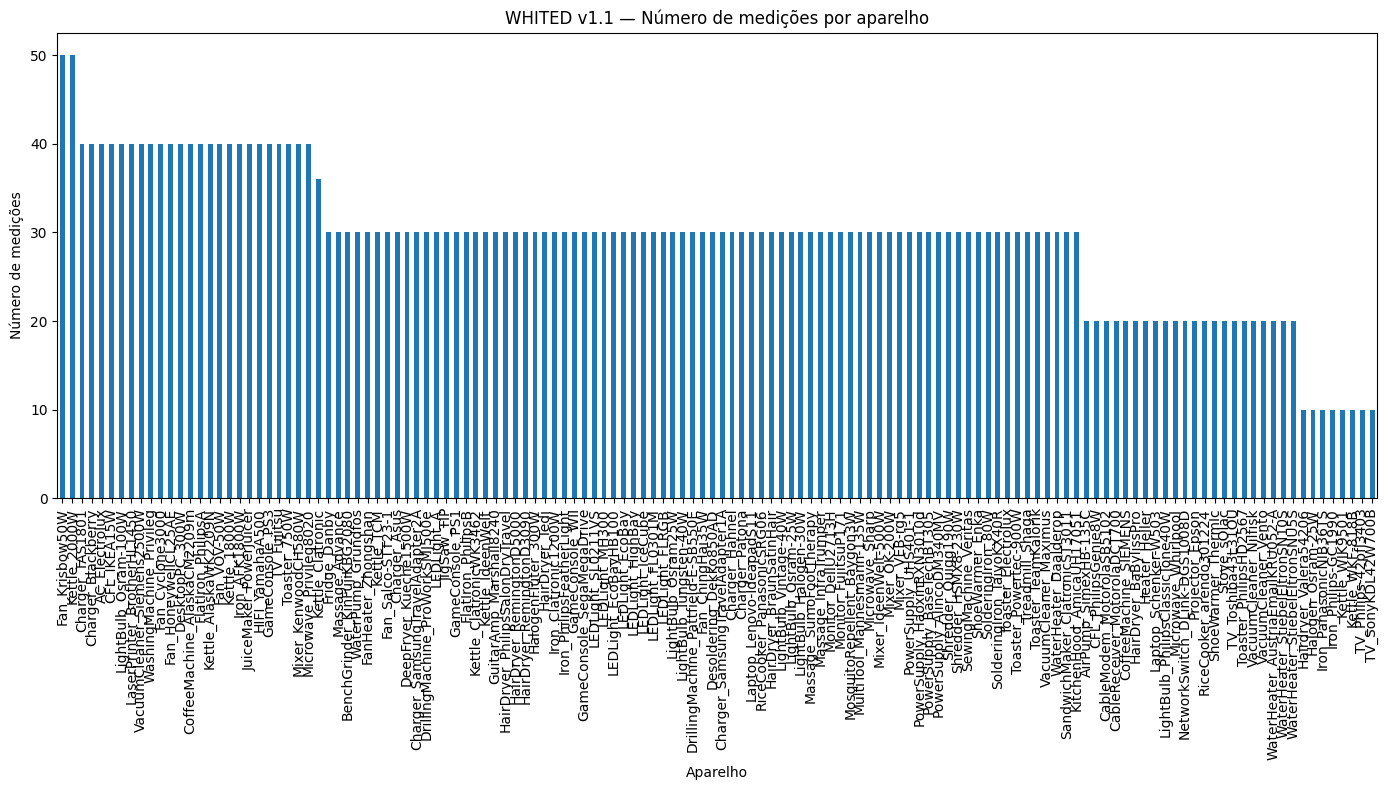

In [14]:
# ============================================================
# DISTRIBUIÇÃO DOS APARELHOS
# ============================================================

plt.figure(figsize=(14, 8))

appliance_counts.plot(
    kind="bar"
)

plt.title("WHITED v1.1 — Número de medições por aparelho")
plt.xlabel("Aparelho")
plt.ylabel("Número de medições")

plt.xticks(
    rotation=90
)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# DISTRIBUIÇÃO REGIONAL
# ============================================================

region_counts = (
    valid_metadata["region"]
    .value_counts()
    .sort_index()
)

display(
    region_counts.to_frame("measurements")
)

,measurements
region,
r1,760
r2,580
r3,956
r4,460
r5,700
r6,120
r7,110
r8,160
r9,80


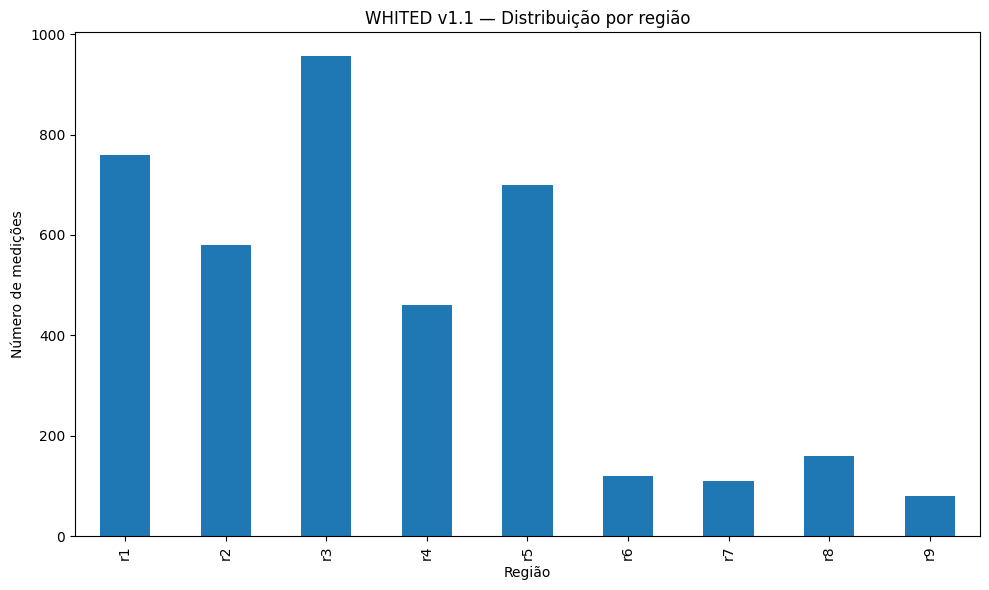

In [16]:
# ============================================================
# GRÁFICO POR REGIÃO
# ============================================================

plt.figure(figsize=(10, 6))

region_counts.plot(
    kind="bar"
)

plt.title("WHITED v1.1 — Distribuição por região")
plt.xlabel("Região")
plt.ylabel("Número de medições")

plt.tight_layout()
plt.show()

In [17]:
# ============================================================
# REGIÃO × APARELHO
# ============================================================

region_appliance = pd.crosstab(
    valid_metadata["region"],
    valid_metadata["appliance"]
)

display(region_appliance)

appliance,AC_Electrolux,AirPump_SimexHB-135C,BenchGrinder_KinFujiKBG2080,CFL_IKEA15W,CFL_PhilipsGenie8W,CableModem_MotorolaSB5102,CableReceiver_MotorolaDCT700,Charger_Asus,Charger_Blackberry,Charger_Hahnel,...,VacuumCleaner_Maximus,VacuumCleaner_Nilfisk,VacuumCleaner_Siemens2500W,VacuumCleaner_Vento,WashingMachine_Privileg,WaterHeater_AustriaEmailKRU052-A,WaterHeater_Daalderop,WaterHeater_StiebelEltronSN10S,WaterHeater_StiebelEltronSNU5S,WaterPump_Grundfos
region,,,,,,,,,,,,,,,,,,,,,
r1,0,0,0,40,0,0,0,0,0,0,...,0,20,0,20,0,0,0,20,20,0
r2,0,20,0,0,0,0,0,0,0,0,...,0,0,0,0,40,0,0,0,0,0
r3,0,0,0,0,0,0,0,0,0,30,...,0,0,40,0,0,0,0,0,0,0
r4,0,0,30,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
r5,40,0,0,0,0,0,0,30,40,0,...,30,0,0,0,0,0,30,0,0,30
r6,0,0,0,0,20,0,0,0,0,0,...,0,0,0,0,0,20,0,0,0,0
r7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
r8,0,0,0,0,0,20,20,0,0,0,...,0,0,0,0,0,0,0,0,0,0
r9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


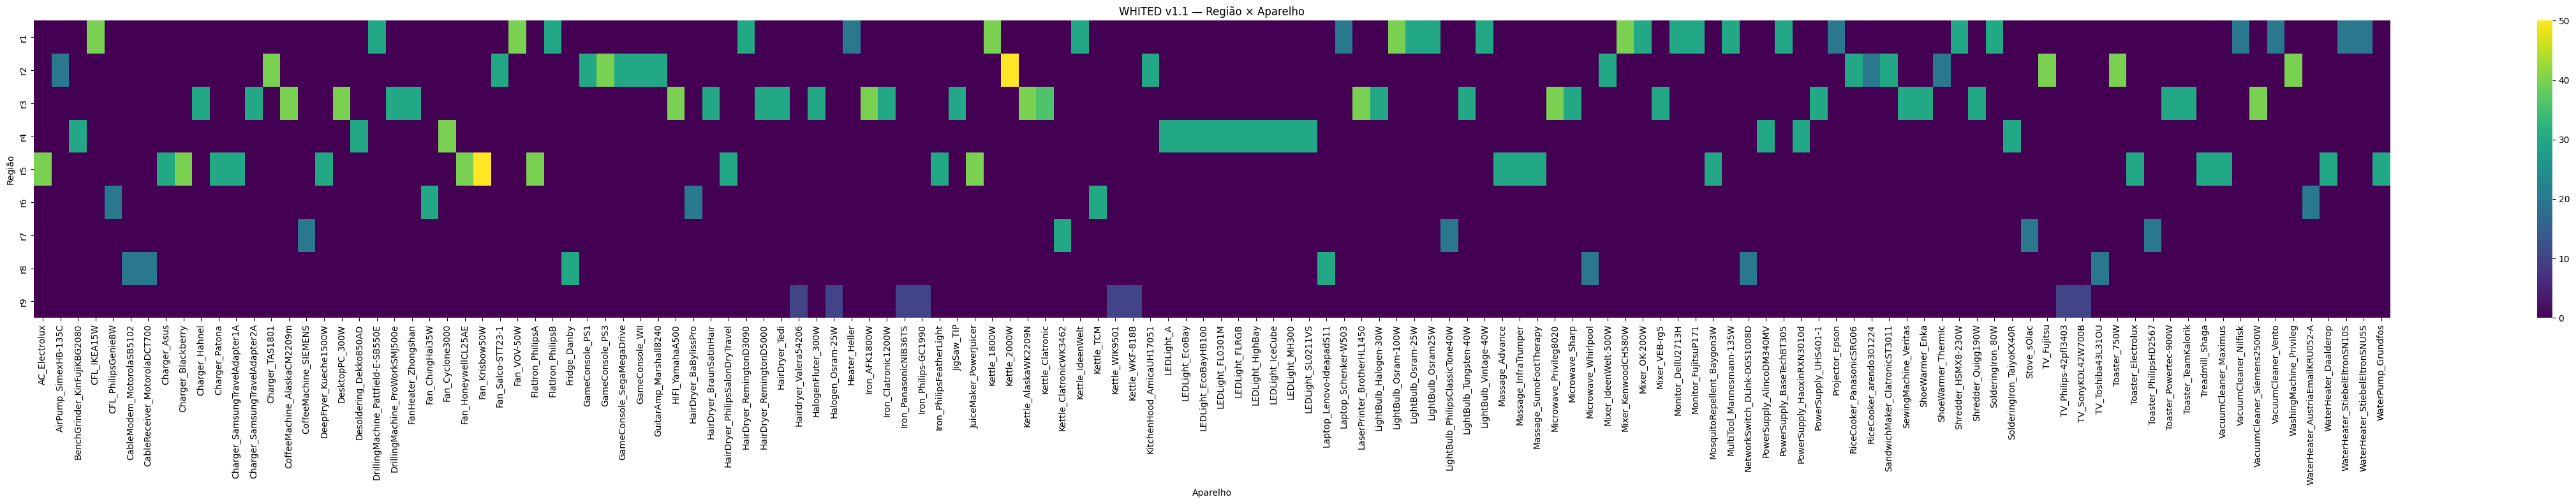

In [18]:
# ============================================================
# HEATMAP
# ============================================================

plt.figure(
    figsize=(
        max(14, region_appliance.shape[1] * 0.35),
        8
    )
)

sns.heatmap(
    region_appliance,
    cmap="viridis"
)

plt.title(
    "WHITED v1.1 — Região × Aparelho"
)

plt.xlabel("Aparelho")
plt.ylabel("Região")

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# MEASUREMENT KIT
# ============================================================

kit_counts = (
    valid_metadata["kit"]
    .value_counts()
    .sort_index()
)

display(
    kit_counts.to_frame("measurements")
)

,measurements
kit,
MK1,750
MK2,3176


In [20]:
# ============================================================
# REGIÃO × MEASUREMENT KIT
# ============================================================

region_kit = pd.crosstab(
    valid_metadata["region"],
    valid_metadata["kit"]
)

display(region_kit)

kit,MK1,MK2
region,,
r1,170,590
r2,160,420
r3,30,926
r4,0,460
r5,0,700
r6,120,0
r7,110,0
r8,160,0
r9,0,80


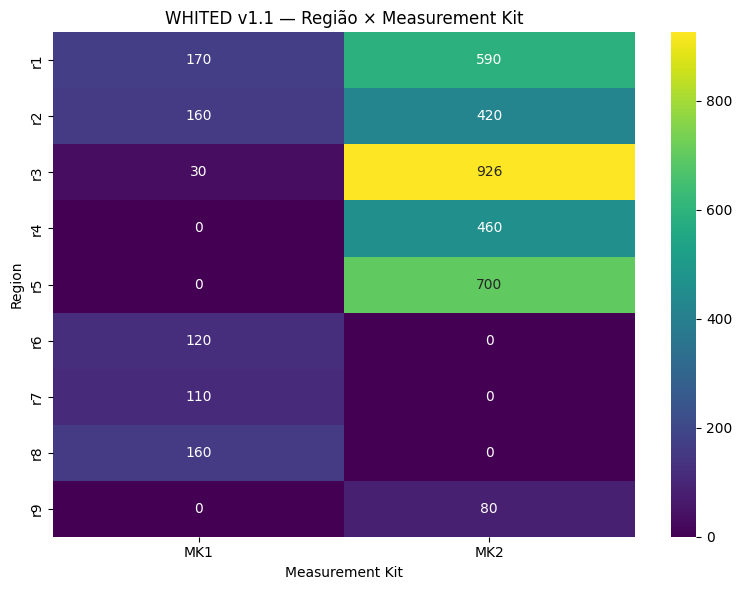

In [21]:
# ============================================================
# HEATMAP REGIÃO × KIT
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    region_kit,
    annot=True,
    fmt="d",
    cmap="viridis"
)

plt.title(
    "WHITED v1.1 — Região × Measurement Kit"
)

plt.xlabel("Measurement Kit")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# APARELHO × KIT
# ============================================================

appliance_kit = pd.crosstab(
    valid_metadata["appliance"],
    valid_metadata["kit"]
)

display(appliance_kit)

kit,MK1,MK2
appliance,,
AC_Electrolux,0,40
AirPump_SimexHB-135C,20,0
BenchGrinder_KinFujiKBG2080,0,30
CFL_IKEA15W,0,40
CFL_PhilipsGenie8W,20,0
...,...,...
WaterHeater_AustriaEmailKRU052-A,20,0
WaterHeater_Daalderop,0,30
WaterHeater_StiebelEltronSN10S,20,0


In [23]:
# ============================================================
# VALIDAÇÃO DOS FLAC
# ============================================================

def inspect_flac(filepath):

    result = {
        "filepath": str(filepath),
        "valid": False,
        "sample_rate": None,
        "channels": None,
        "frames": None,
        "duration": None,
        "subtype": None,
        "format": None,
        "error": None
    }

    try:

        info = sf.info(filepath)

        result["valid"] = True
        result["sample_rate"] = info.samplerate
        result["channels"] = info.channels
        result["frames"] = info.frames
        result["duration"] = info.duration
        result["subtype"] = info.subtype
        result["format"] = info.format

    except Exception as e:

        result["error"] = str(e)

    return result


signal_info = []

for f in tqdm(
    flac_files,
    desc="Validando FLAC"
):

    signal_info.append(
        inspect_flac(f)
    )

signal_df = pd.DataFrame(signal_info)

print(
    f"Arquivos válidos: "
    f"{signal_df['valid'].sum():,}"
)

print(
    f"Arquivos inválidos: "
    f"{(~signal_df['valid']).sum():,}"
)

Validando FLAC:   0%|          | 0/5016 [00:00<?, ?it/s]

Arquivos válidos: 5,016
Arquivos inválidos: 0


In [24]:
# ============================================================
# FORMATO DOS SINAIS
# ============================================================

print("=" * 60)
print("FORMATO DOS SINAIS")
print("=" * 60)

print("\nSampling rate:")
display(
    signal_df["sample_rate"]
    .value_counts()
    .sort_index()
)

print("\nChannels:")
display(
    signal_df["channels"]
    .value_counts()
    .sort_index()
)

print("\nSubtype:")
display(
    signal_df["subtype"]
    .value_counts()
)

print("\nFormat:")
display(
    signal_df["format"]
    .value_counts()
)

FORMATO DOS SINAIS

Sampling rate:


,count
sample_rate,
44100,5016



Channels:


,count
channels,
2,5016



Subtype:


,count
subtype,
PCM_16,5016



Format:


,count
format,
FLAC,5016


count    5016.000000
mean        5.126316
std         0.561391
min         5.100000
25%         5.100000
50%         5.100000
75%         5.100000
max        17.100000
Name: duration, dtype: float64


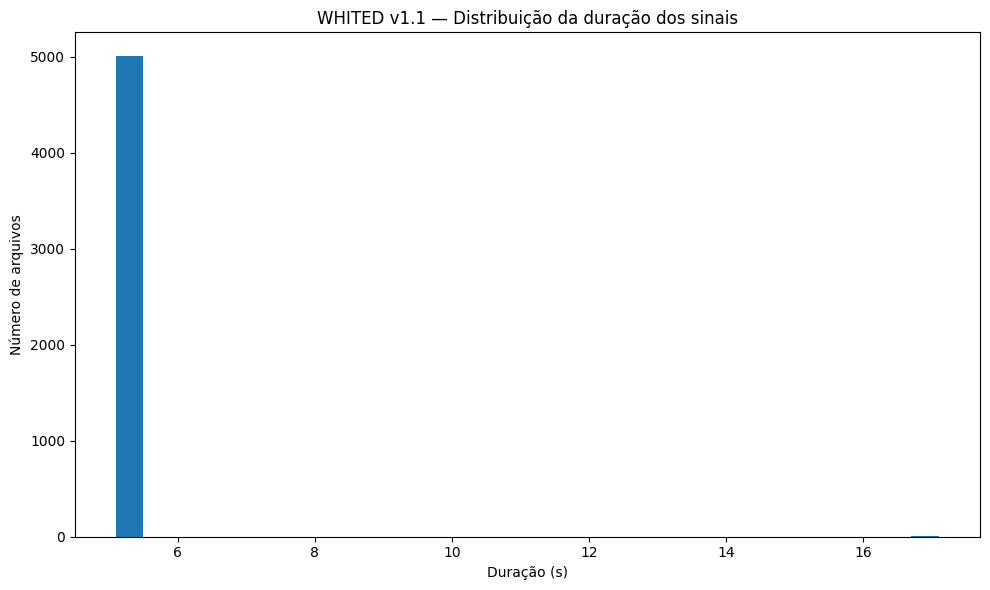

In [25]:
# ============================================================
# DURAÇÃO
# ============================================================

print(
    signal_df["duration"].describe()
)

plt.figure(figsize=(10, 6))

plt.hist(
    signal_df["duration"].dropna(),
    bins=30
)

plt.title(
    "WHITED v1.1 — Distribuição da duração dos sinais"
)

plt.xlabel("Duração (s)")
plt.ylabel("Número de arquivos")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# VALIDAÇÃO DAS EXPECTATIVAS
# ============================================================

print("=" * 60)
print("VALIDAÇÃO")
print("=" * 60)

expected_sr = CONFIG["expected_sampling_rate"]
expected_channels = CONFIG["expected_channels"]

sr_ok = (
    signal_df["sample_rate"] == expected_sr
)

channels_ok = (
    signal_df["channels"] == expected_channels
)

print(
    f"Sampling rate = {expected_sr} Hz:"
)

print(
    f"  OK: {sr_ok.sum():,}"
)

print(
    f"  Diferente: {(~sr_ok).sum():,}"
)

print()

print(
    f"Canais = {expected_channels}:"
)

print(
    f"  OK: {channels_ok.sum():,}"
)

print(
    f"  Diferente: {(~channels_ok).sum():,}"
)

VALIDAÇÃO
Sampling rate = 44100 Hz:
  OK: 5,016
  Diferente: 0

Canais = 2:
  OK: 5,016
  Diferente: 0


In [27]:
# ============================================================
# INTEGRAÇÃO METADADOS + SINAL
# ============================================================

audit_df = valid_metadata.merge(
    signal_df,
    on="filepath",
    how="left"
)

print(
    f"Registros na tabela final: "
    f"{len(audit_df):,}"
)

display(
    audit_df.head()
)

Registros na tabela final: 3,926


,filename,filepath,appliance,region,kit,timestamp,timestamp_dt,parse_ok,valid,sample_rate,channels,frames,duration,subtype,format,error
0,AC_Electrolux_r5_MK2_20151031065948.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031065948,2015-10-31 06:59:48,True,True,44100,2,224910,5.1,PCM_16,FLAC,None
1,AC_Electrolux_r5_MK2_20151031070257.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070257,2015-10-31 07:02:57,True,True,44100,2,224910,5.1,PCM_16,FLAC,None
2,AC_Electrolux_r5_MK2_20151031070606.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070606,2015-10-31 07:06:06,True,True,44100,2,224910,5.1,PCM_16,FLAC,None
3,AC_Electrolux_r5_MK2_20151031070919.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070919,2015-10-31 07:09:19,True,True,44100,2,224910,5.1,PCM_16,FLAC,None
4,AC_Electrolux_r5_MK2_20151031071229.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031071229,2015-10-31 07:12:29,True,True,44100,2,224910,5.1,PCM_16,FLAC,None


In [28]:
# ============================================================
# LEITURA DE UM ARQUIVO
# ============================================================

sample_file = flac_files[0]

audio, sr = sf.read(
    sample_file,
    always_2d=True
)

print("Arquivo:")
print(sample_file.name)

print()

print("Shape:")
print(audio.shape)

print()

print("Sampling rate:")
print(sr)

print()

print("Dtype:")
print(audio.dtype)

print()

print("Canal 0:")
print(
    "min =", audio[:, 0].min(),
    "max =", audio[:, 0].max(),
    "RMS =", np.sqrt(np.mean(audio[:, 0]**2))
)

print()

print("Canal 1:")
print(
    "min =", audio[:, 1].min(),
    "max =", audio[:, 1].max(),
    "RMS =", np.sqrt(np.mean(audio[:, 1]**2))
)

Arquivo:
AC_Electrolux_r5_MK2_20151031065948.flac

Shape:
(224910, 2)

Sampling rate:
44100

Dtype:
float64

Canal 0:
min = -0.370086669921875 max = 0.366058349609375 RMS = 0.2639868249581902

Canal 1:
min = -0.2252197265625 max = 0.217376708984375 RMS = 0.031756013083213956


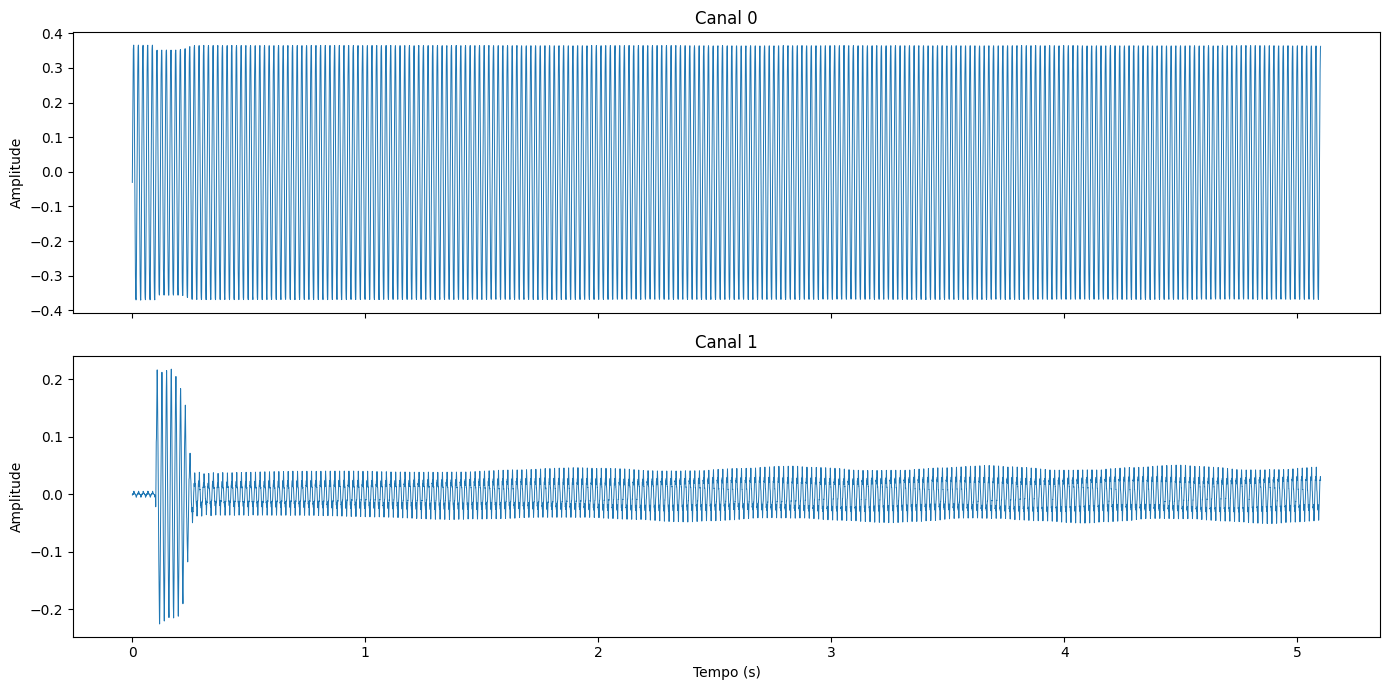

In [29]:
# ============================================================
# SINAL NO DOMÍNIO DO TEMPO
# ============================================================

time = np.arange(
    len(audio)
) / sr

fig, ax = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharex=True
)

ax[0].plot(
    time,
    audio[:, 0],
    linewidth=0.7
)

ax[0].set_title(
    "Canal 0"
)

ax[0].set_ylabel(
    "Amplitude"
)

ax[1].plot(
    time,
    audio[:, 1],
    linewidth=0.7
)

ax[1].set_title(
    "Canal 1"
)

ax[1].set_xlabel(
    "Tempo (s)"
)

ax[1].set_ylabel(
    "Amplitude"
)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# CARACTERÍSTICAS TEMPORAIS
# ============================================================

def calculate_time_features(x):

    x = np.asarray(x)

    rms = np.sqrt(
        np.mean(x**2)
    )

    peak = np.max(
        np.abs(x)
    )

    return {
        "mean": np.mean(x),
        "std": np.std(x),
        "rms": rms,
        "peak": peak,
        "peak_to_peak": np.ptp(x),
        "crest_factor": (
            peak / rms
            if rms > 0 else np.nan
        ),
        "energy": np.sum(x**2),
        "skewness": stats.skew(x),
        "kurtosis": stats.kurtosis(x)
    }

In [31]:
# ============================================================
# CARACTERÍSTICAS ESPECTRAIS
# ============================================================

def calculate_spectral_features(
    x,
    sr,
    n_fft=8192
):

    x = np.asarray(x)

    if len(x) < n_fft:
        padded = np.zeros(n_fft)
        padded[:len(x)] = x
        x = padded

    else:
        x = x[:n_fft]

    window = np.hanning(len(x))

    xw = x * window

    spectrum = np.abs(
        np.fft.rfft(xw)
    )

    frequencies = np.fft.rfftfreq(
        len(x),
        d=1/sr
    )

    power = spectrum ** 2

    total_power = np.sum(power)

    if total_power > 0:

        spectral_centroid = (
            np.sum(frequencies * power)
            / total_power
        )

        spectral_bandwidth = np.sqrt(
            np.sum(
                ((frequencies - spectral_centroid)**2)
                * power
            )
            / total_power
        )

    else:

        spectral_centroid = np.nan
        spectral_bandwidth = np.nan

    dominant_idx = np.argmax(
        spectrum
    )

    dominant_frequency = (
        frequencies[dominant_idx]
    )

    return {
        "spectral_centroid": spectral_centroid,
        "spectral_bandwidth": spectral_bandwidth,
        "dominant_frequency": dominant_frequency,
        "spectral_energy": total_power
    }

In [32]:
# ============================================================
# EXTRAÇÃO DE CARACTERÍSTICAS
# ============================================================

analysis_files = flac_files

if CONFIG["signal_analysis_limit"] is not None:

    rng = np.random.default_rng(
        RANDOM_STATE
    )

    if len(analysis_files) > CONFIG["signal_analysis_limit"]:

        analysis_files = list(
            rng.choice(
                analysis_files,
                size=CONFIG["signal_analysis_limit"],
                replace=False
            )
        )

print(
    f"Arquivos utilizados na análise: "
    f"{len(analysis_files):,}"
)


feature_rows = []

for filepath in tqdm(
    analysis_files,
    desc="Extraindo características"
):

    try:

        x, sr = sf.read(
            filepath,
            always_2d=True
        )

        row = {
            "filepath": str(filepath)
        }

        # Canal 0
        f0 = calculate_time_features(
            x[:, 0]
        )

        s0 = calculate_spectral_features(
            x[:, 0],
            sr,
            CONFIG["fft_n"]
        )

        # Canal 1
        f1 = calculate_time_features(
            x[:, 1]
        )

        s1 = calculate_spectral_features(
            x[:, 1],
            sr,
            CONFIG["fft_n"]
        )

        for k, v in f0.items():
            row[f"ch0_{k}"] = v

        for k, v in s0.items():
            row[f"ch0_{k}"] = v

        for k, v in f1.items():
            row[f"ch1_{k}"] = v

        for k, v in s1.items():
            row[f"ch1_{k}"] = v

        feature_rows.append(row)

    except Exception as e:

        print(
            f"Erro em {filepath}: {e}"
        )


features_df = pd.DataFrame(
    feature_rows
)

features_df = features_df.merge(
    valid_metadata,
    on="filepath",
    how="left"
)

print(
    f"Características extraídas: "
    f"{len(features_df):,}"
)

Arquivos utilizados na análise: 5,016


Extraindo características:   0%|          | 0/5016 [00:00<?, ?it/s]

Características extraídas: 5,016


In [33]:
# ============================================================
# ESTATÍSTICAS
# ============================================================

feature_columns = [
    c for c in features_df.columns
    if c.startswith("ch0_")
    or c.startswith("ch1_")
]

display(
    features_df[
        feature_columns
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
ch0_mean,5016.0,-0.001850,0.000843,-0.010264,-0.002293,-0.002162,-0.001895,0.000371
ch0_std,5016.0,0.249098,0.030944,0.104755,0.227759,0.262738,0.265689,0.272480
ch0_rms,5016.0,0.249106,0.030946,0.104756,0.227767,0.262747,0.265695,0.272491
ch0_peak,5016.0,0.353179,0.043085,0.154053,0.330635,0.371826,0.375977,0.388885
ch0_peak_to_peak,5016.0,0.702554,0.085124,0.307800,0.659637,0.738983,0.747475,0.763947
ch0_crest_factor,5016.0,1.418326,0.020471,1.386797,1.403509,1.416826,1.426352,1.592276
ch0_energy,5016.0,14225.923684,3027.411910,2468.100077,11687.198436,15539.549594,15882.956231,35223.033496
ch0_skewness,5016.0,0.000017,0.001540,-0.014962,-0.000770,-0.000088,0.000669,0.015521
ch0_kurtosis,5016.0,-1.490638,0.019840,-1.547602,-1.495811,-1.491243,-1.484371,-1.422180
ch0_spectral_centroid,5016.0,50.586816,1.785213,49.852730,50.156391,50.232385,50.372123,61.346267


In [34]:
# ============================================================
# COMPARAÇÃO DOS CANAIS
# ============================================================

channel_summary = pd.DataFrame({
    "Channel 0 RMS":
        [features_df["ch0_rms"].median()],

    "Channel 1 RMS":
        [features_df["ch1_rms"].median()],

    "Channel 0 Peak":
        [features_df["ch0_peak"].median()],

    "Channel 1 Peak":
        [features_df["ch1_peak"].median()],

    "Channel 0 Dominant Freq":
        [features_df["ch0_dominant_frequency"].median()],

    "Channel 1 Dominant Freq":
        [features_df["ch1_dominant_frequency"].median()]
})

display(channel_summary)

,Channel 0 RMS,Channel 1 RMS,Channel 0 Peak,Channel 1 Peak,Channel 0 Dominant Freq,Channel 1 Dominant Freq
0,0.262747,0.008924,0.371826,0.085999,48.449707,48.449707


In [35]:
# ============================================================
# CARACTERÍSTICAS POR REGIÃO
# ============================================================

region_features = (
    features_df
    .groupby("region")
    [
        [
            "ch0_rms",
            "ch0_peak",
            "ch0_crest_factor",
            "ch0_spectral_centroid",
            "ch0_spectral_bandwidth",

            "ch1_rms",
            "ch1_peak",
            "ch1_crest_factor",
            "ch1_spectral_centroid",
            "ch1_spectral_bandwidth"
        ]
    ]
    .agg(
        ["mean", "std", "median"]
    )
)

display(region_features)

ch0_rms                      ch0_peak                      \
            mean       std    median      mean       std    median   
region                                                               
r1      0.252867  0.018470  0.261086  0.360367  0.025571  0.373260   
r2      0.251600  0.019071  0.262735  0.354708  0.026975  0.369141   
r3      0.265508  0.007735  0.266926  0.373737  0.010768  0.376251   
r4      0.228385  0.012640  0.223010  0.326989  0.020808  0.317230   
r5      0.261812  0.007089  0.262476  0.370032  0.009859  0.372528   
r6      0.221287  0.002743  0.222646  0.318715  0.001204  0.318665   
r7      0.223708  0.002200  0.224014  0.324636  0.003780  0.322418   
r8      0.110865  0.002182  0.111776  0.157092  0.001461  0.157471   
r9      0.257546  0.002972  0.257577  0.374714  0.006073  0.373444   

       ch0_crest_factor                     ch0_spectral_centroid  ...  \
                   mean       std    median                  mean  ...   
region                                                             ...   
r1             1.425398  0.011303  1.420580             50.355135  ...   
r2             1.409844  0.013038  1.406486             50.328675  ...   
r3             1.407715  0.014801  1.403922             50.212923  ...   
r4             1.431266  0.024742  1.421829             50.297366  ...   
r5             1.413413  0.011300  1.413994             50.171870  ...   
r6             1.440509  0.019424  1.429536             50.365473  ...   
r7             1.451158  0.009195  1.451576             50.360377  ...   
r8             1.417347  0.021776  1.408546             60.288239  ...   
r9             1.454929  0.015658  1.449398             50.100136  ...   

        ch1_peak ch1_crest_factor                       ch1_spectral_centroid  \
          median             mean        std     median                  mean   
region                                                                          
r1      0.105316        15.551058  30.722330   6.857133            287.960906   
r2      0.039917         7.496098  12.310261   3.714254            260.943119   
r3      0.148834        12.128969  28.894099   3.814125            139.595990   
r4      0.080536        26.266957  31.903085  15.687643           1374.677558   
r5      0.095612        21.023405  49.405989   5.725202            295.893736   
r6      0.095856        14.298858  30.394886   2.541125            556.144557   
r7      0.096741         2.948824   3.389443   1.497330             87.448052   
r8      0.159821        48.643631  53.653784  20.287127            528.560345   
r9      0.135818         3.321859   3.230040   1.537980             97.644803   

                                ch1_spectral_bandwidth               \
                std      median                   mean          std   
region                                                                
r1       638.798325   69.759838             559.034015   813.913175   
r2       765.922241   74.094699             654.948081   937.883837   
r3       290.864254   63.487569             316.474034   486.093694   
r4      2369.056519  228.109260            1422.615766  1649.778484   
r5       624.039838   61.979982             633.399292   998.498366   
r6      1185.437509   58.328654             832.914154  1417.081266   
r7        70.059411   63.600824             283.072935   286.780337   
r8       482.404667  264.272915             659.062662   591.902998   
r9        71.281097   68.695323             348.472132   306.781804   

                    
            median  
region              
r1      234.351616  
r2      267.367319  
r3      163.727929  
r4      725.049239  
r5      232.605388  
r6      200.127129  
r7      210.062450  
r8      544.196774  
r9      244.751240  

[9 rows x 30 columns]

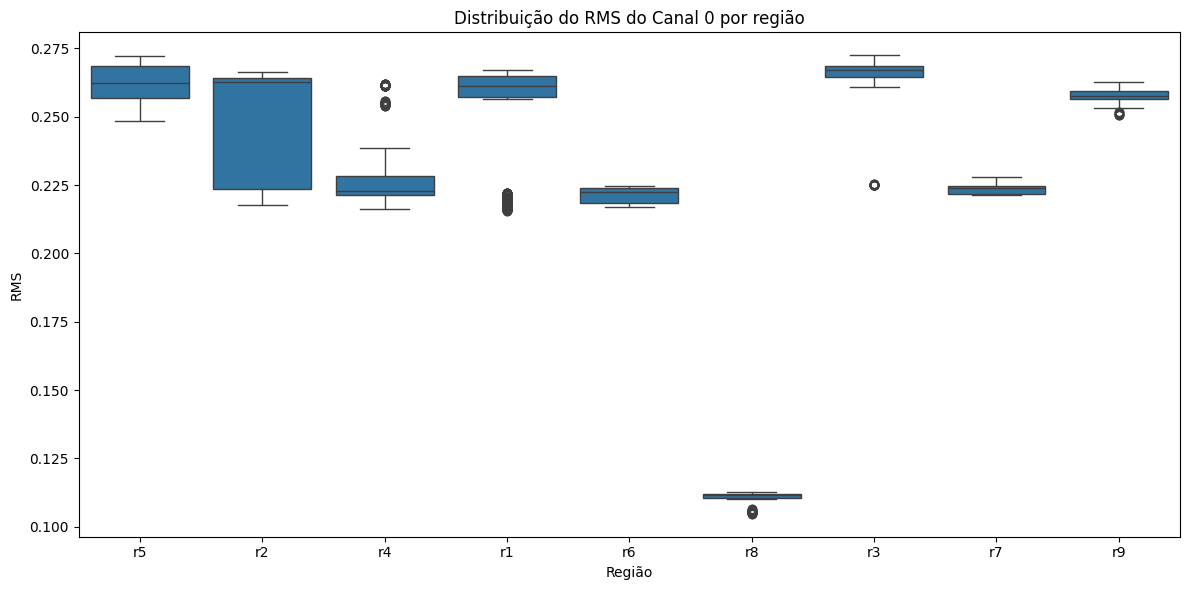

In [36]:
# ============================================================
# RMS POR REGIÃO
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=features_df,
    x="region",
    y="ch0_rms"
)

plt.title(
    "Distribuição do RMS do Canal 0 por região"
)

plt.xlabel("Região")
plt.ylabel("RMS")

plt.tight_layout()
plt.show()

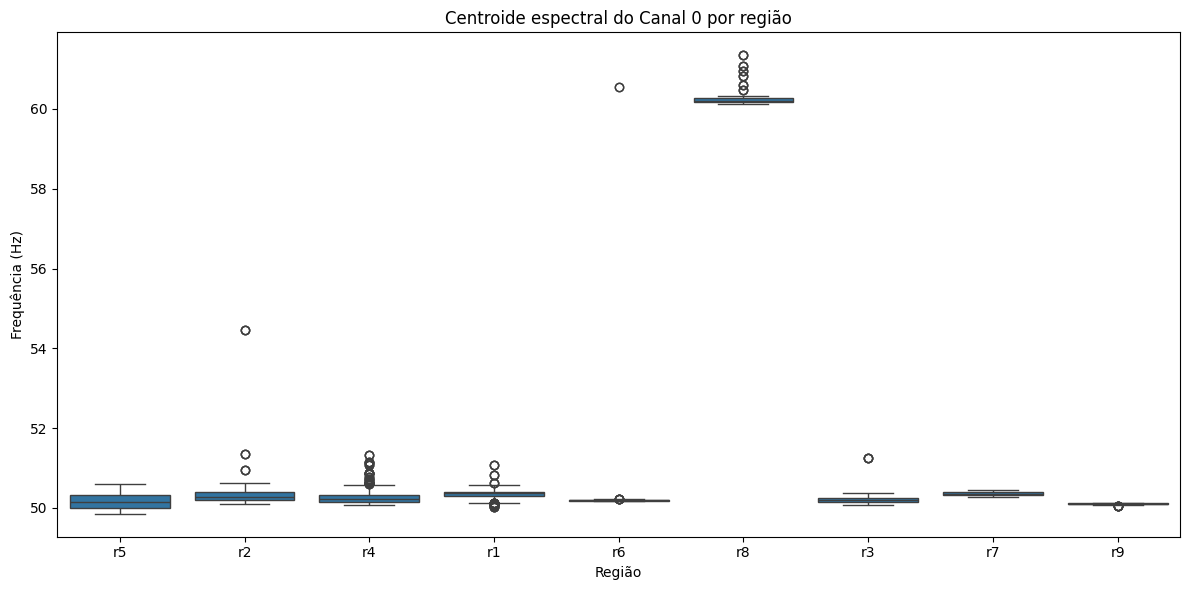

In [37]:
# ============================================================
# CENTROIDE ESPECTRAL POR REGIÃO
# ============================================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=features_df,
    x="region",
    y="ch0_spectral_centroid"
)

plt.title(
    "Centroide espectral do Canal 0 por região"
)

plt.xlabel("Região")
plt.ylabel("Frequência (Hz)")

plt.tight_layout()
plt.show()

In [38]:
# ============================================================
# CARACTERÍSTICAS POR MEASUREMENT KIT
# ============================================================

kit_features = (
    features_df
    .groupby("kit")
    [
        [
            "ch0_rms",
            "ch0_peak",
            "ch0_crest_factor",
            "ch0_spectral_centroid",
            "ch1_rms",
            "ch1_peak",
            "ch1_crest_factor",
            "ch1_spectral_centroid"
        ]
    ]
    .agg(["mean", "std", "median"])
)

display(kit_features)

ch0_rms                      ch0_peak                      \
         mean       std    median      mean       std    median   
kit                                                               
MK1  0.197592  0.045270  0.220189  0.282112  0.065327  0.312973   
MK2  0.258680  0.014096  0.263861  0.366443  0.018925  0.373657   

    ch0_crest_factor                     ch0_spectral_centroid  ...   ch1_rms  \
                mean       std    median                  mean  ...    median   
kit                                                             ...             
MK1         1.426713  0.020550  1.423382             52.484808  ...  0.027869   
MK2         1.416934  0.018738  1.416577             50.250380  ...  0.008611   

     ch1_peak                     ch1_crest_factor                       \
         mean       std    median             mean        std    median   
kit                                                                       
MK1  0.168305  0.185505  0.099609        16.188498  33.527129  2.543460   
MK2  0.130879  0.133909  0.085205        16.532937  34.716961  5.746451   

    ch1_spectral_centroid                          
                     mean          std     median  
kit                                                
MK1            277.516679   574.421628  66.910166  
MK2            410.493929  1133.416573  69.403637  

[2 rows x 24 columns]

In [39]:
# ============================================================
# REGIÃO × KIT
# ============================================================

region_kit_features = (
    features_df
    .groupby(
        ["region", "kit"]
    )
    [
        [
            "ch0_rms",
            "ch0_peak",
            "ch0_spectral_centroid",
            "ch1_rms",
            "ch1_peak",
            "ch1_spectral_centroid"
        ]
    ]
    .agg(
        ["count", "mean", "std", "median"]
    )
)

display(
    region_kit_features
)

ch0_rms                               ch0_peak                      \
             count      mean       std    median    count      mean       std   
region kit                                                                      
r1     MK1     170  0.218877  0.001846  0.219539      170  0.312934  0.000868   
       MK2     590  0.262661  0.003015  0.263854      590  0.374034  0.002428   
r2     MK1     160  0.220826  0.001482  0.220638      160  0.311356  0.002663   
       MK2     420  0.263324  0.001533  0.263665      420  0.371223  0.003424   
r3     MK1      30  0.225066  0.000112  0.225073       30  0.315936  0.000202   
       MK2     926  0.266818  0.002646  0.267057      926  0.375609  0.002800   
r4     MK2     460  0.228385  0.012640  0.223010      460  0.326989  0.020808   
r5     MK2     700  0.261812  0.007089  0.262476      700  0.370032  0.009859   
r6     MK1     120  0.221287  0.002743  0.222646      120  0.318715  0.001204   
r7     MK1     110  0.223708  0.002200  0.224014      110  0.324636  0.003780   
r8     MK1     160  0.110865  0.002182  0.111776      160  0.157092  0.001461   
r9     MK2      80  0.257546  0.002972  0.257577       80  0.374714  0.006073   

                     ch0_spectral_centroid             ...   ch1_rms  \
              median                 count       mean  ...       std   
region kit                                             ...             
r1     MK1  0.312866                   170  50.348630  ...  0.050174   
       MK2  0.374329                   590  50.357009  ...  0.047041   
r2     MK1  0.312073                   160  50.400986  ...  0.015409   
       MK2  0.369781                   420  50.301128  ...  0.043252   
r3     MK1  0.315872                    30  50.352163  ...  0.000032   
       MK2  0.376343                   926  50.208412  ...  0.054791   
r4     MK2  0.317230                   460  50.297366  ...  0.012161   
r5     MK2  0.372528                   700  50.171870  ...  0.032115   
r6     MK1  0.318665                   120  50.365473  ...  0.080749   
r7     MK1  0.322418                   110  50.360377  ...  0.041848   
r8     MK1  0.157471                   160  60.288239  ...  0.054333   
r9     MK2  0.373444                    80  50.100136  ...  0.055537   

                     ch1_peak                                \
              median    count      mean       std    median   
region kit                                                    
r1     MK1  0.079964      170  0.287000  0.214417  0.208160   
       MK2  0.006740      590  0.113908  0.146212  0.055389   
r2     MK1  0.015358      160  0.047562  0.031806  0.038437   
       MK2  0.005053      420  0.065521  0.071108  0.044586   
r3     MK1  0.027809       30  0.044348  0.000887  0.044067   
       MK2  0.049059      926  0.168656  0.131387  0.173553   
r4     MK2  0.007941      460  0.158161  0.165419  0.080536   
r5     MK2  0.015999      700  0.117957  0.116408  0.095612   
r6     MK1  0.028779      120  0.133790  0.107012  0.095856   
r7     MK1  0.065741      110  0.102634  0.055972  0.096741   
r8     MK1  0.007241      160  0.257211  0.238827  0.159821   
r9     MK2  0.091396       80  0.118105  0.076705  0.135818   

           ch1_spectral_centroid                                        
                           count         mean          std      median  
region kit                                                              
r1     MK1                   170   143.956592   195.685264   67.069552  
       MK2                   590   329.453675   712.140023   73.090923  
r2     MK1                   160   131.452993   170.424620   62.488775  
       MK2                   420   310.272691   889.262127   83.968217  
r3     MK1                    30    56.870735    16.332743   49.145616  
       MK2                   926   142.276074   295.141253   63.807252  
r4     MK2                   460  1374.677558  2369.056519  228.109260  
r5     MK2                   700   295

In [40]:
# ============================================================
# CLASSES COMPARTILHADAS ENTRE REGIÕES
# ============================================================

region_class_presence = (
    pd.crosstab(
        valid_metadata["appliance"],
        valid_metadata["region"]
    ) > 0
)

region_class_presence["n_regions"] = (
    region_class_presence.sum(axis=1)
)

shared_classes = (
    region_class_presence[
        region_class_presence["n_regions"] >= 2
    ]
    .sort_values(
        "n_regions",
        ascending=False
    )
)

print(
    "Classes presentes em pelo menos 2 regiões:"
)

display(shared_classes)

Classes presentes em pelo menos 2 regiões:


region,r1,r2,r3,r4,r5,r6,r7,r8,r9,n_regions
appliance,,,,,,,,,,


In [41]:
# ============================================================
# CLASSES PRESENTES EM TODAS AS REGIÕES
# ============================================================

n_regions = (
    valid_metadata["region"]
    .nunique()
)

classes_all_regions = (
    region_class_presence[
        region_class_presence["n_regions"] == n_regions
    ]
)

print(
    f"Número total de regiões: {n_regions}"
)

print(
    f"Classes presentes em todas as regiões: "
    f"{len(classes_all_regions)}"
)

display(
    classes_all_regions
)

Número total de regiões: 9
Classes presentes em todas as regiões: 0


region,r1,r2,r3,r4,r5,r6,r7,r8,r9,n_regions
appliance,,,,,,,,,,


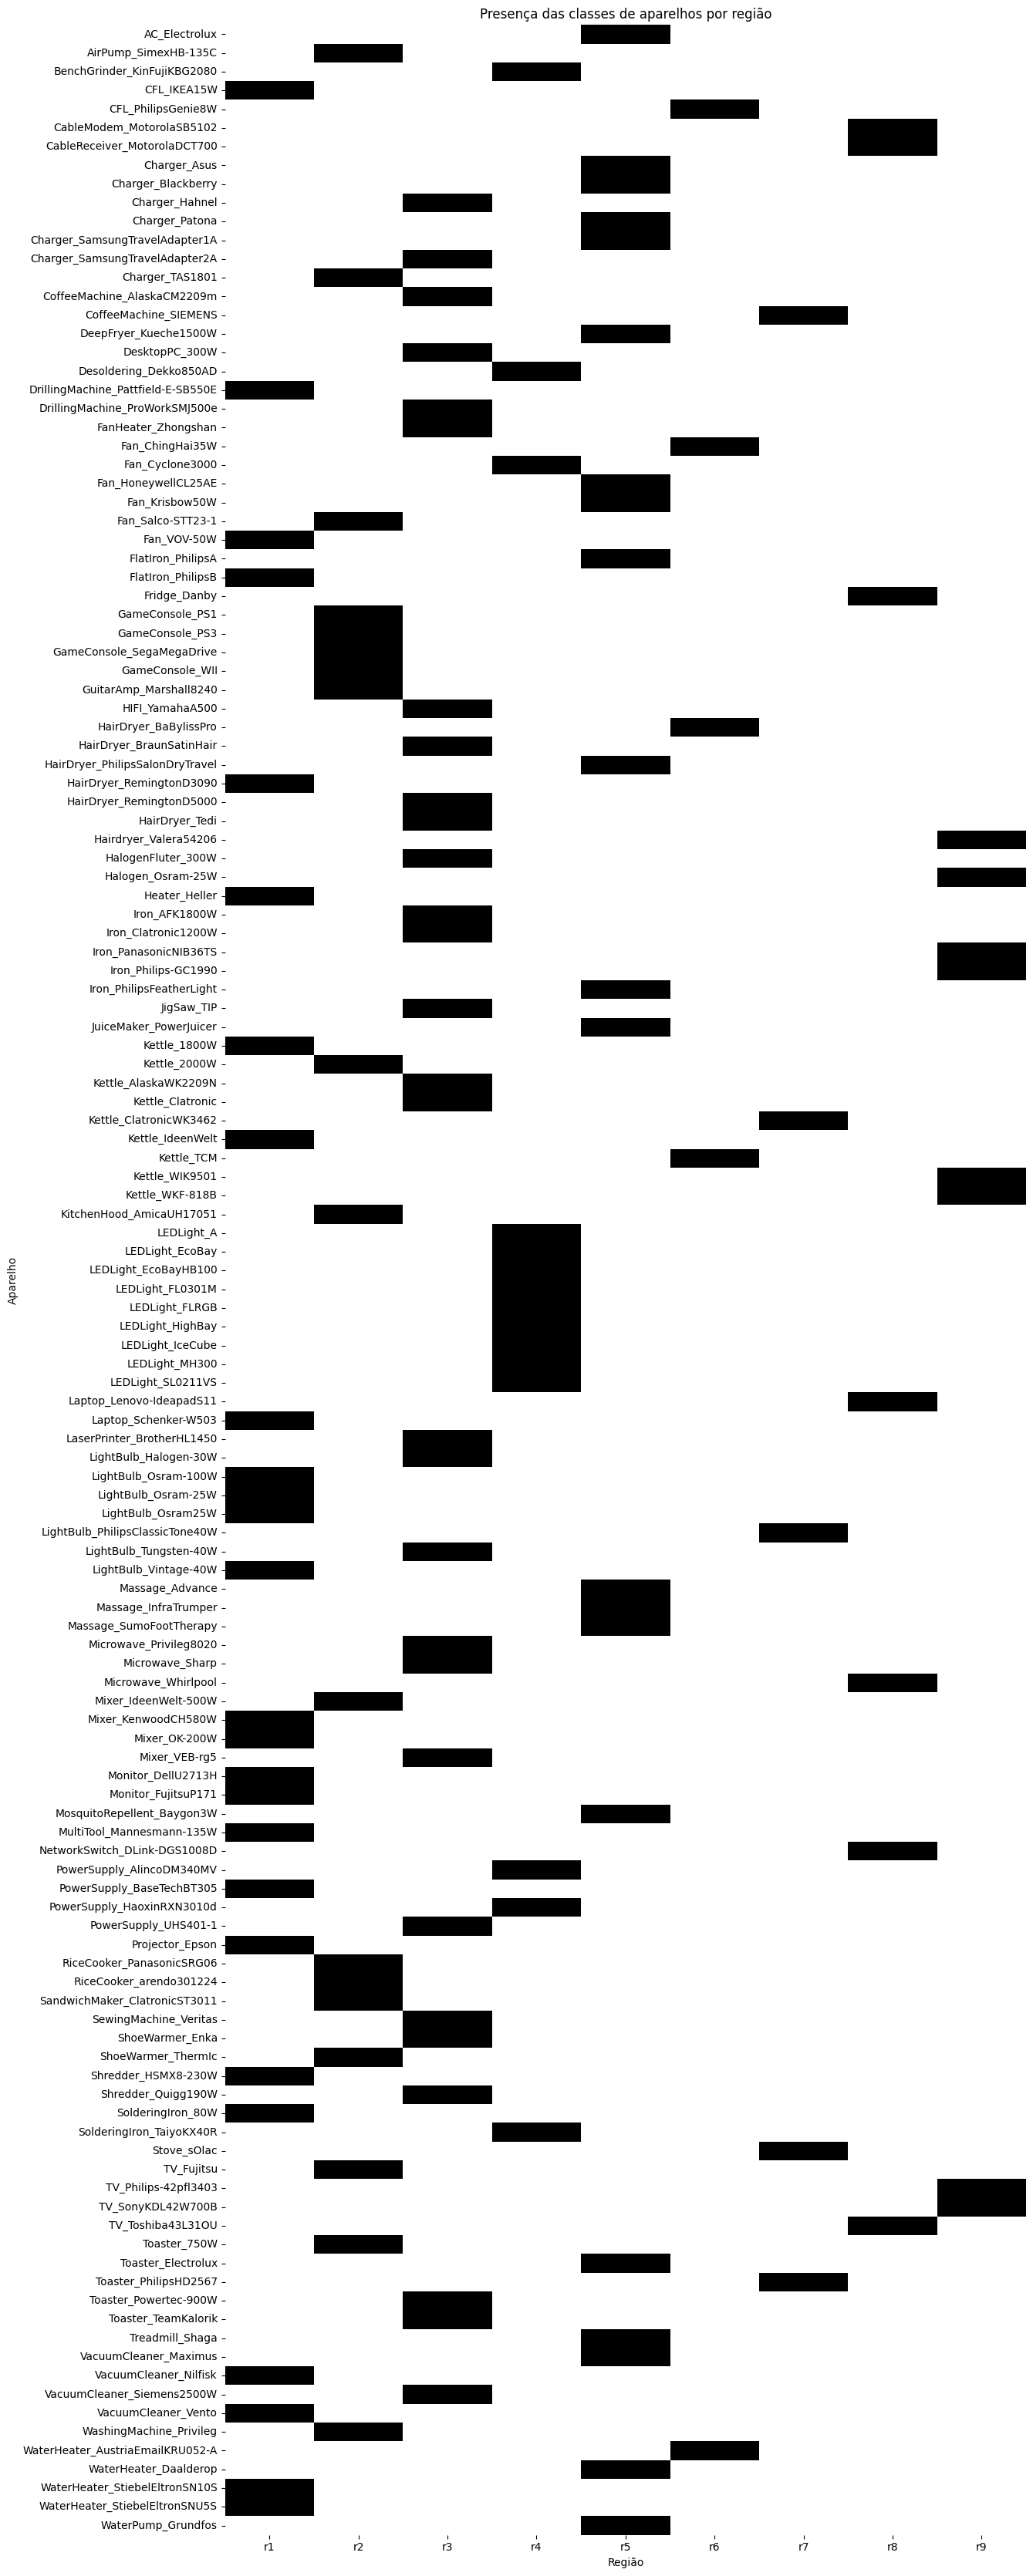

In [42]:
# ============================================================
# MATRIZ DE PRESENÇA
# ============================================================

presence_matrix = (
    region_class_presence
    .drop(columns=["n_regions"])
)

plt.figure(
    figsize=(
        max(12, presence_matrix.shape[1] * 1.5),
        max(10, presence_matrix.shape[0] * 0.25)
    )
)

sns.heatmap(
    presence_matrix,
    cmap="Greys",
    cbar=False
)

plt.title(
    "Presença das classes de aparelhos por região"
)

plt.xlabel("Região")
plt.ylabel("Aparelho")

plt.tight_layout()
plt.show()

In [43]:
# ============================================================
# EVENTOS POR APARELHO
# ============================================================

events_per_appliance = (
    valid_metadata
    .groupby("appliance")
    .size()
    .sort_values()
)

display(
    events_per_appliance.to_frame(
        "events"
    )
)

,events
appliance,
Iron_PanasonicNIB36TS,10
Iron_Philips-GC1990,10
Kettle_WIK9501,10
Kettle_WKF-818B,10
Hairdryer_Valera54206,10
...,...
WashingMachine_Privileg,40
VacuumCleaner_Siemens2500W,40
Toaster_750W,40


In [44]:
# ============================================================
# PROXY DE INSTÂNCIA
# ============================================================

valid_metadata["instance_proxy"] = (
    valid_metadata["appliance"]
    + "__"
    + valid_metadata["region"]
    + "__"
    + valid_metadata["kit"]
)

instance_counts = (
    valid_metadata
    .groupby("instance_proxy")
    .size()
    .sort_values()
)

display(
    instance_counts.describe()
)

,0
count,134.000000
mean,29.298507
std,8.027237
min,10.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,50.000000


In [45]:
# ============================================================
# INTERVALOS ENTRE EVENTOS
# ============================================================

time_analysis = (
    valid_metadata
    .sort_values(
        [
            "appliance",
            "region",
            "kit",
            "timestamp_dt"
        ]
    )
    .copy()
)

time_analysis["delta_seconds"] = (
    time_analysis
    .groupby(
        ["appliance", "region", "kit"]
    )["timestamp_dt"]
    .diff()
    .dt.total_seconds()
)

display(
    time_analysis[
        [
            "appliance",
            "region",
            "kit",
            "timestamp_dt",
            "delta_seconds"
        ]
    ].head(30)
)

,appliance,region,kit,timestamp_dt,delta_seconds
0,AC_Electrolux,r5,MK2,2015-10-31 06:59:48,NaN
351,AC_Electrolux,r5,MK2,2015-10-31 06:59:48,0.0
2289,AC_Electrolux,r5,MK2,2015-10-31 06:59:48,0.0
2569,AC_Electrolux,r5,MK2,2015-10-31 06:59:48,0.0
1,AC_Electrolux,r5,MK2,2015-10-31 07:02:57,189.0
352,AC_Electrolux,r5,MK2,2015-10-31 07:02:57,0.0
2290,AC_Electrolux,r5,MK2,2015-10-31 07:02:57,0.0
2570,AC_Electrolux,r5,MK2,2015-10-31 07:02:57,0.0
2,AC_Electrolux,r5,MK2,2015-10-31 07:06:06,189.0
353,AC_Electrolux,r5,MK2,2015-10-31 07:06:06,0.0


count    3792.000000
mean        8.470728
std        74.798932
min         0.000000
25%         0.000000
50%         0.000000
75%         9.000000
max      4376.000000
Name: delta_seconds, dtype: float64


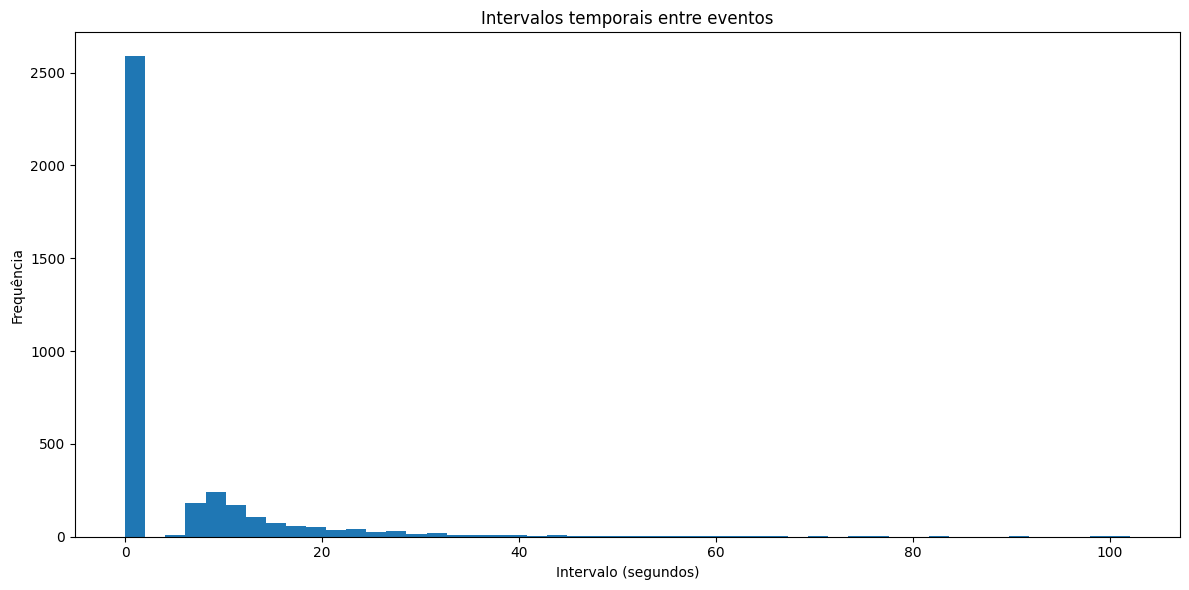

In [46]:
# ============================================================
# INTERVALOS ENTRE GRAVAÇÕES
# ============================================================

delta = (
    time_analysis["delta_seconds"]
    .dropna()
)

print(delta.describe())

plt.figure(figsize=(12, 6))

plt.hist(
    delta[
        delta <= delta.quantile(0.99)
    ],
    bins=50
)

plt.title(
    "Intervalos temporais entre eventos"
)

plt.xlabel("Intervalo (segundos)")
plt.ylabel("Frequência")

plt.tight_layout()
plt.show()

In [47]:
# ============================================================
# POSSÍVEIS SEQUÊNCIAS
# ============================================================

sequence_candidates = (
    time_analysis[
        (time_analysis["delta_seconds"] > 0)
        &
        (time_analysis["delta_seconds"] <= 300)
    ]
)

print(
    "Eventos separados por até 5 minutos:"
)

display(
    sequence_candidates[
        [
            "filename",
            "appliance",
            "region",
            "kit",
            "timestamp_dt",
            "delta_seconds"
        ]
    ].head(100)
)

Eventos separados por até 5 minutos:


,filename,appliance,region,kit,timestamp_dt,delta_seconds
1,AC_Electrolux_r5_MK2_20151031070257.flac,AC_Electrolux,r5,MK2,2015-10-31 07:02:57,189.0
2,AC_Electrolux_r5_MK2_20151031070606.flac,AC_Electrolux,r5,MK2,2015-10-31 07:06:06,189.0
3,AC_Electrolux_r5_MK2_20151031070919.flac,AC_Electrolux,r5,MK2,2015-10-31 07:09:19,193.0
4,AC_Electrolux_r5_MK2_20151031071229.flac,AC_Electrolux,r5,MK2,2015-10-31 07:12:29,190.0
5,AC_Electrolux_r5_MK2_20151031071715.flac,AC_Electrolux,r5,MK2,2015-10-31 07:17:15,286.0
...,...,...,...,...,...,...
106,Charger_Patona_r5_MK2_20151028180221.flac,Charger_Patona,r5,MK2,2015-10-28 18:02:21,9.0
107,Charger_Patona_r5_MK2_20151028180230.flac,Charger_Patona,r5,MK2,2015-10-28 18:02:30,9.0
108,Charger_Patona_r5_MK2_20151028180239.flac,Charger_Patona,r5,MK2,2015-10-28 18:02:39,9.0
109,Charger_Patona_r5_MK2_20151028180248.flac,Charger_Patona,r5,MK2,2015-10-28 18:02:48,9.0


In [48]:
# ============================================================
# PCA
# ============================================================

pca_features = [
    "ch0_rms",
    "ch0_std",
    "ch0_peak",
    "ch0_crest_factor",
    "ch0_spectral_centroid",
    "ch0_spectral_bandwidth",

    "ch1_rms",
    "ch1_std",
    "ch1_peak",
    "ch1_crest_factor",
    "ch1_spectral_centroid",
    "ch1_spectral_bandwidth"
]

pca_data = features_df[
    pca_features
].dropna()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    pca_data
)

pca = PCA(
    n_components=2,
    random_state=RANDOM_STATE
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_result = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=pca_data.index
)

pca_result = pca_result.join(
    features_df[
        [
            "region",
            "kit",
            "appliance"
        ]
    ]
)

print(
    "Variância explicada:"
)

print(
    pca.explained_variance_ratio_
)

print(
    "Total:",
    pca.explained_variance_ratio_.sum()
)

Variância explicada:
[0.32883297 0.26155781]
Total: 0.5903907798547885


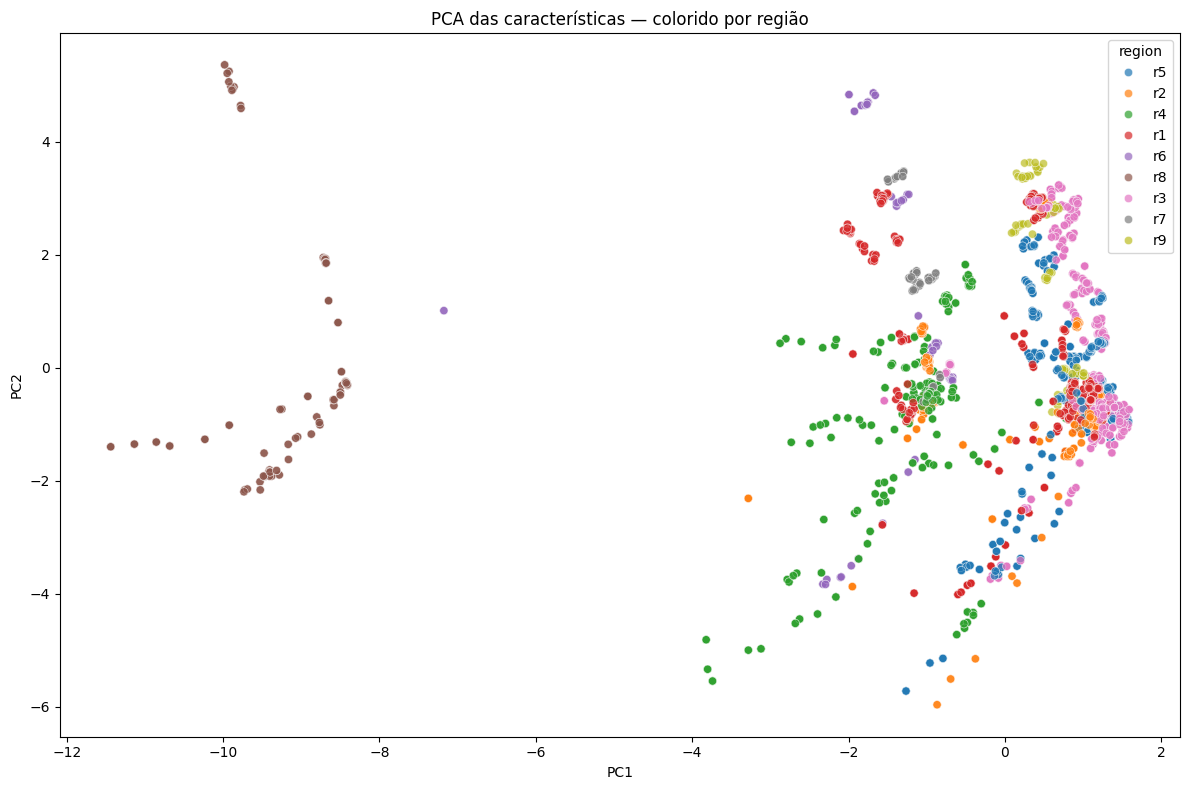

In [49]:
# ============================================================
# PCA — REGIÃO
# ============================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_result,
    x="PC1",
    y="PC2",
    hue="region",
    alpha=0.7
)

plt.title(
    "PCA das características — colorido por região"
)

plt.tight_layout()
plt.show()

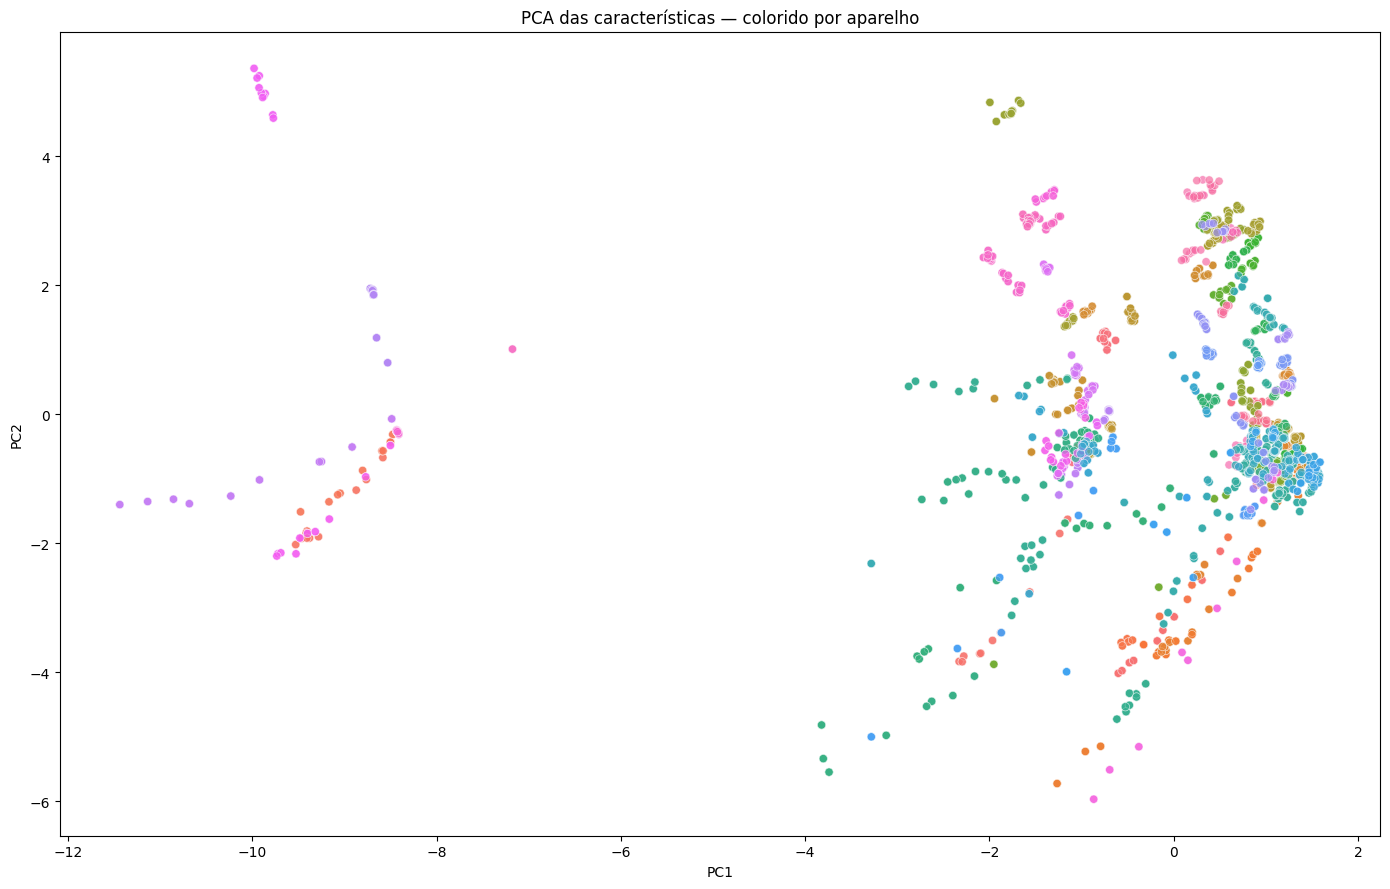

In [50]:
# ============================================================
# PCA — APARELHO
# ============================================================

plt.figure(figsize=(14, 9))

sns.scatterplot(
    data=pca_result,
    x="PC1",
    y="PC2",
    hue="appliance",
    alpha=0.7,
    legend=False
)

plt.title(
    "PCA das características — colorido por aparelho"
)

plt.tight_layout()
plt.show()

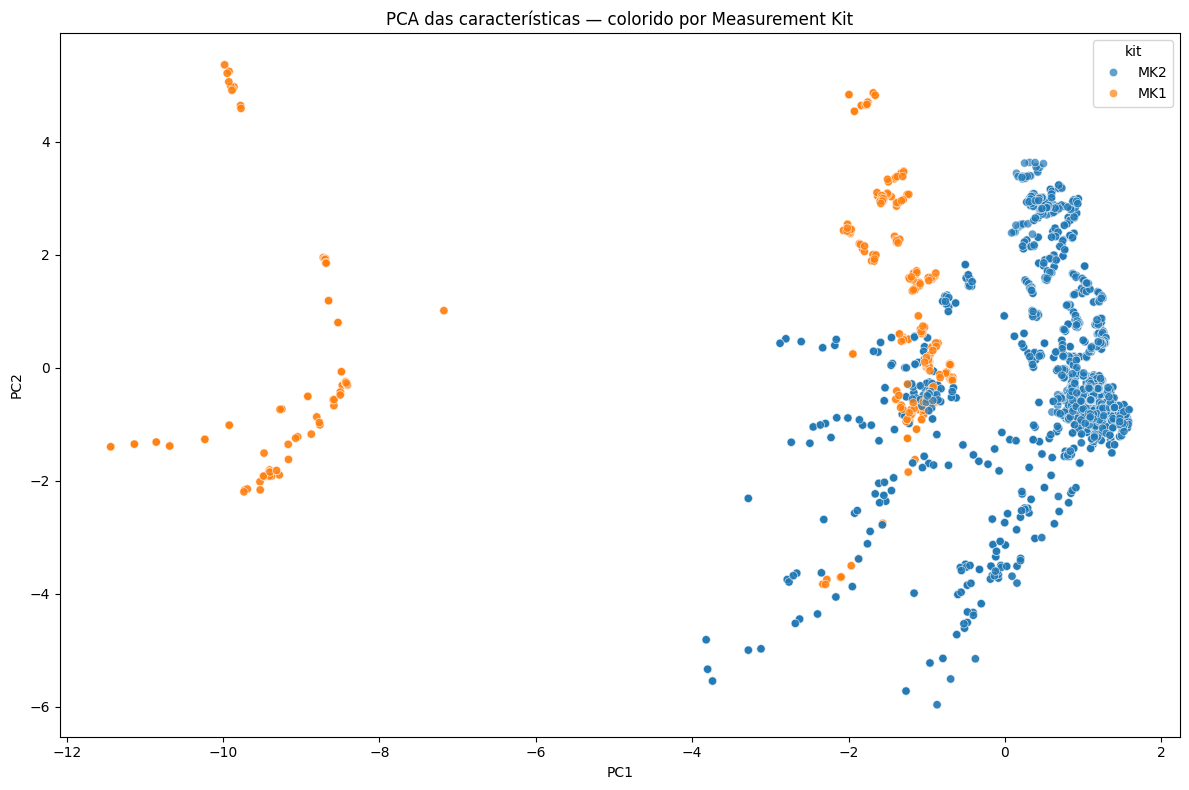

In [51]:
# ============================================================
# PCA — MEASUREMENT KIT
# ============================================================

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=pca_result,
    x="PC1",
    y="PC2",
    hue="kit",
    alpha=0.7
)

plt.title(
    "PCA das características — colorido por Measurement Kit"
)

plt.tight_layout()
plt.show()

In [52]:
# ============================================================
# INSPEÇÃO DAS COLUNAS DE METADATA
# ============================================================

print("=" * 70)
print("COLUNAS DISPONÍVEIS EM METADATA")
print("=" * 70)

print("Colunas:")
for i, col in enumerate(metadata.columns):
    print(f"{i}: {col}")

print("\nPrimeiros registros:")
display(metadata.head())

print("\nÚltimos registros:")
display(metadata.tail())

print("\nTipos das colunas:")
print(metadata.dtypes)

COLUNAS DISPONÍVEIS EM METADATA
Colunas:
0: filename
1: filepath
2: appliance
3: region
4: kit
5: timestamp
6: timestamp_dt
7: parse_ok

Primeiros registros:


,filename,filepath,appliance,region,kit,timestamp,timestamp_dt,parse_ok
0,AC_Electrolux_r5_MK2_20151031065948.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031065948,2015-10-31 06:59:48,True
1,AC_Electrolux_r5_MK2_20151031070257.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070257,2015-10-31 07:02:57,True
2,AC_Electrolux_r5_MK2_20151031070606.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070606,2015-10-31 07:06:06,True
3,AC_Electrolux_r5_MK2_20151031070919.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070919,2015-10-31 07:09:19,True
4,AC_Electrolux_r5_MK2_20151031071229.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031071229,2015-10-31 07:12:29,True



Últimos registros:


,filename,filepath,appliance,region,kit,timestamp,timestamp_dt,parse_ok
5011,HairDryer_BaBylissPro-Stufe2_MK1_2015122910335...,/content/WHITED_v1_1/DATEN/notUsed/NoFaReLab T...,None,None,None,None,NaT,False
5012,HairDryer_BaBylissPro-Stufe2_MK1_2015122910341...,/content/WHITED_v1_1/DATEN/notUsed/NoFaReLab T...,None,None,None,None,NaT,False
5013,HairDryer_BaBylissPro-Stufe2_MK1_2015122910341...,/content/WHITED_v1_1/DATEN/notUsed/NoFaReLab T...,None,None,None,None,NaT,False
5014,HairDryer_BaBylissPro-Stufe2_MK1_2015122910342...,/content/WHITED_v1_1/DATEN/notUsed/NoFaReLab T...,None,None,None,None,NaT,False
5015,HairDryer_BaBylissPro-Stufe2_MK1_2015122910344...,/content/WHITED_v1_1/DATEN/notUsed/NoFaReLab T...,None,None,None,None,NaT,False



Tipos das colunas:
filename                object
filepath                object
appliance               object
region                  object
kit                     object
timestamp               object
timestamp_dt    datetime64[ns]
parse_ok                  bool
dtype: object


In [53]:
# ============================================================
# AUDITORIA E FILTRAGEM DOS REGISTROS VÁLIDOS
# ============================================================

print("=" * 70)
print("AUDITORIA DOS REGISTROS")
print("=" * 70)

print(f"Total de registros: {len(metadata):,}")

# Registros com região válida
valid_region = metadata["region"].notna()

# Registros que passaram pelo parser
valid_parse = metadata["parse_ok"].fillna(False)

# Critério conservador:
# região válida + parser OK
valid_mask = valid_region & valid_parse

print(f"Registros com região válida: {valid_region.sum():,}")
print(f"Registros parse_ok=True:      {valid_parse.sum():,}")
print(f"Registros válidos:            {valid_mask.sum():,}")
print(f"Registros excluídos:          {(~valid_mask).sum():,}")

print("\nDistribuição das regiões válidas:")
print(metadata.loc[valid_mask, "region"].value_counts().sort_index())

print("\nRegistros excluídos:")
display(
    metadata.loc[
        ~valid_mask,
        ["filename", "filepath", "region", "kit", "timestamp", "parse_ok"]
    ].head(20)
)

AUDITORIA DOS REGISTROS
Total de registros: 5,016
Registros com região válida: 3,926
Registros parse_ok=True:      3,926
Registros válidos:            3,926
Registros excluídos:          1,090

Distribuição das regiões válidas:
region
r1    760
r2    580
r3    956
r4    460
r5    700
r6    120
r7    110
r8    160
r9     80
Name: count, dtype: int64

Registros excluídos:


,filename,filepath,region,kit,timestamp,parse_ok
339,ACAC4.5VA_20151124143913.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
340,ACAC4.5VA_20151124144000.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
341,ACAC4.5VA_20151124144017.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
342,ACAC6VA_20151124144155.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
343,ACAC6VA_20151124144202.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
344,ACAC6VA_20151124144210.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/di...,None,None,None,False
345,matthias1.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/sa...,None,None,None,False
346,matthias2.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/sa...,None,None,None,False
347,matthias3.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/sa...,None,None,None,False
348,thomas1.flac,/content/WHITED_v1_1/DATEN/Experiments/ACAC/sa...,None,None,None,False


In [54]:
# ============================================================
# SINCRONIZAR FEATURES E RÓTULOS
# ============================================================

# Garantir que os índices estejam alinhados
metadata = metadata.reset_index(drop=True)

# Máscara dos registros válidos
valid_mask = (
    metadata["region"].notna()
    & metadata["parse_ok"].fillna(False)
)

# Features correspondentes aos registros válidos
X_valid = X_scaled[valid_mask.to_numpy()]

# Rótulos correspondentes
region_labels_valid = (
    metadata.loc[valid_mask, "region"]
    .astype(str)
    .str.lower()
    .reset_index(drop=True)
)

print("=" * 70)
print("DADOS PARA ANÁLISE")
print("=" * 70)

print("X_valid:", X_valid.shape)
print("region_labels_valid:", region_labels_valid.shape)

print("\nDistribuição dos rótulos:")
print(region_labels_valid.value_counts().sort_index())

print("\nNaN nos rótulos:", region_labels_valid.isna().sum())
print("NaN nas features:", np.isnan(X_valid).sum())
print("Inf nas features:", np.isinf(X_valid).sum())

DADOS PARA ANÁLISE
X_valid: (3926, 12)
region_labels_valid: (3926,)

Distribuição dos rótulos:
region
r1    760
r2    580
r3    956
r4    460
r5    700
r6    120
r7    110
r8    160
r9     80
Name: count, dtype: int64

NaN nos rótulos: 0
NaN nas features: 0
Inf nas features: 0


In [55]:
# ============================================================
# SINCRONIZAR FEATURES E RÓTULOS
# ============================================================

# Garantir que os índices estejam alinhados
metadata = metadata.reset_index(drop=True)

# Máscara dos registros válidos
valid_mask = (
    metadata["region"].notna()
    & metadata["parse_ok"].fillna(False)
)

# Features correspondentes aos registros válidos
X_valid = X_scaled[valid_mask.to_numpy()]

# Rótulos correspondentes
region_labels_valid = (
    metadata.loc[valid_mask, "region"]
    .astype(str)
    .str.lower()
    .reset_index(drop=True)
)

print("=" * 70)
print("DADOS PARA ANÁLISE")
print("=" * 70)

print("X_valid:", X_valid.shape)
print("region_labels_valid:", region_labels_valid.shape)

print("\nDistribuição dos rótulos:")
print(region_labels_valid.value_counts().sort_index())

print("\nNaN nos rótulos:", region_labels_valid.isna().sum())
print("NaN nas features:", np.isnan(X_valid).sum())
print("Inf nas features:", np.isinf(X_valid).sum())

DADOS PARA ANÁLISE
X_valid: (3926, 12)
region_labels_valid: (3926,)

Distribuição dos rótulos:
region
r1    760
r2    580
r3    956
r4    460
r5    700
r6    120
r7    110
r8    160
r9     80
Name: count, dtype: int64

NaN nos rótulos: 0
NaN nas features: 0
Inf nas features: 0


In [56]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_valid,
    region_labels_valid
)

print("=" * 70)
print("SILHOUETTE SCORE")
print("=" * 70)
print(f"Silhouette Score = {silhouette:.4f}")

SILHOUETTE SCORE
Silhouette Score = -0.0316


In [57]:
features_df["region"]

,region
0,r5
1,r5
2,r5
3,r5
4,r5
...,...
5011,NaN
5012,NaN
5013,NaN
5014,NaN


In [58]:
flac_files = [
    p for p in flac_files
    if "notUsed" not in str(p)
]

In [59]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(
    X_valid,
    region_labels_valid
)

print("=" * 70)
print("SILHOUETTE SCORE — REGIÕES")
print("=" * 70)
print(f"Silhouette Score = {silhouette:.4f}")

SILHOUETTE SCORE — REGIÕES
Silhouette Score = -0.0316


In [60]:
from sklearn.metrics import silhouette_samples
import pandas as pd
import numpy as np

sil_samples = silhouette_samples(
    X_valid,
    region_labels_valid
)

silhouette_df = pd.DataFrame({
    "region": region_labels_valid,
    "silhouette": sil_samples
})

region_silhouette = (
    silhouette_df
    .groupby("region")["silhouette"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        n="count"
    )
    .sort_values("mean")
)

print("=" * 70)
print("SILHOUETTE POR REGIÃO")
print("=" * 70)

display(region_silhouette)

SILHOUETTE POR REGIÃO


,mean,median,std,min,max,n
region,,,,,,
r6,-0.255417,-0.291721,0.114453,-0.461475,-0.014425,120
r1,-0.184422,-0.147809,0.118379,-0.478819,-0.023678,760
r4,-0.169758,-0.187162,0.214063,-0.634656,0.158891,460
r3,-0.028886,-0.028029,0.095336,-0.258702,0.194283,956
r2,-0.006703,0.054345,0.157692,-0.410278,0.196671,580
r5,0.003973,0.034093,0.104788,-0.331136,0.156667,700
r9,0.155055,0.194239,0.135455,-0.116081,0.338009,80
r7,0.455986,0.567893,0.189859,0.180775,0.625449,110
r8,0.569916,0.606842,0.090866,0.361748,0.658684,160


In [61]:
metadata_valid = metadata.loc[valid_mask].reset_index(drop=True)

In [62]:
from sklearn.metrics import silhouette_score, silhouette_samples
import pandas as pd
import numpy as np

print("=" * 70)
print("ANÁLISE DE SILHOUETTE — WHITED v1.1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Silhouette global
# ------------------------------------------------------------
silhouette_global = silhouette_score(
    X_valid,
    region_labels_valid
)

print(f"\nSilhouette global: {silhouette_global:.4f}")

# ------------------------------------------------------------
# 2. Silhouette individual
# ------------------------------------------------------------
sil_samples = silhouette_samples(
    X_valid,
    region_labels_valid
)

# ------------------------------------------------------------
# 3. DataFrame com resultados individuais
# ------------------------------------------------------------
silhouette_df = pd.DataFrame({
    "region": region_labels_valid,
    "silhouette": sil_samples
})

# ------------------------------------------------------------
# 4. Estatísticas por região
# ------------------------------------------------------------
region_silhouette = (
    silhouette_df
    .groupby("region")["silhouette"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        n="count"
    )
    .sort_values("mean")
)

print("\n" + "=" * 70)
print("SILHOUETTE POR REGIÃO")
print("=" * 70)

display(region_silhouette)

# ------------------------------------------------------------
# 5. Estatísticas gerais adicionais
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("ESTATÍSTICAS GERAIS")
print("=" * 70)

print(f"Média:       {sil_samples.mean():.4f}")
print(f"Mediana:     {np.median(sil_samples):.4f}")
print(f"Desvio-padrão: {sil_samples.std():.4f}")
print(f"Mínimo:      {sil_samples.min():.4f}")
print(f"Máximo:      {sil_samples.max():.4f}")

# ------------------------------------------------------------
# 6. Percentual de amostras com Silhouette negativa
# ------------------------------------------------------------
negative_pct = (sil_samples < 0).mean() * 100
positive_pct = (sil_samples >= 0).mean() * 100

print(f"\nAmostras com Silhouette < 0: {negative_pct:.2f}%")
print(f"Amostras com Silhouette >= 0: {positive_pct:.2f}%")

ANÁLISE DE SILHOUETTE — WHITED v1.1

Silhouette global: -0.0316

SILHOUETTE POR REGIÃO


,mean,median,std,min,max,n
region,,,,,,
r6,-0.255417,-0.291721,0.114453,-0.461475,-0.014425,120
r1,-0.184422,-0.147809,0.118379,-0.478819,-0.023678,760
r4,-0.169758,-0.187162,0.214063,-0.634656,0.158891,460
r3,-0.028886,-0.028029,0.095336,-0.258702,0.194283,956
r2,-0.006703,0.054345,0.157692,-0.410278,0.196671,580
r5,0.003973,0.034093,0.104788,-0.331136,0.156667,700
r9,0.155055,0.194239,0.135455,-0.116081,0.338009,80
r7,0.455986,0.567893,0.189859,0.180775,0.625449,110
r8,0.569916,0.606842,0.090866,0.361748,0.658684,160



ESTATÍSTICAS GERAIS
Média:       -0.0316
Mediana:     -0.0311
Desvio-padrão: 0.2207
Mínimo:      -0.6347
Máximo:      0.6587

Amostras com Silhouette < 0: 60.24%
Amostras com Silhouette >= 0: 39.76%


PCA — WHITED v1.1
Variância explicada por PC1: 0.3716 (37.16%)
Variância explicada por PC2: 0.2483 (24.83%)
Variância acumulada: 0.6199 (61.99%)


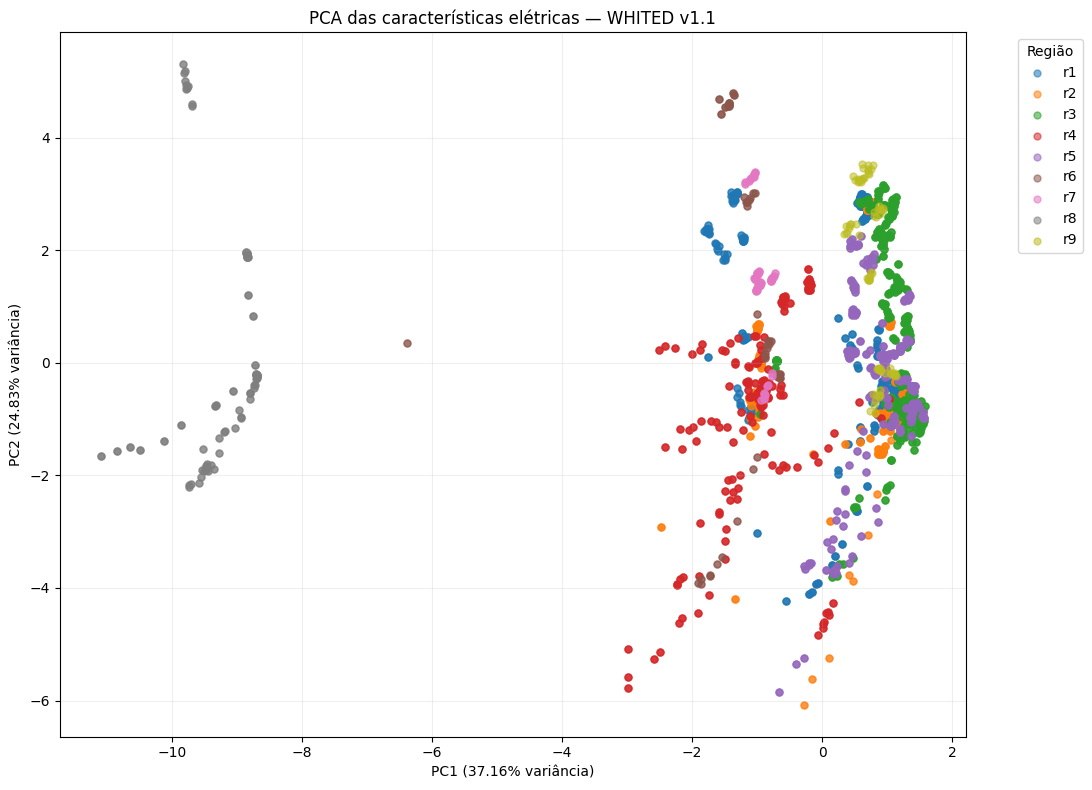

In [63]:
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PCA 2D
# ============================================================

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_valid)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "region": region_labels_valid
})

explained = pca.explained_variance_ratio_

print("=" * 70)
print("PCA — WHITED v1.1")
print("=" * 70)

print(f"Variância explicada por PC1: {explained[0]:.4f} "
      f"({explained[0]*100:.2f}%)")

print(f"Variância explicada por PC2: {explained[1]:.4f} "
      f"({explained[1]*100:.2f}%)")

print(f"Variância acumulada: "
      f"{explained[:2].sum():.4f} "
      f"({explained[:2].sum()*100:.2f}%)")

# ============================================================
# Gráfico
# ============================================================

plt.figure(figsize=(11, 8))

for region in sorted(pca_df["region"].unique()):

    subset = pca_df[pca_df["region"] == region]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.55,
        s=25,
        label=region
    )

plt.xlabel(f"PC1 ({explained[0]*100:.2f}% variância)")
plt.ylabel(f"PC2 ({explained[1]*100:.2f}% variância)")

plt.title("PCA das características elétricas — WHITED v1.1")

plt.legend(
    title="Região",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(alpha=0.2)
plt.tight_layout()

plt.show()

In [64]:
# ============================================================
# DIAGNÓSTICO 1 — Perfil estatístico por região
# WHITED v1.1
# ============================================================

import pandas as pd
import numpy as np

# Nomes das 12 características
feature_names = [f"feature_{i+1}" for i in range(X_valid.shape[1])]

X_region_df = pd.DataFrame(
    X_valid,
    columns=feature_names
)

X_region_df["region"] = region_labels_valid

# Estatísticas por região
region_stats = X_region_df.groupby("region")[feature_names].agg(
    ["mean", "std", "median"]
)

# Mostrar somente r7 e r8
print("=" * 80)
print("PERFIL ESTATÍSTICO — r7 e r8")
print("=" * 80)

display(
    region_stats.loc[["r7", "r8"]]
)

# Diferença de média de r7/r8 em relação à média global
global_mean = X_valid.mean(axis=0)

comparison = pd.DataFrame({
    "feature": feature_names,
    "global_mean": global_mean,
    "r7_mean": X_region_df[X_region_df.region == "r7"][feature_names].mean().values,
    "r8_mean": X_region_df[X_region_df.region == "r8"][feature_names].mean().values,
})

comparison["r7_abs_diff"] = (
    comparison["r7_mean"] - comparison["global_mean"]
).abs()

comparison["r8_abs_diff"] = (
    comparison["r8_mean"] - comparison["global_mean"]
).abs()

comparison["r7_z_like"] = (
    comparison["r7_mean"] - comparison["global_mean"]
) / X_valid.std(axis=0)

comparison["r8_z_like"] = (
    comparison["r8_mean"] - comparison["global_mean"]
) / X_valid.std(axis=0)

print("\n" + "=" * 80)
print("DESVIO DE r7/r8 EM RELAÇÃO AO CONJUNTO GLOBAL")
print("=" * 80)

display(
    comparison.sort_values(
        "r7_abs_diff",
        ascending=False
    )
)

PERFIL ESTATÍSTICO — r7 e r8


feature_1                     feature_2                     feature_3  \
            mean       std    median      mean       std    median      mean   
region                                                                         
r7     -0.820788  0.071091 -0.810899 -0.820590  0.071096 -0.810699 -0.662557   
r8     -4.467607  0.070512 -4.438163 -4.467676  0.070517 -4.438231 -4.551646   

                           feature_4  ... feature_9 feature_10            \
             std    median      mean  ...    median       mean       std   
region                                ...                                  
r7      0.087752 -0.714037  1.603986  ... -0.266976  -0.396318  0.096534   
r8      0.033905 -4.542849 -0.047834  ...  0.167511   0.905103  1.528098   

                 feature_11                    feature_12                      
          median       mean       std   median       mean       std    median  
region                                                                         
r7     -0.437657  -0.286813  0.065827 -0.30922  -0.362328  0.285675 -0.435057  
r8      0.097490   0.127652  0.453263 -0.12067   0.012213  0.589622 -0.102210  

[2 rows x 36 columns]


DESVIO DE r7/r8 EM RELAÇÃO AO CONJUNTO GLOBAL


,feature,global_mean,r7_mean,r8_mean,r7_abs_diff,r8_abs_diff,r7_z_like,r8_z_like
3,feature_4,0.023245,1.603986,-0.047834,1.580741,0.071079,1.661387,-0.074705
0,feature_1,-0.067723,-0.820788,-4.467607,0.753065,4.399884,-0.693692,-4.052989
1,feature_2,-0.067714,-0.820590,-4.467676,0.752876,4.399962,-0.693518,-4.053064
2,feature_3,-0.066072,-0.662557,-4.551646,0.596486,4.485574,-0.547504,-4.117236
7,feature_8,0.030461,0.614510,-0.004808,0.584049,0.035269,0.579334,-0.034985
6,feature_7,0.030462,0.614368,-0.005006,0.583906,0.035468,0.579194,-0.035182
9,feature_10,-0.011306,-0.396318,0.905103,0.385011,0.916410,-0.392011,0.933071
11,feature_12,-0.017726,-0.362328,0.012213,0.344601,0.029939,-0.346782,0.030129
10,feature_11,-0.007150,-0.286813,0.127652,0.279663,0.134803,-0.283202,0.136509
8,feature_9,0.017411,-0.226386,0.838323,0.243796,0.820912,-0.242620,0.816949


In [65]:
# ============================================================
# DIAGNÓSTICO 2 — Região × Kit
# ============================================================

print("=" * 80)
print("DISTRIBUIÇÃO DE KIT POR REGIÃO")
print("=" * 80)

region_kit = pd.crosstab(
    metadata_valid["region"],
    metadata_valid["kit"],
    normalize="index"
) * 100

display(region_kit.round(2))

print("\n" + "=" * 80)
print("CONTAGEM ABSOLUTA — REGIÃO × KIT")
print("=" * 80)

display(
    pd.crosstab(
        metadata_valid["region"],
        metadata_valid["kit"]
    )
)

DISTRIBUIÇÃO DE KIT POR REGIÃO


kit,MK1,MK2
region,,
r1,22.37,77.63
r2,27.59,72.41
r3,3.14,96.86
r4,0.00,100.00
r5,0.00,100.00
r6,100.00,0.00
r7,100.00,0.00
r8,100.00,0.00
r9,0.00,100.00



CONTAGEM ABSOLUTA — REGIÃO × KIT


kit,MK1,MK2
region,,
r1,170,590
r2,160,420
r3,30,926
r4,0,460
r5,0,700
r6,120,0
r7,110,0
r8,160,0
r9,0,80


In [66]:
# ============================================================
# DIAGNÓSTICO 3 — Quantidade de amostras por região
# ============================================================

summary_region = (
    metadata_valid
    .groupby("region")
    .agg(
        n=("filename", "count"),
        n_kits=("kit", "nunique"),
        n_dates=("timestamp_dt", "nunique")
    )
    .sort_values("n", ascending=False)
)

print("=" * 80)
print("ESTRUTURA DAS REGIÕES")
print("=" * 80)

display(summary_region)

ESTRUTURA DAS REGIÕES


,n,n_kits,n_dates
region,,,
r3,956,2,289
r1,760,2,260
r5,700,1,210
r2,580,2,180
r4,460,1,150
r8,160,1,70
r6,120,1,50
r7,110,1,50
r9,80,1,80


In [67]:
# ============================================================
# TESTE CONTROLADO — SOMENTE MK1
# Verificar se r7/r8 continuam separadas quando o kit é fixado
# ============================================================

from sklearn.metrics import silhouette_score, silhouette_samples
import pandas as pd
import numpy as np

mask_mk1 = metadata_valid["kit"].eq("MK1").values

X_mk1 = X_valid[mask_mk1]
y_mk1 = region_labels_valid[mask_mk1]

print("=" * 80)
print("ANÁLISE CONTROLADA — KIT MK1")
print("=" * 80)

print(f"Amostras MK1: {len(X_mk1)}")
print("\nDistribuição regional:")

display(
    pd.Series(y_mk1)
    .value_counts()
    .sort_index()
    .to_frame("n")
)

# Silhouette
sil_mk1 = silhouette_score(X_mk1, y_mk1)

print(f"\nSilhouette global — MK1: {sil_mk1:.4f}")

# Silhouette por região
samples_mk1 = silhouette_samples(X_mk1, y_mk1)

sil_df_mk1 = pd.DataFrame({
    "region": y_mk1,
    "silhouette": samples_mk1
})

sil_region_mk1 = (
    sil_df_mk1
    .groupby("region")["silhouette"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max",
        n="count"
    )
    .sort_values("mean")
)

print("\n" + "=" * 80)
print("SILHOUETTE POR REGIÃO — SOMENTE MK1")
print("=" * 80)

display(sil_region_mk1)

ANÁLISE CONTROLADA — KIT MK1
Amostras MK1: 750

Distribuição regional:


,n
region,
r1,170
r2,160
r3,30
r6,120
r7,110
r8,160



Silhouette global — MK1: 0.1013

SILHOUETTE POR REGIÃO — SOMENTE MK1


,mean,median,std,min,max,n
region,,,,,,
r6,-0.374973,-0.355135,0.237295,-0.662057,-0.014425,120
r1,-0.114218,-0.157996,0.246674,-0.524998,0.277493,170
r2,-0.070308,-0.090423,0.119235,-0.286567,0.160881,160
r7,0.353666,0.553587,0.327593,-0.328106,0.601373,110
r8,0.545269,0.580894,0.087637,0.340526,0.631405,160
r3,0.849707,0.894938,0.096970,0.617059,0.903551,30


In [68]:
# ============================================================
# ANÁLISE DAS CARACTERÍSTICAS — MK1
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

feature_cols = [f"feature_{i+1}" for i in range(X_mk1.shape[1])]

df_mk1 = pd.DataFrame(
    X_mk1,
    columns=feature_cols
)

df_mk1["region"] = y_mk1

# Média por região
means_mk1 = df_mk1.groupby("region")[feature_cols].mean()

print("=" * 80)
print("MÉDIAS DAS 12 CARACTERÍSTICAS — MK1")
print("=" * 80)

display(means_mk1.round(4))

MÉDIAS DAS 12 CARACTERÍSTICAS — MK1


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12
region,,,,,,,,,,,,
r1,-4.4277,-4.4278,-4.5355,-0.5247,5.3916,0.0798,-0.7225,-0.7223,-0.0978,1.4344,0.2707,0.3080
r2,-0.8314,-0.8312,-0.8427,0.0154,-0.1818,-0.1351,-0.2965,-0.2967,-0.4324,0.5942,1.0703,1.3705
r6,-0.9502,-0.9500,-0.9070,0.5274,0.0584,0.0182,-0.0870,-0.0868,0.1511,0.0561,-0.2849,-0.4616
r7,-0.9069,-0.9067,-0.8992,0.2038,-0.1343,-0.1199,-0.4815,-0.4812,-0.7463,-0.3745,-0.1115,0.0698
r8,-0.8734,-0.8732,-0.8600,0.2520,-0.1707,-0.1403,-0.4299,-0.4297,-0.0448,-0.3055,-0.3131,-0.5057


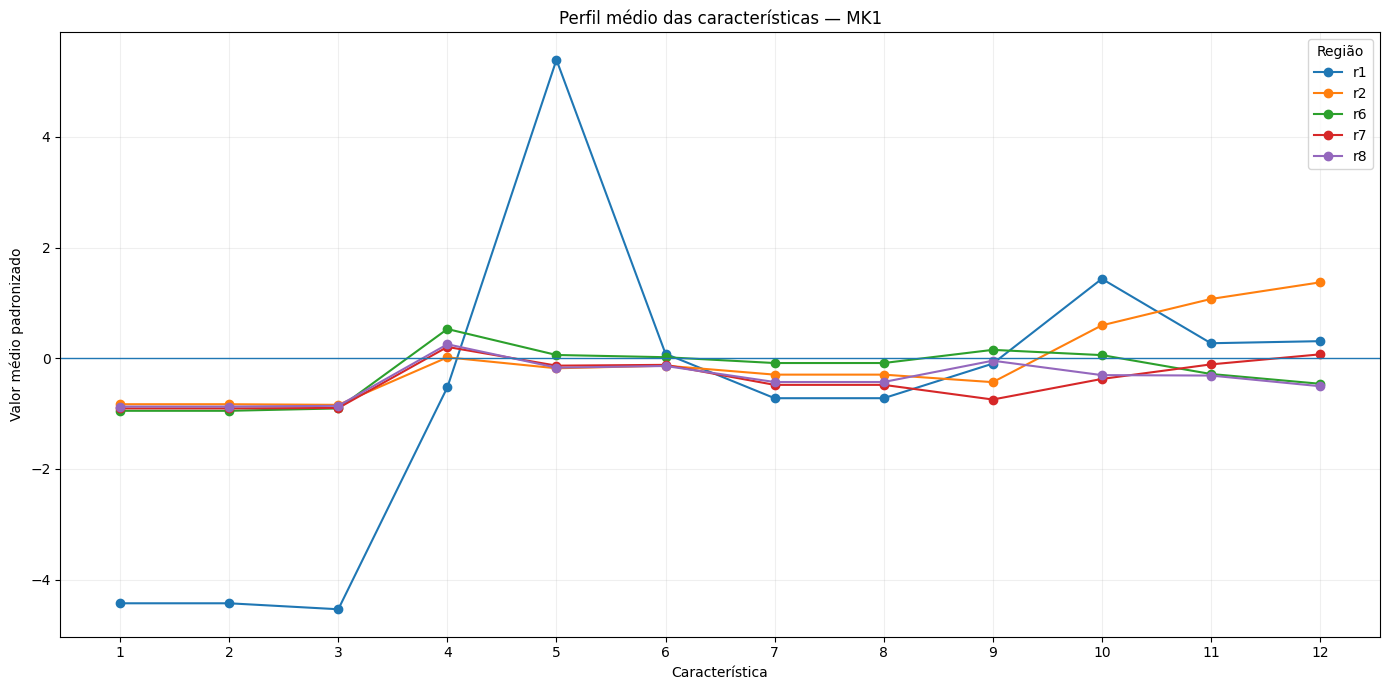

In [69]:
# ============================================================
# GRÁFICO — PERFIL MÉDIO DAS CARACTERÍSTICAS
# ============================================================

plt.figure(figsize=(14, 7))

for region in means_mk1.index:
    plt.plot(
        range(1, len(feature_cols) + 1),
        means_mk1.loc[region].values,
        marker="o",
        label=region
    )

plt.axhline(0, linewidth=1)
plt.xticks(range(1, len(feature_cols) + 1))
plt.xlabel("Característica")
plt.ylabel("Valor médio padronizado")
plt.title("Perfil médio das características — MK1")
plt.legend(title="Região")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# KRUSKAL-WALLIS — DIFERENÇAS ENTRE REGIÕES NO KIT MK1
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 1. Garantir que a região seja tratada como texto
# ------------------------------------------------------------

df_mk1["region"] = df_mk1["region"].astype(str).str.strip()

# Remover possíveis valores inválidos
df_mk1 = df_mk1[
    df_mk1["region"].notna() &
    (df_mk1["region"] != "nan") &
    (df_mk1["region"] != "None")
].copy()

# ------------------------------------------------------------
# 2. Identificar regiões disponíveis
# ------------------------------------------------------------

regions_mk1 = sorted(df_mk1["region"].unique())

print("=" * 70)
print("KRUSKAL-WALLIS — WHITED v1.1 — KIT MK1")
print("=" * 70)

print("\nRegiões analisadas:")
print(regions_mk1)

print("\nNúmero de amostras por região:")
print(df_mk1["region"].value_counts().sort_index())

# ------------------------------------------------------------
# 3. Teste de Kruskal-Wallis para cada característica
# ------------------------------------------------------------

kw_results = []

for feature in feature_cols:

    groups = []

    for region in regions_mk1:

        values = (
            df_mk1.loc[
                df_mk1["region"] == region,
                feature
            ]
            .dropna()
            .values
        )

        groups.append(values)

    # Executar somente se todas as regiões tiverem dados
    if all(len(g) > 0 for g in groups):

        statistic, p_value = kruskal(*groups)

        kw_results.append({
            "feature": feature,
            "H": statistic,
            "p_value": p_value
        })

# ------------------------------------------------------------
# 4. Criar tabela de resultados
# ------------------------------------------------------------

kw_df = pd.DataFrame(kw_results)

# ------------------------------------------------------------
# 5. Correção para múltiplas comparações — FDR Benjamini-Hochberg
# ------------------------------------------------------------

reject, p_adjusted, _, _ = multipletests(
    kw_df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

kw_df["p_fdr"] = p_adjusted
kw_df["significativo"] = reject

# ------------------------------------------------------------
# 6. Ordenar pelo nível de significância
# ------------------------------------------------------------

kw_df = kw_df.sort_values(
    by="p_fdr",
    ascending=True
).reset_index(drop=True)

# ------------------------------------------------------------
# 7. Exibir resultados
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULTADOS")
print("=" * 70)

display(
    kw_df.round({
        "H": 4,
        "p_value": 8,
        "p_fdr": 8
    })
)

# ------------------------------------------------------------
# 8. Resumo
# ------------------------------------------------------------

n_significativos = kw_df["significativo"].sum()

print("\n" + "=" * 70)
print("RESUMO")
print("=" * 70)

print(f"Características avaliadas: {len(kw_df)}")
print(f"Características significativas após FDR: {n_significativos}")

KRUSKAL-WALLIS — WHITED v1.1 — KIT MK1

Regiões analisadas:
['r1', 'r2', 'r6', 'r7', 'r8']

Número de amostras por região:
region
r1    10
r2    20
r6    30
r7    20
r8    20
Name: count, dtype: int64

RESULTADOS


,feature,H,p_value,p_fdr,significativo
0,feature_5,44.7370,0.000000e+00,5.000000e-08,True
1,feature_1,35.5639,3.600000e-07,1.420000e-06,True
2,feature_2,35.5639,3.600000e-07,1.420000e-06,True
3,feature_3,32.9358,1.230000e-06,3.690000e-06,True
4,feature_12,30.8274,3.320000e-06,7.970000e-06,True
5,feature_8,27.5183,1.562000e-05,2.342000e-05,True
6,feature_9,27.9934,1.251000e-05,2.342000e-05,True
7,feature_7,27.5183,1.562000e-05,2.342000e-05,True
8,feature_10,26.7181,2.267000e-05,2.720000e-05,True
9,feature_11,26.7680,2.215000e-05,2.720000e-05,True



RESUMO
Características avaliadas: 12
Características significativas após FDR: 11


In [71]:
# ============================================================
# DIAGNÓSTICO DO SUBCONJUNTO MK1
# ============================================================

print("=" * 70)
print("DIAGNÓSTICO — SUBCONJUNTO MK1")
print("=" * 70)

print("\nX_mk1:")
print(X_mk1.shape)

print("\ny_mk1:")
print(y_mk1.shape)

print("\nDistribuição de y_mk1:")
print(pd.Series(y_mk1).value_counts().sort_index())

print("\nMetadata MK1:")
display(
    metadata_valid.loc[
        metadata_valid["kit"] == "MK1",
        ["filename", "appliance", "region", "kit", "timestamp_dt"]
    ].head(20)
)

DIAGNÓSTICO — SUBCONJUNTO MK1

X_mk1:
(750, 12)

y_mk1:
(750,)

Distribuição de y_mk1:
region
r1    170
r2    160
r3     30
r6    120
r7    110
r8    160
Name: count, dtype: int64

Metadata MK1:


,filename,appliance,region,kit,timestamp_dt
10,AirPump_SimexHB-135C_r2_MK1_20160124164919.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:49:19
11,AirPump_SimexHB-135C_r2_MK1_20160124165057.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:50:57
12,AirPump_SimexHB-135C_r2_MK1_20160124165105.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:51:05
13,AirPump_SimexHB-135C_r2_MK1_20160124165115.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:51:15
14,AirPump_SimexHB-135C_r2_MK1_20160124165124.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:51:24
15,AirPump_SimexHB-135C_r2_MK1_20160124165133.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:51:33
16,AirPump_SimexHB-135C_r2_MK1_20160124165144.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:51:44
17,AirPump_SimexHB-135C_r2_MK1_20160124165201.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:52:01
18,AirPump_SimexHB-135C_r2_MK1_20160124165214.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:52:14
19,AirPump_SimexHB-135C_r2_MK1_20160124165226.flac,AirPump_SimexHB-135C,r2,MK1,2016-01-24 16:52:26


In [72]:
# ============================================================
# RECONSTRUÇÃO CORRETA DO DATAFRAME MK1
# ============================================================

feature_cols = [f"feature_{i+1}" for i in range(X_mk1.shape[1])]

df_mk1 = pd.DataFrame(
    X_mk1,
    columns=feature_cols
)

df_mk1["region"] = pd.Series(y_mk1).astype(str).str.strip()

print("=" * 70)
print("DATAFRAME MK1 RECONSTRUÍDO")
print("=" * 70)

print("\nDimensão:")
print(df_mk1.shape)

print("\nDistribuição regional:")
display(
    df_mk1["region"]
    .value_counts()
    .sort_index()
)

DATAFRAME MK1 RECONSTRUÍDO

Dimensão:
(750, 13)

Distribuição regional:


,count
region,
r1,10
r2,20
r6,30
r7,20
r8,20


In [73]:
# ============================================================
# RECONSTRUÇÃO DEFINITIVA DO SUBCONJUNTO MK1
# ============================================================

# Máscara baseada exclusivamente no metadata original válido
mk1_mask = (
    metadata_valid["kit"].astype(str).str.strip().eq("MK1")
    & metadata_valid["region"].notna()
)

# Características
X_mk1_correct = X_valid[mk1_mask.values]

# Rótulos
y_mk1_correct = (
    metadata_valid.loc[mk1_mask, "region"]
    .astype(str)
    .str.strip()
    .values
)

# DataFrame
feature_cols = [f"feature_{i+1}" for i in range(X_mk1_correct.shape[1])]

df_mk1 = pd.DataFrame(
    X_mk1_correct,
    columns=feature_cols
)

df_mk1["region"] = y_mk1_correct

# ============================================================
# DIAGNÓSTICO
# ============================================================

print("=" * 70)
print("SUBCONJUNTO MK1 — RECONSTRUÇÃO DEFINITIVA")
print("=" * 70)

print(f"\nX_mk1_correct: {X_mk1_correct.shape}")
print(f"y_mk1_correct: {y_mk1_correct.shape}")
print(f"df_mk1:        {df_mk1.shape}")

print("\nDistribuição regional:")
display(
    df_mk1["region"]
    .value_counts()
    .sort_index()
)

print("\nRegiões:")
print(sorted(df_mk1["region"].unique()))

SUBCONJUNTO MK1 — RECONSTRUÇÃO DEFINITIVA

X_mk1_correct: (750, 12)
y_mk1_correct: (750,)
df_mk1:        (750, 13)

Distribuição regional:


,count
region,
r1,170
r2,160
r3,30
r6,120
r7,110
r8,160



Regiões:
['r1', 'r2', 'r3', 'r6', 'r7', 'r8']


In [74]:
# ============================================================
# KRUSKAL-WALLIS — WHITED v1.1 — MK1
# ============================================================

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

regions_mk1 = sorted(df_mk1["region"].unique())

kw_results = []

for feature in feature_cols:

    groups = [
        df_mk1.loc[
            df_mk1["region"] == region,
            feature
        ].dropna().values
        for region in regions_mk1
    ]

    H, p = kruskal(*groups)

    kw_results.append({
        "feature": feature,
        "H": H,
        "p_value": p
    })

kw_df = pd.DataFrame(kw_results)

# ------------------------------------------------------------
# Correção FDR
# ------------------------------------------------------------

reject, p_fdr, _, _ = multipletests(
    kw_df["p_value"],
    alpha=0.05,
    method="fdr_bh"
)

kw_df["p_fdr"] = p_fdr
kw_df["significativo"] = reject

kw_df = kw_df.sort_values(
    "p_fdr"
).reset_index(drop=True)

# ------------------------------------------------------------
# Resultado
# ------------------------------------------------------------

print("=" * 70)
print("KRUSKAL-WALLIS — RESULTADOS")
print("=" * 70)

display(
    kw_df.round({
        "H": 4,
        "p_value": 10,
        "p_fdr": 10
    })
)

print(
    f"\nCaracterísticas significativas após FDR: "
    f"{kw_df['significativo'].sum()} / {len(kw_df)}"
)

KRUSKAL-WALLIS — RESULTADOS


,feature,H,p_value,p_fdr,significativo
0,feature_3,676.2387,0.0,0.0,True
1,feature_1,563.0868,0.0,0.0,True
2,feature_2,563.0868,0.0,0.0,True
3,feature_5,549.4809,0.0,0.0,True
4,feature_4,464.5242,0.0,0.0,True
5,feature_9,246.3822,0.0,0.0,True
6,feature_10,202.9551,0.0,0.0,True
7,feature_11,184.8510,0.0,0.0,True
8,feature_7,113.5100,0.0,0.0,True
9,feature_8,113.5100,0.0,0.0,True



Características significativas após FDR: 12 / 12


In [75]:
# ================================================================
# TESTE PÓS-HOC DE DUNN — SUBCONJUNTO MK1
# ================================================================

!pip -q install scikit-posthocs

import numpy as np
import pandas as pd
import scikit_posthocs as sp

print("=" * 70)
print("TESTE PÓS-HOC DE DUNN — WHITED v1.1 — MK1")
print("=" * 70)

feature_cols = [f"feature_{i+1}" for i in range(X_mk1_correct.shape[1])]

df_mk1_dunn = pd.DataFrame(
    X_mk1_correct,
    columns=feature_cols
)

# IMPORTANTE:
# atribuição posicional para evitar problemas de alinhamento de índice
df_mk1_dunn["region"] = np.asarray(y_mk1_correct).astype(str)

regions = sorted(df_mk1_dunn["region"].unique())

print(f"\nAmostras: {len(df_mk1_dunn)}")
print(f"Características: {len(feature_cols)}")
print(f"Regiões: {regions}")

# ---------------------------------------------------------------
# Dunn para cada característica
# ---------------------------------------------------------------

dunn_results = []

for feature in feature_cols:

    dunn_matrix = sp.posthoc_dunn(
        df_mk1_dunn,
        val_col=feature,
        group_col="region",
        p_adjust="fdr_bh"
    )

    for i, region_a in enumerate(regions):
        for region_b in regions[i+1:]:

            p_value = dunn_matrix.loc[region_a, region_b]

            dunn_results.append({
                "feature": feature,
                "region_a": region_a,
                "region_b": region_b,
                "p_fdr": p_value,
                "significativo": p_value < 0.05
            })

dunn_df = pd.DataFrame(dunn_results)

# ---------------------------------------------------------------
# Ordenação
# ---------------------------------------------------------------

dunn_df = dunn_df.sort_values(
    ["feature", "p_fdr"]
).reset_index(drop=True)

print("\n" + "=" * 70)
print("RESUMO DAS COMPARAÇÕES")
print("=" * 70)

print(
    f"\nComparações totais: {len(dunn_df)}"
)

print(
    f"Comparações significativas: "
    f"{dunn_df['significativo'].sum()}"
)

print(
    f"Percentual significativo: "
    f"{100*dunn_df['significativo'].mean():.2f}%"
)

display(dunn_df.head(30).round(6))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.1 MB/s eta 0:00:00
TESTE PÓS-HOC DE DUNN — WHITED v1.1 — MK1

Amostras: 750
Características: 12
Regiões: ['r1', 'r2', 'r3', 'r6', 'r7', 'r8']

RESUMO DAS COMPARAÇÕES

Comparações totais: 180
Comparações significativas: 150
Percentual significativo: 83.33%


,feature,region_a,region_b,p_fdr,significativo
0,feature_1,r7,r8,0.000000,True
1,feature_1,r6,r8,0.000000,True
2,feature_1,r3,r8,0.000000,True
3,feature_1,r2,r8,0.000000,True
4,feature_1,r1,r7,0.000000,True
5,feature_1,r1,r8,0.000000,True
6,feature_1,r1,r3,0.000000,True
7,feature_1,r2,r7,0.000000,True
8,feature_1,r2,r3,0.000000,True
9,feature_1,r1,r6,0.000000,True


In [76]:
# ================================================================
# TAMANHO DE EFEITO — EPSILON SQUARED
# ================================================================

from scipy.stats import kruskal

effect_results = []

for feature in feature_cols:

    groups = [
        df_mk1_dunn.loc[
            df_mk1_dunn["region"] == region,
            feature
        ].values
        for region in regions
    ]

    H, p = kruskal(*groups)

    k = len(groups)
    n = len(df_mk1_dunn)

    epsilon_squared = (H - k + 1) / (n - k)

    effect_results.append({
        "feature": feature,
        "H": H,
        "epsilon_squared": epsilon_squared,
        "p_value": p
    })

effect_df = pd.DataFrame(effect_results)

effect_df["magnitude"] = pd.cut(
    effect_df["epsilon_squared"],
    bins=[-np.inf, 0.01, 0.06, 0.14, np.inf],
    labels=[
        "pequeno",
        "moderado",
        "grande",
        "muito grande"
    ]
)

effect_df = effect_df.sort_values(
    "epsilon_squared",
    ascending=False
)

display(effect_df.round(5))

,feature,H,epsilon_squared,p_value,magnitude
2,feature_3,676.23867,0.90220,0.0,muito grande
0,feature_1,563.08681,0.75012,0.0,muito grande
1,feature_2,563.08681,0.75012,0.0,muito grande
4,feature_5,549.48087,0.73183,0.0,muito grande
3,feature_4,464.52416,0.61764,0.0,muito grande
8,feature_9,246.38222,0.32444,0.0,muito grande
9,feature_10,202.95510,0.26607,0.0,muito grande
10,feature_11,184.85097,0.24174,0.0,muito grande
6,feature_7,113.50998,0.14585,0.0,muito grande
7,feature_8,113.50998,0.14585,0.0,muito grande


In [77]:
# ================================================================
# PERFIL MÉDIO DAS CARACTERÍSTICAS — MK1
# ================================================================

import matplotlib.pyplot as plt

mean_profile = (
    df_mk1_dunn
    .groupby("region")[feature_cols]
    .mean()
)

print("=" * 70)
print("PERFIL MÉDIO DAS CARACTERÍSTICAS — MK1")
print("=" * 70)

display(mean_profile.round(4))

PERFIL MÉDIO DAS CARACTERÍSTICAS — MK1


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12
region,,,,,,,,,,,,
r1,-0.9769,-0.9767,-0.9342,0.5605,-0.1334,-0.0399,0.6849,0.6851,1.0435,-0.1800,-0.2337,-0.3545
r2,-0.9139,-0.9138,-0.9708,-0.4090,-0.1041,-0.1505,-0.3327,-0.3325,-0.6057,-0.3952,-0.2455,-0.1673
r3,-0.7769,-0.7767,-0.8645,-0.7121,-0.1315,-0.3043,-0.1840,-0.1837,-0.6278,-0.4349,-0.3155,-0.5480
r6,-0.8990,-0.8989,-0.8000,1.0837,-0.1240,0.1174,0.8154,0.8154,-0.0118,-0.0731,0.1536,0.1854
r7,-0.8208,-0.8206,-0.6626,1.6040,-0.1269,0.0360,0.6144,0.6145,-0.2264,-0.3963,-0.2868,-0.3623
r8,-4.4676,-4.4677,-4.5516,-0.0478,5.4349,0.4792,-0.0050,-0.0048,0.8383,0.9051,0.1277,0.0122


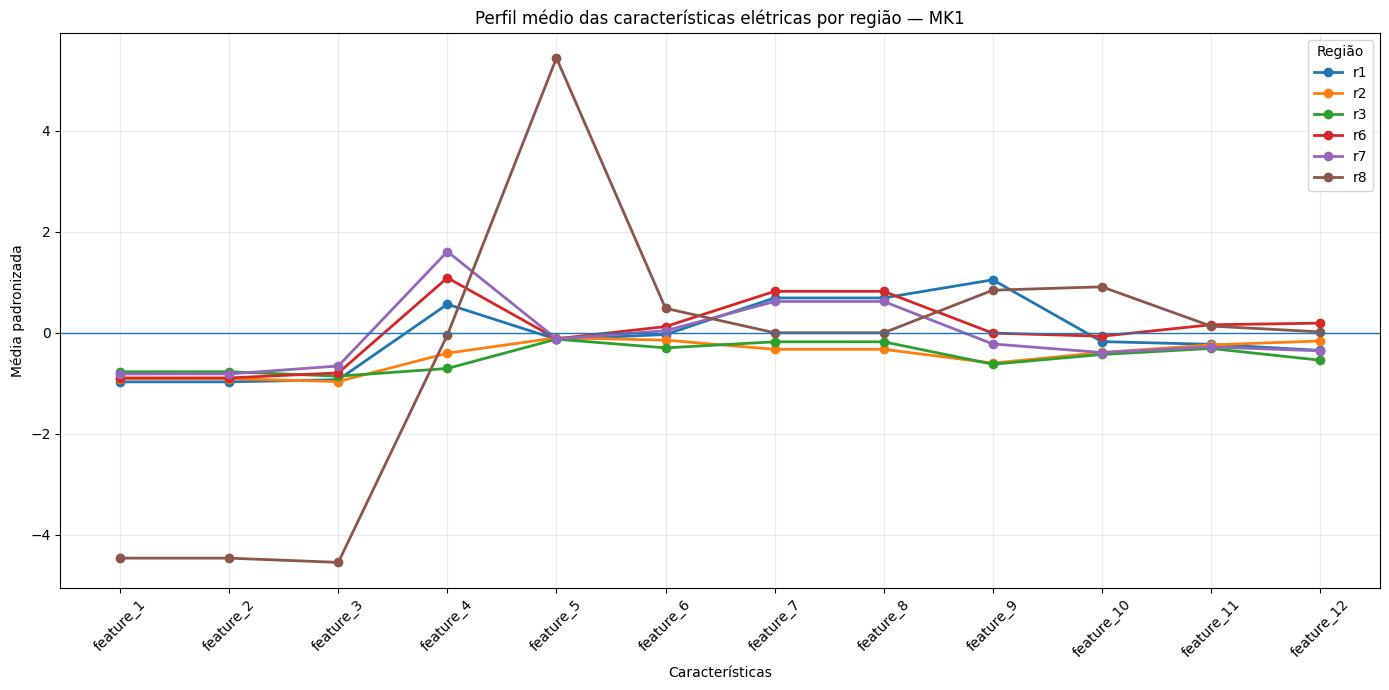

In [78]:
# ================================================================
# GRÁFICO DO PERFIL REGIONAL
# ================================================================

plt.figure(figsize=(14, 7))

for region in regions:
    plt.plot(
        feature_cols,
        mean_profile.loc[region],
        marker="o",
        linewidth=2,
        label=region
    )

plt.axhline(0, linewidth=1)

plt.xlabel("Características")
plt.ylabel("Média padronizada")
plt.title(
    "Perfil médio das características elétricas por região — MK1"
)

plt.xticks(rotation=45)
plt.legend(title="Região")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [79]:
# ================================================================
# CORRELAÇÃO ENTRE AS 12 CARACTERÍSTICAS — MK1
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corr_mk1 = df_mk1_dunn[feature_cols].corr()

print("=" * 70)
print("CORRELAÇÃO ENTRE CARACTERÍSTICAS — MK1")
print("=" * 70)

display(corr_mk1.round(3))

CORRELAÇÃO ENTRE CARACTERÍSTICAS — MK1


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12
feature_1,1.000,1.000,0.998,0.221,-0.990,-0.169,0.106,0.106,-0.271,-0.491,-0.215,-0.105
feature_2,1.000,1.000,0.998,0.221,-0.990,-0.169,0.106,0.106,-0.271,-0.491,-0.215,-0.105
feature_3,0.998,0.998,1.000,0.278,-0.989,-0.164,0.153,0.153,-0.252,-0.498,-0.220,-0.114
feature_4,0.221,0.221,0.278,1.000,-0.239,0.013,0.814,0.814,0.325,-0.284,-0.159,-0.198
feature_5,-0.990,-0.990,-0.989,-0.239,1.000,0.283,-0.133,-0.133,0.265,0.503,0.225,0.118
feature_6,-0.169,-0.169,-0.164,0.013,0.283,1.000,0.020,0.020,0.283,0.271,0.221,0.173
feature_7,0.106,0.106,0.153,0.814,-0.133,0.020,1.000,1.000,0.446,-0.357,-0.323,-0.396
feature_8,0.106,0.106,0.153,0.814,-0.133,0.020,1.000,1.000,0.446,-0.357,-0.323,-0.396
feature_9,-0.271,-0.271,-0.252,0.325,0.265,0.283,0.446,0.446,1.000,0.191,0.056,-0.068
feature_10,-0.491,-0.491,-0.498,-0.284,0.503,0.271,-0.357,-0.357,0.191,1.000,0.682,0.569


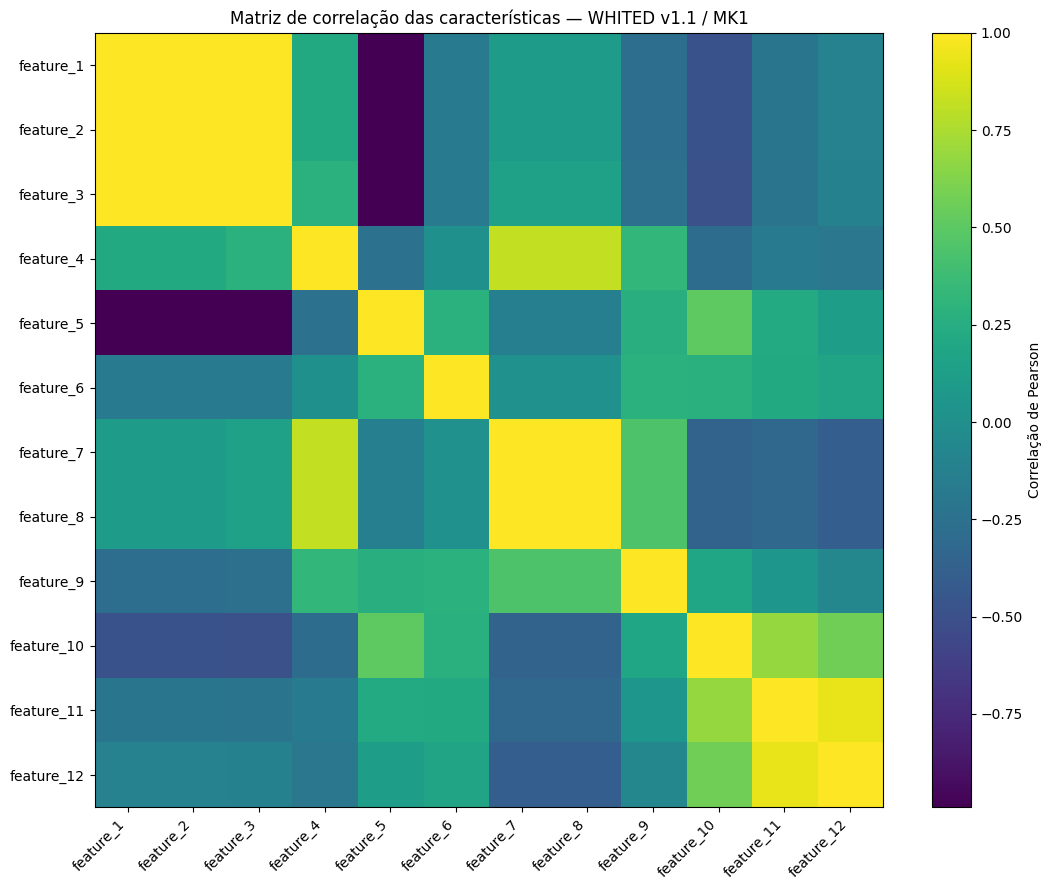

In [80]:
# ================================================================
# HEATMAP DE CORRELAÇÃO
# ================================================================

plt.figure(figsize=(11, 9))

plt.imshow(
    corr_mk1,
    aspect="auto"
)

plt.colorbar(label="Correlação de Pearson")

plt.xticks(
    range(len(feature_cols)),
    feature_cols,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(feature_cols)),
    feature_cols
)

plt.title(
    "Matriz de correlação das características — WHITED v1.1 / MK1"
)

plt.tight_layout()
plt.show()

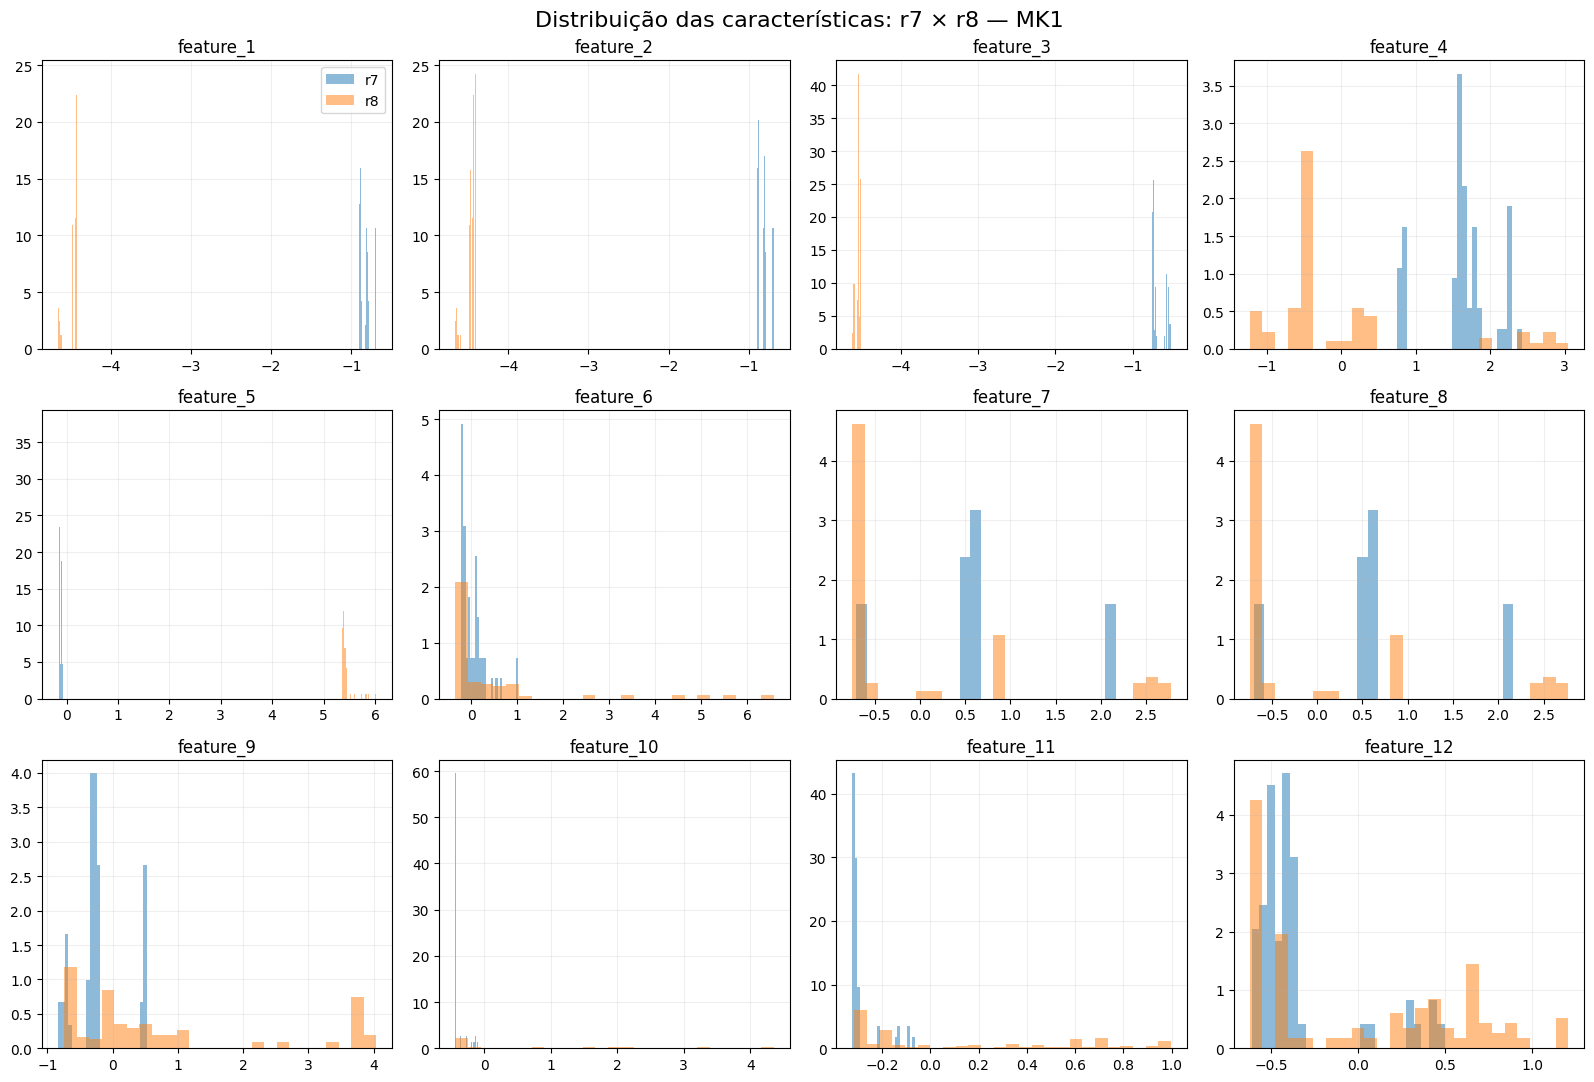

In [81]:
# ================================================================
# DISTRIBUIÇÕES — r7 × r8
# ================================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 4,
    figsize=(16, 11)
)

for i, feature in enumerate(feature_cols):

    ax = axes.flat[i]

    for region in ["r7", "r8"]:

        values = df_mk1_dunn.loc[
            df_mk1_dunn["region"] == region,
            feature
        ]

        ax.hist(
            values,
            bins=25,
            alpha=0.50,
            density=True,
            label=region
        )

    ax.set_title(feature)
    ax.grid(alpha=0.2)

    if i == 0:
        ax.legend()

plt.suptitle(
    "Distribuição das características: r7 × r8 — MK1",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [82]:
# ================================================================
# TAMANHO DE EFEITO ESPECÍFICO: r8 VS DEMAIS REGIÕES
# ================================================================

from scipy.stats import mannwhitneyu

r8_effects = []

for feature in feature_cols:

    r8 = df_mk1_dunn.loc[
        df_mk1_dunn["region"] == "r8",
        feature
    ].values

    for region in ["r1", "r2", "r3", "r6", "r7"]:

        other = df_mk1_dunn.loc[
            df_mk1_dunn["region"] == region,
            feature
        ].values

        U, p = mannwhitneyu(
            r8,
            other,
            alternative="two-sided"
        )

        # Rank-biserial correlation
        n1 = len(r8)
        n2 = len(other)

        r_rb = 1 - (2 * U) / (n1 * n2)

        r8_effects.append({
            "feature": feature,
            "comparacao": f"r8 vs {region}",
            "U": U,
            "p_value": p,
            "rank_biserial": r_rb
        })

r8_effect_df = pd.DataFrame(r8_effects)

display(
    r8_effect_df
    .sort_values(
        "rank_biserial",
        key=lambda x: x.abs(),
        ascending=False
    )
    .round(5)
)

,feature,comparacao,U,p_value,rank_biserial
0,feature_1,r8 vs r1,0.0,0.00000,1.00000
1,feature_1,r8 vs r2,0.0,0.00000,1.00000
2,feature_1,r8 vs r3,0.0,0.00000,1.00000
3,feature_1,r8 vs r6,0.0,0.00000,1.00000
4,feature_1,r8 vs r7,0.0,0.00000,1.00000
5,feature_2,r8 vs r1,0.0,0.00000,1.00000
6,feature_2,r8 vs r2,0.0,0.00000,1.00000
7,feature_2,r8 vs r3,0.0,0.00000,1.00000
8,feature_2,r8 vs r6,0.0,0.00000,1.00000
9,feature_2,r8 vs r7,0.0,0.00000,1.00000


In [83]:
metadata_valid.groupby(
    ["region", "appliance"]
).size()

region  appliance                         
r1      CFL_IKEA15W                           40
        DrillingMachine_Pattfield-E-SB550E    30
        Fan_VOV-50W                           40
        FlatIron_PhilipsB                     30
        HairDryer_RemingtonD3090              30
                                              ..
r9      Iron_Philips-GC1990                   10
        Kettle_WIK9501                        10
        Kettle_WKF-818B                       10
        TV_Philips-42pfl3403                  10
        TV_SonyKDL42W700B                     10
Length: 134, dtype: int64

In [84]:
metadata_valid.groupby(
    ["region", "timestamp_dt"]
).size()

region  timestamp_dt       
r1      2015-10-09 17:31:02    4
        2015-10-09 17:31:22    4
        2015-10-09 17:32:08    4
        2015-10-09 17:32:17    4
        2015-10-09 17:32:53    4
                              ..
r9      2017-05-15 23:49:06    1
        2017-05-15 23:49:14    1
        2017-05-15 23:49:20    1
        2017-05-15 23:49:27    1
        2017-05-15 23:49:34    1
Length: 1339, dtype: int64

In [85]:
metadata_valid.groupby(
    ["region", "appliance", "timestamp_dt"]
).size()

region  appliance          timestamp_dt       
r1      CFL_IKEA15W        2015-10-12 10:36:04    4
                           2015-10-12 10:36:23    4
                           2015-10-12 10:36:37    4
                           2015-10-12 10:37:10    4
                           2015-10-12 10:37:35    4
                                                 ..
r9      TV_SonyKDL42W700B  2017-05-13 16:39:06    1
                           2017-05-13 16:39:18    1
                           2017-05-13 16:39:33    1
                           2017-05-13 16:40:03    1
                           2017-05-13 16:40:53    1
Length: 1339, dtype: int64

In [86]:
metadata_valid.groupby("region")["appliance"].nunique()

,appliance
region,
r1,26
r2,18
r3,29
r4,15
r5,21
r6,5
r7,5
r8,7
r9,8


In [87]:
metadata_valid[
    metadata_valid["kit"] == "MK1"
].groupby("region")["appliance"].nunique()

,appliance
region,
r1,8
r2,6
r3,1
r6,5
r7,5
r8,7


In [88]:
# ==============================================================
# APARELHOS POR REGIÃO — MK1
# ==============================================================

mk1_meta = metadata_valid[
    metadata_valid["kit"] == "MK1"
].copy()

appliances_by_region = (
    mk1_meta
    .groupby("region")["appliance"]
    .unique()
)

for region in sorted(appliances_by_region.index):
    appliances = sorted(appliances_by_region.loc[region])

    print(f"\n{region} — {len(appliances)} aparelhos")
    for appliance in appliances:
        print(f"   {appliance}")


r1 — 8 aparelhos
   DrillingMachine_Pattfield-E-SB550E
   Heater_Heller
   Laptop_Schenker-W503
   Projector_Epson
   VacuumCleaner_Nilfisk
   VacuumCleaner_Vento
   WaterHeater_StiebelEltronSN10S
   WaterHeater_StiebelEltronSNU5S

r2 — 6 aparelhos
   AirPump_SimexHB-135C
   Fan_Salco-STT23-1
   KitchenHood_AmicaUH17051
   RiceCooker_PanasonicSRG06
   RiceCooker_arendo301224
   SandwichMaker_ClatronicST3011

r3 — 1 aparelhos
   HairDryer_BraunSatinHair

r6 — 5 aparelhos
   CFL_PhilipsGenie8W
   Fan_ChingHai35W
   HairDryer_BaBylissPro
   Kettle_TCM
   WaterHeater_AustriaEmailKRU052-A

r7 — 5 aparelhos
   CoffeeMachine_SIEMENS
   Kettle_ClatronicWK3462
   LightBulb_PhilipsClassicTone40W
   Stove_sOlac
   Toaster_PhilipsHD2567

r8 — 7 aparelhos
   CableModem_MotorolaSB5102
   CableReceiver_MotorolaDCT700
   Fridge_Danby
   Laptop_Lenovo-IdeapadS11
   Microwave_Whirlpool
   NetworkSwitch_DLink-DGS1008D
   TV_Toshiba43L31OU


In [89]:
# ==============================================================
# SOBREPOSIÇÃO DE APARELHOS ENTRE REGIÕES — MK1
# ==============================================================

regions_mk1 = sorted(mk1_meta["region"].unique())

appliance_sets = {
    region: set(
        mk1_meta.loc[
            mk1_meta["region"] == region,
            "appliance"
        ].unique()
    )
    for region in regions_mk1
}

print("=" * 70)
print("SOBREPOSIÇÃO DE APARELHOS — MK1")
print("=" * 70)

for i, r_a in enumerate(regions_mk1):
    for r_b in regions_mk1[i+1:]:

        intersection = appliance_sets[r_a] & appliance_sets[r_b]
        union = appliance_sets[r_a] | appliance_sets[r_b]

        jaccard = (
            len(intersection) / len(union)
            if len(union) > 0 else 0
        )

        print(
            f"{r_a} vs {r_b}: "
            f"{len(intersection)} em comum | "
            f"Jaccard = {jaccard:.3f}"
        )

SOBREPOSIÇÃO DE APARELHOS — MK1
r1 vs r2: 0 em comum | Jaccard = 0.000
r1 vs r3: 0 em comum | Jaccard = 0.000
r1 vs r6: 0 em comum | Jaccard = 0.000
r1 vs r7: 0 em comum | Jaccard = 0.000
r1 vs r8: 0 em comum | Jaccard = 0.000
r2 vs r3: 0 em comum | Jaccard = 0.000
r2 vs r6: 0 em comum | Jaccard = 0.000
r2 vs r7: 0 em comum | Jaccard = 0.000
r2 vs r8: 0 em comum | Jaccard = 0.000
r3 vs r6: 0 em comum | Jaccard = 0.000
r3 vs r7: 0 em comum | Jaccard = 0.000
r3 vs r8: 0 em comum | Jaccard = 0.000
r6 vs r7: 0 em comum | Jaccard = 0.000
r6 vs r8: 0 em comum | Jaccard = 0.000
r7 vs r8: 0 em comum | Jaccard = 0.000


In [90]:
# ==============================================================
# R7 × R8 — COMPOSIÇÃO DOS APARELHOS
# ==============================================================

r78 = mk1_meta[
    mk1_meta["region"].isin(["r7", "r8"])
].copy()

composition_r78 = pd.crosstab(
    r78["appliance"],
    r78["region"]
)

print(composition_r78)

region                           r7  r8
appliance                              
CableModem_MotorolaSB5102         0  20
CableReceiver_MotorolaDCT700      0  20
CoffeeMachine_SIEMENS            20   0
Fridge_Danby                      0  30
Kettle_ClatronicWK3462           30   0
Laptop_Lenovo-IdeapadS11          0  30
LightBulb_PhilipsClassicTone40W  20   0
Microwave_Whirlpool               0  20
NetworkSwitch_DLink-DGS1008D      0  20
Stove_sOlac                      20   0
TV_Toshiba43L31OU                 0  20
Toaster_PhilipsHD2567            20   0


In [91]:
print("\nNúmero de observações por aparelho:")
print(
    r78.groupby(
        ["region", "appliance"]
    ).size()
)


Número de observações por aparelho:
region  appliance                      
r7      CoffeeMachine_SIEMENS              20
        Kettle_ClatronicWK3462             30
        LightBulb_PhilipsClassicTone40W    20
        Stove_sOlac                        20
        Toaster_PhilipsHD2567              20
r8      CableModem_MotorolaSB5102          20
        CableReceiver_MotorolaDCT700       20
        Fridge_Danby                       30
        Laptop_Lenovo-IdeapadS11           30
        Microwave_Whirlpool                20
        NetworkSwitch_DLink-DGS1008D       20
        TV_Toshiba43L31OU                  20
dtype: int64


In [92]:
# ==============================================================
# TIPO FUNCIONAL DO APARELHO
# ==============================================================

mk1_meta = metadata_valid[
    metadata_valid["kit"] == "MK1"
].copy()

mk1_meta["appliance_type"] = (
    mk1_meta["appliance"]
    .str.split("_")
    .str[0]
)

print(
    pd.crosstab(
        mk1_meta["region"],
        mk1_meta["appliance_type"]
    )
)

appliance_type  AirPump  CFL  CableModem  CableReceiver  CoffeeMachine  \
region                                                                   
r1                    0    0           0              0              0   
r2                   20    0           0              0              0   
r3                    0    0           0              0              0   
r6                    0   20           0              0              0   
r7                    0    0           0              0             20   
r8                    0    0          20             20              0   

appliance_type  DrillingMachine  Fan  Fridge  HairDryer  Heater  ...  \
region                                                           ...   
r1                           30    0       0          0      20  ...   
r2                            0   30       0          0       0  ...   
r3                            0    0       0         30       0  ...   
r6                            0   30       0   

In [93]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    mk1_meta["region"],
    mk1_meta["appliance_type"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("=" * 70)
print("ASSOCIAÇÃO ENTRE REGIÃO E TIPO DE APARELHO — MK1")
print("=" * 70)
print(f"Qui-quadrado = {chi2:.4f}")
print(f"p-valor      = {p:.4e}")
print(f"gl           = {dof}")

ASSOCIAÇÃO ENTRE REGIÃO E TIPO DE APARELHO — MK1
Qui-quadrado = 2763.5667
p-valor      = 0.0000e+00
gl           = 115


In [94]:
import numpy as np

n = contingency.to_numpy().sum()
phi2 = chi2 / n

r, k = contingency.shape

cramers_v = np.sqrt(
    phi2 / min(k - 1, r - 1)
)

print(f"Cramér's V = {cramers_v:.4f}")

Cramér's V = 0.8585


In [95]:
# ==============================================================
# TIPOS FUNCIONAIS COMPARTILHADOS ENTRE REGIÕES — MK1
# ==============================================================

type_region = pd.crosstab(
    mk1_meta["appliance_type"],
    mk1_meta["region"]
)

shared_types = type_region[
    (type_region > 0).sum(axis=1) > 1
]

print("=" * 70)
print("TIPOS FUNCIONAIS PRESENTES EM MAIS DE UMA REGIÃO — MK1")
print("=" * 70)

print(shared_types)

print("\nNúmero de tipos compartilhados:",
      len(shared_types))

TIPOS FUNCIONAIS PRESENTES EM MAIS DE UMA REGIÃO — MK1
region          r1  r2  r3  r6  r7  r8
appliance_type                        
Fan              0  30   0  30   0   0
HairDryer        0   0  30  20   0   0
Kettle           0   0   0  30  30   0
Laptop          20   0   0   0   0  30
WaterHeater     40   0   0  20   0   0

Número de tipos compartilhados: 5


In [96]:
# ==============================================================
# PUREZA REGIONAL DOS TIPOS DE APARELHO
# ==============================================================

type_region_prop = type_region.div(
    type_region.sum(axis=1),
    axis=0
)

type_purity = type_region_prop.max(axis=1)

purity_df = pd.DataFrame({
    "appliance_type": type_purity.index,
    "region_purity": type_purity.values
}).sort_values(
    "region_purity",
    ascending=False
)

print("=" * 70)
print("PUREZA REGIONAL DOS TIPOS — MK1")
print("=" * 70)

print(purity_df.to_string(index=False))

PUREZA REGIONAL DOS TIPOS — MK1
 appliance_type  region_purity
        AirPump       1.000000
            CFL       1.000000
     CableModem       1.000000
  CableReceiver       1.000000
  CoffeeMachine       1.000000
DrillingMachine       1.000000
         Fridge       1.000000
         Heater       1.000000
             TV       1.000000
    KitchenHood       1.000000
      Microwave       1.000000
      LightBulb       1.000000
  NetworkSwitch       1.000000
  SandwichMaker       1.000000
     RiceCooker       1.000000
      Projector       1.000000
  VacuumCleaner       1.000000
        Toaster       1.000000
          Stove       1.000000
    WaterHeater       0.666667
         Laptop       0.600000
      HairDryer       0.600000
            Fan       0.500000
         Kettle       0.500000


In [97]:
# ==============================================================
# PROPORÇÃO DE OBSERVAÇÕES COM TIPO EXCLUSIVO
# ==============================================================

type_region_count = (
    mk1_meta
    .groupby("appliance_type")["region"]
    .nunique()
)

exclusive_types = type_region_count[
    type_region_count == 1
].index

exclusive_mask = mk1_meta["appliance_type"].isin(
    exclusive_types
)

print("=" * 70)
print("EXCLUSIVIDADE DOS TIPOS FUNCIONAIS — MK1")
print("=" * 70)

print(
    f"Tipos funcionais exclusivos: "
    f"{len(exclusive_types)} / "
    f"{len(type_region_count)}"
)

print(
    f"Observações pertencentes a tipos exclusivos: "
    f"{exclusive_mask.sum()} / {len(mk1_meta)} "
    f"({exclusive_mask.mean()*100:.2f}%)"
)

EXCLUSIVIDADE DOS TIPOS FUNCIONAIS — MK1
Tipos funcionais exclusivos: 19 / 24
Observações pertencentes a tipos exclusivos: 470 / 750 (62.67%)


In [98]:
# ==============================================================
# SUBCONJUNTO DE TIPOS FUNCIONAIS COMPARTILHADOS
# ==============================================================

shared_type_names = shared_types.index

mk1_shared = mk1_meta[
    mk1_meta["appliance_type"].isin(shared_type_names)
].copy()

print("=" * 70)
print("SUBCONJUNTO COM TIPOS FUNCIONAIS COMPARTILHADOS")
print("=" * 70)

print(f"Observações: {len(mk1_shared)}")

print("\nDistribuição por região:")
print(
    mk1_shared["region"].value_counts()
    .sort_index()
)

print("\nDistribuição região × tipo:")
print(
    pd.crosstab(
        mk1_shared["region"],
        mk1_shared["appliance_type"]
    )
)

SUBCONJUNTO COM TIPOS FUNCIONAIS COMPARTILHADOS
Observações: 280

Distribuição por região:
region
r1     60
r2     30
r3     30
r6    100
r7     30
r8     30
Name: count, dtype: int64

Distribuição região × tipo:
appliance_type  Fan  HairDryer  Kettle  Laptop  WaterHeater
region                                                     
r1                0          0       0      20           40
r2               30          0       0       0            0
r3                0         30       0       0            0
r6               30         20      30       0           20
r7                0          0      30       0            0
r8                0          0       0      30            0


In [99]:
for appliance_type in shared_type_names:
    subset = mk1_shared[
        mk1_shared["appliance_type"] == appliance_type
    ]

    print(
        appliance_type,
        subset["region"].value_counts().to_dict()
    )

Fan {'r6': 30, 'r2': 30}
HairDryer {'r3': 30, 'r6': 20}
Kettle {'r7': 30, 'r6': 30}
Laptop {'r8': 30, 'r1': 20}
WaterHeater {'r1': 40, 'r6': 20}


Teste de modelo de ML

In [100]:
# ==============================================================
# EXPERIMENTO 1 — RANDOM FOREST + GROUPKFold
# Preparação dos dados
# ==============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

# --------------------------------------------------------------
# Verificação das estruturas existentes
# --------------------------------------------------------------

print("=" * 70)
print("VERIFICAÇÃO DAS ESTRUTURAS")
print("=" * 70)

print("features_df:", features_df.shape)
print("metadata:", metadata.shape)

print("\nColunas de metadata:")
print(metadata.columns.tolist())

print("\nColunas de features:")
print(features_df.columns.tolist())

VERIFICAÇÃO DAS ESTRUTURAS
features_df: (5016, 34)
metadata: (5016, 8)

Colunas de metadata:
['filename', 'filepath', 'appliance', 'region', 'kit', 'timestamp', 'timestamp_dt', 'parse_ok']

Colunas de features:
['filepath', 'ch0_mean', 'ch0_std', 'ch0_rms', 'ch0_peak', 'ch0_peak_to_peak', 'ch0_crest_factor', 'ch0_energy', 'ch0_skewness', 'ch0_kurtosis', 'ch0_spectral_centroid', 'ch0_spectral_bandwidth', 'ch0_dominant_frequency', 'ch0_spectral_energy', 'ch1_mean', 'ch1_std', 'ch1_rms', 'ch1_peak', 'ch1_peak_to_peak', 'ch1_crest_factor', 'ch1_energy', 'ch1_skewness', 'ch1_kurtosis', 'ch1_spectral_centroid', 'ch1_spectral_bandwidth', 'ch1_dominant_frequency', 'ch1_spectral_energy', 'filename', 'appliance', 'region', 'kit', 'timestamp', 'timestamp_dt', 'parse_ok']


In [101]:
print("Shape features_df:", features_df.shape)
print("\nColunas de features_df:")
print(features_df.columns.tolist())

Shape features_df: (5016, 34)

Colunas de features_df:
['filepath', 'ch0_mean', 'ch0_std', 'ch0_rms', 'ch0_peak', 'ch0_peak_to_peak', 'ch0_crest_factor', 'ch0_energy', 'ch0_skewness', 'ch0_kurtosis', 'ch0_spectral_centroid', 'ch0_spectral_bandwidth', 'ch0_dominant_frequency', 'ch0_spectral_energy', 'ch1_mean', 'ch1_std', 'ch1_rms', 'ch1_peak', 'ch1_peak_to_peak', 'ch1_crest_factor', 'ch1_energy', 'ch1_skewness', 'ch1_kurtosis', 'ch1_spectral_centroid', 'ch1_spectral_bandwidth', 'ch1_dominant_frequency', 'ch1_spectral_energy', 'filename', 'appliance', 'region', 'kit', 'timestamp', 'timestamp_dt', 'parse_ok']


In [102]:
import pandas as pd
import numpy as np

# ============================================================
# DATAFRAME PARA MODELAGEM SUPERVISIONADA
# ============================================================

feature_cols = [f"feature_{i+1}" for i in range(X_valid.shape[1])]

df_model = pd.DataFrame(
    X_valid,
    columns=feature_cols
)

# Metadados já filtrados para os 3926 registros válidos
df_model["filename"] = metadata_valid["filename"].values
df_model["filepath"] = metadata_valid["filepath"].values
df_model["appliance"] = metadata_valid["appliance"].values
df_model["region"] = metadata_valid["region"].values
df_model["kit"] = metadata_valid["kit"].values
df_model["timestamp"] = metadata_valid["timestamp"].values
df_model["timestamp_dt"] = metadata_valid["timestamp_dt"].values

# Tipo funcional do aparelho
df_model["appliance_type"] = (
    df_model["appliance"]
    .astype(str)
    .str.split("_")
    .str[0]
)

print("=" * 70)
print("DATAFRAME DE MODELAGEM")
print("=" * 70)

print("Shape:", df_model.shape)
print("\nFeatures:")
print(feature_cols)

print("\nDistribuição por região:")
print(df_model["region"].value_counts().sort_index())

print("\nDistribuição por kit:")
print(df_model["kit"].value_counts().sort_index())

print("\nPrimeiras linhas:")
display(df_model.head())

DATAFRAME DE MODELAGEM
Shape: (3926, 20)

Features:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12']

Distribuição por região:
region
r1    760
r2    580
r3    956
r4    460
r5    700
r6    120
r7    110
r8    160
r9     80
Name: count, dtype: int64

Distribuição por kit:
kit
MK1     750
MK2    3176
Name: count, dtype: int64

Primeiras linhas:


,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,filename,filepath,appliance,region,kit,timestamp,timestamp_dt,appliance_type
0,0.480911,0.480990,0.392457,-0.801841,-0.332619,-0.570359,-0.102330,-0.102099,0.617973,-0.278311,-0.323386,-0.623598,AC_Electrolux_r5_MK2_20151031065948.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031065948,2015-10-31 06:59:48,AC
1,0.484938,0.484965,0.398833,-0.783352,-0.346201,-0.558837,-0.128276,-0.128042,0.615450,-0.270373,-0.323287,-0.621358,AC_Electrolux_r5_MK2_20151031070257.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070257,2015-10-31 07:02:57,AC
2,0.351411,0.351303,0.264948,-0.778457,-0.402861,-0.574544,-0.120330,-0.120099,0.606622,-0.274157,-0.322876,-0.617951,AC_Electrolux_r5_MK2_20151031070606.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070606,2015-10-31 07:06:06,AC
3,0.484678,0.484682,0.410875,-0.685295,-0.349018,-0.562940,-0.135973,-0.135740,0.592118,-0.270990,-0.316655,-0.596642,AC_Electrolux_r5_MK2_20151031070919.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031070919,2015-10-31 07:09:19,AC
4,0.457104,0.457161,0.379706,-0.712125,-0.258915,-0.550724,-0.123562,-0.123337,0.603258,-0.273565,-0.313444,-0.587498,AC_Electrolux_r5_MK2_20151031071229.flac,/content/WHITED_v1_1/DATEN/AC_Electrolux_r5_MK...,AC_Electrolux,r5,MK2,20151031071229,2015-10-31 07:12:29,AC


In [103]:
print("NaN nas features:")
print(df_model[feature_cols].isna().sum().sum())

print("\nInf nas features:")
print(np.isinf(df_model[feature_cols].to_numpy()).sum())

print("\nNaN em region:")
print(df_model["region"].isna().sum())

print("\nNaN em appliance:")
print(df_model["appliance"].isna().sum())

print("\nNaN em kit:")
print(df_model["kit"].isna().sum())

NaN nas features:
0

Inf nas features:
0

NaN em region:
0

NaN em appliance:
0

NaN em kit:
0


In [104]:
# ============================================================
# AUDITORIA DA UNIDADE DE AGRUPAMENTO
# ============================================================

print("=" * 80)
print("AUDITORIA — APARELHOS INDEPENDENTES POR REGIÃO E KIT")
print("=" * 80)

# Número de aparelhos distintos por região
appliances_region = (
    df_model.groupby("region")["appliance"]
    .nunique()
    .sort_index()
)

print("\nAparelhos independentes por região:")
display(appliances_region.to_frame("n_appliances"))

# Região × kit × aparelhos
region_kit_appliances = (
    df_model.groupby(["kit", "region"])["appliance"]
    .nunique()
    .reset_index(name="n_appliances")
)

print("\nAparelhos independentes por KIT × região:")
display(
    region_kit_appliances
    .sort_values(["kit", "region"])
    .reset_index(drop=True)
)

# Número de observações por aparelho
appliance_counts = (
    df_model.groupby(["region", "kit", "appliance"])
    .size()
    .reset_index(name="n_observations")
)

print("\nResumo das observações por aparelho:")
display(
    appliance_counts["n_observations"]
    .describe()
)

print("\nPrimeiros aparelhos:")
display(appliance_counts.head(20))

AUDITORIA — APARELHOS INDEPENDENTES POR REGIÃO E KIT

Aparelhos independentes por região:


,n_appliances
region,
r1,26
r2,18
r3,29
r4,15
r5,21
r6,5
r7,5
r8,7
r9,8



Aparelhos independentes por KIT × região:


,kit,region,n_appliances
0,MK1,r1,8
1,MK1,r2,6
2,MK1,r3,1
3,MK1,r6,5
4,MK1,r7,5
5,MK1,r8,7
6,MK2,r1,18
7,MK2,r2,12
8,MK2,r3,28
9,MK2,r4,15



Resumo das observações por aparelho:


,n_observations
count,134.000000
mean,29.298507
std,8.027237
min,10.000000
25%,30.000000
50%,30.000000
75%,30.000000
max,50.000000



Primeiros aparelhos:


,region,kit,appliance,n_observations
0,r1,MK1,DrillingMachine_Pattfield-E-SB550E,30
1,r1,MK1,Heater_Heller,20
2,r1,MK1,Laptop_Schenker-W503,20
3,r1,MK1,Projector_Epson,20
4,r1,MK1,VacuumCleaner_Nilfisk,20
5,r1,MK1,VacuumCleaner_Vento,20
6,r1,MK1,WaterHeater_StiebelEltronSN10S,20
7,r1,MK1,WaterHeater_StiebelEltronSNU5S,20
8,r1,MK2,CFL_IKEA15W,40
9,r1,MK2,Fan_VOV-50W,40


In [105]:
# ============================================================
# AUDITORIA TEMPORAL POR APARELHO
# ============================================================

print("=" * 80)
print("AUDITORIA TEMPORAL")
print("=" * 80)

temporal = (
    df_model
    .groupby(["region", "kit", "appliance"])
    .agg(
        n_obs=("filename", "size"),
        n_timestamps=("timestamp_dt", "nunique"),
        inicio=("timestamp_dt", "min"),
        fim=("timestamp_dt", "max")
    )
    .reset_index()
)

display(temporal.head(20))

print("\nNúmero de grupos aparelho × timestamp:")
print(
    df_model
    .groupby(["appliance", "timestamp_dt"])
    .size()
    .describe()
)

print("\nDuplicidade temporal:")
print(
    df_model
    .duplicated(
        subset=["appliance", "timestamp_dt"]
    )
    .sum()
)

AUDITORIA TEMPORAL


,region,kit,appliance,n_obs,n_timestamps,inicio,fim
0,r1,MK1,DrillingMachine_Pattfield-E-SB550E,30,10,2016-01-28 13:30:16,2016-01-28 13:33:07
1,r1,MK1,Heater_Heller,20,10,2015-12-02 12:47:54,2015-12-02 12:49:17
2,r1,MK1,Laptop_Schenker-W503,20,10,2016-01-26 16:10:33,2016-01-26 16:13:57
3,r1,MK1,Projector_Epson,20,10,2015-12-03 14:21:58,2015-12-03 14:31:03
4,r1,MK1,VacuumCleaner_Nilfisk,20,10,2015-12-03 14:02:59,2015-12-03 14:06:59
5,r1,MK1,VacuumCleaner_Vento,20,10,2015-12-03 13:40:57,2015-12-03 13:43:36
6,r1,MK1,WaterHeater_StiebelEltronSN10S,20,10,2016-01-26 15:35:33,2016-01-26 15:36:48
7,r1,MK1,WaterHeater_StiebelEltronSNU5S,20,10,2016-01-26 15:27:35,2016-01-26 15:29:13
8,r1,MK2,CFL_IKEA15W,40,10,2015-10-12 10:36:04,2015-10-12 10:39:18
9,r1,MK2,Fan_VOV-50W,40,10,2015-10-09 18:24:13,2015-10-09 18:26:32



Número de grupos aparelho × timestamp:
count    1339.000000
mean        2.932039
std         0.803028
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         5.000000
dtype: float64

Duplicidade temporal:
2587


In [106]:
# ============================================================
# OBSERVAÇÕES POR APARELHO E TIMESTAMP
# ============================================================

obs_per_timestamp = (
    df_model
    .groupby(["appliance", "timestamp_dt"])
    .size()
    .value_counts()
    .sort_index()
)

print("=" * 80)
print("DISTRIBUIÇÃO DE OBSERVAÇÕES POR APARELHO × TIMESTAMP")
print("=" * 80)

print(obs_per_timestamp)

DISTRIBUIÇÃO DE OBSERVAÇÕES POR APARELHO × TIMESTAMP
1     80
2    220
3    770
4    249
5     20
Name: count, dtype: int64


In [107]:
# ============================================================
# QUANTOS GRUPOS INDEPENDENTES EXISTEM PARA CADA EXPERIMENTO?
# ============================================================

for kit in ["MK1", "MK2"]:

    subset = df_model[df_model["kit"] == kit]

    print("\n" + "=" * 80)
    print(f"{kit}")
    print("=" * 80)

    print("\nRegião:")
    print(
        subset.groupby("region")["appliance"]
        .nunique()
        .sort_index()
    )

    print("\nTipo funcional:")
    print(
        subset.groupby("appliance_type")["appliance"]
        .nunique()
        .sort_values()
    )


MK1

Região:
region
r1    8
r2    6
r3    1
r6    5
r7    5
r8    7
Name: appliance, dtype: int64

Tipo funcional:
appliance_type
AirPump            1
CFL                1
CableModem         1
CableReceiver      1
CoffeeMachine      1
DrillingMachine    1
Fridge             1
Heater             1
NetworkSwitch      1
KitchenHood        1
Microwave          1
LightBulb          1
TV                 1
Stove              1
SandwichMaker      1
Projector          1
Toaster            1
Kettle             2
HairDryer          2
Fan                2
Laptop             2
RiceCooker         2
VacuumCleaner      2
WaterHeater        3
Name: appliance, dtype: int64

MK2

Região:
region
r1    18
r2    12
r3    28
r4    15
r5    21
r9     8
Name: appliance, dtype: int64

Tipo funcional:
appliance_type
AC                   1
BenchGrinder         1
CFL                  1
CoffeeMachine        1
DesktopPC            1
DeepFryer            1
Desoldering          1
DrillingMachine      1
HIFI          

In [108]:
# ============================================================
# AUDITORIA 1 — ESTRUTURA APARELHO × TIMESTAMP
# ============================================================

print("=" * 80)
print("ESTRUTURA APARELHO × TIMESTAMP")
print("=" * 80)

tmp = (
    df_model
    .groupby(["region", "kit", "appliance", "timestamp_dt"])
    .size()
    .reset_index(name="n_registros")
)

print("\nDistribuição do número de registros por timestamp:")
print(tmp["n_registros"].value_counts().sort_index())

print("\nResumo:")
print(tmp["n_registros"].describe())

print("\nExemplos com 5 registros no mesmo timestamp:")
display(
    tmp[tmp["n_registros"] == 5]
    .head(20)
)

ESTRUTURA APARELHO × TIMESTAMP

Distribuição do número de registros por timestamp:
n_registros
1     80
2    220
3    770
4    249
5     20
Name: count, dtype: int64

Resumo:
count    1339.000000
mean        2.932039
std         0.803028
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: n_registros, dtype: float64

Exemplos com 5 registros no mesmo timestamp:


,region,kit,appliance,timestamp_dt,n_registros
380,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,5
381,r2,MK2,Kettle_2000W,2015-10-12 11:24:19,5
382,r2,MK2,Kettle_2000W,2015-10-12 11:24:28,5
383,r2,MK2,Kettle_2000W,2015-10-12 11:24:38,5
384,r2,MK2,Kettle_2000W,2015-10-12 11:24:48,5
385,r2,MK2,Kettle_2000W,2015-10-12 11:24:59,5
386,r2,MK2,Kettle_2000W,2015-10-12 11:25:11,5
387,r2,MK2,Kettle_2000W,2015-10-12 11:25:23,5
388,r2,MK2,Kettle_2000W,2015-10-12 11:25:34,5
389,r2,MK2,Kettle_2000W,2015-10-12 11:26:03,5


In [109]:
# ============================================================
# AUDITORIA 2 — EXEMPLOS COMPLETOS
# ============================================================

five = tmp[tmp["n_registros"] == 5].head(5)

for _, row in five.iterrows():

    print("\n" + "=" * 80)
    print("REGIÃO:", row["region"])
    print("KIT:", row["kit"])
    print("APARELHO:", row["appliance"])
    print("TIMESTAMP:", row["timestamp_dt"])
    print("=" * 80)

    subset = df_model[
        (df_model["appliance"] == row["appliance"]) &
        (df_model["timestamp_dt"] == row["timestamp_dt"])
    ]

    display(
        subset[
            [
                "filename",
                "region",
                "kit",
                "appliance",
                "timestamp_dt"
            ]
        ]
    )


REGIÃO: r2
KIT: MK2
APARELHO: Kettle_2000W
TIMESTAMP: 2015-10-12 11:24:09


,filename,region,kit,appliance,timestamp_dt
280,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09
729,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09
1408,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09
1946,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09
3137,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09



REGIÃO: r2
KIT: MK2
APARELHO: Kettle_2000W
TIMESTAMP: 2015-10-12 11:24:19


,filename,region,kit,appliance,timestamp_dt
281,Kettle_2000W_r2_MK2_20151012112419.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:19
730,Kettle_2000W_r2_MK2_20151012112419.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:19
1409,Kettle_2000W_r2_MK2_20151012112419.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:19
1947,Kettle_2000W_r2_MK2_20151012112419.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:19
3138,Kettle_2000W_r2_MK2_20151012112419.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:19



REGIÃO: r2
KIT: MK2
APARELHO: Kettle_2000W
TIMESTAMP: 2015-10-12 11:24:28


,filename,region,kit,appliance,timestamp_dt
282,Kettle_2000W_r2_MK2_20151012112428.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:28
731,Kettle_2000W_r2_MK2_20151012112428.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:28
1410,Kettle_2000W_r2_MK2_20151012112428.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:28
2647,Kettle_2000W_r2_MK2_20151012112428.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:28
3139,Kettle_2000W_r2_MK2_20151012112428.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:28



REGIÃO: r2
KIT: MK2
APARELHO: Kettle_2000W
TIMESTAMP: 2015-10-12 11:24:38


,filename,region,kit,appliance,timestamp_dt
283,Kettle_2000W_r2_MK2_20151012112438.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:38
732,Kettle_2000W_r2_MK2_20151012112438.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:38
1411,Kettle_2000W_r2_MK2_20151012112438.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:38
1948,Kettle_2000W_r2_MK2_20151012112438.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:38
3140,Kettle_2000W_r2_MK2_20151012112438.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:38



REGIÃO: r2
KIT: MK2
APARELHO: Kettle_2000W
TIMESTAMP: 2015-10-12 11:24:48


,filename,region,kit,appliance,timestamp_dt
284,Kettle_2000W_r2_MK2_20151012112448.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:48
733,Kettle_2000W_r2_MK2_20151012112448.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:48
1412,Kettle_2000W_r2_MK2_20151012112448.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:48
1949,Kettle_2000W_r2_MK2_20151012112448.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:48
3141,Kettle_2000W_r2_MK2_20151012112448.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:48


In [110]:
# ============================================================
# AUDITORIA 3 — FILENAMES DENTRO DO MESMO TIMESTAMP
# ============================================================

for _, row in five.head(3).iterrows():

    subset = df_model[
        (df_model["appliance"] == row["appliance"]) &
        (df_model["timestamp_dt"] == row["timestamp_dt"])
    ].copy()

    print("\n" + "=" * 100)
    print(row["appliance"])
    print(row["timestamp_dt"])
    print("=" * 100)

    for filename in subset["filename"]:
        print(filename)


Kettle_2000W
2015-10-12 11:24:09
Kettle_2000W_r2_MK2_20151012112409.flac
Kettle_2000W_r2_MK2_20151012112409.flac
Kettle_2000W_r2_MK2_20151012112409.flac
Kettle_2000W_r2_MK2_20151012112409.flac
Kettle_2000W_r2_MK2_20151012112409.flac

Kettle_2000W
2015-10-12 11:24:19
Kettle_2000W_r2_MK2_20151012112419.flac
Kettle_2000W_r2_MK2_20151012112419.flac
Kettle_2000W_r2_MK2_20151012112419.flac
Kettle_2000W_r2_MK2_20151012112419.flac
Kettle_2000W_r2_MK2_20151012112419.flac

Kettle_2000W
2015-10-12 11:24:28
Kettle_2000W_r2_MK2_20151012112428.flac
Kettle_2000W_r2_MK2_20151012112428.flac
Kettle_2000W_r2_MK2_20151012112428.flac
Kettle_2000W_r2_MK2_20151012112428.flac
Kettle_2000W_r2_MK2_20151012112428.flac


In [111]:
# ============================================================
# AUDITORIA 4 — O MESMO ARQUIVO POSSUI FEATURES DIFERENTES?
# ============================================================

print("=" * 80)
print("AUDITORIA DE DUPLICAÇÃO POR FILENAME")
print("=" * 80)

feature_cols = [f"feature_{i+1}" for i in range(12)]

dup_filename = (
    df_model
    .groupby("filename")
    .size()
    .reset_index(name="n_linhas")
)

print("\nDistribuição do número de linhas por filename:")
print(
    dup_filename["n_linhas"]
    .value_counts()
    .sort_index()
)

print("\nResumo:")
print(dup_filename["n_linhas"].describe())

AUDITORIA DE DUPLICAÇÃO POR FILENAME

Distribuição do número de linhas por filename:
n_linhas
1     80
2    220
3    770
4    249
5     20
Name: count, dtype: int64

Resumo:
count    1339.000000
mean        2.932039
std         0.803028
min         1.000000
25%         3.000000
50%         3.000000
75%         3.000000
max         5.000000
Name: n_linhas, dtype: float64


In [112]:
# ============================================================
# AUDITORIA 5 — VERIFICAR SE AS FEATURES SÃO IDÊNTICAS
# ============================================================

dup_files = dup_filename[
    dup_filename["n_linhas"] > 1
]["filename"]

print(f"\nArquivos com mais de uma linha: {len(dup_files)}")

resultados = []

for filename in dup_files:

    subset = df_model[
        df_model["filename"] == filename
    ]

    n_unique_feature_rows = (
        subset[feature_cols]
        .drop_duplicates()
        .shape[0]
    )

    resultados.append({
        "filename": filename,
        "n_linhas": len(subset),
        "n_linhas_features_unicas": n_unique_feature_rows
    })

dup_analysis = pd.DataFrame(resultados)

print("\nDistribuição de linhas de features únicas:")
print(
    dup_analysis[
        "n_linhas_features_unicas"
    ].value_counts().sort_index()
)

display(
    dup_analysis.head(20)
)


Arquivos com mais de uma linha: 1259

Distribuição de linhas de features únicas:
n_linhas_features_unicas
1    1259
Name: count, dtype: int64


,filename,n_linhas,n_linhas_features_unicas
0,AC_Electrolux_r5_MK2_20151031065948.flac,4,1
1,AC_Electrolux_r5_MK2_20151031070257.flac,4,1
2,AC_Electrolux_r5_MK2_20151031070606.flac,4,1
3,AC_Electrolux_r5_MK2_20151031070919.flac,4,1
4,AC_Electrolux_r5_MK2_20151031071229.flac,4,1
5,AC_Electrolux_r5_MK2_20151031071715.flac,4,1
6,AC_Electrolux_r5_MK2_20151031072145.flac,4,1
7,AC_Electrolux_r5_MK2_20151031072511.flac,4,1
8,AC_Electrolux_r5_MK2_20151031072816.flac,4,1
9,AC_Electrolux_r5_MK2_20151031073129.flac,4,1


In [113]:
# ============================================================
# AUDITORIA 6 — KETTLE_2000W
# ============================================================

filename_test = (
    "Kettle_2000W_r2_MK2_20151012112409.flac"
)

subset = df_model[
    df_model["filename"] == filename_test
].copy()

print("=" * 80)
print(filename_test)
print("=" * 80)

print("Número de linhas:", len(subset))

display(
    subset[
        [
            "filename",
            "region",
            "kit",
            "appliance",
            "timestamp_dt"
        ] + feature_cols
    ]
)

Kettle_2000W_r2_MK2_20151012112409.flac
Número de linhas: 5


,filename,region,kit,appliance,timestamp_dt,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12
280,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,0.356603,0.356565,0.510757,1.167958,-0.104127,0.198393,2.047902,2.047859,0.402936,-0.439494,-0.307101,-0.426944
729,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,0.356603,0.356565,0.510757,1.167958,-0.104127,0.198393,2.047902,2.047859,0.402936,-0.439494,-0.307101,-0.426944
1408,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,0.356603,0.356565,0.510757,1.167958,-0.104127,0.198393,2.047902,2.047859,0.402936,-0.439494,-0.307101,-0.426944
1946,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,0.356603,0.356565,0.510757,1.167958,-0.104127,0.198393,2.047902,2.047859,0.402936,-0.439494,-0.307101,-0.426944
3137,Kettle_2000W_r2_MK2_20151012112409.flac,r2,MK2,Kettle_2000W,2015-10-12 11:24:09,0.356603,0.356565,0.510757,1.167958,-0.104127,0.198393,2.047902,2.047859,0.402936,-0.439494,-0.307101,-0.426944


In [114]:
# ============================================================
# AUDITORIA 7 — DIFERENÇA ENTRE AS FEATURES
# ============================================================

print("\nNúmero de valores únicos por feature:")

for col in feature_cols:
    print(
        f"{col:15s}: "
        f"{subset[col].nunique(dropna=False)}"
    )


Número de valores únicos por feature:
feature_1      : 1
feature_2      : 1
feature_3      : 1
feature_4      : 1
feature_5      : 1
feature_6      : 1
feature_7      : 1
feature_8      : 1
feature_9      : 1
feature_10     : 1
feature_11     : 1
feature_12     : 1


Reconstrução do dataset

In [115]:
# =============================================================================
# AUDITORIA 8 — DEDUPLICAÇÃO POR FILENAME
# =============================================================================

print("=" * 80)
print("RECONSTRUÇÃO DO DATASET ANALÍTICO — UMA LINHA POR FILENAME")
print("=" * 80)

feature_cols = [f"feature_{i+1}" for i in range(12)]

# -------------------------------------------------------------------------
# 1. Verificar se cada filename possui apenas uma combinação de metadata
# -------------------------------------------------------------------------

metadata_cols = [
    "region",
    "kit",
    "appliance",
    "timestamp_dt"
]

metadata_consistency = (
    df_model
    .groupby("filename")[metadata_cols]
    .nunique(dropna=False)
)

print("\nMáximo de valores distintos por filename:")
print(metadata_consistency.max())

# -------------------------------------------------------------------------
# 2. Verificar se cada filename possui apenas um vetor de features
# -------------------------------------------------------------------------

feature_consistency = (
    df_model
    .groupby("filename")[feature_cols]
    .nunique(dropna=False)
)

print("\nMáximo de valores distintos por feature dentro de um filename:")
print(feature_consistency.max())

# -------------------------------------------------------------------------
# 3. Criar dataset deduplicado
# -------------------------------------------------------------------------

df_unique = (
    df_model
    .drop_duplicates(subset="filename", keep="first")
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("RESULTADO")
print("=" * 80)

print(f"Linhas antes : {len(df_model)}")
print(f"Linhas depois: {len(df_unique)}")
print(f"Duplicatas removidas: {len(df_model) - len(df_unique)}")

print(f"\nNúmero de filenames únicos: {df_unique['filename'].nunique()}")

print("\nDuplicação residual:")
print(df_unique["filename"].duplicated().sum())

# -------------------------------------------------------------------------
# 4. Verificação de integridade
# -------------------------------------------------------------------------

print("\nNaN nas features:")
print(df_unique[feature_cols].isna().sum().sum())

print("Inf nas features:")
print(np.isinf(df_unique[feature_cols].to_numpy()).sum())

print("\nDuplicação de filename após deduplicação:")
print(df_unique["filename"].duplicated().sum())

RECONSTRUÇÃO DO DATASET ANALÍTICO — UMA LINHA POR FILENAME

Máximo de valores distintos por filename:
region          1
kit             1
appliance       1
timestamp_dt    1
dtype: int64

Máximo de valores distintos por feature dentro de um filename:
feature_1     1
feature_2     1
feature_3     1
feature_4     1
feature_5     1
feature_6     1
feature_7     1
feature_8     1
feature_9     1
feature_10    1
feature_11    1
feature_12    1
dtype: int64

RESULTADO
Linhas antes : 3926
Linhas depois: 1339
Duplicatas removidas: 2587

Número de filenames únicos: 1339

Duplicação residual:
0

NaN nas features:
0
Inf nas features:
0

Duplicação de filename após deduplicação:
0


In [116]:
# =============================================================================
# AUDITORIA 9 — DATASET ÚNICO + VALIDADE DO METADATA
# =============================================================================

print("=" * 80)
print("AUDITORIA DO DATASET DEDUPLICADO")
print("=" * 80)

# Selecionar apenas filenames únicos
df_unique = (
    df_model
    .drop_duplicates(subset="filename", keep="first")
    .reset_index(drop=True)
)

print(f"Total de filenames únicos: {len(df_unique)}")

# -------------------------------------------------------------------------
# Validade do metadata
# -------------------------------------------------------------------------

valid_unique = (
    df_unique["region"].notna()
    & df_unique["kit"].notna()
    & df_unique["timestamp_dt"].notna()
)

print(f"\nFilenames únicos com metadata válido: {valid_unique.sum()}")
print(f"Filenames únicos com metadata inválido: {(~valid_unique).sum()}")

# -------------------------------------------------------------------------
# Distribuição por região
# -------------------------------------------------------------------------

print("\nDistribuição por região:")
print(
    df_unique.loc[valid_unique, "region"]
    .value_counts()
    .sort_index()
)

# -------------------------------------------------------------------------
# Distribuição por kit
# -------------------------------------------------------------------------

print("\nDistribuição por kit:")
print(
    df_unique.loc[valid_unique, "kit"]
    .value_counts()
    .sort_index()
)

# -------------------------------------------------------------------------
# Região × kit
# -------------------------------------------------------------------------

print("\nRegião × Kit:")
print(
    pd.crosstab(
        df_unique.loc[valid_unique, "region"],
        df_unique.loc[valid_unique, "kit"]
    )
)

# -------------------------------------------------------------------------
# Dataset final válido
# -------------------------------------------------------------------------

df_analysis = (
    df_unique.loc[valid_unique]
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("DATASET FINAL PARA ANÁLISE")
print("=" * 80)

print(f"df_analysis: {df_analysis.shape}")
print(f"Regiões: {sorted(df_analysis['region'].unique())}")
print(f"Kits: {sorted(df_analysis['kit'].unique())}")
print(f"NaN features: {df_analysis[feature_cols].isna().sum().sum()}")

AUDITORIA DO DATASET DEDUPLICADO
Total de filenames únicos: 1339

Filenames únicos com metadata válido: 1339
Filenames únicos com metadata inválido: 0

Distribuição por região:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64

Distribuição por kit:
kit
MK1     320
MK2    1019
Name: count, dtype: int64

Região × Kit:
kit     MK1  MK2
region          
r1       80  180
r2       60  120
r3       10  279
r4        0  150
r5        0  210
r6       50    0
r7       50    0
r8       70    0
r9        0   80

DATASET FINAL PARA ANÁLISE
df_analysis: (1339, 20)
Regiões: ['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']
Kits: ['MK1', 'MK2']
NaN features: 0


In [117]:
# =============================================================================
# AUDITORIA 10 — ESTRUTURA HIERÁRQUICA DO DATASET DEDUPLICADO
# =============================================================================

print("=" * 80)
print("ESTRUTURA HIERÁRQUICA — DATASET DEDUPLICADO")
print("=" * 80)

# -------------------------------------------------------------------------
# Número de filenames por appliance
# -------------------------------------------------------------------------

print("\nNúmero de observações por aparelho:")
obs_appliance = (
    df_analysis
    .groupby("appliance")
    .size()
    .sort_values(ascending=False)
)

print(obs_appliance.describe())

print("\nTop 20 aparelhos:")
print(obs_appliance.head(20))

# -------------------------------------------------------------------------
# Número de timestamps por appliance
# -------------------------------------------------------------------------

timestamp_appliance = (
    df_analysis
    .groupby("appliance")["timestamp_dt"]
    .nunique()
    .sort_values(ascending=False)
)

print("\nNúmero de timestamps por aparelho:")
print(timestamp_appliance.describe())

# -------------------------------------------------------------------------
# Região × aparelho
# -------------------------------------------------------------------------

region_appliance = (
    df_analysis
    .groupby(["region", "appliance"])
    .size()
    .reset_index(name="n")
)

print("\nNúmero de aparelhos distintos por região:")
print(
    df_analysis
    .groupby("region")["appliance"]
    .nunique()
    .sort_index()
)

# -------------------------------------------------------------------------
# Região × timestamp
# -------------------------------------------------------------------------

region_timestamp = (
    df_analysis
    .groupby(["region", "timestamp_dt"])
    .size()
)

print("\nRegião × timestamp:")
print(region_timestamp.describe())

# -------------------------------------------------------------------------
# Appliance × timestamp
# -------------------------------------------------------------------------

appliance_timestamp = (
    df_analysis
    .groupby(["appliance", "timestamp_dt"])
    .size()
)

print("\nAparelho × timestamp:")
print(appliance_timestamp.describe())

# -------------------------------------------------------------------------
# Quantidade de timestamps por aparelho/região
# -------------------------------------------------------------------------

structure = (
    df_analysis
    .groupby(["region", "appliance"])
    .agg(
        n_observations=("filename", "count"),
        n_timestamps=("timestamp_dt", "nunique")
    )
    .reset_index()
)

print("\nEstrutura região × aparelho:")
display(structure.head(30))

ESTRUTURA HIERÁRQUICA — DATASET DEDUPLICADO

Número de observações por aparelho:
count    134.000000
mean       9.992537
std        0.086387
min        9.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       10.000000
dtype: float64

Top 20 aparelhos:
appliance
AC_Electrolux                         10
AirPump_SimexHB-135C                  10
BenchGrinder_KinFujiKBG2080           10
CFL_IKEA15W                           10
CFL_PhilipsGenie8W                    10
CableModem_MotorolaSB5102             10
CableReceiver_MotorolaDCT700          10
Charger_Asus                          10
Charger_Blackberry                    10
Charger_Hahnel                        10
Charger_Patona                        10
Charger_SamsungTravelAdapter1A        10
Charger_SamsungTravelAdapter2A        10
Charger_TAS1801                       10
CoffeeMachine_AlaskaCM2209m           10
CoffeeMachine_SIEMENS                 10
DeepFryer_Kueche1500W                 10
DesktopPC_300W    

,region,appliance,n_observations,n_timestamps
0,r1,CFL_IKEA15W,10,10
1,r1,DrillingMachine_Pattfield-E-SB550E,10,10
2,r1,Fan_VOV-50W,10,10
3,r1,FlatIron_PhilipsB,10,10
4,r1,HairDryer_RemingtonD3090,10,10
5,r1,Heater_Heller,10,10
6,r1,Kettle_1800W,10,10
7,r1,Kettle_IdeenWelt,10,10
8,r1,Laptop_Schenker-W503,10,10
9,r1,LightBulb_Osram-100W,10,10


In [118]:
# =============================================================================
# AUDITORIA 11 — NORMALIZAÇÃO / PADRONIZAÇÃO
# =============================================================================

print("=" * 80)
print("AUDITORIA DO X_SCALED")
print("=" * 80)

print("Tipo de X_scaled:")
print(type(X_scaled))

print("\nShape:")
print(X_scaled.shape)

print("\nShape de df_analysis:")
print(df_analysis.shape)

# -------------------------------------------------------------------------
# Verificar se existe scaler
# -------------------------------------------------------------------------

if "scaler" in globals():

    print("\nScaler encontrado:")
    print(type(scaler))

    if hasattr(scaler, "n_samples_seen_"):
        print("n_samples_seen_:", scaler.n_samples_seen_)

    if hasattr(scaler, "mean_"):
        print("mean_ shape:", scaler.mean_.shape)

    if hasattr(scaler, "scale_"):
        print("scale_ shape:", scaler.scale_.shape)

else:

    print("\nNenhum objeto chamado 'scaler' encontrado.")

# -------------------------------------------------------------------------
# Estatísticas de X_scaled
# -------------------------------------------------------------------------

print("\nMédias das features:")
print(np.mean(X_scaled, axis=0))

print("\nDesvios padrão:")
print(np.std(X_scaled, axis=0))

print("\nMínimos:")
print(np.min(X_scaled, axis=0))

print("\nMáximos:")
print(np.max(X_scaled, axis=0))

AUDITORIA DO X_SCALED
Tipo de X_scaled:
<class 'numpy.ndarray'>

Shape:
(5016, 12)

Shape de df_analysis:
(1339, 20)

Scaler encontrado:
<class 'sklearn.preprocessing._data.StandardScaler'>
n_samples_seen_: 5016
mean_ shape: (12,)
scale_ shape: (12,)

Médias das features:
[ 5.66621001e-16  2.26648401e-17 -3.05975341e-16 -5.40556435e-15
  3.67170409e-15 -1.64320090e-16  5.09958901e-17 -7.36607302e-17
  5.09958901e-17 -9.06593602e-17  5.24124426e-17  6.79945202e-17]

Desvios padrão:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Mínimos:
[-4.66504491 -4.66512976 -4.62218752 -1.54032744 -0.41124478 -0.59193754
 -0.75084045 -0.75149299 -0.91565717 -0.44060606 -0.36249472 -0.62737083]

Máximos:
[ 0.75573741  0.75568944  0.82882119  8.49819978  6.02758586 18.32519047
  4.0392856   4.03897719  5.67689063  6.94934309  7.83744068  5.56974974]


In [119]:
print("=" * 80)
print("AUDITORIA DA ORIGEM DAS FEATURES")
print("=" * 80)

# Procurar variáveis relevantes no ambiente
nomes = [
    "X",
    "features",
    "features_df",
    "feature_df",
    "X_raw",
    "X_features",
    "df_model",
    "df_analysis"
]

for nome in nomes:
    if nome in globals():
        obj = globals()[nome]
        print(f"\n{nome}")
        print("  tipo:", type(obj))

        if hasattr(obj, "shape"):
            print("  shape:", obj.shape)

        if isinstance(obj, pd.DataFrame):
            print("  colunas:")
            print(list(obj.columns))

AUDITORIA DA ORIGEM DAS FEATURES

features_df
  tipo: <class 'pandas.core.frame.DataFrame'>
  shape: (5016, 34)
  colunas:
['filepath', 'ch0_mean', 'ch0_std', 'ch0_rms', 'ch0_peak', 'ch0_peak_to_peak', 'ch0_crest_factor', 'ch0_energy', 'ch0_skewness', 'ch0_kurtosis', 'ch0_spectral_centroid', 'ch0_spectral_bandwidth', 'ch0_dominant_frequency', 'ch0_spectral_energy', 'ch1_mean', 'ch1_std', 'ch1_rms', 'ch1_peak', 'ch1_peak_to_peak', 'ch1_crest_factor', 'ch1_energy', 'ch1_skewness', 'ch1_kurtosis', 'ch1_spectral_centroid', 'ch1_spectral_bandwidth', 'ch1_dominant_frequency', 'ch1_spectral_energy', 'filename', 'appliance', 'region', 'kit', 'timestamp', 'timestamp_dt', 'parse_ok']

df_model
  tipo: <class 'pandas.core.frame.DataFrame'>
  shape: (3926, 20)
  colunas:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'filename', 'filepath', 'appliance', 'region', 'kit', 'timestamp', 'ti

In [120]:
print("=" * 80)
print("AUDITORIA DE ALINHAMENTO")
print("=" * 80)

print("metadata:", metadata.shape)
print("X_scaled:", X_scaled.shape)

print("\nPrimeiros filenames:")
print(metadata["filename"].head(10).to_list())

print("\nÚltimos filenames:")
print(metadata["filename"].tail(10).to_list())

print("\ndf_analysis:")
print(df_analysis[[
    "filename",
    "appliance",
    "region",
    "kit",
    "timestamp_dt"
]].head(10))

AUDITORIA DE ALINHAMENTO
metadata: (5016, 8)
X_scaled: (5016, 12)

Primeiros filenames:
['AC_Electrolux_r5_MK2_20151031065948.flac', 'AC_Electrolux_r5_MK2_20151031070257.flac', 'AC_Electrolux_r5_MK2_20151031070606.flac', 'AC_Electrolux_r5_MK2_20151031070919.flac', 'AC_Electrolux_r5_MK2_20151031071229.flac', 'AC_Electrolux_r5_MK2_20151031071715.flac', 'AC_Electrolux_r5_MK2_20151031072145.flac', 'AC_Electrolux_r5_MK2_20151031072511.flac', 'AC_Electrolux_r5_MK2_20151031072816.flac', 'AC_Electrolux_r5_MK2_20151031073129.flac']

Últimos filenames:
['HairDryer_BaBylissPro-Stufe2_MK1_20151229103310.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103324.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103331.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103340.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103346.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103355.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103411.flac', 'HairDryer_BaBylissPro-Stufe2_MK1_20151229103418.flac', 'H

In [121]:
# =============================================================================
# DATASET FINAL PARA MACHINE LEARNING
# SEM UTILIZAR X_SCALED
# =============================================================================

import numpy as np
import pandas as pd

print("=" * 80)
print("CONSTRUÇÃO DO DATASET FINAL PARA ML")
print("=" * 80)

# -------------------------------------------------------------------------
# 1. Colunas das 12 características
# -------------------------------------------------------------------------

feature_cols = [f"feature_{i}" for i in range(1, 13)]

# -------------------------------------------------------------------------
# 2. Verificação das colunas
# -------------------------------------------------------------------------

missing_features = [
    col for col in feature_cols
    if col not in df_analysis.columns
]

if missing_features:
    raise ValueError(
        f"Features ausentes em df_analysis: {missing_features}"
    )

# -------------------------------------------------------------------------
# 3. Verificação de NaN e Inf
# -------------------------------------------------------------------------

X_raw_analysis = df_analysis[feature_cols].to_numpy(dtype=float)

if np.isnan(X_raw_analysis).any():
    raise ValueError("Existem valores NaN nas features.")

if np.isinf(X_raw_analysis).any():
    raise ValueError("Existem valores Inf nas features.")

# -------------------------------------------------------------------------
# 4. Variável-alvo
# -------------------------------------------------------------------------

y_region = df_analysis["region"].astype(str).to_numpy()

# -------------------------------------------------------------------------
# 5. Grupo de validação
#
# Cada appliance/modelo possui aproximadamente 10 observações.
# Essas observações NÃO devem ser separadas entre treino e teste.
# -------------------------------------------------------------------------

groups_appliance = df_analysis["appliance"].astype(str).to_numpy()

# -------------------------------------------------------------------------
# 6. Identificador da observação
# -------------------------------------------------------------------------

filenames_analysis = df_analysis["filename"].astype(str).to_numpy()

# -------------------------------------------------------------------------
# 7. Auditoria
# -------------------------------------------------------------------------

print("\nShape das features:")
print(X_raw_analysis.shape)

print("\nShape do alvo:")
print(y_region.shape)

print("\nShape dos grupos:")
print(groups_appliance.shape)

print("\nNúmero de filenames:")
print(df_analysis["filename"].nunique())

print("\nNúmero de appliances:")
print(df_analysis["appliance"].nunique())

print("\nNúmero de regiões:")
print(df_analysis["region"].nunique())

print("\nRegiões:")
print(sorted(df_analysis["region"].unique()))

print("\nDistribuição regional:")
print(
    df_analysis["region"]
    .value_counts()
    .sort_index()
)

print("\nDistribuição por kit:")
print(
    df_analysis["kit"]
    .value_counts()
    .sort_index()
)

print("\nValores ausentes nas features:")
print(np.isnan(X_raw_analysis).sum())

print("\nValores infinitos nas features:")
print(np.isinf(X_raw_analysis).sum())

print("\n" + "=" * 80)
print("DATASET PRONTO PARA ML")
print("=" * 80)

CONSTRUÇÃO DO DATASET FINAL PARA ML

Shape das features:
(1339, 12)

Shape do alvo:
(1339,)

Shape dos grupos:
(1339,)

Número de filenames:
1339

Número de appliances:
134

Número de regiões:
9

Regiões:
['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']

Distribuição regional:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64

Distribuição por kit:
kit
MK1     320
MK2    1019
Name: count, dtype: int64

Valores ausentes nas features:
0

Valores infinitos nas features:
0

DATASET PRONTO PARA ML


In [122]:
# =============================================================================
# AUDITORIA DE COBERTURA DAS CLASSES NOS FOLDS
# =============================================================================

from sklearn.model_selection import GroupKFold

print("=" * 80)
print("AUDITORIA DOS FOLDS POR APPLIANCE")
print("=" * 80)

X = X_raw_analysis
y = y_region
groups = groups_appliance

gkf = GroupKFold(n_splits=5)

fold_results = []

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    train_regions = set(y[train_idx])
    test_regions = set(y[test_idx])

    missing_train = sorted(
        set(y) - train_regions
    )

    missing_test = sorted(
        set(y) - test_regions
    )

    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])

    overlap_groups = train_groups.intersection(test_groups)

    fold_results.append({
        "fold": fold,
        "train_samples": len(train_idx),
        "test_samples": len(test_idx),
        "train_appliances": len(train_groups),
        "test_appliances": len(test_groups),
        "regions_train": len(train_regions),
        "regions_test": len(test_regions),
        "missing_train": ", ".join(missing_train) if missing_train else "-",
        "missing_test": ", ".join(missing_test) if missing_test else "-",
        "group_overlap": len(overlap_groups)
    })

fold_df = pd.DataFrame(fold_results)

display(fold_df)

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO DAS REGIÕES POR FOLD")
print("=" * 80)

for fold, (train_idx, test_idx) in enumerate(
    gkf.split(X, y, groups=groups),
    start=1
):

    print(f"\nFOLD {fold}")

    print("\nTreino:")
    print(
        pd.Series(y[train_idx])
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print("\nTeste:")
    print(
        pd.Series(y[test_idx])
        .value_counts()
        .sort_index()
        .to_dict()
    )

AUDITORIA DOS FOLDS POR APPLIANCE


,fold,train_samples,test_samples,train_appliances,test_appliances,regions_train,regions_test,missing_train,missing_test,group_overlap
0,1,1069,270,107,27,9,8,-,r6,0
1,2,1069,270,107,27,9,8,-,r7,0
2,3,1069,270,107,27,9,8,-,r6,0
3,4,1070,269,107,27,9,9,-,-,0
4,5,1079,260,108,26,9,6,-,"r7, r8, r9",0



DISTRIBUIÇÃO DAS REGIÕES POR FOLD

FOLD 1

Treino:
{'r1': 240, 'r2': 100, 'r3': 269, 'r4': 110, 'r5': 150, 'r6': 50, 'r7': 30, 'r8': 50, 'r9': 70}

Teste:
{'r1': 20, 'r2': 80, 'r3': 20, 'r4': 40, 'r5': 60, 'r7': 20, 'r8': 20, 'r9': 10}

FOLD 2

Treino:
{'r1': 190, 'r2': 170, 'r3': 199, 'r4': 110, 'r5': 200, 'r6': 30, 'r7': 50, 'r8': 50, 'r9': 70}

Teste:
{'r1': 70, 'r2': 10, 'r3': 90, 'r4': 40, 'r5': 10, 'r6': 20, 'r8': 20, 'r9': 10}

FOLD 3

Treino:
{'r1': 210, 'r2': 160, 'r3': 189, 'r4': 130, 'r5': 180, 'r6': 50, 'r7': 40, 'r8': 60, 'r9': 50}

Teste:
{'r1': 50, 'r2': 20, 'r3': 100, 'r4': 20, 'r5': 30, 'r7': 10, 'r8': 10, 'r9': 30}

FOLD 4

Treino:
{'r1': 230, 'r2': 160, 'r3': 250, 'r4': 120, 'r5': 140, 'r6': 40, 'r7': 30, 'r8': 50, 'r9': 50}

Teste:
{'r1': 30, 'r2': 20, 'r3': 39, 'r4': 30, 'r5': 70, 'r6': 10, 'r7': 20, 'r8': 20, 'r9': 30}

FOLD 5

Treino:
{'r1': 170, 'r2': 130, 'r3': 249, 'r4': 130, 'r5': 170, 'r6': 30, 'r7': 50, 'r8': 70, 'r9': 80}

Teste:
{'r1': 90, 'r2': 50, 'r3'

In [123]:
import sklearn

print("scikit-learn:", sklearn.__version__)

try:
    from sklearn.model_selection import StratifiedGroupKFold
    print("StratifiedGroupKFold: DISPONÍVEL")
except ImportError:
    print("StratifiedGroupKFold: NÃO DISPONÍVEL")

scikit-learn: 1.6.1
StratifiedGroupKFold: DISPONÍVEL


In [124]:
# =============================================================================
# AUDITORIA — STRATIFIED GROUP K-FOLD
# =============================================================================

from sklearn.model_selection import StratifiedGroupKFold

X = X_raw_analysis
y = y_region
groups = groups_appliance

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results_sg = []

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(X, y, groups=groups),
    start=1
):

    train_regions = set(y[train_idx])
    test_regions = set(y[test_idx])

    missing_train = sorted(set(y) - train_regions)
    missing_test = sorted(set(y) - test_regions)

    train_groups = set(groups[train_idx])
    test_groups = set(groups[test_idx])

    overlap = train_groups.intersection(test_groups)

    fold_results_sg.append({
        "fold": fold,
        "train_samples": len(train_idx),
        "test_samples": len(test_idx),
        "train_appliances": len(train_groups),
        "test_appliances": len(test_groups),
        "regions_train": len(train_regions),
        "regions_test": len(test_regions),
        "missing_train": ", ".join(missing_train) if missing_train else "-",
        "missing_test": ", ".join(missing_test) if missing_test else "-",
        "group_overlap": len(overlap)
    })

fold_df_sg = pd.DataFrame(fold_results_sg)

display(fold_df_sg)

print("\n" + "=" * 80)
print("DISTRIBUIÇÃO POR FOLD")
print("=" * 80)

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(X, y, groups=groups),
    start=1
):

    print(f"\n{'='*30}")
    print(f"FOLD {fold}")
    print(f"{'='*30}")

    print("\nTreino — observações:")
    print(
        pd.Series(y[train_idx])
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print("\nTeste — observações:")
    print(
        pd.Series(y[test_idx])
        .value_counts()
        .sort_index()
        .to_dict()
    )

    print("\nTreino — appliances:")
    print(
        pd.Series(groups[train_idx])
        .groupby(y[train_idx])
        .nunique()
        .sort_index()
        .to_dict()
    )

    print("\nTeste — appliances:")
    print(
        pd.Series(groups[test_idx])
        .groupby(y[test_idx])
        .nunique()
        .sort_index()
        .to_dict()
    )

,fold,train_samples,test_samples,train_appliances,test_appliances,regions_train,regions_test,missing_train,missing_test,group_overlap
0,1,1069,270,107,27,9,8,-,r6,0
1,2,1059,280,106,28,9,8,-,r6,0
2,3,1079,260,108,26,9,9,-,-,0
3,4,1080,259,108,26,9,8,-,r7,0
4,5,1069,270,107,27,9,9,-,-,0



DISTRIBUIÇÃO POR FOLD

FOLD 1

Treino — observações:
{'r1': 170, 'r2': 140, 'r3': 259, 'r4': 110, 'r5': 190, 'r6': 50, 'r7': 40, 'r8': 50, 'r9': 60}

Teste — observações:
{'r1': 90, 'r2': 40, 'r3': 30, 'r4': 40, 'r5': 20, 'r7': 10, 'r8': 20, 'r9': 20}

Treino — appliances:
{'r1': 17, 'r2': 14, 'r3': 26, 'r4': 11, 'r5': 19, 'r6': 5, 'r7': 4, 'r8': 5, 'r9': 6}

Teste — appliances:
{'r1': 9, 'r2': 4, 'r3': 3, 'r4': 4, 'r5': 2, 'r7': 1, 'r8': 2, 'r9': 2}

FOLD 2

Treino — observações:
{'r1': 230, 'r2': 120, 'r3': 209, 'r4': 120, 'r5': 170, 'r6': 50, 'r7': 40, 'r8': 60, 'r9': 60}

Teste — observações:
{'r1': 30, 'r2': 60, 'r3': 80, 'r4': 30, 'r5': 40, 'r7': 10, 'r8': 10, 'r9': 20}

Treino — appliances:
{'r1': 23, 'r2': 12, 'r3': 21, 'r4': 12, 'r5': 17, 'r6': 5, 'r7': 4, 'r8': 6, 'r9': 6}

Teste — appliances:
{'r1': 3, 'r2': 6, 'r3': 8, 'r4': 3, 'r5': 4, 'r7': 1, 'r8': 1, 'r9': 2}

FOLD 3

Treino — observações:
{'r1': 210, 'r2': 150, 'r3': 259, 'r4': 110, 'r5': 140, 'r6': 40, 'r7': 40, 'r8'

Rodando o Random Forest

In [125]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import StratifiedGroupKFold


# ============================================================
# DADOS
# ============================================================

feature_cols = [f"feature_{i}" for i in range(1, 13)]

X = df_analysis[feature_cols].to_numpy(dtype=float)
y = df_analysis["region"].astype(str).to_numpy()
groups = df_analysis["appliance"].astype(str).to_numpy()

print("X:", X.shape)
print("y:", y.shape)
print("Appliances:", len(np.unique(groups)))
print("Regions:", np.unique(y))

X: (1339, 12)
y: (1339,)
Appliances: 134
Regions: ['r1' 'r2' 'r3' 'r4' 'r5' 'r6' 'r7' 'r8' 'r9']


In [126]:
# ============================================================
# MODELO BASE
# ============================================================

rf_params = {
    "n_estimators": 500,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

print("Random Forest:")
for k, v in rf_params.items():
    print(f"  {k}: {v}")

Random Forest:
  n_estimators: 500
  random_state: 42
  n_jobs: -1
  class_weight: balanced


In [127]:
# ============================================================
# STRATIFIED GROUP K-FOLD
# ============================================================

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


results = []
all_y_true = []
all_y_pred = []

fold_reports = []

for fold, (train_idx, test_idx) in enumerate(
    sgkf.split(X, y, groups=groups),
    start=1
):

    print("=" * 70)
    print(f"FOLD {fold}")
    print("=" * 70)

    X_train = X[train_idx]
    X_test = X[test_idx]

    y_train = y[train_idx]
    y_test = y[test_idx]

    groups_train = groups[train_idx]
    groups_test = groups[test_idx]

    # --------------------------------------------------------
    # AUDITORIA DE GRUPOS
    # --------------------------------------------------------

    overlap = set(groups_train).intersection(set(groups_test))

    print(f"Treino: {len(train_idx)} observações")
    print(f"Teste : {len(test_idx)} observações")
    print(f"Appliances treino: {len(np.unique(groups_train))}")
    print(f"Appliances teste : {len(np.unique(groups_test))}")
    print(f"Overlap appliances: {len(overlap)}")

    # --------------------------------------------------------
    # MODELO
    # --------------------------------------------------------

    model = RandomForestClassifier(**rf_params)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # --------------------------------------------------------
    # MÉTRICAS
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, y_pred)

    balanced_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    print(f"Accuracy           : {accuracy:.4f}")
    print(f"Balanced Accuracy  : {balanced_acc:.4f}")
    print(f"Macro-F1           : {macro_f1:.4f}")
    print(f"Weighted-F1        : {weighted_f1:.4f}")

    results.append({
        "fold": fold,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "train_samples": len(train_idx),
        "test_samples": len(test_idx),
        "train_appliances": len(np.unique(groups_train)),
        "test_appliances": len(np.unique(groups_test)),
        "group_overlap": len(overlap)
    })

    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)

    fold_reports.append(
        classification_report(
            y_test,
            y_pred,
            output_dict=True,
            zero_division=0
        )
    )

FOLD 1
Treino: 1069 observações
Teste : 270 observações
Appliances treino: 107
Appliances teste : 27
Overlap appliances: 0
Accuracy           : 0.7296
Balanced Accuracy  : 0.8347
Macro-F1           : 0.7824
Weighted-F1        : 0.7255
FOLD 2
Treino: 1059 observações
Teste : 280 observações
Appliances treino: 106
Appliances teste : 28
Overlap appliances: 0
Accuracy           : 0.6036
Balanced Accuracy  : 0.6078
Macro-F1           : 0.5656
Weighted-F1        : 0.5848
FOLD 3
Treino: 1079 observações
Teste : 260 observações
Appliances treino: 108
Appliances teste : 26
Overlap appliances: 0
Accuracy           : 0.7038
Balanced Accuracy  : 0.8028
Macro-F1           : 0.7363
Weighted-F1        : 0.6995
FOLD 4
Treino: 1080 observações
Teste : 259 observações
Appliances treino: 108
Appliances teste : 26
Overlap appliances: 0
Accuracy           : 0.7645
Balanced Accuracy  : 0.7503
Macro-F1           : 0.6709
Weighted-F1        : 0.7712
FOLD 5
Treino: 1069 observações
Teste : 270 observações
Appl

In [128]:
# ============================================================
# RESULTADOS POR FOLD
# ============================================================

results_df = pd.DataFrame(results)

display(results_df)

,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1,train_samples,test_samples,train_appliances,test_appliances,group_overlap
0,1,0.729630,0.834722,0.782442,0.725470,1069,270,107,27,0
1,2,0.603571,0.607812,0.565572,0.584751,1059,280,106,28,0
2,3,0.703846,0.802751,0.736276,0.699527,1079,260,108,26,0
3,4,0.764479,0.750344,0.670899,0.771154,1080,259,108,26,0
4,5,0.722222,0.696420,0.682666,0.705124,1069,270,107,27,0


In [129]:
# ============================================================
# MÉDIA E DESVIO-PADRÃO
# ============================================================

metrics = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1"
]

summary = pd.DataFrame({
    "mean": results_df[metrics].mean(),
    "std": results_df[metrics].std(ddof=1),
    "min": results_df[metrics].min(),
    "max": results_df[metrics].max()
})

display(summary)

,mean,std,min,max
accuracy,0.704750,0.060683,0.603571,0.764479
balanced_accuracy,0.738410,0.089968,0.607812,0.834722
macro_f1,0.687571,0.081484,0.565572,0.782442
weighted_f1,0.697205,0.068887,0.584751,0.771154


Regiões:
['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9']

Matriz de confusão:
[[163  24  10  30  21   0   0   0  12]
 [ 38  86   1  31  24   0   0   0   0]
 [  0  23 247   0  19   0   0   0   0]
 [  6  10   0 115   9   2   7   0   1]
 [ 24   0  45   0 136   0   0   0   5]
 [  9   0   0  15   0  25   1   0   0]
 [  0   0   0  16   0   0  34   0   0]
 [  0   0   0   0   0   0   0  70   0]
 [  0   0   0   0  14   0   0   0  66]]


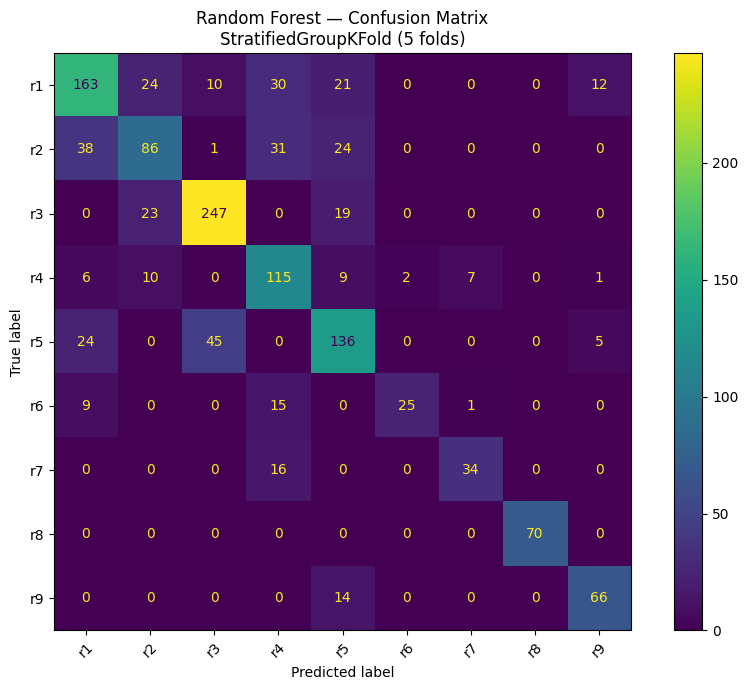

In [130]:
# ============================================================
# MATRIZ DE CONFUSÃO AGREGADA
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

all_y_true = np.asarray(all_y_true)
all_y_pred = np.asarray(all_y_pred)

region_order = sorted(np.unique(y))

cm = confusion_matrix(
    all_y_true,
    all_y_pred,
    labels=region_order
)

print("Regiões:")
print(region_order)

print("\nMatriz de confusão:")
print(cm)

fig, ax = plt.subplots(figsize=(9, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=region_order
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

ax.set_title(
    "Random Forest — Confusion Matrix\n"
    "StratifiedGroupKFold (5 folds)"
)

plt.tight_layout()
plt.show()

In [131]:
# ============================================================
# CLASSIFICATION REPORT AGREGADO
# ============================================================

report = classification_report(
    all_y_true,
    all_y_pred,
    labels=region_order,
    target_names=region_order,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

display(
    report_df[
        ["precision", "recall", "f1-score", "support"]
    ].round(4)
)

,precision,recall,f1-score,support
r1,0.6792,0.6269,0.6520,260.0000
r2,0.6014,0.4778,0.5325,180.0000
r3,0.8152,0.8547,0.8345,289.0000
r4,0.5556,0.7667,0.6443,150.0000
r5,0.6099,0.6476,0.6282,210.0000
r6,0.9259,0.5000,0.6494,50.0000
r7,0.8095,0.6800,0.7391,50.0000
r8,1.0000,1.0000,1.0000,70.0000
r9,0.7857,0.8250,0.8049,80.0000
accuracy,0.7035,0.7035,0.7035,0.7035


In [132]:
# ============================================================
# E2 + E3 — Random Forest estratificado por KIT
# WHITED v1.1 — avaliação com grupos por appliance
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Configuração
# ------------------------------------------------------------

feature_cols = [f"feature_{i+1}" for i in range(12)]

RF_PARAMS = {
    "n_estimators": 500,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

N_SPLITS = 5
RANDOM_STATE = 42

print("Feature columns:")
print(feature_cols)

print("\nRF parameters:")
print(RF_PARAMS)

Feature columns:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12']

RF parameters:
{'n_estimators': 500, 'random_state': 42, 'n_jobs': -1, 'class_weight': 'balanced'}


In [133]:
# ============================================================
# 2. Função geral para executar o experimento
# ============================================================

def run_rf_by_kit(df, kit_name, n_splits=5, random_state=42):

    print("=" * 80)
    print(f"EXPERIMENTO: {kit_name}")
    print("=" * 80)

    # --------------------------------------------------------
    # Filtrar kit
    # --------------------------------------------------------

    df_kit = (
        df[df["kit"].astype(str).str.upper() == kit_name.upper()]
        .copy()
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # Remover linhas inválidas
    # --------------------------------------------------------

    required_cols = feature_cols + ["region", "appliance"]

    df_kit = df_kit.dropna(subset=required_cols).reset_index(drop=True)

    # --------------------------------------------------------
    # X / y / grupos
    # --------------------------------------------------------

    X = df_kit[feature_cols].to_numpy(dtype=float)
    y = df_kit["region"].astype(str).to_numpy()
    groups = df_kit["appliance"].astype(str).to_numpy()

    print(f"\nKit: {kit_name}")
    print(f"Observações: {len(df_kit)}")
    print(f"Features: {X.shape[1]}")
    print(f"Regiões: {np.unique(y).tolist()}")
    print(f"Appliances: {len(np.unique(groups))}")

    print("\nDistribuição por região:")
    print(
        df_kit["region"]
        .value_counts()
        .sort_index()
        .to_string()
    )

    print("\nNúmero de appliances por região:")
    print(
        df_kit.groupby("region")["appliance"]
        .nunique()
        .sort_index()
        .to_string()
    )

    # --------------------------------------------------------
    # Auditoria: uma observação por appliance x timestamp
    # --------------------------------------------------------

    if "timestamp_dt" in df_kit.columns:

        dup_app_time = (
            df_kit.groupby(["appliance", "timestamp_dt"])
            .size()
        )

        print("\nAuditoria appliance × timestamp:")
        print(f"Máximo de observações por combinação: {dup_app_time.max()}")

    # --------------------------------------------------------
    # Cross-validation
    # --------------------------------------------------------

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    all_y_true = []
    all_y_pred = []

    fold_details = []

    # --------------------------------------------------------
    # Folds
    # --------------------------------------------------------

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        groups_train = groups[train_idx]
        groups_test = groups[test_idx]

        # ----------------------------------------------------
        # Auditoria de grupos
        # ----------------------------------------------------

        train_groups = set(groups_train)
        test_groups = set(groups_test)

        overlap = train_groups.intersection(test_groups)

        # ----------------------------------------------------
        # Modelo
        # ----------------------------------------------------

        rf = RandomForestClassifier(**RF_PARAMS)

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------

        accuracy = accuracy_score(y_test, y_pred)

        balanced_acc = balanced_accuracy_score(
            y_test,
            y_pred
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        )

        weighted_f1 = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )

        fold_results.append({
            "fold": fold,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_appliances": len(train_groups),
            "n_test_appliances": len(test_groups),
            "accuracy": accuracy,
            "balanced_accuracy": balanced_acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1
        })

        # ----------------------------------------------------
        # Guardar predições
        # ----------------------------------------------------

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

        # ----------------------------------------------------
        # Distribuição regional
        # ----------------------------------------------------

        train_region_counts = (
            pd.Series(y_train)
            .value_counts()
            .sort_index()
            .to_dict()
        )

        test_region_counts = (
            pd.Series(y_test)
            .value_counts()
            .sort_index()
            .to_dict()
        )

        train_regions = set(y_train)
        test_regions = set(y_test)

        missing_test = sorted(
            train_regions - test_regions
        )

        fold_details.append({
            "fold": fold,
            "train_region_counts": train_region_counts,
            "test_region_counts": test_region_counts,
            "missing_test_regions": missing_test,
            "group_overlap": len(overlap)
        })

        # ----------------------------------------------------
        # Impressão
        # ----------------------------------------------------

        print(f"\n--- Fold {fold} ---")

        print(
            f"Train: {len(train_idx)} observações | "
            f"{len(train_groups)} appliances"
        )

        print(
            f"Test : {len(test_idx)} observações | "
            f"{len(test_groups)} appliances"
        )

        print(f"Group overlap: {len(overlap)}")

        print(f"Accuracy          : {accuracy:.6f}")
        print(f"Balanced Accuracy : {balanced_acc:.6f}")
        print(f"Macro-F1          : {macro_f1:.6f}")
        print(f"Weighted-F1       : {weighted_f1:.6f}")

        if missing_test:
            print(
                "Regiões ausentes no teste:",
                missing_test
            )
        else:
            print("Todas as regiões presentes no teste.")

    # --------------------------------------------------------
    # DataFrame das métricas
    # --------------------------------------------------------

    results_df = pd.DataFrame(fold_results)

    metric_cols = [
        "accuracy",
        "balanced_accuracy",
        "macro_f1",
        "weighted_f1"
    ]

    summary = pd.DataFrame({
        "mean": results_df[metric_cols].mean(),
        "std": results_df[metric_cols].std(ddof=1),
        "min": results_df[metric_cols].min(),
        "max": results_df[metric_cols].max()
    })

    # --------------------------------------------------------
    # Predições agregadas
    # --------------------------------------------------------

    all_y_true = np.asarray(all_y_true)
    all_y_pred = np.asarray(all_y_pred)

    labels = sorted(np.unique(y))

    cm = confusion_matrix(
        all_y_true,
        all_y_pred,
        labels=labels
    )

    report = classification_report(
        all_y_true,
        all_y_pred,
        labels=labels,
        target_names=labels,
        digits=4,
        zero_division=0
    )

    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    print("\n" + "=" * 80)
    print(f"RESUMO — {kit_name}")
    print("=" * 80)

    print("\nMétricas por fold:")
    display(
        results_df.style.format({
            "accuracy": "{:.4f}",
            "balanced_accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "weighted_f1": "{:.4f}"
        })
    )

    print("\nMédia ± desvio-padrão:")
    for metric in metric_cols:

        mean = results_df[metric].mean()
        std = results_df[metric].std(ddof=1)

        print(
            f"{metric:20s}: "
            f"{mean:.4f} ± {std:.4f}"
        )

    print("\nClassification report — predições agregadas:")
    print(report)

    print("\nMatriz de confusão agregada:")
    cm_df = pd.DataFrame(
        cm,
        index=[f"True_{x}" for x in labels],
        columns=[f"Pred_{x}" for x in labels]
    )

    display(cm_df)

    # --------------------------------------------------------
    # Retorno
    # --------------------------------------------------------

    return {
        "kit": kit_name,
        "df": df_kit,
        "fold_results": results_df,
        "summary": summary,
        "classification_report": report,
        "confusion_matrix": cm_df,
        "y_true": all_y_true,
        "y_pred": all_y_pred,
        "fold_details": fold_details
    }

In [134]:
# ============================================================
# E2 — Random Forest somente MK1
# ============================================================

E2_MK1 = run_rf_by_kit(
    df_analysis,
    kit_name="MK1",
    n_splits=5,
    random_state=42
)

EXPERIMENTO: MK1

Kit: MK1
Observações: 320
Features: 12
Regiões: ['r1', 'r2', 'r3', 'r6', 'r7', 'r8']
Appliances: 32

Distribuição por região:
region
r1    80
r2    60
r3    10
r6    50
r7    50
r8    70

Número de appliances por região:
region
r1    8
r2    6
r3    1
r6    5
r7    5
r8    7

Auditoria appliance × timestamp:
Máximo de observações por combinação: 1

--- Fold 1 ---
Train: 250 observações | 25 appliances
Test : 70 observações | 7 appliances
Group overlap: 0
Accuracy          : 0.585714
Balanced Accuracy : 0.633333
Macro-F1          : 0.505449
Weighted-F1       : 0.611951
Regiões ausentes no teste: ['r3', 'r7']

--- Fold 2 ---
Train: 260 observações | 26 appliances
Test : 60 observações | 6 appliances
Group overlap: 0
Accuracy          : 0.983333
Balanced Accuracy : 0.987500
Macro-F1          : 0.794872
Weighted-F1       : 0.991453
Regiões ausentes no teste: ['r3', 'r6']

--- Fold 3 ---
Train: 260 observações | 26 appliances
Test : 60 observações | 6 appliances
Group over

,fold,n_train,n_test,n_train_appliances,n_test_appliances,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,250,70,25,7,0.5857,0.6333,0.5054,0.6120
1,2,260,60,26,6,0.9833,0.9875,0.7949,0.9915
2,3,260,60,26,6,1.0000,1.0000,1.0000,1.0000
3,4,250,70,25,7,0.4857,0.4400,0.3725,0.4958
4,5,260,60,26,6,0.9833,0.9875,0.7949,0.9915



Média ± desvio-padrão:
accuracy            : 0.8076 ± 0.2508
balanced_accuracy   : 0.8097 ± 0.2585
macro_f1            : 0.6935 ± 0.2514
weighted_f1         : 0.8181 ± 0.2447

Classification report — predições agregadas:
              precision    recall  f1-score   support

          r1     0.7097    0.5500    0.6197        80
          r2     0.5972    0.7167    0.6515        60
          r3     0.0000    0.0000    0.0000        10
          r6     0.7231    0.9400    0.8174        50
          r7     0.9608    0.9800    0.9703        50
          r8     1.0000    1.0000    1.0000        70

    accuracy                         0.7906       320
   macro avg     0.6651    0.6978    0.6765       320
weighted avg     0.7713    0.7906    0.7752       320


Matriz de confusão agregada:


,Pred_r1,Pred_r2,Pred_r3,Pred_r6,Pred_r7,Pred_r8
True_r1,44,19,0,17,0,0
True_r2,17,43,0,0,0,0
True_r3,0,10,0,0,0,0
True_r6,1,0,0,47,2,0
True_r7,0,0,0,1,49,0
True_r8,0,0,0,0,0,70


In [135]:
# ============================================================
# E3 — Random Forest somente MK2
# ============================================================

E3_MK2 = run_rf_by_kit(
    df_analysis,
    kit_name="MK2",
    n_splits=5,
    random_state=42
)

EXPERIMENTO: MK2

Kit: MK2
Observações: 1019
Features: 12
Regiões: ['r1', 'r2', 'r3', 'r4', 'r5', 'r9']
Appliances: 102

Distribuição por região:
region
r1    180
r2    120
r3    279
r4    150
r5    210
r9     80

Número de appliances por região:
region
r1    18
r2    12
r3    28
r4    15
r5    21
r9     8

Auditoria appliance × timestamp:
Máximo de observações por combinação: 1

--- Fold 1 ---
Train: 810 observações | 81 appliances
Test : 209 observações | 21 appliances
Group overlap: 0
Accuracy          : 0.736842
Balanced Accuracy : 0.682228
Macro-F1          : 0.654857
Weighted-F1       : 0.705851
Todas as regiões presentes no teste.

--- Fold 2 ---
Train: 809 observações | 81 appliances
Test : 210 observações | 21 appliances
Group overlap: 0
Accuracy          : 0.814286
Balanced Accuracy : 0.880000
Macro-F1          : 0.818337
Weighted-F1       : 0.812347
Todas as regiões presentes no teste.

--- Fold 3 ---
Train: 819 observações | 82 appliances
Test : 200 observações | 20 applian

,fold,n_train,n_test,n_train_appliances,n_test_appliances,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,810,209,81,21,0.7368,0.6822,0.6549,0.7059
1,2,809,210,81,21,0.8143,0.8800,0.8183,0.8123
2,3,819,200,82,20,0.8700,0.8583,0.8386,0.8662
3,4,819,200,82,20,0.5900,0.5625,0.5646,0.5767
4,5,819,200,82,20,0.9150,0.9083,0.8933,0.9176



Média ± desvio-padrão:
accuracy            : 0.7852 ± 0.1278
balanced_accuracy   : 0.7783 ± 0.1495
macro_f1            : 0.7539 ± 0.1382
weighted_f1         : 0.7757 ± 0.1361

Classification report — predições agregadas:
              precision    recall  f1-score   support

          r1     0.7288    0.7167    0.7227       180
          r2     0.7500    0.6500    0.6964       120
          r3     0.7942    0.9821    0.8782       279
          r4     0.9924    0.8667    0.9253       150
          r5     0.7100    0.6762    0.6927       210
          r9     0.7581    0.5875    0.6620        80

    accuracy                         0.7851      1019
   macro avg     0.7889    0.7465    0.7629      1019
weighted avg     0.7864    0.7851    0.7810      1019


Matriz de confusão agregada:


,Pred_r1,Pred_r2,Pred_r3,Pred_r4,Pred_r5,Pred_r9
True_r1,129,7,17,0,17,10
True_r2,30,78,11,1,0,0
True_r3,0,4,274,0,1,0
True_r4,2,8,0,130,10,0
True_r5,13,7,43,0,142,5
True_r9,3,0,0,0,30,47


In [136]:
# ============================================================
# 3. Comparação E2 × E3
# ============================================================

comparison = pd.DataFrame({
    "MK1_mean": E2_MK1["summary"]["mean"],
    "MK1_std": E2_MK1["summary"]["std"],
    "MK2_mean": E3_MK2["summary"]["mean"],
    "MK2_std": E3_MK2["summary"]["std"]
})

print("=" * 80)
print("COMPARAÇÃO E2 × E3")
print("=" * 80)

display(
    comparison.style.format(
        "{:.4f}"
    )
)

COMPARAÇÃO E2 × E3


,MK1_mean,MK1_std,MK2_mean,MK2_std
accuracy,0.8076,0.2508,0.7852,0.1278
balanced_accuracy,0.8097,0.2585,0.7783,0.1495
macro_f1,0.6935,0.2514,0.7539,0.1382
weighted_f1,0.8181,0.2447,0.7757,0.1361


In [137]:
# ============================================================
# AUDITORIA DETALHADA — E2 / MK1
# ============================================================

e2_folds = E2_MK1["fold_results"].copy()

print("Métricas completas do E2:")
display(
    e2_folds.style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}"
    })
)

print("\nDetalhes dos folds:")
for item in E2_MK1["fold_details"]:
    print("\nFold:", item["fold"])
    print("Train:", item["train_region_counts"])
    print("Test :", item["test_region_counts"])
    print("Regiões ausentes no teste:", item["missing_test_regions"])
    print("Group overlap:", item["group_overlap"])

Métricas completas do E2:


,fold,n_train,n_test,n_train_appliances,n_test_appliances,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,250,70,25,7,0.5857,0.6333,0.5054,0.6120
1,2,260,60,26,6,0.9833,0.9875,0.7949,0.9915
2,3,260,60,26,6,1.0000,1.0000,1.0000,1.0000
3,4,250,70,25,7,0.4857,0.4400,0.3725,0.4958
4,5,260,60,26,6,0.9833,0.9875,0.7949,0.9915



Detalhes dos folds:

Fold: 1
Train: {'r1': 50, 'r2': 50, 'r3': 10, 'r6': 30, 'r7': 50, 'r8': 60}
Test : {'r1': 30, 'r2': 10, 'r6': 20, 'r8': 10}
Regiões ausentes no teste: ['r3', 'r7']
Group overlap: 0

Fold: 2
Train: {'r1': 70, 'r2': 40, 'r3': 10, 'r6': 50, 'r7': 30, 'r8': 60}
Test : {'r1': 10, 'r2': 20, 'r7': 20, 'r8': 10}
Regiões ausentes no teste: ['r3', 'r6']
Group overlap: 0

Fold: 3
Train: {'r1': 70, 'r2': 60, 'r3': 10, 'r6': 40, 'r7': 40, 'r8': 40}
Test : {'r1': 10, 'r6': 10, 'r7': 10, 'r8': 30}
Regiões ausentes no teste: ['r2', 'r3']
Group overlap: 0

Fold: 4
Train: {'r1': 60, 'r2': 50, 'r6': 50, 'r7': 30, 'r8': 60}
Test : {'r1': 20, 'r2': 10, 'r3': 10, 'r7': 20, 'r8': 10}
Regiões ausentes no teste: ['r6']
Group overlap: 0

Fold: 5
Train: {'r1': 70, 'r2': 40, 'r3': 10, 'r6': 30, 'r7': 50, 'r8': 60}
Test : {'r1': 10, 'r2': 20, 'r6': 20, 'r8': 10}
Regiões ausentes no teste: ['r3', 'r7']
Group overlap: 0


In [138]:
# ============================================================
# LOCALIZAR O APPLIANCE ÚNICO DA REGIÃO r3 NO MK1
# ============================================================

mk1 = E2_MK1["df"].copy()

r3_appliances = (
    mk1.loc[mk1["region"] == "r3", "appliance"]
    .unique()
)

print("Appliance(s) r3 no MK1:")
for app in r3_appliances:
    print(app)

Appliance(s) r3 no MK1:
HairDryer_BraunSatinHair


In [139]:
# ============================================================
# IDENTIFICAR EM QUAL FOLD O APPLIANCE r3 FOI TESTE
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

X_mk1 = mk1[feature_cols].to_numpy(dtype=float)
y_mk1 = mk1["region"].astype(str).to_numpy()
groups_mk1 = mk1["appliance"].astype(str).to_numpy()

cv_mk1 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

r3_apps = set(r3_appliances)

for fold, (train_idx, test_idx) in enumerate(
    cv_mk1.split(X_mk1, y_mk1, groups_mk1),
    start=1
):

    test_apps = set(groups_mk1[test_idx])
    train_apps = set(groups_mk1[train_idx])

    r3_in_train = r3_apps.intersection(train_apps)
    r3_in_test = r3_apps.intersection(test_apps)

    print(
        f"Fold {fold}: "
        f"r3 train={r3_in_train}, "
        f"r3 test={r3_in_test}"
    )

Fold 1: r3 train={'HairDryer_BraunSatinHair'}, r3 test=set()
Fold 2: r3 train={'HairDryer_BraunSatinHair'}, r3 test=set()
Fold 3: r3 train={'HairDryer_BraunSatinHair'}, r3 test=set()
Fold 4: r3 train=set(), r3 test={'HairDryer_BraunSatinHair'}
Fold 5: r3 train={'HairDryer_BraunSatinHair'}, r3 test=set()


In [140]:
# ============================================================
# E4 — MK1 sem r3
# Análise de sensibilidade do experimento E2
# ============================================================

import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# 1. Selecionar somente MK1 e excluir r3
# ------------------------------------------------------------

df_e4 = df_analysis[
    (df_analysis["kit"] == "MK1") &
    (df_analysis["region"] != "r3")
].copy().reset_index(drop=True)

X_e4 = df_e4[feature_cols].values
y_e4 = df_e4["region"].astype(str).values
groups_e4 = df_e4["appliance"].astype(str).values

print("========== E4 — MK1 sem r3 ==========")
print(f"Observações: {len(df_e4)}")
print(f"Características: {X_e4.shape[1]}")
print(f"Aparelhos: {df_e4['appliance'].nunique()}")
print(f"Regiões: {sorted(df_e4['region'].unique())}")
print()

print("Distribuição por região:")
print(df_e4["region"].value_counts().sort_index())
print()

print("Aparelhos por região:")
print(
    df_e4.groupby("region")["appliance"]
    .nunique()
    .sort_index()
)

# ------------------------------------------------------------
# 2. Random Forest — mesmos parâmetros do E2
# ------------------------------------------------------------

rf_params = {
    "n_estimators": 500,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

rf = RandomForestClassifier(**rf_params)

# ------------------------------------------------------------
# 3. CV agrupado por aparelho
# ------------------------------------------------------------

cv_e4 = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

fold_results_e4 = []
fold_details_e4 = []

y_true_all_e4 = []
y_pred_all_e4 = []

for fold, (train_idx, test_idx) in enumerate(
    cv_e4.split(X_e4, y_e4, groups_e4),
    start=1
):

    X_train = X_e4[train_idx]
    X_test = X_e4[test_idx]

    y_train = y_e4[train_idx]
    y_test = y_e4[test_idx]

    groups_train = groups_e4[train_idx]
    groups_test = groups_e4[test_idx]

    # --------------------------------------------------------
    # Verificação de vazamento entre grupos
    # --------------------------------------------------------

    train_groups = set(groups_train)
    test_groups = set(groups_test)

    group_overlap = len(train_groups.intersection(test_groups))

    # --------------------------------------------------------
    # Treinamento
    # --------------------------------------------------------

    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    acc = accuracy_score(y_test, y_pred)

    bal_acc = balanced_accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    fold_results_e4.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_train_appliances": len(train_groups),
        "n_test_appliances": len(test_groups),
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    })

    # --------------------------------------------------------
    # Distribuição regional
    # --------------------------------------------------------

    train_region_counts = (
        pd.Series(y_train)
        .value_counts()
        .sort_index()
        .to_dict()
    )

    test_region_counts = (
        pd.Series(y_test)
        .value_counts()
        .sort_index()
        .to_dict()
    )

    all_regions = sorted(np.unique(y_e4))

    missing_test = [
        r for r in all_regions
        if r not in np.unique(y_test)
    ]

    fold_details_e4.append({
        "fold": fold,
        "train_regions": train_region_counts,
        "test_regions": test_region_counts,
        "missing_test_regions": missing_test,
        "group_overlap": group_overlap
    })

    y_true_all_e4.extend(y_test)
    y_pred_all_e4.extend(y_pred)

# ------------------------------------------------------------
# 4. Resultados por fold
# ------------------------------------------------------------

results_e4 = pd.DataFrame(fold_results_e4)

print("\n========== RESULTADOS POR FOLD ==========\n")

display(
    results_e4.style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "macro_f1": "{:.4f}",
        "weighted_f1": "{:.4f}"
    })
)

# ------------------------------------------------------------
# 5. Média ± desvio-padrão
# ------------------------------------------------------------

summary_e4 = pd.DataFrame({
    "métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ],
    "média": [
        results_e4["accuracy"].mean(),
        results_e4["balanced_accuracy"].mean(),
        results_e4["macro_f1"].mean(),
        results_e4["weighted_f1"].mean()
    ],
    "desvio_padrão": [
        results_e4["accuracy"].std(ddof=1),
        results_e4["balanced_accuracy"].std(ddof=1),
        results_e4["macro_f1"].std(ddof=1),
        results_e4["weighted_f1"].std(ddof=1)
    ]
})

summary_e4["resultado"] = (
    summary_e4["média"].map(lambda x: f"{x:.4f}")
    + " ± "
    + summary_e4["desvio_padrão"].map(lambda x: f"{x:.4f}")
)

print("\n========== E4 — MÉDIA ± DESVIO-PADRÃO ==========\n")

display(
    summary_e4[
        ["métrica", "média", "desvio_padrão", "resultado"]
    ]
)

# ------------------------------------------------------------
# 6. Detalhes dos folds
# ------------------------------------------------------------

print("\n========== DETALHES DOS FOLDS ==========\n")

for item in fold_details_e4:

    print(f"Fold: {item['fold']}")
    print(f"Train: {item['train_regions']}")
    print(f"Test : {item['test_regions']}")
    print(
        f"Regiões ausentes no teste: "
        f"{item['missing_test_regions']}"
    )
    print(
        f"Group overlap: "
        f"{item['group_overlap']}"
    )
    print("-" * 60)

# ------------------------------------------------------------
# 7. Classification report agregado
# ------------------------------------------------------------

print("\n========== CLASSIFICATION REPORT AGREGADO ==========\n")

report_e4 = classification_report(
    y_true_all_e4,
    y_pred_all_e4,
    labels=sorted(np.unique(y_e4)),
    digits=4
)

print(report_e4)

# ------------------------------------------------------------
# 8. Matriz de confusão agregada
# ------------------------------------------------------------

labels_e4 = sorted(np.unique(y_e4))

cm_e4 = confusion_matrix(
    y_true_all_e4,
    y_pred_all_e4,
    labels=labels_e4
)

cm_e4_df = pd.DataFrame(
    cm_e4,
    index=[f"real_{x}" for x in labels_e4],
    columns=[f"pred_{x}" for x in labels_e4]
)

print("\n========== MATRIZ DE CONFUSÃO ==========\n")

display(cm_e4_df)

========== E4 — MK1 sem r3 ==========
Observações: 310
Características: 12
Aparelhos: 31
Regiões: ['r1', 'r2', 'r6', 'r7', 'r8']

Distribuição por região:
region
r1    80
r2    60
r6    50
r7    50
r8    70
Name: count, dtype: int64

Aparelhos por região:
region
r1    8
r2    6
r6    5
r7    5
r8    7
Name: appliance, dtype: int64

========== RESULTADOS POR FOLD ==========



,fold,n_train,n_test,n_train_appliances,n_test_appliances,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,1,250,60,25,6,0.8167,0.8917,0.7399,0.8833
1,2,250,60,25,6,0.8333,0.9000,0.8538,0.8226
2,3,250,60,25,6,0.8167,0.6333,0.4141,0.8451
3,4,240,70,24,7,0.8571,0.8889,0.8857,0.8531
4,5,250,60,25,6,0.9833,0.9875,0.7949,0.9915



========== E4 — MÉDIA ± DESVIO-PADRÃO ==========



,métrica,média,desvio_padrão,resultado
0,Accuracy,0.861429,0.070135,0.8614 ± 0.0701
1,Balanced Accuracy,0.860278,0.133296,0.8603 ± 0.1333
2,Macro-F1,0.737705,0.189316,0.7377 ± 0.1893
3,Weighted-F1,0.879115,0.066446,0.8791 ± 0.0664



========== DETALHES DOS FOLDS ==========

Fold: 1
Train: {'r1': 50, 'r2': 60, 'r6': 40, 'r7': 40, 'r8': 60}
Test : {'r1': 30, 'r6': 10, 'r7': 10, 'r8': 10}
Regiões ausentes no teste: ['r2']
Group overlap: 0
------------------------------------------------------------
Fold: 2
Train: {'r1': 60, 'r2': 50, 'r6': 40, 'r7': 40, 'r8': 60}
Test : {'r1': 20, 'r2': 10, 'r6': 10, 'r7': 10, 'r8': 10}
Regiões ausentes no teste: []
Group overlap: 0
------------------------------------------------------------
Fold: 3
Train: {'r1': 80, 'r2': 50, 'r6': 40, 'r7': 50, 'r8': 30}
Test : {'r2': 10, 'r6': 10, 'r8': 40}
Regiões ausentes no teste: ['r1', 'r7']
Group overlap: 0
------------------------------------------------------------
Fold: 4
Train: {'r1': 50, 'r2': 30, 'r6': 50, 'r7': 40, 'r8': 70}
Test : {'r1': 30, 'r2': 30, 'r7': 10}
Regiões ausentes no teste: ['r6', 'r8']
Group overlap: 0
------------------------------------------------------------
Fold: 5
Train: {'r1': 80, 'r2': 50, 'r6': 30, 'r7': 30,

,pred_r1,pred_r2,pred_r6,pred_r7,pred_r8
real_r1,60,16,4,0,0
real_r2,19,41,0,0,0
real_r6,2,0,46,2,0
real_r7,0,0,0,50,0
real_r8,0,0,0,0,70


Auditoria do E4

In [141]:
# ============================================================
# E4 — KRUSKAL–WALLIS + TAMANHO DE EFEITO
# MK1 sem r3 vs. MK1 original
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 1. Definição das características
# ------------------------------------------------------------

feature_cols = [f"feature_{i}" for i in range(1, 13)]

# ------------------------------------------------------------
# 2. Construção dos conjuntos
# ------------------------------------------------------------

# MK1 original
df_mk1_original = (
    df_analysis[df_analysis["kit"].astype(str).eq("MK1")]
    .copy()
    .reset_index(drop=True)
)

# E4 = MK1 sem r3
df_e4 = (
    df_analysis[
        df_analysis["kit"].astype(str).eq("MK1") &
        df_analysis["region"].astype(str).ne("r3")
    ]
    .copy()
    .reset_index(drop=True)
)

print("=" * 70)
print("AUDITORIA E4 — KRUSKAL–WALLIS + EPSILON²")
print("=" * 70)

print(f"MK1 original: {len(df_mk1_original)} observações")
print(f"E4 (MK1 sem r3): {len(df_e4)} observações")

print("\nRegiões — MK1 original:")
print(df_mk1_original["region"].value_counts().sort_index())

print("\nRegiões — E4:")
print(df_e4["region"].value_counts().sort_index())


# ------------------------------------------------------------
# 3. Função para Kruskal–Wallis + epsilon²
# ------------------------------------------------------------

def kruskal_effect_by_feature(df, features, group_col="region"):

    results = []

    groups = sorted(df[group_col].dropna().astype(str).unique())
    k = len(groups)

    for feature in features:

        data_groups = []

        for region in groups:
            values = pd.to_numeric(
                df.loc[df[group_col].astype(str) == region, feature],
                errors="coerce"
            ).dropna().values

            data_groups.append(values)

        # Kruskal-Wallis
        H, p = kruskal(*data_groups)

        # Número total de observações efetivamente utilizadas
        N = sum(len(x) for x in data_groups)

        # Epsilon squared
        # ε² = (H - k + 1) / (N - k)
        epsilon2 = (H - k + 1) / (N - k)

        # Limitação numérica / pequenas correções
        epsilon2 = max(0.0, epsilon2)

        results.append({
            "feature": feature,
            "H": H,
            "p": p,
            "epsilon2": epsilon2,
            "N": N,
            "k": k
        })

    result_df = pd.DataFrame(results)

    # FDR-BH dentro das 12 características
    reject, p_fdr, _, _ = multipletests(
        result_df["p"],
        method="fdr_bh"
    )

    result_df["p_fdr"] = p_fdr
    result_df["significant_fdr"] = reject

    # Organização
    result_df = result_df[
        [
            "feature",
            "H",
            "p",
            "p_fdr",
            "epsilon2",
            "significant_fdr",
            "N",
            "k"
        ]
    ]

    return result_df


# ------------------------------------------------------------
# 4. Executar MK1 original
# ------------------------------------------------------------

results_mk1 = kruskal_effect_by_feature(
    df_mk1_original,
    feature_cols
)

# ------------------------------------------------------------
# 5. Executar E4
# ------------------------------------------------------------

results_e4 = kruskal_effect_by_feature(
    df_e4,
    feature_cols
)


# ------------------------------------------------------------
# 6. Exibir resultados
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MK1 ORIGINAL")
print("=" * 70)

display(
    results_mk1.style.format({
        "H": "{:.4f}",
        "p": "{:.3e}",
        "p_fdr": "{:.3e}",
        "epsilon2": "{:.5f}"
    })
)

print("\n" + "=" * 70)
print("E4 — MK1 SEM r3")
print("=" * 70)

display(
    results_e4.style.format({
        "H": "{:.4f}",
        "p": "{:.3e}",
        "p_fdr": "{:.3e}",
        "epsilon2": "{:.5f}"
    })
)


# ------------------------------------------------------------
# 7. Comparação direta
# ------------------------------------------------------------

comparison = results_mk1[
    ["feature", "H", "p", "p_fdr", "epsilon2", "significant_fdr"]
].merge(
    results_e4[
        ["feature", "H", "p", "p_fdr", "epsilon2", "significant_fdr"]
    ],
    on="feature",
    suffixes=("_mk1", "_e4")
)

# Diferenças absolutas
comparison["delta_H"] = (
    comparison["H_e4"] - comparison["H_mk1"]
)

comparison["delta_epsilon2"] = (
    comparison["epsilon2_e4"] -
    comparison["epsilon2_mk1"]
)

# Razão do tamanho de efeito
comparison["epsilon2_ratio"] = (
    comparison["epsilon2_e4"] /
    comparison["epsilon2_mk1"]
)

# Ordenar pela magnitude do efeito E4
comparison = comparison.sort_values(
    "epsilon2_e4",
    ascending=False
).reset_index(drop=True)


print("\n" + "=" * 70)
print("COMPARAÇÃO — MK1 ORIGINAL vs E4")
print("=" * 70)

display(
    comparison.style.format({
        "H_mk1": "{:.4f}",
        "p_mk1": "{:.3e}",
        "p_fdr_mk1": "{:.3e}",
        "epsilon2_mk1": "{:.5f}",
        "H_e4": "{:.4f}",
        "p_e4": "{:.3e}",
        "p_fdr_e4": "{:.3e}",
        "epsilon2_e4": "{:.5f}",
        "delta_H": "{:+.4f}",
        "delta_epsilon2": "{:+.5f}",
        "epsilon2_ratio": "{:.3f}"
    })
)

AUDITORIA E4 — KRUSKAL–WALLIS + EPSILON²
MK1 original: 320 observações
E4 (MK1 sem r3): 310 observações

Regiões — MK1 original:
region
r1    80
r2    60
r3    10
r6    50
r7    50
r8    70
Name: count, dtype: int64

Regiões — E4:
region
r1    80
r2    60
r6    50
r7    50
r8    70
Name: count, dtype: int64

MK1 ORIGINAL


,feature,H,p,p_fdr,epsilon2,significant_fdr,N,k
0,feature_1,245.7535,4.479e-51,1.792e-50,0.76673,True,320,6
1,feature_2,245.7535,4.479e-51,1.792e-50,0.76673,True,320,6
2,feature_3,288.7462,2.628e-60,3.154e-59,0.90365,True,320,6
3,feature_4,188.7690,7.160e-39,1.718e-38,0.58525,True,320,6
4,feature_5,230.8597,6.997e-48,2.099e-47,0.71930,True,320,6
5,feature_6,37.3577,5.077e-07,5.539e-07,0.10305,True,320,6
6,feature_7,48.9140,2.311e-09,2.773e-09,0.13985,True,320,6
7,feature_8,48.9140,2.311e-09,2.773e-09,0.13985,True,320,6
8,feature_9,96.5793,2.777e-19,5.555e-19,0.29165,True,320,6
9,feature_10,87.0952,2.737e-17,4.691e-17,0.26145,True,320,6



E4 — MK1 SEM r3


,feature,H,p,p_fdr,epsilon2,significant_fdr,N,k
0,feature_1,232.0293,4.827e-49,1.931e-48,0.74764,True,310,5
1,feature_2,232.0293,4.827e-49,1.931e-48,0.74764,True,310,5
2,feature_3,276.9356,1.020e-58,1.224e-57,0.89487,True,310,5
3,feature_4,174.6791,1.035e-36,2.485e-36,0.55960,True,310,5
4,feature_5,225.5203,1.216e-47,3.648e-47,0.72630,True,310,5
5,feature_6,23.2550,1.126e-04,1.126e-04,0.06313,True,310,5
6,feature_7,45.4472,3.210e-09,3.851e-09,0.13589,True,310,5
7,feature_8,45.4472,3.210e-09,3.851e-09,0.13589,True,310,5
8,feature_9,90.7539,9.106e-19,1.821e-18,0.28444,True,310,5
9,feature_10,84.4696,1.966e-17,3.370e-17,0.26383,True,310,5



COMPARAÇÃO — MK1 ORIGINAL vs E4


,feature,H_mk1,p_mk1,p_fdr_mk1,epsilon2_mk1,significant_fdr_mk1,H_e4,p_e4,p_fdr_e4,epsilon2_e4,significant_fdr_e4,delta_H,delta_epsilon2,epsilon2_ratio
0,feature_3,288.7462,2.628e-60,3.154e-59,0.90365,True,276.9356,1.020e-58,1.224e-57,0.89487,True,-11.8106,-0.00878,0.990
1,feature_1,245.7535,4.479e-51,1.792e-50,0.76673,True,232.0293,4.827e-49,1.931e-48,0.74764,True,-13.7242,-0.01909,0.975
2,feature_2,245.7535,4.479e-51,1.792e-50,0.76673,True,232.0293,4.827e-49,1.931e-48,0.74764,True,-13.7242,-0.01909,0.975
3,feature_5,230.8597,6.997e-48,2.099e-47,0.71930,True,225.5203,1.216e-47,3.648e-47,0.72630,True,-5.3394,+0.00700,1.010
4,feature_4,188.7690,7.160e-39,1.718e-38,0.58525,True,174.6791,1.035e-36,2.485e-36,0.55960,True,-14.0899,-0.02565,0.956
5,feature_9,96.5793,2.777e-19,5.555e-19,0.29165,True,90.7539,9.106e-19,1.821e-18,0.28444,True,-5.8254,-0.00721,0.975
6,feature_10,87.0952,2.737e-17,4.691e-17,0.26145,True,84.4696,1.966e-17,3.370e-17,0.26383,True,-2.6255,+0.00239,1.009
7,feature_11,79.5567,1.039e-15,1.558e-15,0.23744,True,67.3099,8.387e-14,1.258e-13,0.20757,True,-12.2468,-0.02987,0.874
8,feature_7,48.9140,2.311e-09,2.773e-09,0.13985,True,45.4472,3.210e-09,3.851e-09,0.13589,True,-3.4668,-0.00396,0.972
9,feature_8,48.9140,2.311e-09,2.773e-09,0.13985,True,45.4472,3.210e-09,3.851e-09,0.13589,True,-3.4668,-0.00396,0.972


In [142]:
# ============================================================
# RESUMO DA AUDITORIA E4
# ============================================================

print("\n" + "=" * 70)
print("RESUMO DA AUDITORIA E4")
print("=" * 70)

# Quantidade de características significativas
sig_mk1 = results_mk1["significant_fdr"].sum()
sig_e4 = results_e4["significant_fdr"].sum()

print(f"\nCaracterísticas significativas após FDR:")
print(f"  MK1 original : {sig_mk1}/12")
print(f"  E4           : {sig_e4}/12")

# Média e mediana do tamanho de efeito
print("\nEpsilon²:")
print(
    f"  MK1 original — média   : "
    f"{results_mk1['epsilon2'].mean():.5f}"
)

print(
    f"  MK1 original — mediana : "
    f"{results_mk1['epsilon2'].median():.5f}"
)

print(
    f"  E4 — média             : "
    f"{results_e4['epsilon2'].mean():.5f}"
)

print(
    f"  E4 — mediana           : "
    f"{results_e4['epsilon2'].median():.5f}"
)


# ------------------------------------------------------------
# Top características
# ------------------------------------------------------------

print("\nTop características por epsilon² — MK1 original:")
print(
    results_mk1
    .sort_values("epsilon2", ascending=False)
    [["feature", "H", "p_fdr", "epsilon2"]]
    .to_string(index=False)
)

print("\nTop características por epsilon² — E4:")
print(
    results_e4
    .sort_values("epsilon2", ascending=False)
    [["feature", "H", "p_fdr", "epsilon2"]]
    .to_string(index=False)
)


# ------------------------------------------------------------
# Características que mais mudaram
# ------------------------------------------------------------

print("\nMaior redução de epsilon² após remover r3:")

print(
    comparison
    .sort_values("delta_epsilon2")
    [["feature", "epsilon2_mk1", "epsilon2_e4", "delta_epsilon2"]]
    .head(12)
    .to_string(index=False)
)


RESUMO DA AUDITORIA E4

Características significativas após FDR:
  MK1 original : 12/12
  E4           : 12/12

Epsilon²:
  MK1 original — média   : 0.41727
  MK1 original — mediana : 0.27655
  E4 — média             : 0.40254
  E4 — mediana           : 0.27414

Top características por epsilon² — MK1 original:
   feature          H        p_fdr  epsilon2
 feature_3 288.746239 3.153768e-59  0.903650
 feature_1 245.753512 1.791521e-50  0.766731
 feature_2 245.753512 1.791521e-50  0.766731
 feature_5 230.859718 2.099147e-47  0.719298
 feature_4 188.769014 1.718459e-38  0.585252
 feature_9  96.579325 5.554695e-19  0.291654
feature_10  87.095151 4.691295e-17  0.261450
feature_11  79.556669 1.558422e-15  0.237442
 feature_7  48.914030 2.773050e-09  0.139854
 feature_8  48.914030 2.773050e-09  0.139854
 feature_6  37.357745 5.539049e-07  0.103050
feature_12  33.960050 2.425007e-06  0.092229

Top características por epsilon² — E4:
   feature          H        p_fdr  epsilon2
 feature_3 276.93

In [143]:
# ============================================================
# KRUSKAL-WALLIS EM NÍVEL DE APARELHO
# MK1 ORIGINAL vs E4 (MK1 sem r3)
#
# Unidade estatística:
#   1 aparelho = 1 observação
#
# Representação:
#   mediana das observações de cada aparelho
#
# FDR:
#   Benjamini-Hochberg, separadamente nas 12 características
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# ------------------------------------------------------------
# 1. Função para verificar a estrutura dos aparelhos
# ------------------------------------------------------------

def audit_appliance_structure(df, name):

    tmp = (
        df.groupby("appliance")
        .agg(
            n_obs=("filename", "size"),
            n_regions=("region", "nunique"),
            region=("region", "first")
        )
        .reset_index()
    )

    print(f"\n{'='*70}")
    print(f"ESTRUTURA — {name}")
    print(f"{'='*70}")

    print(f"Observações: {len(df)}")
    print(f"Aparelhos:   {tmp['appliance'].nunique()}")

    print("\nObservações por aparelho:")
    print(tmp["n_obs"].describe())

    print("\nDistribuição do número de observações por aparelho:")
    print(tmp["n_obs"].value_counts().sort_index())

    print("\nNúmero de regiões por aparelho:")
    print(tmp["n_regions"].value_counts().sort_index())

    invalid = tmp[tmp["n_regions"] != 1]

    if len(invalid) > 0:
        print("\nATENÇÃO: aparelhos associados a mais de uma região:")
        display(invalid)
    else:
        print("\n✓ Cada aparelho pertence a uma única região.")

    return tmp


# ------------------------------------------------------------
# 2. Função para agregar cada aparelho
# ------------------------------------------------------------

def aggregate_by_appliance(df, feature_cols, agg="median"):

    # Garantir que cada aparelho possui uma única região
    check_region = (
        df.groupby("appliance")["region"]
        .nunique()
    )

    if (check_region > 1).any():
        raise ValueError(
            "Existem aparelhos associados a mais de uma região."
        )

    # Agregação das características
    df_app = (
        df.groupby(["appliance", "region"])[feature_cols]
        .agg(agg)
        .reset_index()
    )

    return df_app


# ------------------------------------------------------------
# 3. Kruskal-Wallis em nível de aparelho
# ------------------------------------------------------------

def kruskal_appliance_level(
    df_app,
    feature_cols,
    analysis_name
):

    results = []

    regions = sorted(df_app["region"].unique())

    print(f"\n{'='*70}")
    print(f"KRUSKAL-WALLIS — NÍVEL DE APARELHO — {analysis_name}")
    print(f"{'='*70}")

    print("\nAparelhos por região:")

    counts = (
        df_app["region"]
        .value_counts()
        .sort_index()
    )

    print(counts.to_string())

    for feature in feature_cols:

        groups = [
            df_app.loc[
                df_app["region"] == region,
                feature
            ].dropna().values
            for region in regions
        ]

        # Regiões sem observações são removidas
        groups = [g for g in groups if len(g) > 0]

        if len(groups) < 2:
            H = np.nan
            p = np.nan
            epsilon2 = np.nan

        else:

            H, p = kruskal(*groups)

            N = sum(len(g) for g in groups)
            k = len(groups)

            # Epsilon squared
            epsilon2 = (H - k + 1) / (N - k)

        results.append({
            "analysis": analysis_name,
            "feature": feature,
            "H": H,
            "p": p,
            "epsilon2": epsilon2
        })

    results = pd.DataFrame(results)

    # --------------------------------------------------------
    # FDR-BH dentro das 12 características
    # --------------------------------------------------------

    valid = results["p"].notna()

    results["p_fdr"] = np.nan

    if valid.sum() > 0:

        _, p_fdr, _, _ = multipletests(
            results.loc[valid, "p"],
            method="fdr_bh"
        )

        results.loc[valid, "p_fdr"] = p_fdr

    results["significant_fdr"] = (
        results["p_fdr"] < 0.05
    )

    # Ordenar pelo tamanho do efeito
    results = results.sort_values(
        "epsilon2",
        ascending=False
    ).reset_index(drop=True)

    return results


# ------------------------------------------------------------
# 4. Criar os dois conjuntos
# ------------------------------------------------------------

df_mk1_original = df_analysis[
    df_analysis["kit"].astype(str).str.upper().eq("MK1")
].copy()

df_e4 = df_mk1_original[
    df_mk1_original["region"] != "r3"
].copy()


# ------------------------------------------------------------
# 5. Auditoria
# ------------------------------------------------------------

audit_original = audit_appliance_structure(
    df_mk1_original,
    "MK1 ORIGINAL"
)

audit_e4 = audit_appliance_structure(
    df_e4,
    "E4 — MK1 SEM r3"
)


# ------------------------------------------------------------
# 6. Agregação por aparelho
# ------------------------------------------------------------

df_mk1_app = aggregate_by_appliance(
    df_mk1_original,
    feature_cols,
    agg="median"
)

df_e4_app = aggregate_by_appliance(
    df_e4,
    feature_cols,
    agg="median"
)


print("\nDimensões após agregação:")
print(f"MK1 original: {df_mk1_app.shape}")
print(f"E4:           {df_e4_app.shape}")


# ------------------------------------------------------------
# 7. Kruskal-Wallis por aparelho
# ------------------------------------------------------------

kw_mk1_app = kruskal_appliance_level(
    df_mk1_app,
    feature_cols,
    "MK1 ORIGINAL — APARELHO"
)

kw_e4_app = kruskal_appliance_level(
    df_e4_app,
    feature_cols,
    "E4 — SEM r3 — APARELHO"
)


# ------------------------------------------------------------
# 8. Exibir resultados
# ------------------------------------------------------------

print("\n")
print("=" * 90)
print("MK1 ORIGINAL — KRUSKAL-WALLIS POR APARELHO")
print("=" * 90)

display(
    kw_mk1_app[
        [
            "feature",
            "H",
            "p",
            "p_fdr",
            "epsilon2",
            "significant_fdr"
        ]
    ].round(6)
)


print("\n")
print("=" * 90)
print("E4 — KRUSKAL-WALLIS POR APARELHO")
print("=" * 90)

display(
    kw_e4_app[
        [
            "feature",
            "H",
            "p",
            "p_fdr",
            "epsilon2",
            "significant_fdr"
        ]
    ].round(6)
)


ESTRUTURA — MK1 ORIGINAL
Observações: 320
Aparelhos:   32

Observações por aparelho:
count    32.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: n_obs, dtype: float64

Distribuição do número de observações por aparelho:
n_obs
10    32
Name: count, dtype: int64

Número de regiões por aparelho:
n_regions
1    32
Name: count, dtype: int64

✓ Cada aparelho pertence a uma única região.

ESTRUTURA — E4 — MK1 SEM r3
Observações: 310
Aparelhos:   31

Observações por aparelho:
count    31.0
mean     10.0
std       0.0
min      10.0
25%      10.0
50%      10.0
75%      10.0
max      10.0
Name: n_obs, dtype: float64

Distribuição do número de observações por aparelho:
n_obs
10    31
Name: count, dtype: int64

Número de regiões por aparelho:
n_regions
1    31
Name: count, dtype: int64

✓ Cada aparelho pertence a uma única região.

Dimensões após agregação:
MK1 original: (32, 14)
E4:           (31, 14)

KRUSKAL-WALLIS — NÍVEL DE APARELHO — 

,feature,H,p,p_fdr,epsilon2,significant_fdr
0,feature_3,28.137784,0.000034,0.000411,0.889915,True
1,feature_1,24.419223,0.000180,0.000721,0.746893,True
2,feature_2,24.419223,0.000180,0.000721,0.746893,True
3,feature_5,23.562121,0.000263,0.000790,0.713928,True
4,feature_4,18.404938,0.002479,0.005951,0.515575,True
5,feature_9,10.429126,0.063950,0.127900,0.208813,False
6,feature_11,9.663636,0.085347,0.146309,0.179371,False
7,feature_10,8.809970,0.116888,0.175332,0.146537,False
8,feature_12,5.968953,0.309252,0.412336,0.037267,False
9,feature_7,4.723864,0.450501,0.491455,-0.010621,False




E4 — KRUSKAL-WALLIS POR APARELHO


,feature,H,p,p_fdr,epsilon2,significant_fdr
0,feature_3,26.953125,0.000020,0.000244,0.882812,True
1,feature_1,23.091431,0.000121,0.000367,0.734286,True
2,feature_2,23.091431,0.000121,0.000367,0.734286,True
3,feature_5,23.072077,0.000122,0.000367,0.733541,True
4,feature_4,17.062399,0.001880,0.004511,0.502400,True
5,feature_9,9.684101,0.046099,0.092198,0.218619,False
6,feature_10,8.660714,0.070163,0.120279,0.179258,False
7,feature_11,7.287097,0.121472,0.182208,0.126427,False
8,feature_7,4.385541,0.356336,0.427603,0.014829,False
9,feature_8,4.385541,0.356336,0.427603,0.014829,False


In [144]:
# ============================================================
# RESULTADOS DE ε² — NÍVEL DE OBSERVAÇÃO
# ============================================================

eps_mk1_obs = {
    "feature_1": 0.76673,
    "feature_2": 0.76673,
    "feature_3": 0.90365,
    "feature_4": 0.58525,
    "feature_5": 0.71930,
    "feature_6": 0.10305,
    "feature_7": 0.13985,
    "feature_8": 0.13985,
    "feature_9": 0.29165,
    "feature_10": 0.26145,
    "feature_11": 0.23744,
    "feature_12": 0.09223
}

eps_e4_obs = {
    "feature_1": 0.74764,
    "feature_2": 0.74764,
    "feature_3": 0.89487,
    "feature_4": 0.55960,
    "feature_5": 0.72630,
    "feature_6": 0.06313,
    "feature_7": 0.13589,
    "feature_8": 0.13589,
    "feature_9": 0.28444,
    "feature_10": 0.26383,
    "feature_11": 0.20757,
    "feature_12": 0.06369
}

In [145]:
# ============================================================
# COMPARAÇÃO COMPLETA
# ============================================================

comparison = pd.DataFrame({
    "feature": feature_cols,

    "epsilon2_MK1_obs": [
        eps_mk1_obs[f] for f in feature_cols
    ],

    "epsilon2_E4_obs": [
        eps_e4_obs[f] for f in feature_cols
    ],

    "epsilon2_MK1_app": [
        kw_mk1_app.loc[
            kw_mk1_app["feature"] == f,
            "epsilon2"
        ].iloc[0]
        for f in feature_cols
    ],

    "epsilon2_E4_app": [
        kw_e4_app.loc[
            kw_e4_app["feature"] == f,
            "epsilon2"
        ].iloc[0]
        for f in feature_cols
    ]
})


# Diferença observação → aparelho
comparison["delta_MK1_obs_app"] = (
    comparison["epsilon2_MK1_app"]
    - comparison["epsilon2_MK1_obs"]
)

comparison["delta_E4_obs_app"] = (
    comparison["epsilon2_E4_app"]
    - comparison["epsilon2_E4_obs"]
)


# Diferença MK1 → E4 no nível de aparelho
comparison["delta_MK1_E4_app"] = (
    comparison["epsilon2_E4_app"]
    - comparison["epsilon2_MK1_app"]
)


# Ordenar pelo efeito E4 em nível de aparelho
comparison = comparison.sort_values(
    "epsilon2_E4_app",
    ascending=False
).reset_index(drop=True)


display(comparison.round(4))

,feature,epsilon2_MK1_obs,epsilon2_E4_obs,epsilon2_MK1_app,epsilon2_E4_app,delta_MK1_obs_app,delta_E4_obs_app,delta_MK1_E4_app
0,feature_3,0.9036,0.8949,0.8899,0.8828,-0.0137,-0.0121,-0.0071
1,feature_1,0.7667,0.7476,0.7469,0.7343,-0.0198,-0.0134,-0.0126
2,feature_2,0.7667,0.7476,0.7469,0.7343,-0.0198,-0.0134,-0.0126
3,feature_5,0.7193,0.7263,0.7139,0.7335,-0.0054,0.0072,0.0196
4,feature_4,0.5853,0.5596,0.5156,0.5024,-0.0697,-0.0572,-0.0132
5,feature_9,0.2916,0.2844,0.2088,0.2186,-0.0828,-0.0658,0.0098
6,feature_10,0.2614,0.2638,0.1465,0.1793,-0.1149,-0.0846,0.0327
7,feature_11,0.2374,0.2076,0.1794,0.1264,-0.0581,-0.0811,-0.0529
8,feature_7,0.1398,0.1359,-0.0106,0.0148,-0.1505,-0.1211,0.0254
9,feature_8,0.1398,0.1359,-0.0106,0.0148,-0.1505,-0.1211,0.0254


In [146]:
# ============================================================
# COMPARAÇÃO FINAL — KRUSKAL-WALLIS
# MK1 original × E4 (MK1 sem r3) × nível de aparelho
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Resultados row-level já calculados anteriormente
# ------------------------------------------------------------

row_mk1 = {
    "f1": 0.76673,
    "f2": 0.76673,
    "f3": 0.90365,
    "f4": 0.58525,
    "f5": 0.71930,
    "f6": 0.10305,
    "f7": 0.13985,
    "f8": 0.13985,
    "f9": 0.29165,
    "f10": 0.26145,
    "f11": 0.23744,
    "f12": 0.09223,
}

row_e4 = {
    "f1": 0.74764,
    "f2": 0.74764,
    "f3": 0.89487,
    "f4": 0.55960,
    "f5": 0.72630,
    "f6": 0.06313,
    "f7": 0.13589,
    "f8": 0.13589,
    "f9": 0.28444,
    "f10": 0.26383,
    "f11": 0.20757,
    "f12": 0.06369,
}

# ------------------------------------------------------------
# 2. Resultados appliance-level já calculados
# ------------------------------------------------------------

app_mk1 = {
    "f1": 0.746893,
    "f2": 0.746893,
    "f3": 0.889915,
    "f4": 0.515575,
    "f5": 0.713928,
    "f6": -0.094863,
    "f7": -0.010621,
    "f8": -0.010621,
    "f9": 0.208813,
    "f10": 0.146537,
    "f11": 0.179371,
    "f12": 0.037267,
}

app_e4 = {
    "f1": 0.734286,
    "f2": 0.734286,
    "f3": 0.882812,
    "f4": 0.502400,
    "f5": 0.733541,
    "f6": -0.115677,
    "f7": 0.014829,
    "f8": 0.014829,
    "f9": 0.218619,
    "f10": 0.179258,
    "f11": 0.126427,
    "f12": -0.008627,
}

# ------------------------------------------------------------
# 3. Montar tabela comparativa
# ------------------------------------------------------------

features = [f"f{i}" for i in range(1, 13)]

comparison = pd.DataFrame({
    "feature": features,
    "MK1_obs_epsilon2": [row_mk1[f] for f in features],
    "E4_obs_epsilon2": [row_e4[f] for f in features],
    "MK1_appliance_epsilon2": [app_mk1[f] for f in features],
    "E4_appliance_epsilon2": [app_e4[f] for f in features],
})

# ------------------------------------------------------------
# 4. Variação do efeito após agregação por aparelho
# ------------------------------------------------------------

comparison["Delta_MK1_obs_to_app"] = (
    comparison["MK1_appliance_epsilon2"]
    - comparison["MK1_obs_epsilon2"]
)

comparison["Delta_E4_obs_to_app"] = (
    comparison["E4_appliance_epsilon2"]
    - comparison["E4_obs_epsilon2"]
)

# ------------------------------------------------------------
# 5. Ranking dos efeitos appliance-level
# ------------------------------------------------------------

comparison["rank_MK1_appliance"] = (
    comparison["MK1_appliance_epsilon2"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparison["rank_E4_appliance"] = (
    comparison["E4_appliance_epsilon2"]
    .rank(ascending=False, method="min")
    .astype(int)
)

# Ordenar pelo efeito appliance-level do MK1
comparison = comparison.sort_values(
    "MK1_appliance_epsilon2",
    ascending=False
).reset_index(drop=True)

# ------------------------------------------------------------
# 6. Formatação para apresentação
# ------------------------------------------------------------

display_table = comparison.copy()

numeric_cols = [
    "MK1_obs_epsilon2",
    "E4_obs_epsilon2",
    "MK1_appliance_epsilon2",
    "E4_appliance_epsilon2",
    "Delta_MK1_obs_to_app",
    "Delta_E4_obs_to_app",
]

for col in numeric_cols:
    display_table[col] = display_table[col].round(4)

print("=" * 100)
print("COMPARAÇÃO DOS TAMANHOS DE EFEITO (ε²)")
print("=" * 100)

display(display_table)

COMPARAÇÃO DOS TAMANHOS DE EFEITO (ε²)


,feature,MK1_obs_epsilon2,E4_obs_epsilon2,MK1_appliance_epsilon2,E4_appliance_epsilon2,Delta_MK1_obs_to_app,Delta_E4_obs_to_app,rank_MK1_appliance,rank_E4_appliance
0,f3,0.9036,0.8949,0.8899,0.8828,-0.0137,-0.0121,1,1
1,f1,0.7667,0.7476,0.7469,0.7343,-0.0198,-0.0134,2,2
2,f2,0.7667,0.7476,0.7469,0.7343,-0.0198,-0.0134,2,2
3,f5,0.7193,0.7263,0.7139,0.7335,-0.0054,0.0072,4,4
4,f4,0.5853,0.5596,0.5156,0.5024,-0.0697,-0.0572,5,5
5,f9,0.2916,0.2844,0.2088,0.2186,-0.0828,-0.0658,6,6
6,f11,0.2374,0.2076,0.1794,0.1264,-0.0581,-0.0811,7,8
7,f10,0.2614,0.2638,0.1465,0.1793,-0.1149,-0.0846,8,7
8,f12,0.0922,0.0637,0.0373,-0.0086,-0.0550,-0.0723,9,11
9,f7,0.1398,0.1359,-0.0106,0.0148,-0.1505,-0.1211,10,9


In [147]:
# ============================================================
# RESUMO DOS TAMANHOS DE EFEITO
# ============================================================

summary = pd.DataFrame({
    "Análise": [
        "MK1 — observação",
        "E4 — observação",
        "MK1 — aparelho",
        "E4 — aparelho"
    ],
    "Média ε²": [
        comparison["MK1_obs_epsilon2"].mean(),
        comparison["E4_obs_epsilon2"].mean(),
        comparison["MK1_appliance_epsilon2"].mean(),
        comparison["E4_appliance_epsilon2"].mean()
    ],
    "Mediana ε²": [
        comparison["MK1_obs_epsilon2"].median(),
        comparison["E4_obs_epsilon2"].median(),
        comparison["MK1_appliance_epsilon2"].median(),
        comparison["E4_appliance_epsilon2"].median()
    ]
})

summary["Média ε²"] = summary["Média ε²"].round(4)
summary["Mediana ε²"] = summary["Mediana ε²"].round(4)

display(summary)

,Análise,Média ε²,Mediana ε²
0,MK1 — observação,0.4173,0.2766
1,E4 — observação,0.4025,0.2741
2,MK1 — aparelho,0.3391,0.1941
3,E4 — aparelho,0.3347,0.1989


In [148]:
# ============================================================
# PCA — WHITED v1.1
# Dados deduplicados por filename
# Visualização por REGIÃO e KIT
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ------------------------------------------------------------
# Configuração
# ------------------------------------------------------------

feature_cols = [f"feature_{i}" for i in range(1, 13)]

# Usar os dados deduplicados
df_pca = df_analysis.copy()

print("=" * 80)
print("AUDITORIA DO DATASET PARA PCA")
print("=" * 80)

print(f"Observações: {len(df_pca)}")
print(f"Características: {len(feature_cols)}")
print(f"NaN nas características: {df_pca[feature_cols].isna().sum().sum()}")
print(f"Inf nas características: {np.isinf(df_pca[feature_cols].values).sum()}")

print("\nDistribuição por região:")
print(df_pca["region"].value_counts().sort_index())

print("\nDistribuição por kit:")
print(df_pca["kit"].value_counts().sort_index())

# ------------------------------------------------------------
# Matriz de características
# ------------------------------------------------------------

X = df_pca[feature_cols].values

# ------------------------------------------------------------
# IMPORTANTE:
# O scaler é ajustado SOMENTE nos dados utilizados pelo PCA.
# Não reutilizamos X_scaled calculado anteriormente.
# ------------------------------------------------------------

scaler_pca = StandardScaler()
X_std = scaler_pca.fit_transform(X)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca = PCA()
X_pca = pca.fit_transform(X_std)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\n" + "=" * 80)
print("VARIÂNCIA EXPLICADA")
print("=" * 80)

variance_table = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, 13)],
    "Variância explicada": explained_variance,
    "Variância acumulada": cumulative_variance
})

variance_table["Variância explicada (%)"] = (
    variance_table["Variância explicada"] * 100
).round(3)

variance_table["Variância acumulada (%)"] = (
    variance_table["Variância acumulada"] * 100
).round(3)

display(
    variance_table[
        [
            "Componente",
            "Variância explicada (%)",
            "Variância acumulada (%)"
        ]
    ]
)

# ------------------------------------------------------------
# Número de componentes para 80%, 90% e 95%
# ------------------------------------------------------------

for threshold in [0.80, 0.90, 0.95]:
    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(
        f"{threshold*100:.0f}% da variância: "
        f"{n_components} componentes"
    )

AUDITORIA DO DATASET PARA PCA
Observações: 1339
Características: 12
NaN nas características: 0
Inf nas características: 0

Distribuição por região:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64

Distribuição por kit:
kit
MK1     320
MK2    1019
Name: count, dtype: int64

VARIÂNCIA EXPLICADA


,Componente,Variância explicada (%),Variância acumulada (%)
0,PC1,33.345,33.345
1,PC2,26.968,60.313
2,PC3,16.316,76.628
3,PC4,8.001,84.629
4,PC5,6.086,90.715
5,PC6,3.952,94.666
6,PC7,3.111,97.777
7,PC8,1.386,99.163
8,PC9,0.835,99.999
9,PC10,0.001,100.000


80% da variância: 4 componentes
90% da variância: 5 componentes
95% da variância: 7 componentes


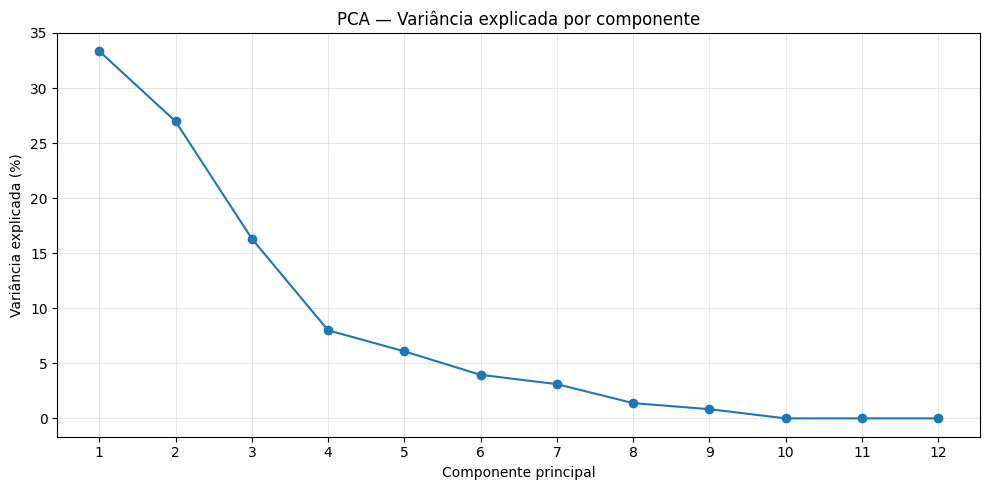

In [149]:
# ============================================================
# SCREE PLOT
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(explained_variance) + 1),
    explained_variance * 100,
    marker="o"
)

plt.xticks(range(1, 13))
plt.xlabel("Componente principal")
plt.ylabel("Variância explicada (%)")
plt.title("PCA — Variância explicada por componente")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

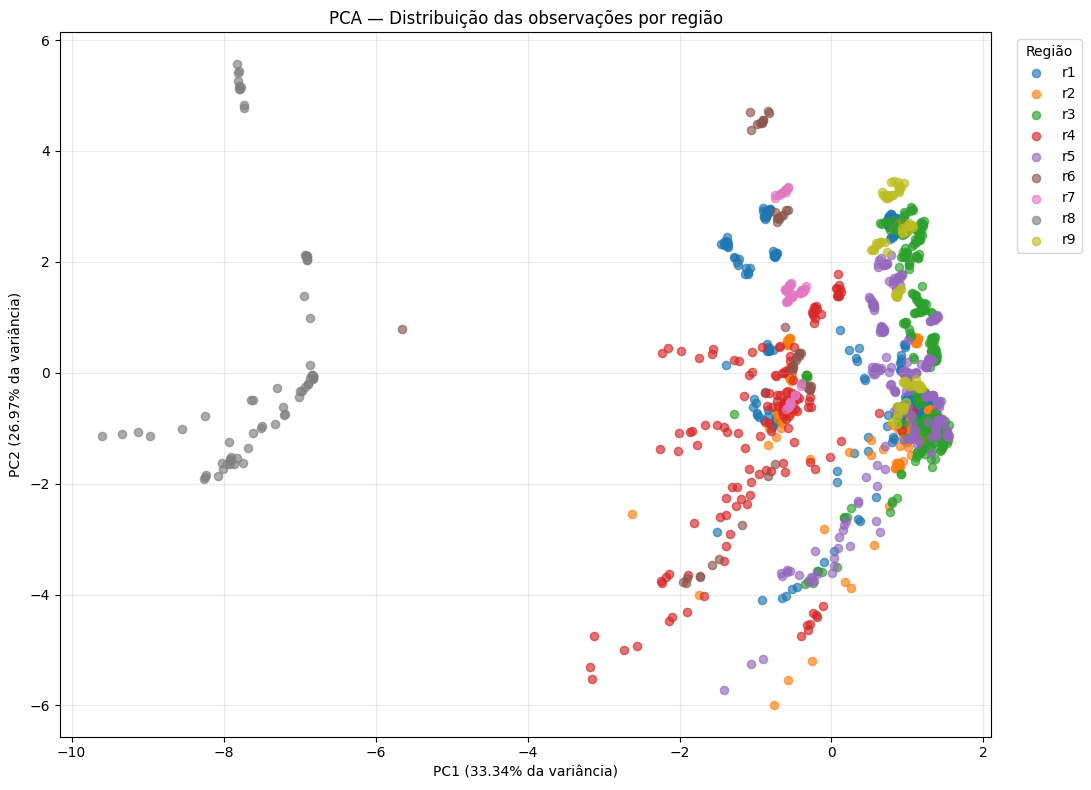

In [150]:
# ============================================================
# PCA — COLORAÇÃO POR REGIÃO
# ============================================================

regions = sorted(df_pca["region"].dropna().unique())

plt.figure(figsize=(11, 8))

for region in regions:

    mask = df_pca["region"].values == region

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=region,
        alpha=0.65,
        s=35
    )

pc1_var = explained_variance[0] * 100
pc2_var = explained_variance[1] * 100

plt.xlabel(f"PC1 ({pc1_var:.2f}% da variância)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% da variância)")
plt.title("PCA — Distribuição das observações por região")

plt.legend(
    title="Região",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

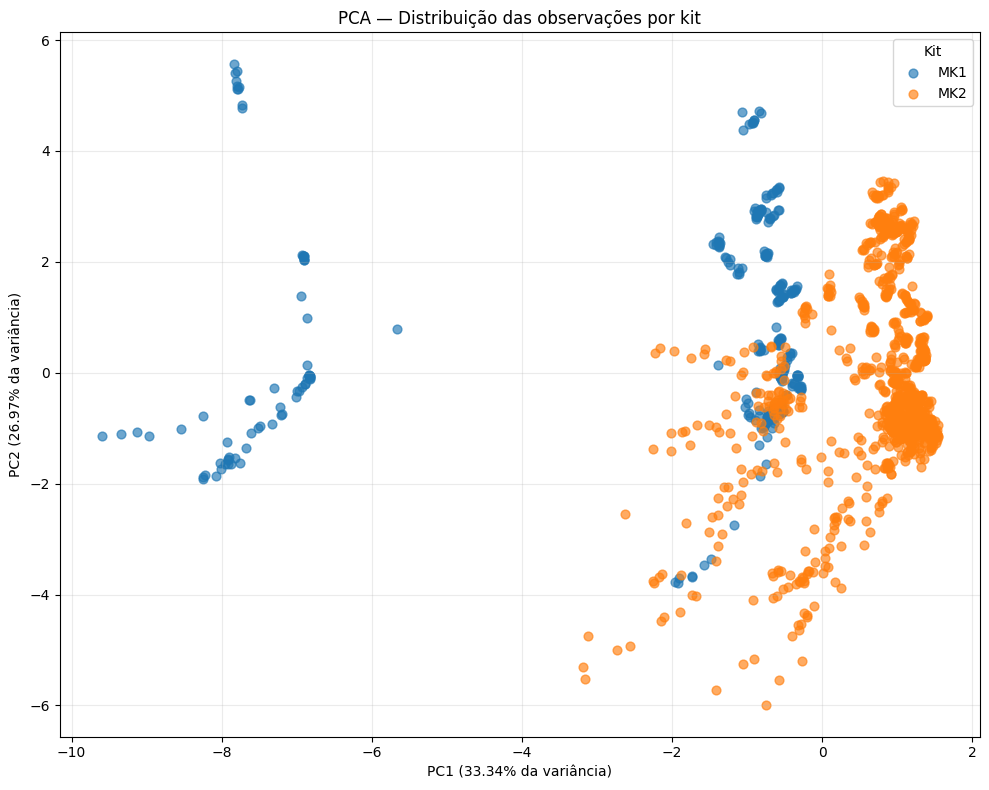

In [151]:
# ============================================================
# PCA — COLORAÇÃO POR KIT
# ============================================================

kits = sorted(df_pca["kit"].dropna().unique())

plt.figure(figsize=(10, 8))

for kit in kits:

    mask = df_pca["kit"].values == kit

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=kit,
        alpha=0.65,
        s=40
    )

plt.xlabel(f"PC1 ({pc1_var:.2f}% da variância)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% da variância)")
plt.title("PCA — Distribuição das observações por kit")

plt.legend(title="Kit")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

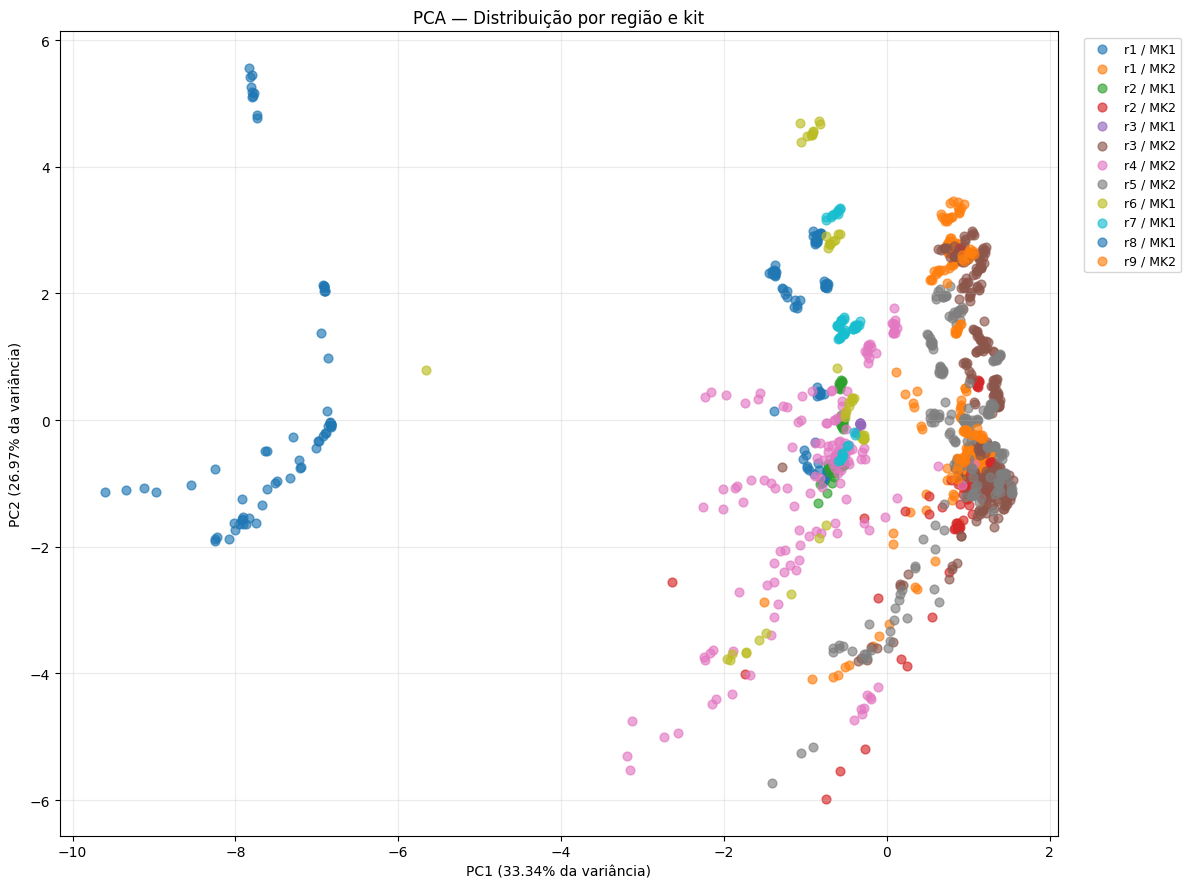

In [152]:
# ============================================================
# PCA — REGIÃO × KIT
# ============================================================

plt.figure(figsize=(12, 9))

for region in regions:

    for kit in kits:

        mask = (
            (df_pca["region"].values == region) &
            (df_pca["kit"].values == kit)
        )

        if mask.sum() == 0:
            continue

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=f"{region} / {kit}",
            alpha=0.65,
            s=40
        )

plt.xlabel(f"PC1 ({pc1_var:.2f}% da variância)")
plt.ylabel(f"PC2 ({pc2_var:.2f}% da variância)")
plt.title("PCA — Distribuição por região e kit")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [153]:
# ============================================================
# LOADINGS DO PCA
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=[f"PC{i}" for i in range(1, 13)]
)

print("=" * 80)
print("LOADINGS — PCA")
print("=" * 80)

display(loadings.round(4))

LOADINGS — PCA


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
feature_1,0.4815,-0.0719,0.1250,0.1137,0.0075,-0.0226,-0.0797,0.2388,0.0514,-0.4094,0.0158,0.7071
feature_2,0.4815,-0.0719,0.1250,0.1137,0.0075,-0.0226,-0.0797,0.2387,0.0514,-0.4099,-0.0142,-0.7068
feature_3,0.4817,-0.0399,0.1535,0.0747,0.0239,0.0467,-0.0612,0.2647,0.0507,0.8112,-0.0014,-0.0003
feature_4,-0.0465,0.3493,0.2901,-0.3984,0.1550,0.6957,0.2475,0.2347,0.0479,-0.0790,0.0002,0.0000
feature_5,-0.4484,0.0238,-0.1438,0.0816,0.0160,-0.1229,-0.2789,0.8000,0.1946,-0.0004,0.0001,-0.0001
feature_6,-0.1560,-0.1083,0.3706,0.2587,0.8398,-0.0393,-0.1874,-0.1164,-0.0644,-0.0013,-0.0000,0.0000
feature_7,0.0050,0.4883,0.2740,-0.0667,-0.1336,-0.2173,-0.3270,-0.0999,-0.0014,-0.0014,-0.7069,0.0150
feature_8,0.0049,0.4883,0.2740,-0.0667,-0.1336,-0.2174,-0.3269,-0.1001,-0.0015,0.0012,0.7070,-0.0150
feature_9,-0.1565,0.1948,0.3642,0.5960,-0.1976,-0.1274,0.6122,0.0811,0.1145,0.0043,-0.0000,-0.0000
feature_10,-0.1751,-0.2930,0.2675,0.3677,-0.4030,0.5290,-0.4449,-0.1060,-0.1591,-0.0025,0.0001,0.0000


In [154]:
# ============================================================
# CONTRIBUIÇÃO DAS FEATURES PARA PC1 E PC2
# ============================================================

for pc in ["PC1", "PC2"]:

    print("\n" + "=" * 80)
    print(f"MAIORES LOADINGS ABSOLUTOS — {pc}")
    print("=" * 80)

    temp = (
        loadings[pc]
        .abs()
        .sort_values(ascending=False)
        .to_frame("abs_loading")
    )

    temp["loading"] = loadings.loc[
        temp.index,
        pc
    ]

    display(temp.round(4))


MAIORES LOADINGS ABSOLUTOS — PC1


,abs_loading,loading
feature_3,0.4817,0.4817
feature_2,0.4815,0.4815
feature_1,0.4815,0.4815
feature_5,0.4484,-0.4484
feature_10,0.1751,-0.1751
feature_9,0.1565,-0.1565
feature_6,0.1560,-0.1560
feature_11,0.1091,-0.1091
feature_12,0.0975,-0.0975
feature_4,0.0465,-0.0465



MAIORES LOADINGS ABSOLUTOS — PC2


,abs_loading,loading
feature_8,0.4883,0.4883
feature_7,0.4883,0.4883
feature_12,0.3875,-0.3875
feature_4,0.3493,0.3493
feature_11,0.3209,-0.3209
feature_10,0.2930,-0.2930
feature_9,0.1948,0.1948
feature_6,0.1083,-0.1083
feature_1,0.0719,-0.0719
feature_2,0.0719,-0.0719


PCA NO NÍVEL DE APARELHO
Total de aparelhos: 134

Aparelhos por região:
region
r1    26
r2    18
r3    29
r4    15
r5    21
r6     5
r7     5
r8     7
r9     8
Name: count, dtype: int64

Aparelhos por kit:
kit
MK1     32
MK2    102
Name: count, dtype: int64


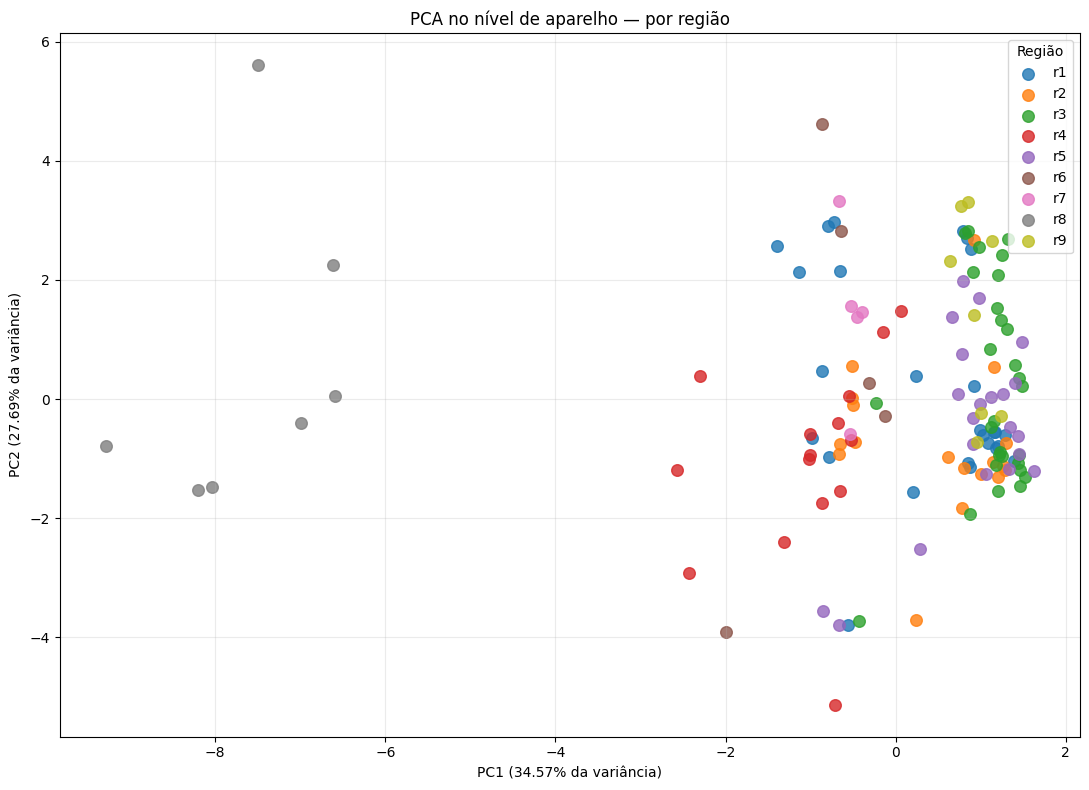

In [155]:
# ============================================================
# PCA NO NÍVEL DE APARELHO
# Mediana das observações de cada aparelho
# ============================================================

df_app_pca = (
    df_analysis
    .groupby(
        ["appliance", "region", "kit"],
        as_index=False
    )[feature_cols]
    .median()
)

print("=" * 80)
print("PCA NO NÍVEL DE APARELHO")
print("=" * 80)

print(f"Total de aparelhos: {len(df_app_pca)}")

print("\nAparelhos por região:")
print(
    df_app_pca["region"]
    .value_counts()
    .sort_index()
)

print("\nAparelhos por kit:")
print(
    df_app_pca["kit"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# Padronização
# ------------------------------------------------------------

X_app = df_app_pca[feature_cols].values

scaler_app = StandardScaler()
X_app_std = scaler_app.fit_transform(X_app)

# ------------------------------------------------------------
# PCA
# ------------------------------------------------------------

pca_app = PCA()
X_app_pca = pca_app.fit_transform(X_app_std)

ev_app = pca_app.explained_variance_ratio_

pc1_app = ev_app[0] * 100
pc2_app = ev_app[1] * 100

# ------------------------------------------------------------
# Visualização por região
# ------------------------------------------------------------

plt.figure(figsize=(11, 8))

for region in sorted(df_app_pca["region"].unique()):

    mask = df_app_pca["region"].values == region

    plt.scatter(
        X_app_pca[mask, 0],
        X_app_pca[mask, 1],
        label=region,
        s=70,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({pc1_app:.2f}% da variância)")
plt.ylabel(f"PC2 ({pc2_app:.2f}% da variância)")
plt.title("PCA no nível de aparelho — por região")

plt.legend(title="Região")
plt.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [156]:
# ============================================================
# LOADINGS CORRETOS — PCA NO NÍVEL DE APARELHO
# ============================================================

# Supondo que o PCA por aparelho tenha sido criado como:
# pca_app = PCA()
# X_pca_app = pca_app.fit_transform(X_app_std)

loadings_app = pd.DataFrame(
    pca_app.components_.T,
    index=feature_cols,
    columns=[f"PC{i+1}" for i in range(pca_app.n_components_)]
)

print("=" * 80)
print("LOADINGS — PCA NO NÍVEL DE APARELHO")
print("=" * 80)

display(loadings_app.round(4))

LOADINGS — PCA NO NÍVEL DE APARELHO


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
feature_1,0.4696,-0.0828,0.1402,0.1229,-0.0258,0.0112,-0.0528,0.2292,0.1168,-0.4097,-0.0159,0.7071
feature_2,0.4696,-0.0828,0.1402,0.1229,-0.0258,0.0112,-0.0528,0.2292,0.1167,-0.4103,0.0149,-0.7068
feature_3,0.4703,-0.0510,0.1695,0.0853,0.0094,0.0631,-0.0152,0.2503,0.1248,0.8110,0.0008,-0.0003
feature_4,-0.0409,0.3553,0.2921,-0.4001,0.3373,0.5139,0.4474,0.1572,0.1337,-0.0775,-0.0002,0.0000
feature_5,-0.4350,0.0348,-0.1813,0.0176,-0.1894,-0.0185,-0.1528,0.7368,0.4170,-0.0003,-0.0002,-0.0001
feature_6,-0.2296,-0.0729,0.3480,0.3093,0.7520,-0.1207,-0.3567,0.1074,-0.0795,-0.0036,0.0000,-0.0000
feature_7,0.0175,0.4880,0.2589,-0.0857,-0.2107,-0.0664,-0.3657,-0.0608,-0.0312,-0.0009,0.7069,0.0154
feature_8,0.0174,0.4880,0.2589,-0.0856,-0.2107,-0.0665,-0.3657,-0.0611,-0.0314,0.0006,-0.7069,-0.0154
feature_9,-0.1567,0.2441,0.3253,0.6040,-0.1822,-0.2819,0.5604,-0.0481,0.1273,0.0045,0.0000,-0.0000
feature_10,-0.2068,-0.2797,0.2759,0.3392,-0.3327,0.7200,-0.1818,-0.0736,-0.1423,-0.0019,0.0000,0.0000


In [157]:
# ============================================================
# MAIORES LOADINGS — PC1
# ============================================================

pc1_app = (
    loadings_app["PC1"]
    .abs()
    .sort_values(ascending=False)
)

print("=" * 80)
print("MAIORES LOADINGS ABSOLUTOS — PC1 — APARELHO")
print("=" * 80)

display(
    pd.DataFrame({
        "abs_loading": pc1_app,
        "loading": loadings_app.loc[pc1_app.index, "PC1"]
    }).round(4)
)

MAIORES LOADINGS ABSOLUTOS — PC1 — APARELHO


,abs_loading,loading
feature_3,0.4703,0.4703
feature_2,0.4696,0.4696
feature_1,0.4696,0.4696
feature_5,0.4350,-0.4350
feature_6,0.2296,-0.2296
feature_10,0.2068,-0.2068
feature_9,0.1567,-0.1567
feature_11,0.1192,-0.1192
feature_12,0.1098,-0.1098
feature_4,0.0409,-0.0409


In [158]:
# ============================================================
# MAIORES LOADINGS — PC2
# ============================================================

pc2_app = (
    loadings_app["PC2"]
    .abs()
    .sort_values(ascending=False)
)

print("=" * 80)
print("MAIORES LOADINGS ABSOLUTOS — PC2 — APARELHO")
print("=" * 80)

display(
    pd.DataFrame({
        "abs_loading": pc2_app,
        "loading": loadings_app.loc[pc2_app.index, "PC2"]
    }).round(4)
)

MAIORES LOADINGS ABSOLUTOS — PC2 — APARELHO


,abs_loading,loading
feature_7,0.4880,0.4880
feature_8,0.4880,0.4880
feature_12,0.3772,-0.3772
feature_4,0.3553,0.3553
feature_11,0.3076,-0.3076
feature_10,0.2797,-0.2797
feature_9,0.2441,0.2441
feature_1,0.0828,-0.0828
feature_2,0.0828,-0.0828
feature_6,0.0729,-0.0729


In [159]:
# ============================================================
# PCA — PREPARAÇÃO DOS DADOS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Features utilizadas no modelo
feature_cols = [f"feature_{i}" for i in range(1, 13)]

# Conferência
print("=" * 80)
print("PREPARAÇÃO PARA PCA")
print("=" * 80)

print(f"Observações: {len(df_analysis)}")
print(f"Características: {len(feature_cols)}")

print("\nFeatures:")
print(feature_cols)

print("\nKits:")
print(df_analysis["kit"].value_counts())

print("\nRegiões:")
print(df_analysis["region"].value_counts().sort_index())

PREPARAÇÃO PARA PCA
Observações: 1339
Características: 12

Features:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12']

Kits:
kit
MK2    1019
MK1     320
Name: count, dtype: int64

Regiões:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64


In [160]:
# ============================================================
# FUNÇÃO PADRONIZADA PARA PCA
# ============================================================

def executar_pca(df, nome_analise):
    """
    Executa PCA sobre as 12 características.

    A padronização é realizada exclusivamente sobre o
    conjunto fornecido à função.
    """

    X = df[feature_cols].astype(float).values

    # Padronização específica deste conjunto
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # PCA
    pca = PCA()
    X_pca = pca.fit_transform(X_std)

    explained = pca.explained_variance_ratio_ * 100
    cumulative = np.cumsum(explained)

    print("=" * 80)
    print(nome_analise)
    print("=" * 80)

    print(f"Observações/unidades: {len(df)}")
    print(f"Características: {X.shape[1]}")
    print(f"PC1: {explained[0]:.3f}%")
    print(f"PC2: {explained[1]:.3f}%")
    print(f"PC1 + PC2: {cumulative[1]:.3f}%")
    print(f"PC1–PC3: {cumulative[2]:.3f}%")
    print(f"PC1–PC5: {cumulative[4]:.3f}%")

    return {
        "df": df.copy(),
        "X_std": X_std,
        "X_pca": X_pca,
        "scaler": scaler,
        "pca": pca,
        "explained": explained,
        "cumulative": cumulative
    }

In [161]:
# ============================================================
# PCA 1 — GLOBAL / NÍVEL DE OBSERVAÇÃO
# MK1 + MK2
# ============================================================

pca_obs = executar_pca(
    df_analysis,
    "PCA GLOBAL — NÍVEL DE OBSERVAÇÃO — MK1 + MK2"
)

PCA GLOBAL — NÍVEL DE OBSERVAÇÃO — MK1 + MK2
Observações/unidades: 1339
Características: 12
PC1: 33.345%
PC2: 26.968%
PC1 + PC2: 60.313%
PC1–PC3: 76.628%
PC1–PC5: 90.715%


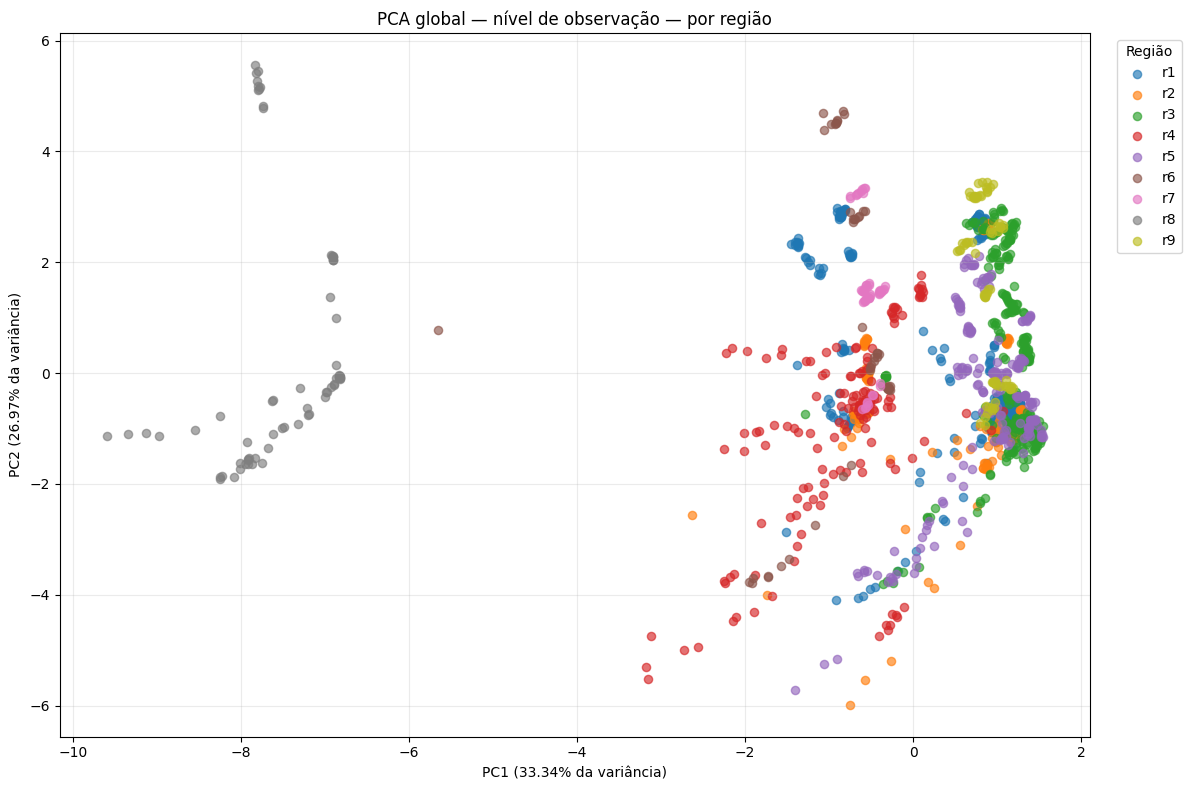

In [162]:
# ============================================================
# GRÁFICO 1
# PCA GLOBAL — OBSERVAÇÃO — POR REGIÃO
# ============================================================

df_plot = pca_obs["df"].copy()
X_pca = pca_obs["X_pca"]
explained = pca_obs["explained"]

regions = sorted(df_plot["region"].astype(str).unique())

plt.figure(figsize=(12, 8))

for region in regions:
    mask = df_plot["region"].astype(str).values == region

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=region,
        alpha=0.65,
        s=35
    )

plt.xlabel(f"PC1 ({explained[0]:.2f}% da variância)")
plt.ylabel(f"PC2 ({explained[1]:.2f}% da variância)")
plt.title(
    "PCA global — nível de observação — por região"
)

plt.legend(
    title="Região",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [163]:
# ============================================================
# AGREGAÇÃO NO NÍVEL DE APARELHO
# ============================================================

group_cols = ["appliance"]

agg_dict = {
    feature: "median"
    for feature in feature_cols
}

# Mediana das características
df_appliance = (
    df_analysis
    .groupby(group_cols, as_index=False)
    .agg(agg_dict)
)

# Recuperar metadados invariantes do aparelho
metadata_app = (
    df_analysis[
        ["appliance", "region", "kit"]
    ]
    .drop_duplicates(subset=["appliance"])
)

df_appliance = df_appliance.merge(
    metadata_app,
    on="appliance",
    how="left"
)

# Organização das colunas
df_appliance = df_appliance[
    ["appliance", "region", "kit"] + feature_cols
].copy()

df_appliance = df_appliance.reset_index(drop=True)

print("=" * 80)
print("AUDITORIA — NÍVEL DE APARELHO")
print("=" * 80)

print(f"Aparelhos: {len(df_appliance)}")
print(f"Características: {len(feature_cols)}")

print("\nAparelhos por kit:")
print(df_appliance["kit"].value_counts())

print("\nAparelhos por região:")
print(
    df_appliance["region"]
    .value_counts()
    .sort_index()
)

print("\nRegião × kit:")
print(
    pd.crosstab(
        df_appliance["region"],
        df_appliance["kit"]
    )
)

AUDITORIA — NÍVEL DE APARELHO
Aparelhos: 134
Características: 12

Aparelhos por kit:
kit
MK2    102
MK1     32
Name: count, dtype: int64

Aparelhos por região:
region
r1    26
r2    18
r3    29
r4    15
r5    21
r6     5
r7     5
r8     7
r9     8
Name: count, dtype: int64

Região × kit:
kit     MK1  MK2
region          
r1        8   18
r2        6   12
r3        1   28
r4        0   15
r5        0   21
r6        5    0
r7        5    0
r8        7    0
r9        0    8


In [164]:
# ============================================================
# PCA 2 — GLOBAL / NÍVEL DE APARELHO
# MK1 + MK2
# ============================================================

pca_app = executar_pca(
    df_appliance,
    "PCA GLOBAL — NÍVEL DE APARELHO — MK1 + MK2"
)

PCA GLOBAL — NÍVEL DE APARELHO — MK1 + MK2
Observações/unidades: 134
Características: 12
PC1: 34.574%
PC2: 27.693%
PC1 + PC2: 62.266%
PC1–PC3: 77.371%
PC1–PC5: 91.136%


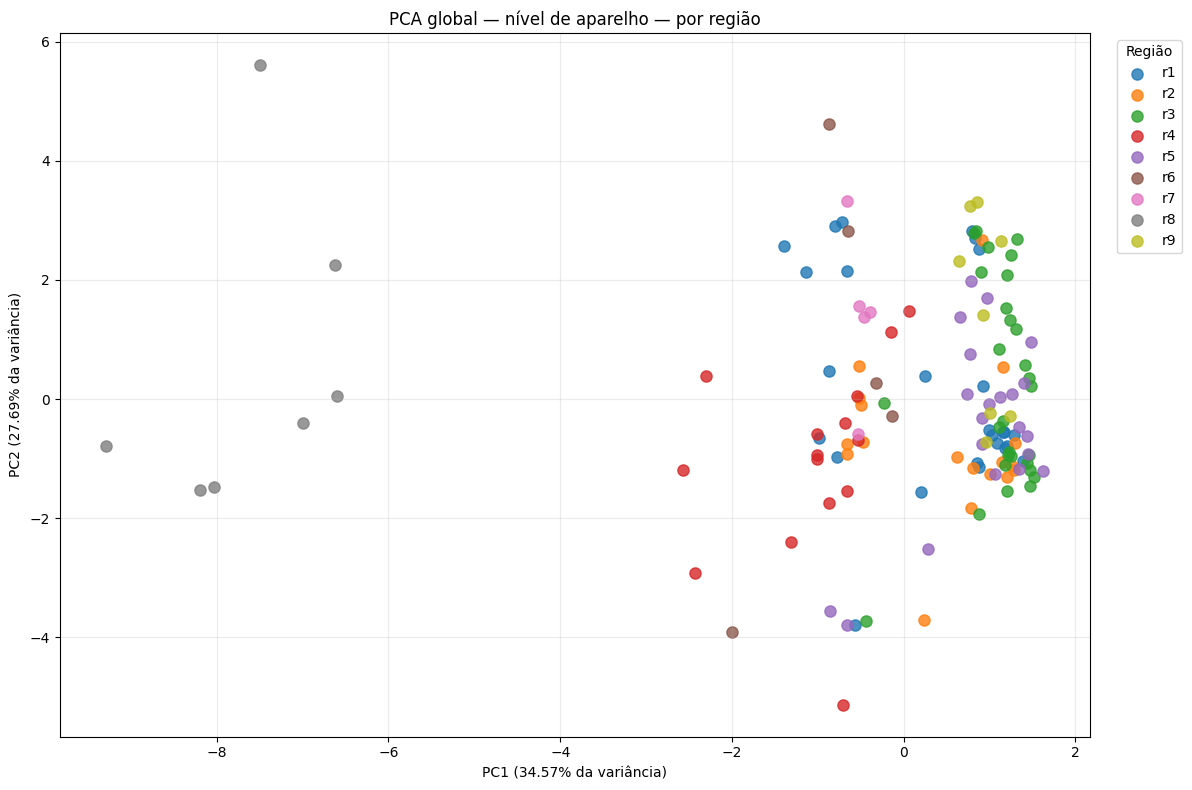

In [165]:
# ============================================================
# GRÁFICO 2
# PCA GLOBAL — APARELHO — POR REGIÃO
# ============================================================

df_plot = pca_app["df"].copy()
X_pca = pca_app["X_pca"]
explained = pca_app["explained"]

regions = sorted(
    df_plot["region"].astype(str).unique()
)

plt.figure(figsize=(12, 8))

for region in regions:

    mask = (
        df_plot["region"]
        .astype(str)
        .values == region
    )

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=region,
        alpha=0.80,
        s=65
    )

plt.xlabel(
    f"PC1 ({explained[0]:.2f}% da variância)"
)

plt.ylabel(
    f"PC2 ({explained[1]:.2f}% da variância)"
)

plt.title(
    "PCA global — nível de aparelho — por região"
)

plt.legend(
    title="Região",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [166]:
# ============================================================
# PCA 3 — NÍVEL DE APARELHO — MK1
# ============================================================

df_mk1_app = df_appliance[
    df_appliance["kit"] == "MK1"
].copy()

df_mk1_app = df_mk1_app.reset_index(drop=True)

pca_mk1_app = executar_pca(
    df_mk1_app,
    "PCA ESTRATIFICADO — APARELHO — MK1"
)

PCA ESTRATIFICADO — APARELHO — MK1
Observações/unidades: 32
Características: 12
PC1: 42.888%
PC2: 26.700%
PC1 + PC2: 69.589%
PC1–PC3: 84.508%
PC1–PC5: 95.284%


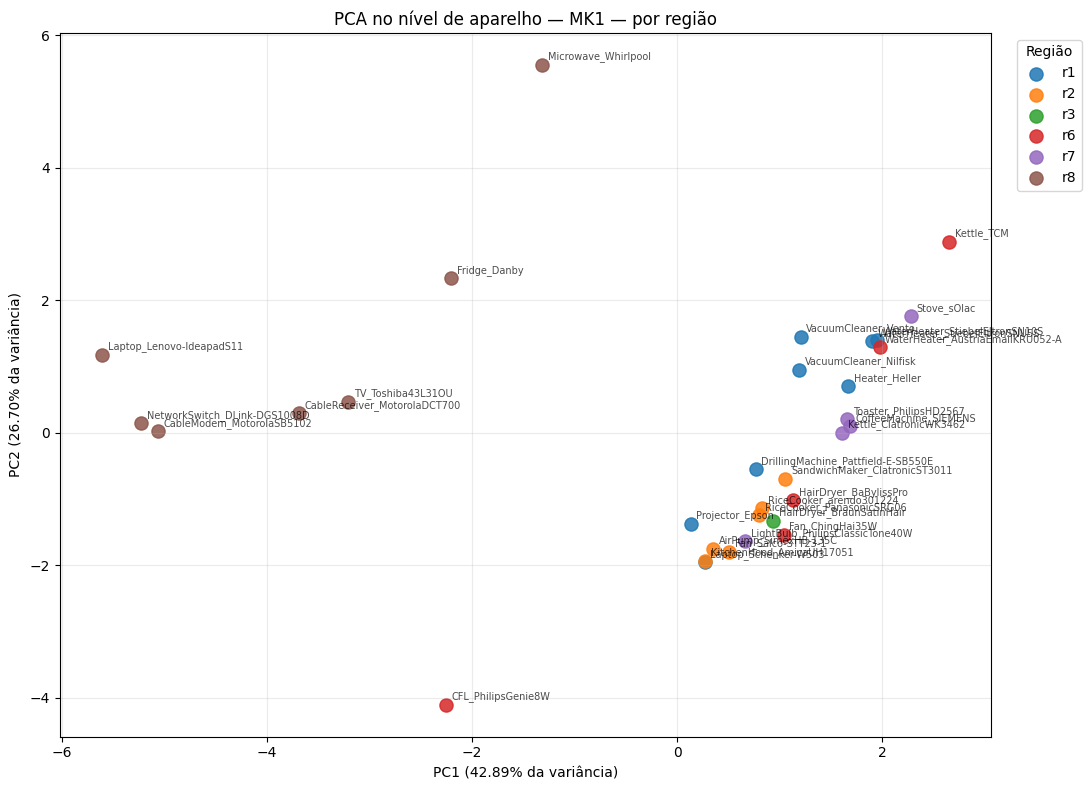

In [167]:
# ============================================================
# GRÁFICO 3
# PCA — APARELHO — MK1 — POR REGIÃO
# ============================================================

df_plot = pca_mk1_app["df"].copy()
X_pca = pca_mk1_app["X_pca"]
explained = pca_mk1_app["explained"]

regions = sorted(
    df_plot["region"].astype(str).unique()
)

plt.figure(figsize=(11, 8))

for region in regions:

    mask = (
        df_plot["region"]
        .astype(str)
        .values == region
    )

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=region,
        alpha=0.85,
        s=90
    )

    # Nome do aparelho próximo ao ponto
    for idx in np.where(mask)[0]:

        appliance_name = str(
            df_plot.iloc[idx]["appliance"]
        )

        plt.annotate(
            appliance_name,
            (
                X_pca[idx, 0],
                X_pca[idx, 1]
            ),
            fontsize=7,
            alpha=0.70,
            xytext=(4, 4),
            textcoords="offset points"
        )

plt.xlabel(
    f"PC1 ({explained[0]:.2f}% da variância)"
)

plt.ylabel(
    f"PC2 ({explained[1]:.2f}% da variância)"
)

plt.title(
    "PCA no nível de aparelho — MK1 — por região"
)

plt.legend(
    title="Região",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [168]:
# ============================================================
# PCA 4 — NÍVEL DE APARELHO — MK2
# ============================================================

df_mk2_app = df_appliance[
    df_appliance["kit"] == "MK2"
].copy()

df_mk2_app = df_mk2_app.reset_index(drop=True)

pca_mk2_app = executar_pca(
    df_mk2_app,
    "PCA ESTRATIFICADO — APARELHO — MK2"
)

PCA ESTRATIFICADO — APARELHO — MK2
Observações/unidades: 102
Características: 12
PC1: 31.841%
PC2: 24.591%
PC1 + PC2: 56.432%
PC1–PC3: 71.516%
PC1–PC5: 89.951%


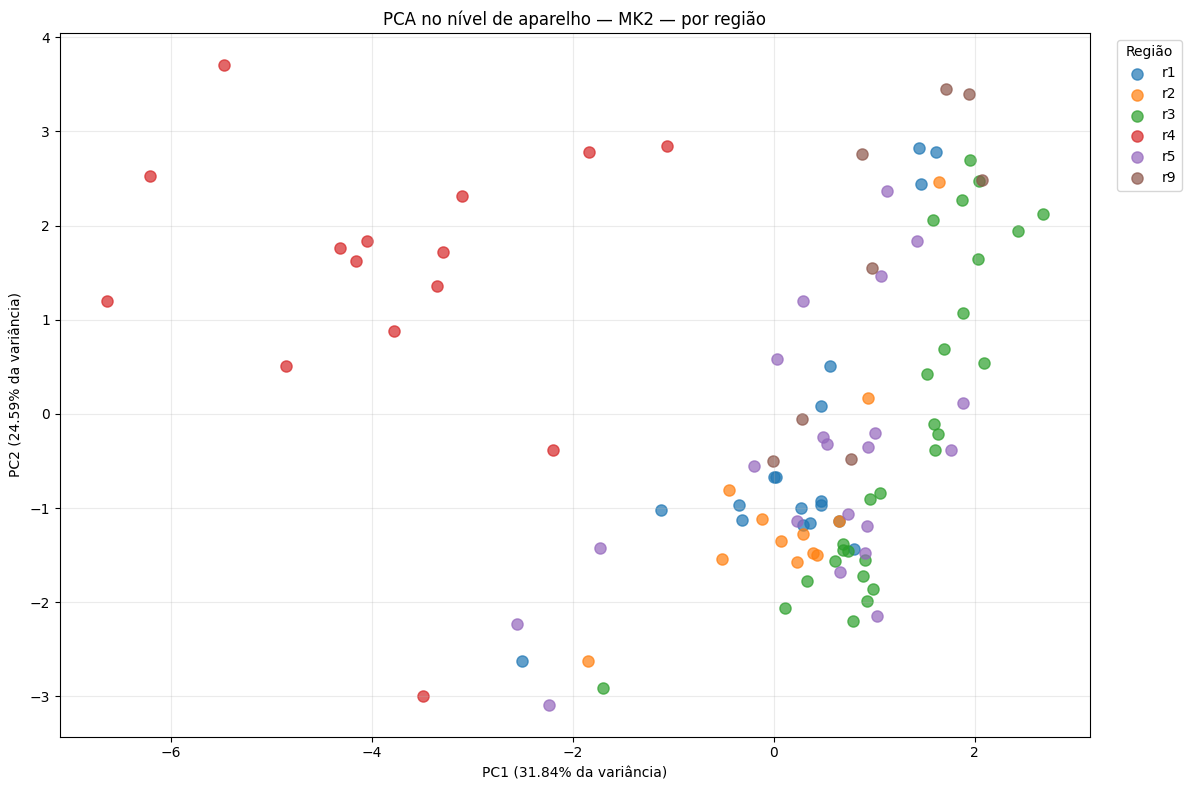

In [169]:
# ============================================================
# GRÁFICO 4
# PCA — APARELHO — MK2 — POR REGIÃO
# ============================================================

df_plot = pca_mk2_app["df"].copy()
X_pca = pca_mk2_app["X_pca"]
explained = pca_mk2_app["explained"]

regions = sorted(
    df_plot["region"].astype(str).unique()
)

plt.figure(figsize=(12, 8))

for region in regions:

    mask = (
        df_plot["region"]
        .astype(str)
        .values == region
    )

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=region,
        alpha=0.70,
        s=65
    )

plt.xlabel(
    f"PC1 ({explained[0]:.2f}% da variância)"
)

plt.ylabel(
    f"PC2 ({explained[1]:.2f}% da variância)"
)

plt.title(
    "PCA no nível de aparelho — MK2 — por região"
)

plt.legend(
    title="Região",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [170]:
# ============================================================
# RESUMO DOS QUATRO PCA
# ============================================================

resultados_pca = []

for nome, resultado in [
    ("Global — observação", pca_obs),
    ("Global — aparelho", pca_app),
    ("MK1 — aparelho", pca_mk1_app),
    ("MK2 — aparelho", pca_mk2_app),
]:

    resultados_pca.append({
        "Análise": nome,
        "N": len(resultado["df"]),
        "PC1 (%)": resultado["explained"][0],
        "PC2 (%)": resultado["explained"][1],
        "PC1+PC2 (%)": resultado["cumulative"][1],
        "PC1+PC2+PC3 (%)": resultado["cumulative"][2],
        "PC1–PC5 (%)": resultado["cumulative"][4],
    })

df_resumo_pca = pd.DataFrame(resultados_pca)

display(
    df_resumo_pca.round(3)
)

,Análise,N,PC1 (%),PC2 (%),PC1+PC2 (%),PC1+PC2+PC3 (%),PC1–PC5 (%)
0,Global — observação,1339,33.345,26.968,60.313,76.628,90.715
1,Global — aparelho,134,34.574,27.693,62.266,77.371,91.136
2,MK1 — aparelho,32,42.888,26.700,69.589,84.508,95.284
3,MK2 — aparelho,102,31.841,24.591,56.432,71.516,89.951


In [171]:
# ============================================================
# LOADINGS — COMPARAÇÃO DOS QUATRO PCA
# ============================================================

def obter_loadings(resultado):

    pca = resultado["pca"]

    return pd.DataFrame(
        pca.components_.T,
        index=feature_cols,
        columns=[
            f"PC{i+1}"
            for i in range(pca.n_components_)
        ]
    )


loadings_global_obs = obter_loadings(pca_obs)
loadings_global_app = obter_loadings(pca_app)
loadings_mk1_app = obter_loadings(pca_mk1_app)
loadings_mk2_app = obter_loadings(pca_mk2_app)


print("=" * 80)
print("LOADINGS — PC1")
print("=" * 80)

df_loadings_pc1 = pd.DataFrame({
    "Global_Obs": loadings_global_obs["PC1"],
    "Global_App": loadings_global_app["PC1"],
    "MK1_App": loadings_mk1_app["PC1"],
    "MK2_App": loadings_mk2_app["PC1"],
})

display(
    df_loadings_pc1.round(4)
)

LOADINGS — PC1


,Global_Obs,Global_App,MK1_App,MK2_App
feature_1,0.4815,0.4696,0.3809,0.4016
feature_2,0.4815,0.4696,0.3809,0.4016
feature_3,0.4817,0.4703,0.3878,0.4267
feature_4,-0.0465,-0.0409,0.2296,0.0205
feature_5,-0.4484,-0.4350,-0.3874,-0.1448
feature_6,-0.1560,-0.2296,-0.2053,-0.3468
feature_7,0.0050,0.0175,0.2220,0.2642
feature_8,0.0049,0.0174,0.2220,0.2641
feature_9,-0.1565,-0.1567,-0.0434,0.0192
feature_10,-0.1751,-0.2068,-0.3423,-0.2147


In [172]:
# ============================================================
# RANKING DOS LOADINGS ABSOLUTOS
# ============================================================

def ranking_loadings(loadings, componente="PC1"):

    resultado = pd.DataFrame({
        "loading": loadings[componente],
        "abs_loading": loadings[componente].abs()
    })

    return resultado.sort_values(
        "abs_loading",
        ascending=False
    )


print("=" * 80)
print("RANKING — PC1 — GLOBAL OBSERVAÇÃO")
print("=" * 80)

display(
    ranking_loadings(
        loadings_global_obs,
        "PC1"
    ).round(4)
)


print("=" * 80)
print("RANKING — PC1 — GLOBAL APARELHO")
print("=" * 80)

display(
    ranking_loadings(
        loadings_global_app,
        "PC1"
    ).round(4)
)


print("=" * 80)
print("RANKING — PC1 — MK1")
print("=" * 80)

display(
    ranking_loadings(
        loadings_mk1_app,
        "PC1"
    ).round(4)
)


print("=" * 80)
print("RANKING — PC1 — MK2")
print("=" * 80)

display(
    ranking_loadings(
        loadings_mk2_app,
        "PC1"
    ).round(4)
)

RANKING — PC1 — GLOBAL OBSERVAÇÃO


,loading,abs_loading
feature_3,0.4817,0.4817
feature_2,0.4815,0.4815
feature_1,0.4815,0.4815
feature_5,-0.4484,0.4484
feature_10,-0.1751,0.1751
feature_9,-0.1565,0.1565
feature_6,-0.1560,0.1560
feature_11,-0.1091,0.1091
feature_12,-0.0975,0.0975
feature_4,-0.0465,0.0465


RANKING — PC1 — GLOBAL APARELHO


,loading,abs_loading
feature_3,0.4703,0.4703
feature_2,0.4696,0.4696
feature_1,0.4696,0.4696
feature_5,-0.4350,0.4350
feature_6,-0.2296,0.2296
feature_10,-0.2068,0.2068
feature_9,-0.1567,0.1567
feature_11,-0.1192,0.1192
feature_12,-0.1098,0.1098
feature_4,-0.0409,0.0409


RANKING — PC1 — MK1


,loading,abs_loading
feature_3,0.3878,0.3878
feature_5,-0.3874,0.3874
feature_2,0.3809,0.3809
feature_1,0.3809,0.3809
feature_10,-0.3423,0.3423
feature_11,-0.2338,0.2338
feature_4,0.2296,0.2296
feature_8,0.2220,0.2220
feature_7,0.2220,0.2220
feature_12,-0.2058,0.2058


RANKING — PC1 — MK2


,loading,abs_loading
feature_3,0.4267,0.4267
feature_2,0.4016,0.4016
feature_1,0.4016,0.4016
feature_6,-0.3468,0.3468
feature_12,-0.3241,0.3241
feature_7,0.2642,0.2642
feature_8,0.2641,0.2641
feature_11,-0.2503,0.2503
feature_10,-0.2147,0.2147
feature_5,-0.1448,0.1448


In [173]:
# =============================================================================
# SILHOUETTE — COMPARAÇÃO DOS QUATRO CENÁRIOS PCA
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples


# -----------------------------------------------------------------------------
# CONFIGURAÇÃO
# -----------------------------------------------------------------------------

feature_cols = [f"feature_{i}" for i in range(1, 13)]


# -----------------------------------------------------------------------------
# FUNÇÃO AUXILIAR
# -----------------------------------------------------------------------------

def silhouette_analysis(df, name, group_col="region"):
    """
    Calcula silhouette global e por região.

    O cálculo é realizado sobre as 12 características padronizadas.
    """

    df = df.copy().reset_index(drop=True)

    X = df[feature_cols].values
    y = df[group_col].astype(str).values

    # Padronização específica deste cenário
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    # Silhouette por observação
    sil_values = silhouette_samples(X_std, y)

    # Silhouette global
    sil_global = silhouette_score(X_std, y)

    # Tabela por região
    df_sil = pd.DataFrame({
        "region": y,
        "silhouette": sil_values
    })

    regional = (
        df_sil
        .groupby("region")["silhouette"]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            max="max"
        )
        .reset_index()
        .sort_values("region")
    )

    # Percentual de observações com silhouette negativo
    negative_pct = (sil_values < 0).mean() * 100

    # Percentual >= 0
    nonnegative_pct = (sil_values >= 0).mean() * 100

    print("=" * 80)
    print(f"SILHOUETTE — {name}")
    print("=" * 80)

    print(f"N = {len(df)}")
    print(f"Número de regiões = {df[group_col].nunique()}")
    print(f"Silhouette global = {sil_global:.6f}")
    print(f"Silhouette global = {sil_global:.4f}")
    print(f"Observações com silhouette < 0 = {negative_pct:.2f}%")
    print(f"Observações com silhouette >= 0 = {nonnegative_pct:.2f}%")

    print("\nSilhouette por região:")
    display(
        regional.style.format({
            "mean": "{:.4f}",
            "median": "{:.4f}",
            "std": "{:.4f}",
            "min": "{:.4f}",
            "max": "{:.4f}"
        })
    )

    return {
        "name": name,
        "n": len(df),
        "n_regions": df[group_col].nunique(),
        "silhouette_global": sil_global,
        "negative_pct": negative_pct,
        "regional": regional,
        "silhouette_values": sil_values,
        "X_std": X_std
    }


# =============================================================================
# 1. GLOBAL — OBSERVAÇÃO
# =============================================================================

df_global_obs = df_analysis.copy()

result_global_obs = silhouette_analysis(
    df_global_obs,
    "GLOBAL — OBSERVAÇÃO"
)


# =============================================================================
# 2. GLOBAL — APARELHO
# =============================================================================

# Mediana das 10 observações de cada aparelho
df_global_app = (
    df_analysis
    .groupby(["appliance", "region", "kit"], as_index=False)[feature_cols]
    .median()
)

result_global_app = silhouette_analysis(
    df_global_app,
    "GLOBAL — APARELHO"
)


# =============================================================================
# 3. MK1 — APARELHO
# =============================================================================

df_mk1_app = (
    df_analysis[df_analysis["kit"] == "MK1"]
    .groupby(["appliance", "region", "kit"], as_index=False)[feature_cols]
    .median()
)

result_mk1_app = silhouette_analysis(
    df_mk1_app,
    "MK1 — APARELHO"
)


# =============================================================================
# 4. MK2 — APARELHO
# =============================================================================

df_mk2_app = (
    df_analysis[df_analysis["kit"] == "MK2"]
    .groupby(["appliance", "region", "kit"], as_index=False)[feature_cols]
    .median()
)

result_mk2_app = silhouette_analysis(
    df_mk2_app,
    "MK2 — APARELHO"
)

SILHOUETTE — GLOBAL — OBSERVAÇÃO
N = 1339
Número de regiões = 9
Silhouette global = -0.021396
Silhouette global = -0.0214
Observações com silhouette < 0 = 57.28%
Observações com silhouette >= 0 = 42.72%

Silhouette por região:


,region,n,mean,median,std,min,max
0,r1,260,-0.1841,-0.1577,0.1131,-0.4282,-0.0072
1,r2,180,0.0582,0.1036,0.1621,-0.4369,0.2597
2,r3,289,-0.0206,-0.0100,0.0991,-0.2700,0.1868
3,r4,150,-0.1890,-0.2251,0.2174,-0.6263,0.1458
4,r5,210,-0.0385,-0.0298,0.0987,-0.3371,0.1116
5,r6,50,-0.2883,-0.3379,0.1140,-0.4579,-0.0244
6,r7,50,0.3815,0.5082,0.1913,0.1100,0.5631
7,r8,70,0.5033,0.5564,0.1030,0.2753,0.6069
8,r9,80,0.1407,0.1359,0.1010,-0.0847,0.2902


SILHOUETTE — GLOBAL — APARELHO
N = 134
Número de regiões = 9
Silhouette global = -0.068097
Silhouette global = -0.0681
Observações com silhouette < 0 = 65.67%
Observações com silhouette >= 0 = 34.33%

Silhouette por região:


,region,n,mean,median,std,min,max
0,r1,26,-0.2263,-0.2144,0.1118,-0.4349,-0.0258
1,r2,18,0.0808,0.1261,0.1704,-0.4494,0.2731
2,r3,29,-0.0676,-0.0735,0.1018,-0.2963,0.1395
3,r4,15,-0.2155,-0.2399,0.2224,-0.6443,0.1126
4,r5,21,-0.0856,-0.0683,0.0931,-0.3338,0.0201
5,r6,5,-0.3808,-0.4503,0.1169,-0.4707,-0.2073
6,r7,5,0.2439,0.4002,0.2547,-0.0925,0.4529
7,r8,7,0.3690,0.4040,0.1140,0.1713,0.4775
8,r9,8,0.0497,0.0529,0.1268,-0.1567,0.2155


SILHOUETTE — MK1 — APARELHO
N = 32
Número de regiões = 6
Silhouette global = -0.061649
Silhouette global = -0.0616
Observações com silhouette < 0 = 56.25%
Observações com silhouette >= 0 = 43.75%

Silhouette por região:


,region,n,mean,median,std,min,max
0,r1,8,-0.1658,-0.1892,0.2510,-0.4586,0.2024
1,r2,6,-0.1261,-0.1772,0.1421,-0.2765,0.1299
2,r3,1,0.0000,0.0000,nan,0.0000,0.0000
3,r6,5,-0.4731,-0.5120,0.2510,-0.7121,-0.0999
4,r7,5,0.2227,0.4297,0.3568,-0.3561,0.4826
5,r8,7,0.1946,0.2086,0.1262,-0.0277,0.3388


SILHOUETTE — MK2 — APARELHO
N = 102
Número de regiões = 6
Silhouette global = -0.011953
Silhouette global = -0.0120
Observações com silhouette < 0 = 52.94%
Observações com silhouette >= 0 = 47.06%

Silhouette por região:


,region,n,mean,median,std,min,max
0,r1,18,-0.0542,0.0116,0.1553,-0.3967,0.1145
1,r2,12,0.1396,0.2275,0.2090,-0.3067,0.3134
2,r3,28,-0.0648,-0.0815,0.1328,-0.2797,0.2028
3,r4,15,0.1278,0.2230,0.2116,-0.3466,0.3403
4,r5,21,-0.1872,-0.2173,0.1122,-0.3381,0.0533
5,r9,8,0.2389,0.3598,0.2113,-0.0907,0.4164


In [174]:
# =============================================================================
# TABELA COMPARATIVA
# =============================================================================

comparison_silhouette = pd.DataFrame([
    {
        "Análise": "Global — observação",
        "N": result_global_obs["n"],
        "Regiões": result_global_obs["n_regions"],
        "Silhouette": result_global_obs["silhouette_global"],
        "Silhouette (%)": result_global_obs["silhouette_global"] * 100,
        "Silhouette < 0 (%)": result_global_obs["negative_pct"]
    },
    {
        "Análise": "Global — aparelho",
        "N": result_global_app["n"],
        "Regiões": result_global_app["n_regions"],
        "Silhouette": result_global_app["silhouette_global"],
        "Silhouette (%)": result_global_app["silhouette_global"] * 100,
        "Silhouette < 0 (%)": result_global_app["negative_pct"]
    },
    {
        "Análise": "MK1 — aparelho",
        "N": result_mk1_app["n"],
        "Regiões": result_mk1_app["n_regions"],
        "Silhouette": result_mk1_app["silhouette_global"],
        "Silhouette (%)": result_mk1_app["silhouette_global"] * 100,
        "Silhouette < 0 (%)": result_mk1_app["negative_pct"]
    },
    {
        "Análise": "MK2 — aparelho",
        "N": result_mk2_app["n"],
        "Regiões": result_mk2_app["n_regions"],
        "Silhouette": result_mk2_app["silhouette_global"],
        "Silhouette (%)": result_mk2_app["silhouette_global"] * 100,
        "Silhouette < 0 (%)": result_mk2_app["negative_pct"]
    }
])

print("=" * 80)
print("COMPARAÇÃO — SILHOUETTE")
print("=" * 80)

display(
    comparison_silhouette.style.format({
        "Silhouette": "{:.4f}",
        "Silhouette (%)": "{:.2f}",
        "Silhouette < 0 (%)": "{:.2f}"
    })
)

COMPARAÇÃO — SILHOUETTE


,Análise,N,Regiões,Silhouette,Silhouette (%),Silhouette < 0 (%)
0,Global — observação,1339,9,-0.0214,-2.14,57.28
1,Global — aparelho,134,9,-0.0681,-6.81,65.67
2,MK1 — aparelho,32,6,-0.0616,-6.16,56.25
3,MK2 — aparelho,102,6,-0.0120,-1.20,52.94


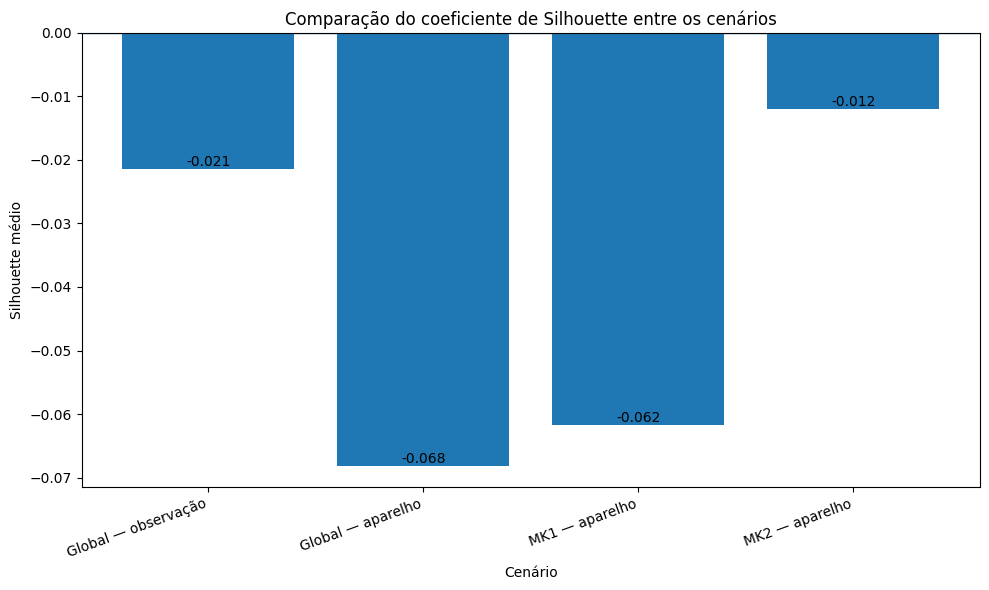

In [175]:
# =============================================================================
# GRÁFICO — SILHOUETTE GLOBAL NOS QUATRO CENÁRIOS
# =============================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

bars = plt.bar(
    comparison_silhouette["Análise"],
    comparison_silhouette["Silhouette"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.ylabel("Silhouette médio")
plt.xlabel("Cenário")
plt.title("Comparação do coeficiente de Silhouette entre os cenários")

plt.xticks(
    rotation=20,
    ha="right"
)

# Valores sobre as barras
for bar, value in zip(
    bars,
    comparison_silhouette["Silhouette"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [176]:
# =============================================================================
# SILHOUETTE POR REGIÃO — TABELA CONSOLIDADA
# =============================================================================

regional_silhouette = pd.concat([
    result_global_obs["regional"]
        .assign(Análise="Global — observação"),

    result_global_app["regional"]
        .assign(Análise="Global — aparelho"),

    result_mk1_app["regional"]
        .assign(Análise="MK1 — aparelho"),

    result_mk2_app["regional"]
        .assign(Análise="MK2 — aparelho")
], ignore_index=True)

regional_silhouette = regional_silhouette[
    [
        "Análise",
        "region",
        "n",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ]
]

regional_silhouette = regional_silhouette.sort_values(
    ["Análise", "region"]
)

print("=" * 80)
print("SILHOUETTE POR REGIÃO — QUATRO CENÁRIOS")
print("=" * 80)

display(
    regional_silhouette.style.format({
        "mean": "{:.4f}",
        "median": "{:.4f}",
        "std": "{:.4f}",
        "min": "{:.4f}",
        "max": "{:.4f}"
    })
)

SILHOUETTE POR REGIÃO — QUATRO CENÁRIOS


,Análise,region,n,mean,median,std,min,max
9,Global — aparelho,r1,26,-0.2263,-0.2144,0.1118,-0.4349,-0.0258
10,Global — aparelho,r2,18,0.0808,0.1261,0.1704,-0.4494,0.2731
11,Global — aparelho,r3,29,-0.0676,-0.0735,0.1018,-0.2963,0.1395
12,Global — aparelho,r4,15,-0.2155,-0.2399,0.2224,-0.6443,0.1126
13,Global — aparelho,r5,21,-0.0856,-0.0683,0.0931,-0.3338,0.0201
14,Global — aparelho,r6,5,-0.3808,-0.4503,0.1169,-0.4707,-0.2073
15,Global — aparelho,r7,5,0.2439,0.4002,0.2547,-0.0925,0.4529
16,Global — aparelho,r8,7,0.3690,0.4040,0.1140,0.1713,0.4775
17,Global — aparelho,r9,8,0.0497,0.0529,0.1268,-0.1567,0.2155
0,Global — observação,r1,260,-0.1841,-0.1577,0.1131,-0.4282,-0.0072


In [177]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

# ============================================================
# 1. Dados no nível de aparelho
# ============================================================

feature_cols = [f"feature_{i+1}" for i in range(12)]

# Mediana das observações de cada aparelho
df_appliance = (
    df_analysis
    .groupby("appliance", as_index=False)
    .agg({
        **{f: "median" for f in feature_cols},
        "region": "first",
        "kit": "first"
    })
)

print("Shape:", df_appliance.shape)
print("\nAparelhos por kit:")
print(df_appliance["kit"].value_counts())

print("\nAparelhos por região:")
print(df_appliance["region"].value_counts().sort_index())

Shape: (134, 15)

Aparelhos por kit:
kit
MK2    102
MK1     32
Name: count, dtype: int64

Aparelhos por região:
region
r1    26
r2    18
r3    29
r4    15
r5    21
r6     5
r7     5
r8     7
r9     8
Name: count, dtype: int64


In [178]:
# ============================================================
# 2. Padronização
# ============================================================

X_app = df_appliance[feature_cols].values

scaler_app = StandardScaler()
X_app_scaled = scaler_app.fit_transform(X_app)

# ============================================================
# 3. PCA global
# ============================================================

pca_global_app = PCA()
X_pca_app = pca_global_app.fit_transform(X_app_scaled)

explained = pca_global_app.explained_variance_ratio_ * 100

print("Variância explicada:")
for i, var in enumerate(explained, start=1):
    print(f"PC{i}: {var:.3f}%")

print(f"\nPC1 + PC2: {explained[:2].sum():.3f}%")

Variância explicada:
PC1: 34.574%
PC2: 27.693%
PC3: 15.105%
PC4: 7.834%
PC5: 5.931%
PC6: 3.589%
PC7: 2.793%
PC8: 1.482%
PC9: 1.000%
PC10: 0.001%
PC11: 0.000%
PC12: 0.000%

PC1 + PC2: 62.266%


In [179]:
# ============================================================
# 4. Silhouette por KIT
# ============================================================

kit_labels = df_appliance["kit"].astype(str).values

silhouette_kit_global = silhouette_score(
    X_app_scaled,
    kit_labels,
    metric="euclidean"
)

sil_samples_kit = silhouette_samples(
    X_app_scaled,
    kit_labels,
    metric="euclidean"
)

print("=" * 60)
print("SILHOUETTE GLOBAL — MK1 vs MK2")
print("=" * 60)

print(f"Silhouette médio: {silhouette_kit_global:.6f}")
print(f"Percentual < 0: {(sil_samples_kit < 0).mean()*100:.2f}%")
print(f"Percentual >= 0: {(sil_samples_kit >= 0).mean()*100:.2f}%")

SILHOUETTE GLOBAL — MK1 vs MK2
Silhouette médio: 0.245778
Percentual < 0: 17.16%
Percentual >= 0: 82.84%


In [180]:
# ============================================================
# 5. Estatísticas por kit
# ============================================================

df_sil_kit = df_appliance[["appliance", "region", "kit"]].copy()
df_sil_kit["silhouette"] = sil_samples_kit

summary_kit = (
    df_sil_kit
    .groupby("kit")["silhouette"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

summary_kit["pct_negative"] = (
    df_sil_kit
    .groupby("kit")["silhouette"]
    .apply(lambda x: (x < 0).mean() * 100)
)

display(summary_kit)

,n,mean,median,std,min,max,pct_negative
kit,,,,,,,
MK1,32,-0.047095,-0.086614,0.144343,-0.213675,0.225286,71.875
MK2,102,0.337659,0.395124,0.129430,0.037533,0.479059,0.000


In [181]:
# ============================================================
# 6. Ordenar aparelhos pelo Silhouette
# ============================================================

df_sil_kit_sorted = df_sil_kit.sort_values(
    "silhouette",
    ascending=False
)

display(df_sil_kit_sorted.head(15))

print("\nAparelhos com menor silhouette:")
display(df_sil_kit_sorted.tail(15))

,appliance,region,kit,silhouette
10,Charger_Patona,r5,MK2,0.479059
77,LightBulb_Osram-100W,r1,MK2,0.478882
90,Mixer_KenwoodCH580W,r1,MK2,0.478321
91,Mixer_OK-200W,r1,MK2,0.477161
8,Charger_Blackberry,r5,MK2,0.477034
79,LightBulb_Osram25W,r1,MK2,0.474077
24,Fan_HoneywellCL25AE,r5,MK2,0.473175
109,Shredder_HSMX8-230W,r1,MK2,0.471858
82,LightBulb_Vintage-40W,r1,MK2,0.471290
94,Monitor_FujitsuP171,r1,MK2,0.471235



Aparelhos com menor silhouette:


,appliance,region,kit,silhouette
4,CFL_PhilipsGenie8W,r6,MK1,-0.113693
15,CoffeeMachine_SIEMENS,r7,MK1,-0.125480
105,SandwichMaker_ClatronicST3011,r2,MK1,-0.135000
19,DrillingMachine_Pattfield-E-SB550E,r1,MK1,-0.135178
104,RiceCooker_arendo301224,r2,MK1,-0.156298
103,RiceCooker_PanasonicSRG06,r2,MK1,-0.160530
37,HairDryer_BaBylissPro,r6,MK1,-0.170008
74,Laptop_Schenker-W503,r1,MK1,-0.173159
1,AirPump_SimexHB-135C,r2,MK1,-0.176015
102,Projector_Epson,r1,MK1,-0.176230


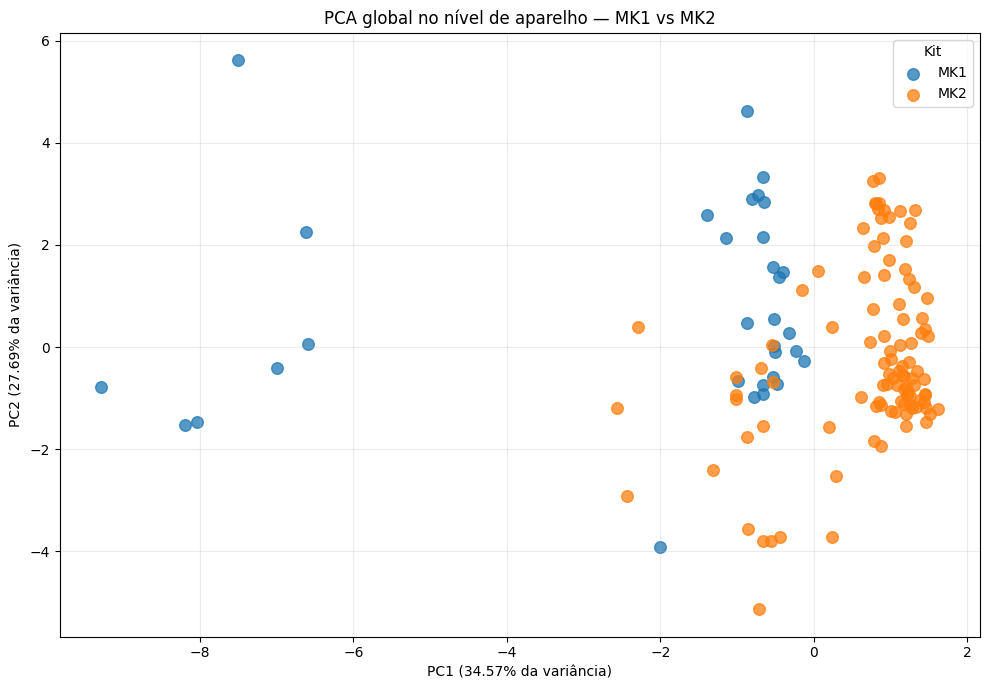

In [182]:
import matplotlib.pyplot as plt

# ============================================================
# 7. PCA global — coloração por kit
# ============================================================

plt.figure(figsize=(10, 7))

for kit in sorted(df_appliance["kit"].unique()):

    mask = df_appliance["kit"].values == kit

    plt.scatter(
        X_pca_app[mask, 0],
        X_pca_app[mask, 1],
        label=kit,
        alpha=0.75,
        s=70
    )

plt.xlabel(f"PC1 ({explained[0]:.2f}% da variância)")
plt.ylabel(f"PC2 ({explained[1]:.2f}% da variância)")
plt.title("PCA global no nível de aparelho — MK1 vs MK2")
plt.legend(title="Kit")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

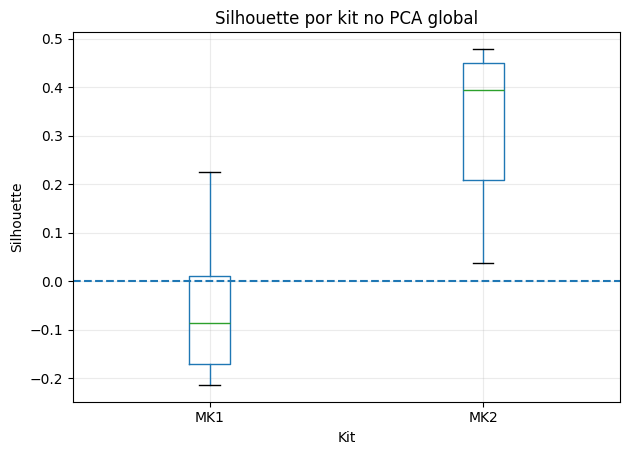

In [183]:
# ============================================================
# 8. Distribuição do Silhouette por kit
# ============================================================

plt.figure(figsize=(8, 6))

df_sil_kit.boxplot(
    column="silhouette",
    by="kit"
)

plt.axhline(0, linestyle="--")

plt.title("Silhouette por kit no PCA global")
plt.suptitle("")
plt.xlabel("Kit")
plt.ylabel("Silhouette")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [184]:
# ============================================================
# 9. Tabela-resumo para publicação
# ============================================================

result_kit = pd.DataFrame({
    "Métrica": [
        "Número de aparelhos",
        "Silhouette médio",
        "Silhouette mediano",
        "Desvio-padrão",
        "Aparelhos com Silhouette < 0",
        "Aparelhos com Silhouette ≥ 0"
    ],
    "Resultado": [
        len(df_appliance),
        f"{silhouette_kit_global:.4f}",
        f"{np.median(sil_samples_kit):.4f}",
        f"{np.std(sil_samples_kit, ddof=1):.4f}",
        f"{(sil_samples_kit < 0).sum()} ({(sil_samples_kit < 0).mean()*100:.2f}%)",
        f"{(sil_samples_kit >= 0).sum()} ({(sil_samples_kit >= 0).mean()*100:.2f}%)"
    ]
})

display(result_kit)

print("\nDistribuição por kit:")
display(summary_kit.round(4))

,Métrica,Resultado
0,Número de aparelhos,134
1,Silhouette médio,0.2458
2,Silhouette mediano,0.2660
3,Desvio-padrão,0.2114
4,Aparelhos com Silhouette < 0,23 (17.16%)
5,Aparelhos com Silhouette ≥ 0,111 (82.84%)



Distribuição por kit:


,n,mean,median,std,min,max,pct_negative
kit,,,,,,,
MK1,32,-0.0471,-0.0866,0.1443,-0.2137,0.2253,71.875
MK2,102,0.3377,0.3951,0.1294,0.0375,0.4791,0.000


In [185]:
# ============================================================
# ANÁLISE DE SENSIBILIDADE AO KIT
# Regiões compartilhadas entre MK1 e MK2
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

feature_cols = [f"feature_{i+1}" for i in range(12)]

# Regiões presentes nos dois kits
shared_regions = ["r1", "r2", "r3"]

df_shared = df_analysis[
    df_analysis["region"].isin(shared_regions)
].copy()

print("Observações:", len(df_shared))
print("Aparelhos:", df_shared["appliance"].nunique())

print("\nRegião × Kit:")
display(
    pd.crosstab(
        df_shared["region"],
        df_shared["kit"]
    )
)

Observações: 729
Aparelhos: 73

Região × Kit:


kit,MK1,MK2
region,,
r1,80,180
r2,60,120
r3,10,279


In [186]:
# ============================================================
# Agregação por aparelho
# ============================================================

df_shared_app = (
    df_shared
    .groupby("appliance", as_index=False)
    .agg({
        **{f: "median" for f in feature_cols},
        "region": "first",
        "kit": "first"
    })
)

print("Número de aparelhos:", len(df_shared_app))

print("\nAparelhos por região:")
display(
    df_shared_app["region"].value_counts().sort_index()
)

print("\nAparelhos por região × kit:")
display(
    pd.crosstab(
        df_shared_app["region"],
        df_shared_app["kit"]
    )
)

Número de aparelhos: 73

Aparelhos por região:


,count
region,
r1,26
r2,18
r3,29



Aparelhos por região × kit:


kit,MK1,MK2
region,,
r1,8,18
r2,6,12
r3,1,28


In [187]:
# ============================================================
# ANÁLISE 1
# Região: r1, r2, r3
# Kit: somente MK1
# Unidade: aparelho
# ============================================================

df_mk1_shared = df_shared_app[
    df_shared_app["kit"] == "MK1"
].copy()

X_mk1_shared = df_mk1_shared[feature_cols].values
y_mk1_shared = df_mk1_shared["region"].values

scaler_mk1_shared = StandardScaler()
X_mk1_shared_scaled = scaler_mk1_shared.fit_transform(
    X_mk1_shared
)

print("Aparelhos MK1:", len(df_mk1_shared))
print("\nRegiões:")
print(df_mk1_shared["region"].value_counts().sort_index())

Aparelhos MK1: 15

Regiões:
region
r1    8
r2    6
r3    1
Name: count, dtype: int64


In [188]:
# ============================================================
# Silhouette MK1 — região
# ============================================================

sil_mk1_region = silhouette_score(
    X_mk1_shared_scaled,
    y_mk1_shared,
    metric="euclidean"
)

samples_mk1_region = silhouette_samples(
    X_mk1_shared_scaled,
    y_mk1_shared,
    metric="euclidean"
)

print("=" * 60)
print("SILHOUETTE REGIONAL — SOMENTE MK1")
print("=" * 60)

print(f"Silhouette médio: {sil_mk1_region:.6f}")
print(
    f"Silhouette < 0: "
    f"{(samples_mk1_region < 0).mean()*100:.2f}%"
)

SILHOUETTE REGIONAL — SOMENTE MK1
Silhouette médio: 0.135726
Silhouette < 0: 33.33%


In [189]:
df_sil_mk1 = df_mk1_shared[
    ["appliance", "region", "kit"]
].copy()

df_sil_mk1["silhouette"] = samples_mk1_region

summary_mk1_region = (
    df_sil_mk1
    .groupby("region")["silhouette"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

display(summary_mk1_region.round(4))

,n,mean,median,std,min,max
region,,,,,,
r1,8,0.0080,0.0470,0.1908,-0.2262,0.2324
r2,6,0.3286,0.3994,0.1992,-0.0713,0.4496
r3,1,0.0000,0.0000,NaN,0.0000,0.0000


In [190]:
# ============================================================
# ANÁLISE 2
# Região: r1, r2, r3
# Kit: somente MK2
# Unidade: aparelho
# ============================================================

df_mk2_shared = df_shared_app[
    df_shared_app["kit"] == "MK2"
].copy()

X_mk2_shared = df_mk2_shared[feature_cols].values
y_mk2_shared = df_mk2_shared["region"].values

scaler_mk2_shared = StandardScaler()
X_mk2_shared_scaled = scaler_mk2_shared.fit_transform(
    X_mk2_shared
)

sil_mk2_region = silhouette_score(
    X_mk2_shared_scaled,
    y_mk2_shared,
    metric="euclidean"
)

samples_mk2_region = silhouette_samples(
    X_mk2_shared_scaled,
    y_mk2_shared,
    metric="euclidean"
)

print("=" * 60)
print("SILHOUETTE REGIONAL — SOMENTE MK2")
print("=" * 60)

print(f"Silhouette médio: {sil_mk2_region:.6f}")
print(
    f"Silhouette < 0: "
    f"{(samples_mk2_region < 0).mean()*100:.2f}%"
)

SILHOUETTE REGIONAL — SOMENTE MK2
Silhouette médio: 0.100139
Silhouette < 0: 22.41%


In [191]:
df_sil_mk2 = df_mk2_shared[
    ["appliance", "region", "kit"]
].copy()

df_sil_mk2["silhouette"] = samples_mk2_region

summary_mk2_region = (
    df_sil_mk2
    .groupby("region")["silhouette"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

display(summary_mk2_region.round(4))

,n,mean,median,std,min,max
region,,,,,,
r1,18,0.0343,0.0546,0.0943,-0.2548,0.1240
r2,12,0.1320,0.2545,0.2112,-0.2086,0.3279
r3,28,0.1288,0.1587,0.1273,-0.1933,0.2818


In [192]:
# ============================================================
# Comparação dos Silhouettes regionais
# ============================================================

comparison_shared_kit = pd.DataFrame({
    "Cenário": [
        "r1+r2+r3 — MK1",
        "r1+r2+r3 — MK2"
    ],
    "Aparelhos": [
        len(df_mk1_shared),
        len(df_mk2_shared)
    ],
    "Regiões": [
        df_mk1_shared["region"].nunique(),
        df_mk2_shared["region"].nunique()
    ],
    "Silhouette": [
        sil_mk1_region,
        sil_mk2_region
    ],
    "% Silhouette < 0": [
        (samples_mk1_region < 0).mean() * 100,
        (samples_mk2_region < 0).mean() * 100
    ]
})

display(comparison_shared_kit.round(4))

,Cenário,Aparelhos,Regiões,Silhouette,% Silhouette < 0
0,r1+r2+r3 — MK1,15,3,0.1357,33.3333
1,r1+r2+r3 — MK2,58,3,0.1001,22.4138


In [193]:
# ============================================================
# PCA MK1 — r1, r2, r3
# ============================================================

pca_mk1_shared = PCA()

X_pca_mk1_shared = pca_mk1_shared.fit_transform(
    X_mk1_shared_scaled
)

var_mk1 = (
    pca_mk1_shared
    .explained_variance_ratio_ * 100
)

print(
    f"MK1 — PC1: {var_mk1[0]:.3f}% | "
    f"PC2: {var_mk1[1]:.3f}% | "
    f"PC1+PC2: {var_mk1[:2].sum():.3f}%"
)

MK1 — PC1: 42.445% | PC2: 19.359% | PC1+PC2: 61.803%


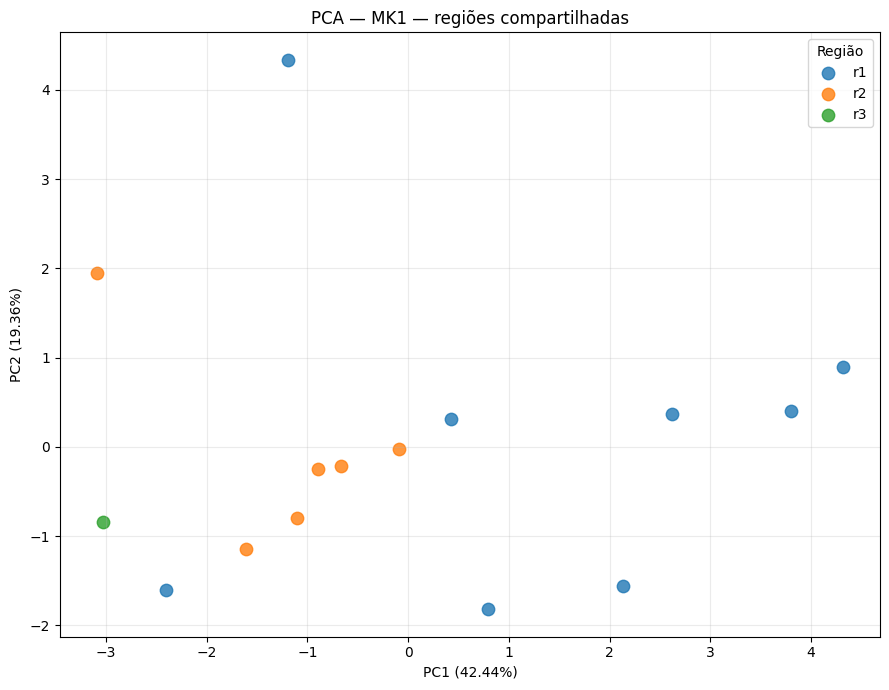

In [194]:
plt.figure(figsize=(9, 7))

for region in sorted(
    df_mk1_shared["region"].unique()
):

    mask = df_mk1_shared["region"].values == region

    plt.scatter(
        X_pca_mk1_shared[mask, 0],
        X_pca_mk1_shared[mask, 1],
        label=region,
        s=80,
        alpha=0.8
    )

plt.xlabel(
    f"PC1 ({var_mk1[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({var_mk1[1]:.2f}%)"
)

plt.title(
    "PCA — MK1 — regiões compartilhadas"
)

plt.legend(title="Região")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [195]:
# ============================================================
# PCA MK2 — r1, r2, r3
# ============================================================

pca_mk2_shared = PCA()

X_pca_mk2_shared = pca_mk2_shared.fit_transform(
    X_mk2_shared_scaled
)

var_mk2 = (
    pca_mk2_shared
    .explained_variance_ratio_ * 100
)

print(
    f"MK2 — PC1: {var_mk2[0]:.3f}% | "
    f"PC2: {var_mk2[1]:.3f}% | "
    f"PC1+PC2: {var_mk2[:2].sum():.3f}%"
)

MK2 — PC1: 32.707% | PC2: 23.969% | PC1+PC2: 56.675%


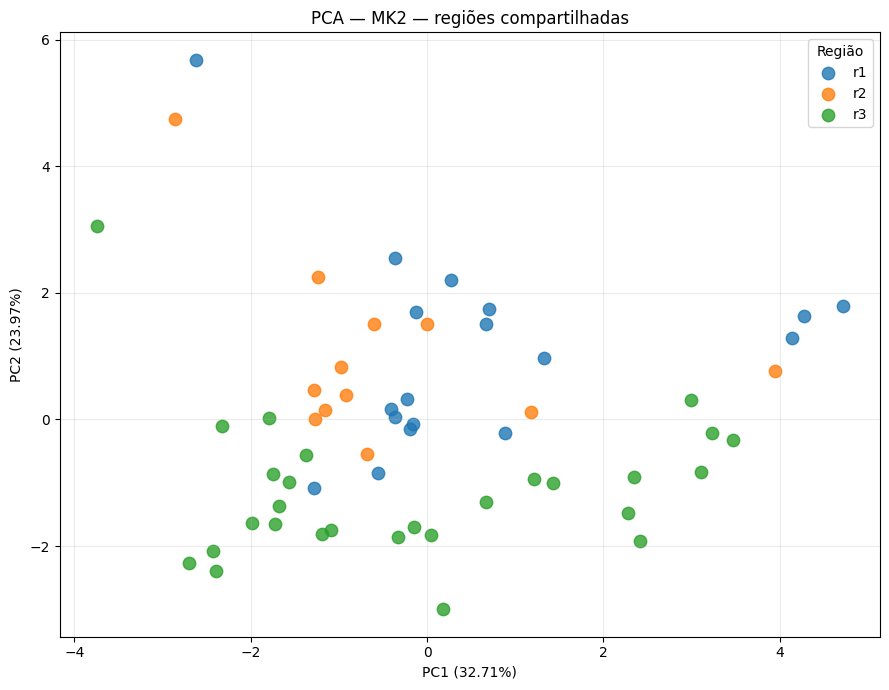

In [196]:
plt.figure(figsize=(9, 7))

for region in sorted(
    df_mk2_shared["region"].unique()
):

    mask = df_mk2_shared["region"].values == region

    plt.scatter(
        X_pca_mk2_shared[mask, 0],
        X_pca_mk2_shared[mask, 1],
        label=region,
        s=80,
        alpha=0.8
    )

plt.xlabel(
    f"PC1 ({var_mk2[0]:.2f}%)"
)

plt.ylabel(
    f"PC2 ({var_mk2[1]:.2f}%)"
)

plt.title(
    "PCA — MK2 — regiões compartilhadas"
)

plt.legend(title="Região")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [197]:
# ============================================================
# Quadro geral de sensibilidade
# ============================================================

sensitivity_table = pd.DataFrame({
    "Análise": [
        "Região — global",
        "Kit — global",
        "Região — MK1, r1+r2+r3",
        "Região — MK2, r1+r2+r3"
    ],
    "Unidade": [
        "Aparelho",
        "Aparelho",
        "Aparelho",
        "Aparelho"
    ],
    "N": [
        134,
        134,
        len(df_mk1_shared),
        len(df_mk2_shared)
    ],
    "Silhouette": [
        -0.0681,
        0.2458,
        sil_mk1_region,
        sil_mk2_region
    ]
})

display(sensitivity_table.round(4))

,Análise,Unidade,N,Silhouette
0,Região — global,Aparelho,134,-0.0681
1,Kit — global,Aparelho,134,0.2458
2,"Região — MK1, r1+r2+r3",Aparelho,15,0.1357
3,"Região — MK2, r1+r2+r3",Aparelho,58,0.1001


In [198]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score
)

df_model_control = df_analysis.copy()

X_features = df_model_control[feature_cols].values

# Kit como variável binária
X_kit = (
    df_model_control["kit"]
    .map({"MK1": 0, "MK2": 1})
    .values
    .reshape(-1, 1)
)

y_region = df_model_control["region"].values
groups = df_model_control["appliance"].values

print("N:", len(df_model_control))
print("Aparelhos:", df_model_control["appliance"].nunique())
print("Regiões:", df_model_control["region"].nunique())

N: 1339
Aparelhos: 134
Regiões: 9


In [199]:
def evaluate_rf_model(
    X,
    y,
    groups,
    model_name,
    n_splits=5,
    random_state=42
):

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        model = RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )

        model.fit(
            X[train_idx],
            y[train_idx]
        )

        y_pred = model.predict(
            X[test_idx]
        )

        acc = accuracy_score(
            y[test_idx],
            y_pred
        )

        bal = balanced_accuracy_score(
            y[test_idx],
            y_pred
        )

        macro = f1_score(
            y[test_idx],
            y_pred,
            average="macro"
        )

        weighted = f1_score(
            y[test_idx],
            y_pred,
            average="weighted"
        )

        fold_results.append({
            "model": model_name,
            "fold": fold,
            "accuracy": acc,
            "balanced_accuracy": bal,
            "macro_f1": macro,
            "weighted_f1": weighted
        })

        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)

    return (
        pd.DataFrame(fold_results),
        np.array(y_true_all),
        np.array(y_pred_all)
    )

In [200]:
results_features, ytrue_features, ypred_features = (
    evaluate_rf_model(
        X_features,
        y_region,
        groups,
        "Características"
    )
)

display(
    results_features.round(4)
)

,model,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Características,1,0.7296,0.8347,0.7824,0.7255
1,Características,2,0.6036,0.6078,0.5656,0.5848
2,Características,3,0.7038,0.8028,0.7363,0.6995
3,Características,4,0.7645,0.7503,0.6709,0.7712
4,Características,5,0.7222,0.6964,0.6827,0.7051


In [201]:
results_kit, ytrue_kit, ypred_kit = (
    evaluate_rf_model(
        X_kit,
        y_region,
        groups,
        "Kit"
    )
)

display(
    results_kit.round(4)
)

,model,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Kit,1,0.1481,0.2500,0.0738,0.0437
1,Kit,2,0.1071,0.1250,0.0267,0.0257
2,Kit,3,0.1154,0.1852,0.0511,0.0311
3,Kit,4,0.1931,0.2500,0.0898,0.0661
4,Kit,5,0.2593,0.2222,0.1046,0.1109


In [202]:
X_features_kit = np.hstack([
    X_features,
    X_kit
])

results_features_kit, ytrue_features_kit, ypred_features_kit = (
    evaluate_rf_model(
        X_features_kit,
        y_region,
        groups,
        "Características + Kit"
    )
)

display(
    results_features_kit.round(4)
)

,model,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Características + Kit,1,0.7630,0.8417,0.8074,0.7667
1,Características + Kit,2,0.7000,0.6755,0.5946,0.7078
2,Características + Kit,3,0.7538,0.8522,0.8129,0.7562
3,Características + Kit,4,0.7876,0.7878,0.7080,0.7977
4,Características + Kit,5,0.7630,0.7533,0.7501,0.7567


In [203]:
# ============================================================
# Comparação dos três modelos
# ============================================================

comparison_models = (
    pd.concat([
        results_features,
        results_kit,
        results_features_kit
    ])
    .groupby("model")
    [
        [
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1"
        ]
    ]
    .agg(["mean", "std"])
)

display(
    comparison_models.round(4)
)

accuracy         balanced_accuracy         macro_f1  \
                          mean     std              mean     std     mean   
model                                                                       
Características         0.7047  0.0607            0.7384  0.0900   0.6876   
Características + Kit   0.7535  0.0324            0.7821  0.0719   0.7346   
Kit                     0.1646  0.0628            0.2065  0.0527   0.0692   

                              weighted_f1          
                          std        mean     std  
model                                              
Características        0.0815      0.6972  0.0689  
Características + Kit  0.0894      0.7570  0.0323  
Kit                    0.0310      0.0555  0.0347

Experimento para a versão 02 do Artigo
* manter E1–E3 já existentes;
* corrigir/fortalecer a auditoria da agregação por aparelho;
* acrescentar E4d–E4f para r1/r2/r3;
* acrescentar auditoria detalhada dos folds;
* gerar uma tabela única E1–E4;
* gerar as matrizes de confusão dos novos RF;
* comparar Features × Kit × Features+Kit global e r1/r2/r3;





In [204]:
# ============================================================
# V2 — CÉLULA 1
# Imports, configuração e reprodutibilidade
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

SEED = 42

np.random.seed(SEED)

print("V2 inicializada")
print("Seed:", SEED)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

V2 inicializada
Seed: 42
Pandas: 2.2.3
NumPy: 2.1.3


In [205]:
# ============================================================
# V2 — CÉLULA 2
# Auditoria do dataframe de análise
# ============================================================

print("Shape:", df_analysis.shape)

print("\nColunas:")
print(df_analysis.columns.tolist())

print("\nRegiões:")
print(df_analysis["region"].value_counts(dropna=False).sort_index())

print("\nKits:")
print(df_analysis["kit"].value_counts(dropna=False))

print("\nAparelhos distintos:")
print(df_analysis["appliance"].nunique())

print("\nNaN nas features:")
print(df_analysis[feature_cols].isna().sum().sum())

print("\nInf nas features:")
print(np.isinf(df_analysis[feature_cols].to_numpy()).sum())

Shape: (1339, 20)

Colunas:
['feature_1', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9', 'feature_10', 'feature_11', 'feature_12', 'filename', 'filepath', 'appliance', 'region', 'kit', 'timestamp', 'timestamp_dt', 'appliance_type']

Regiões:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64

Kits:
kit
MK2    1019
MK1     320
Name: count, dtype: int64

Aparelhos distintos:
134

NaN nas features:
0

Inf nas features:
0


In [206]:
# ============================================================
# V2 — CÉLULA 3
# Auditoria aparelho × região × kit
# ============================================================

audit_appliance = (
    df_analysis
    .groupby("appliance")
    .agg(
        n_region=("region", "nunique"),
        n_kit=("kit", "nunique"),
        n_obs=("appliance", "size")
    )
)

print("Aparelhos com mais de uma região:")
display(
    audit_appliance[audit_appliance["n_region"] > 1]
)

print("\nAparelhos com mais de um kit:")
display(
    audit_appliance[audit_appliance["n_kit"] > 1]
)

print("\nResumo:")
print(audit_appliance["n_obs"].describe())

print("\nTotal de aparelhos:", len(audit_appliance))

Aparelhos com mais de uma região:


,n_region,n_kit,n_obs
appliance,,,



Aparelhos com mais de um kit:


,n_region,n_kit,n_obs
appliance,,,



Resumo:
count    134.000000
mean       9.992537
std        0.086387
min        9.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       10.000000
Name: n_obs, dtype: float64

Total de aparelhos: 134


In [207]:
# ============================================================
# V2 — CÉLULA 3
# Auditoria aparelho × região × kit
# ============================================================

audit_appliance = (
    df_analysis
    .groupby("appliance")
    .agg(
        n_region=("region", "nunique"),
        n_kit=("kit", "nunique"),
        n_obs=("appliance", "size")
    )
)

print("Aparelhos com mais de uma região:")
display(
    audit_appliance[audit_appliance["n_region"] > 1]
)

print("\nAparelhos com mais de um kit:")
display(
    audit_appliance[audit_appliance["n_kit"] > 1]
)

print("\nResumo:")
print(audit_appliance["n_obs"].describe())

print("\nTotal de aparelhos:", len(audit_appliance))

Aparelhos com mais de uma região:


,n_region,n_kit,n_obs
appliance,,,



Aparelhos com mais de um kit:


,n_region,n_kit,n_obs
appliance,,,



Resumo:
count    134.000000
mean       9.992537
std        0.086387
min        9.000000
25%       10.000000
50%       10.000000
75%       10.000000
max       10.000000
Name: n_obs, dtype: float64

Total de aparelhos: 134


In [208]:
# ============================================================
# V2 — CÉLULA 5
# E1 — r1/r2/r3 — MK1
# ============================================================

shared_regions = ["r1", "r2", "r3"]

df_r123_mk1 = df_appliance[
    df_appliance["region"].isin(shared_regions) &
    (df_appliance["kit"] == "MK1")
].copy()

print("Observações/aparelhos:", len(df_r123_mk1))
print("\nRegião:")
print(df_r123_mk1["region"].value_counts().sort_index())

X = df_r123_mk1[feature_cols].values
y = df_r123_mk1["region"].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

sil = silhouette_score(X_std, y)

print("\nSilhouette — r1/r2/r3 — MK1:")
print(f"{sil:.6f}")

sil_samples = silhouette_samples(X_std, y)

df_r123_mk1["silhouette"] = sil_samples

print("\nPercentual Silhouette < 0:")
print(f"{(sil_samples < 0).mean()*100:.2f}%")

Observações/aparelhos: 15

Região:
region
r1    8
r2    6
r3    1
Name: count, dtype: int64

Silhouette — r1/r2/r3 — MK1:
0.135726

Percentual Silhouette < 0:
33.33%


In [209]:
# ============================================================
# V2 — CÉLULA 6
# Silhouette por região — MK1
# ============================================================

summary_mk1 = (
    df_r123_mk1
    .groupby("region")["silhouette"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

display(summary_mk1)

,n,mean,median,std,min,max
region,,,,,,
r1,8,0.008043,0.047035,0.190784,-0.226173,0.232388
r2,6,0.328591,0.399415,0.199178,-0.071282,0.449594
r3,1,0.000000,0.000000,NaN,0.000000,0.000000


Variância explicada:
PC1: 42.445%
PC2: 19.359%
PC3: 13.655%
PC4: 11.667%
PC5: 7.035%
PC6: 4.699%
PC7: 0.925%
PC8: 0.154%
PC9: 0.059%
PC10: 0.003%
PC11: 0.000%
PC12: 0.000%

PC1 + PC2: 61.803%


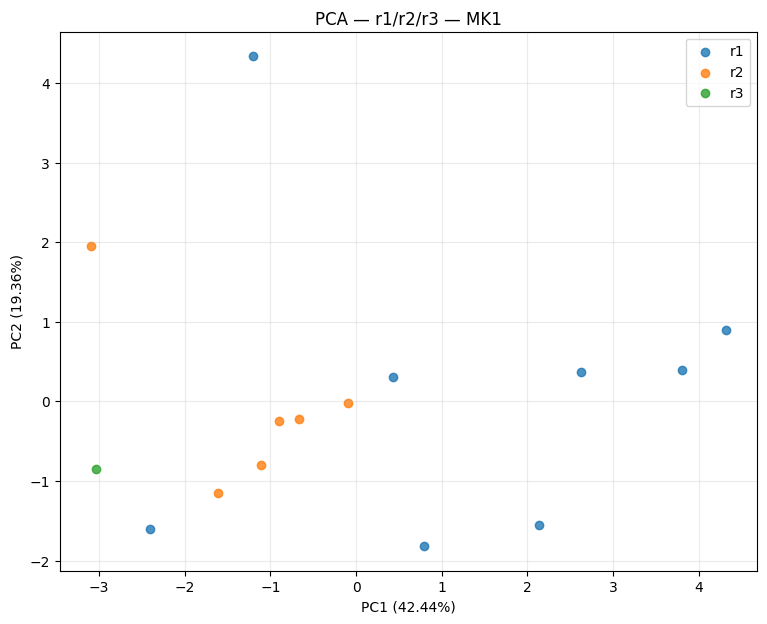

In [210]:
# ============================================================
# V2 — CÉLULA 7
# PCA — r1/r2/r3 — MK1
# ============================================================

pca_mk1 = PCA(n_components=min(12, X_std.shape[0]))
X_pca_mk1 = pca_mk1.fit_transform(X_std)

explained_mk1 = pca_mk1.explained_variance_ratio_

print("Variância explicada:")
for i, v in enumerate(explained_mk1, start=1):
    print(f"PC{i}: {v*100:.3f}%")

print(
    "\nPC1 + PC2:",
    f"{explained_mk1[:2].sum()*100:.3f}%"
)

plt.figure(figsize=(9, 7))

for region in sorted(df_r123_mk1["region"].unique()):
    mask = df_r123_mk1["region"].values == region

    plt.scatter(
        X_pca_mk1[mask, 0],
        X_pca_mk1[mask, 1],
        label=region,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({explained_mk1[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained_mk1[1]*100:.2f}%)")
plt.title("PCA — r1/r2/r3 — MK1")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [211]:
# ============================================================
# V2 — CÉLULA 8
# E2 — r1/r2/r3 — MK2
# ============================================================

df_r123_mk2 = df_appliance[
    df_appliance["region"].isin(shared_regions) &
    (df_appliance["kit"] == "MK2")
].copy()

print("Observações/aparelhos:", len(df_r123_mk2))

print("\nRegião:")
print(df_r123_mk2["region"].value_counts().sort_index())

X = df_r123_mk2[feature_cols].values
y = df_r123_mk2["region"].values

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

sil = silhouette_score(X_std, y)

print("\nSilhouette — r1/r2/r3 — MK2:")
print(f"{sil:.6f}")

sil_samples = silhouette_samples(X_std, y)

df_r123_mk2["silhouette"] = sil_samples

print("\nPercentual Silhouette < 0:")
print(f"{(sil_samples < 0).mean()*100:.2f}%")

Observações/aparelhos: 58

Região:
region
r1    18
r2    12
r3    28
Name: count, dtype: int64

Silhouette — r1/r2/r3 — MK2:
0.100139

Percentual Silhouette < 0:
22.41%


In [212]:
# ============================================================
# V2 — CÉLULA 9
# Silhouette por região — MK2
# ============================================================

summary_mk2 = (
    df_r123_mk2
    .groupby("region")["silhouette"]
    .agg(
        n="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
)

display(summary_mk2)

,n,mean,median,std,min,max
region,,,,,,
r1,18,0.034268,0.054586,0.094301,-0.254780,0.123990
r2,12,0.132005,0.254541,0.211170,-0.208622,0.327854
r3,28,0.128827,0.158726,0.127272,-0.193282,0.281815


Variância explicada:
PC1: 32.707%
PC2: 23.969%
PC3: 16.798%
PC4: 12.345%
PC5: 5.615%
PC6: 4.082%
PC7: 2.587%
PC8: 1.551%
PC9: 0.344%
PC10: 0.002%
PC11: 0.000%
PC12: 0.000%

PC1 + PC2: 56.675%


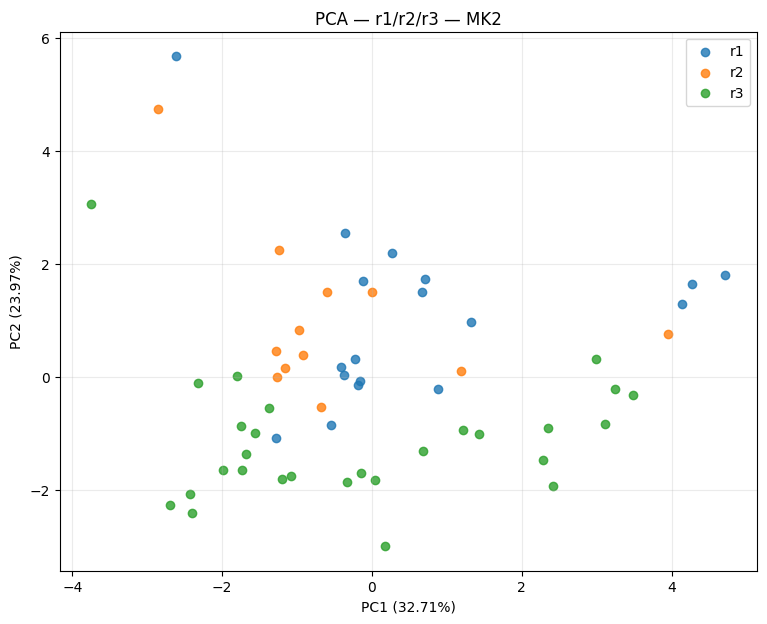

In [213]:
# ============================================================
# V2 — CÉLULA 10
# PCA — r1/r2/r3 — MK2
# ============================================================

pca_mk2 = PCA(n_components=min(12, X_std.shape[0]))
X_pca_mk2 = pca_mk2.fit_transform(X_std)

explained_mk2 = pca_mk2.explained_variance_ratio_

print("Variância explicada:")
for i, v in enumerate(explained_mk2, start=1):
    print(f"PC{i}: {v*100:.3f}%")

print(
    "\nPC1 + PC2:",
    f"{explained_mk2[:2].sum()*100:.3f}%"
)

plt.figure(figsize=(9, 7))

for region in sorted(df_r123_mk2["region"].unique()):
    mask = df_r123_mk2["region"].values == region

    plt.scatter(
        X_pca_mk2[mask, 0],
        X_pca_mk2[mask, 1],
        label=region,
        alpha=0.8
    )

plt.xlabel(f"PC1 ({explained_mk2[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({explained_mk2[1]*100:.2f}%)")
plt.title("PCA — r1/r2/r3 — MK2")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [214]:
# ============================================================
# V2 — CÉLULA 11
# Comparação dos experimentos E1/E2
# ============================================================

silhouette_comparison = pd.DataFrame({
    "Cenário": [
        "Região — global",
        "Kit — global",
        "Região — r1/r2/r3 — MK1",
        "Região — r1/r2/r3 — MK2"
    ],
    "Unidade": [
        "Aparelho",
        "Aparelho",
        "Aparelho",
        "Aparelho"
    ],
    "N": [
        len(df_appliance),
        len(df_appliance),
        len(df_r123_mk1),
        len(df_r123_mk2)
    ],
    "Silhouette": [
        silhouette_score(
            StandardScaler().fit_transform(
                df_appliance[feature_cols]
            ),
            df_appliance["region"]
        ),
        silhouette_score(
            StandardScaler().fit_transform(
                df_appliance[feature_cols]
            ),
            df_appliance["kit"]
        ),
        silhouette_score(
            StandardScaler().fit_transform(
                df_r123_mk1[feature_cols]
            ),
            df_r123_mk1["region"]
        ),
        silhouette_score(
            StandardScaler().fit_transform(
                df_r123_mk2[feature_cols]
            ),
            df_r123_mk2["region"]
        )
    ]
})

display(silhouette_comparison)

,Cenário,Unidade,N,Silhouette
0,Região — global,Aparelho,134,-0.068097
1,Kit — global,Aparelho,134,0.245778
2,Região — r1/r2/r3 — MK1,Aparelho,15,0.135726
3,Região — r1/r2/r3 — MK2,Aparelho,58,0.100139


KIT: MK1
Aparelhos: 32
Regiões: 6
Silhouette: -0.061649
% Silhouette < 0: 56.25%

Variância PCA:
PC1: 42.888%
PC2: 26.700%
PC3: 14.919%
PC4: 6.890%
PC5: 3.886%


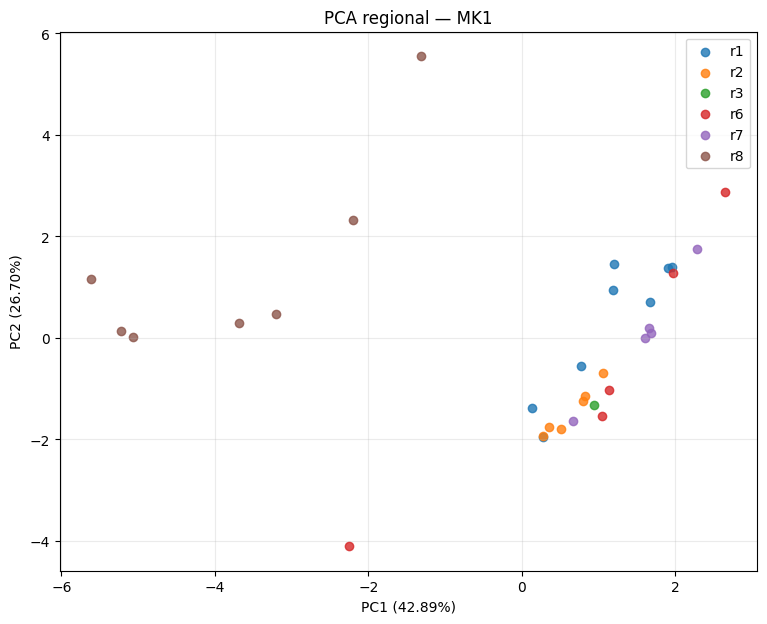

KIT: MK2
Aparelhos: 102
Regiões: 6
Silhouette: -0.011953
% Silhouette < 0: 52.94%

Variância PCA:
PC1: 31.841%
PC2: 24.591%
PC3: 15.083%
PC4: 10.954%
PC5: 7.481%


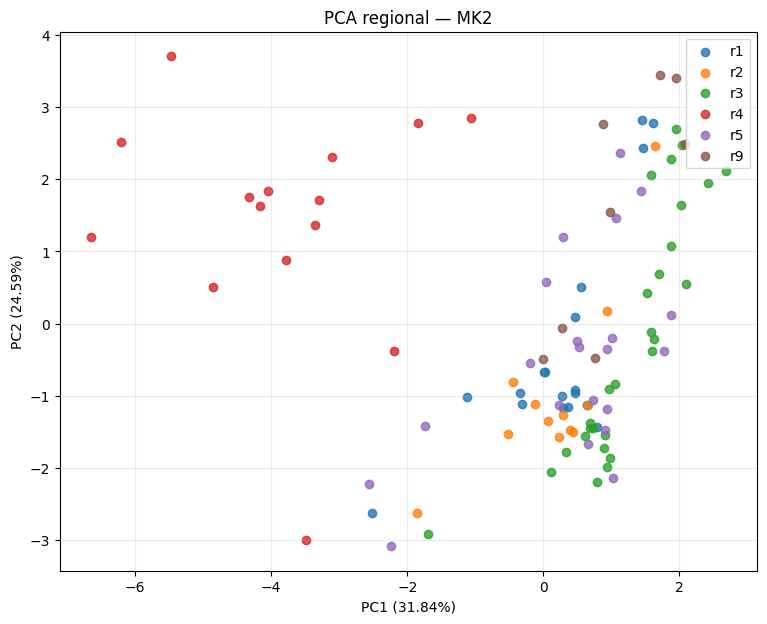

In [215]:
# ============================================================
# V2 — CÉLULA 12
# PCA + Silhouette por kit
# ============================================================

def pca_silhouette_by_kit(df, kit_name):

    data = df[df["kit"] == kit_name].copy()

    X = data[feature_cols].values
    y = data["region"].values

    scaler = StandardScaler()
    X_std = scaler.fit_transform(X)

    pca = PCA(n_components=min(12, X_std.shape[0]))
    X_pca = pca.fit_transform(X_std)

    sil = silhouette_score(X_std, y)
    sil_values = silhouette_samples(X_std, y)

    data["silhouette"] = sil_values

    print("=" * 60)
    print(f"KIT: {kit_name}")
    print("=" * 60)
    print("Aparelhos:", len(data))
    print("Regiões:", data["region"].nunique())
    print("Silhouette:", f"{sil:.6f}")
    print(
        "% Silhouette < 0:",
        f"{(sil_values < 0).mean()*100:.2f}%"
    )

    print("\nVariância PCA:")
    for i, v in enumerate(
        pca.explained_variance_ratio_[:5], start=1
    ):
        print(f"PC{i}: {v*100:.3f}%")

    plt.figure(figsize=(9, 7))

    for region in sorted(data["region"].unique()):
        mask = data["region"].values == region

        plt.scatter(
            X_pca[mask, 0],
            X_pca[mask, 1],
            label=region,
            alpha=0.8
        )

    plt.xlabel(
        f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)"
    )
    plt.ylabel(
        f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)"
    )
    plt.title(f"PCA regional — {kit_name}")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

    return data, pca, X_pca, sil


df_mk1_all, pca_mk1_all, Xpca_mk1_all, sil_mk1_all = \
    pca_silhouette_by_kit(df_appliance, "MK1")

df_mk2_all, pca_mk2_all, Xpca_mk2_all, sil_mk2_all = \
    pca_silhouette_by_kit(df_appliance, "MK2")

In [216]:
# ============================================================
# V2 — CÉLULA 13
# Preparação da validação agrupada por aparelho
# ============================================================

X_features = df_analysis[feature_cols].copy()

X_kit = pd.get_dummies(
    df_analysis["kit"],
    prefix="kit",
    dtype=float
)

# Garantir duas colunas mesmo que alguma esteja ausente
for col in ["kit_MK1", "kit_MK2"]:
    if col not in X_kit.columns:
        X_kit[col] = 0.0

X_kit = X_kit[["kit_MK1", "kit_MK2"]]

X_features_kit = pd.concat(
    [X_features.reset_index(drop=True),
     X_kit.reset_index(drop=True)],
    axis=1
)

y_region = df_analysis["region"].astype(str).values
groups = df_analysis["appliance"].astype(str).values

print("X features:", X_features.shape)
print("X kit:", X_kit.shape)
print("X features + kit:", X_features_kit.shape)

print("Regiões:", np.unique(y_region))
print("Grupos/aparelhos:", len(np.unique(groups)))

X features: (1339, 12)
X kit: (1339, 2)
X features + kit: (1339, 14)
Regiões: ['r1' 'r2' 'r3' 'r4' 'r5' 'r6' 'r7' 'r8' 'r9']
Grupos/aparelhos: 134


In [217]:
# ============================================================
# V2 — CÉLULA 14
# Função de avaliação Random Forest
# ============================================================

def evaluate_rf_grouped(
    X,
    y,
    groups,
    experiment_name,
    n_splits=5,
    random_state=42
):

    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    all_y_true = []
    all_y_pred = []

    fold_audit = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X.iloc[train_idx] if isinstance(X, pd.DataFrame) \
            else X[train_idx]

        X_test = X.iloc[test_idx] if isinstance(X, pd.DataFrame) \
            else X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        groups_train = groups[train_idx]
        groups_test = groups[test_idx]

        # ----------------------------------------------------
        # Auditoria de grupos
        # ----------------------------------------------------
        overlap = len(
            set(groups_train).intersection(set(groups_test))
        )

        train_regions = set(y_train)
        test_regions = set(y_test)

        missing_test = sorted(
            train_regions - test_regions
        )

        missing_train = sorted(
            test_regions - train_regions
        )

        # ----------------------------------------------------
        # Modelo
        # ----------------------------------------------------
        rf = RandomForestClassifier(
            n_estimators=500,
            random_state=random_state,
            n_jobs=-1,
            class_weight="balanced"
        )

        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)

        # ----------------------------------------------------
        # Métricas
        # ----------------------------------------------------
        acc = accuracy_score(y_test, y_pred)

        bal_acc = balanced_accuracy_score(
            y_test,
            y_pred
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro"
        )

        weighted_f1 = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )

        fold_results.append({
            "experiment": experiment_name,
            "fold": fold,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1
        })

        fold_audit.append({
            "experiment": experiment_name,
            "fold": fold,
            "train_obs": len(train_idx),
            "test_obs": len(test_idx),
            "train_appliances": len(np.unique(groups_train)),
            "test_appliances": len(np.unique(groups_test)),
            "group_overlap": overlap,
            "train_regions": len(train_regions),
            "test_regions": len(test_regions),
            "missing_in_test": ", ".join(missing_test),
            "missing_in_train": ", ".join(missing_train)
        })

        all_y_true.extend(y_test)
        all_y_pred.extend(y_pred)

    fold_df = pd.DataFrame(fold_results)
    audit_df = pd.DataFrame(fold_audit)

    summary = {
        "experiment": experiment_name,
        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_sd": fold_df["accuracy"].std(),
        "balanced_accuracy_mean": fold_df["balanced_accuracy"].mean(),
        "balanced_accuracy_sd": fold_df["balanced_accuracy"].std(),
        "macro_f1_mean": fold_df["macro_f1"].mean(),
        "macro_f1_sd": fold_df["macro_f1"].std(),
        "weighted_f1_mean": fold_df["weighted_f1"].mean(),
        "weighted_f1_sd": fold_df["weighted_f1"].std()
    }

    return (
        pd.DataFrame([summary]),
        fold_df,
        audit_df,
        np.array(all_y_true),
        np.array(all_y_pred)
    )

In [218]:
# ============================================================
# V2 — CÉLULA 15
# E4a — Features → Região
# ============================================================

rf_features = evaluate_rf_grouped(
    X_features,
    y_region,
    groups,
    experiment_name="Features -> Região"
)

summary_features, folds_features, audit_features, \
ytrue_features, ypred_features = rf_features

display(summary_features)

print("\nResultados por fold:")
display(folds_features)

print("\nAuditoria dos folds:")
display(audit_features)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,Features -> Região,0.70475,0.060683,0.73841,0.089968,0.687571,0.081484,0.697205,0.068887



Resultados por fold:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Features -> Região,1,0.729630,0.834722,0.782442,0.725470
1,Features -> Região,2,0.603571,0.607812,0.565572,0.584751
2,Features -> Região,3,0.703846,0.802751,0.736276,0.699527
3,Features -> Região,4,0.764479,0.750344,0.670899,0.771154
4,Features -> Região,5,0.722222,0.696420,0.682666,0.705124



Auditoria dos folds:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,Features -> Região,1,1069,270,107,27,0,9,8,r6,
1,Features -> Região,2,1059,280,106,28,0,9,8,r6,
2,Features -> Região,3,1079,260,108,26,0,9,9,,
3,Features -> Região,4,1080,259,108,26,0,9,8,r7,
4,Features -> Região,5,1069,270,107,27,0,9,9,,


In [219]:
# ============================================================
# V2 — CÉLULA 16
# E4b — Kit → Região
# ============================================================

rf_kit = evaluate_rf_grouped(
    X_kit,
    y_region,
    groups,
    experiment_name="Kit -> Região"
)

summary_kit, folds_kit, audit_kit, \
ytrue_kit, ypred_kit = rf_kit

display(summary_kit)

print("\nResultados por fold:")
display(folds_kit)

print("\nAuditoria dos folds:")
display(audit_kit)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,Kit -> Região,0.164597,0.062777,0.206481,0.052745,0.069198,0.030983,0.055496,0.03466



Resultados por fold:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Kit -> Região,1,0.148148,0.250000,0.073810,0.043739
1,Kit -> Região,2,0.107143,0.125000,0.026667,0.025714
2,Kit -> Região,3,0.115385,0.185185,0.051070,0.031056
3,Kit -> Região,4,0.193050,0.250000,0.089802,0.066054
4,Kit -> Região,5,0.259259,0.222222,0.104644,0.110915



Auditoria dos folds:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,Kit -> Região,1,1069,270,107,27,0,9,8,r6,
1,Kit -> Região,2,1059,280,106,28,0,9,8,r6,
2,Kit -> Região,3,1079,260,108,26,0,9,9,,
3,Kit -> Região,4,1080,259,108,26,0,9,8,r7,
4,Kit -> Região,5,1069,270,107,27,0,9,9,,


In [220]:
# ============================================================
# V2 — CÉLULA 17
# E4c — Features + Kit → Região
# ============================================================

rf_features_kit = evaluate_rf_grouped(
    X_features_kit,
    y_region,
    groups,
    experiment_name="Features + Kit -> Região"
)

summary_features_kit, folds_features_kit, \
audit_features_kit, ytrue_features_kit, \
ypred_features_kit = rf_features_kit

display(summary_features_kit)

print("\nResultados por fold:")
display(folds_features_kit)

print("\nAuditoria dos folds:")
display(audit_features_kit)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,Features + Kit -> Região,0.756449,0.043555,0.791359,0.070815,0.743564,0.092988,0.757702,0.040355



Resultados por fold:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,Features + Kit -> Região,1,0.733333,0.830556,0.784516,0.735419
1,Features + Kit -> Região,2,0.700000,0.671354,0.595222,0.705949
2,Features + Kit -> Região,3,0.750000,0.852751,0.811660,0.750759
3,Features + Kit -> Região,4,0.791506,0.792011,0.710793,0.800656
4,Features + Kit -> Região,5,0.807407,0.810123,0.815631,0.795728



Auditoria dos folds:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,Features + Kit -> Região,1,1069,270,107,27,0,9,8,r6,
1,Features + Kit -> Região,2,1059,280,106,28,0,9,8,r6,
2,Features + Kit -> Região,3,1079,260,108,26,0,9,9,,
3,Features + Kit -> Região,4,1080,259,108,26,0,9,8,r7,
4,Features + Kit -> Região,5,1069,270,107,27,0,9,9,,


In [221]:
# ============================================================
# V2 — CÉLULA 18
# E4d/e/f — somente r1/r2/r3
# ============================================================

mask_r123 = df_analysis["region"].isin(
    ["r1", "r2", "r3"]
)

df_r123_obs = df_analysis.loc[
    mask_r123
].reset_index(drop=True)

X_r123_features = df_r123_obs[feature_cols].copy()

X_r123_kit = pd.get_dummies(
    df_r123_obs["kit"],
    prefix="kit",
    dtype=float
)

for col in ["kit_MK1", "kit_MK2"]:
    if col not in X_r123_kit.columns:
        X_r123_kit[col] = 0.0

X_r123_kit = X_r123_kit[
    ["kit_MK1", "kit_MK2"]
]

X_r123_features_kit = pd.concat(
    [
        X_r123_features.reset_index(drop=True),
        X_r123_kit.reset_index(drop=True)
    ],
    axis=1
)

y_r123 = df_r123_obs[
    "region"
].astype(str).values

groups_r123 = df_r123_obs[
    "appliance"
].astype(str).values

print("Observações:", len(df_r123_obs))
print("Aparelhos:", len(np.unique(groups_r123)))

print("\nRegiões:")
print(pd.Series(y_r123).value_counts().sort_index())

print("\nKits:")
print(df_r123_obs["kit"].value_counts())

Observações: 729
Aparelhos: 73

Regiões:
r1    260
r2    180
r3    289
Name: count, dtype: int64

Kits:
kit
MK2    579
MK1    150
Name: count, dtype: int64


In [222]:
# ============================================================
# V2 — CÉLULA 19
# E4d — r1/r2/r3 — Features -> Região
# ============================================================

rf_r123_features = evaluate_rf_grouped(
    X_r123_features,
    y_r123,
    groups_r123,
    experiment_name="r1/r2/r3 — Features -> Região"
)

summary_r123_features, folds_r123_features, \
audit_r123_features, ytrue_r123_features, \
ypred_r123_features = rf_r123_features

display(summary_r123_features)

print("\nFold results:")
display(folds_r123_features)

print("\nFold audit:")
display(audit_r123_features)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,r1/r2/r3 — Features -> Região,0.813493,0.130172,0.810603,0.11912,0.802813,0.125105,0.809057,0.135451



Fold results:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,r1/r2/r3 — Features -> Região,1,0.753333,0.728889,0.728686,0.745839
1,r1/r2/r3 — Features -> Região,2,0.978417,0.960000,0.964458,0.978247
2,r1/r2/r3 — Features -> Região,3,0.886667,0.875238,0.868099,0.885035
3,r1/r2/r3 — Features -> Região,4,0.813333,0.830556,0.813141,0.814103
4,r1/r2/r3 — Features -> Região,5,0.635714,0.658333,0.639681,0.622061



Fold audit:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,r1/r2/r3 — Features -> Região,1,579,150,58,15,0,3,3,,
1,r1/r2/r3 — Features -> Região,2,590,139,59,14,0,3,3,,
2,r1/r2/r3 — Features -> Região,3,579,150,58,15,0,3,3,,
3,r1/r2/r3 — Features -> Região,4,579,150,58,15,0,3,3,,
4,r1/r2/r3 — Features -> Região,5,589,140,59,14,0,3,3,,


In [223]:
# ============================================================
# V2 — CÉLULA 20
# E4e — r1/r2/r3 — Kit -> Região
# ============================================================

rf_r123_kit = evaluate_rf_grouped(
    X_r123_kit,
    y_r123,
    groups_r123,
    experiment_name="r1/r2/r3 — Kit -> Região"
)

summary_r123_kit, folds_r123_kit, \
audit_r123_kit, ytrue_r123_kit, \
ypred_r123_kit = rf_r123_kit

display(summary_r123_kit)

print("\nFold results:")
display(folds_r123_kit)

print("\nFold audit:")
display(audit_r123_kit)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,r1/r2/r3 — Kit -> Região,0.424042,0.073439,0.357778,0.038809,0.256613,0.029293,0.306644,0.056982



Fold results:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,r1/r2/r3 — Kit -> Região,1,0.466667,0.400000,0.305556,0.350000
1,r1/r2/r3 — Kit -> Região,2,0.496403,0.333333,0.244681,0.364381
2,r1/r2/r3 — Kit -> Região,3,0.466667,0.333333,0.233333,0.326667
3,r1/r2/r3 — Kit -> Região,4,0.333333,0.322222,0.238384,0.250505
4,r1/r2/r3 — Kit -> Região,5,0.357143,0.400000,0.261111,0.241667



Fold audit:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,r1/r2/r3 — Kit -> Região,1,579,150,58,15,0,3,3,,
1,r1/r2/r3 — Kit -> Região,2,590,139,59,14,0,3,3,,
2,r1/r2/r3 — Kit -> Região,3,579,150,58,15,0,3,3,,
3,r1/r2/r3 — Kit -> Região,4,579,150,58,15,0,3,3,,
4,r1/r2/r3 — Kit -> Região,5,589,140,59,14,0,3,3,,


In [224]:
# ============================================================
# V2 — CÉLULA 21
# E4f — r1/r2/r3 — Features + Kit -> Região
# ============================================================

rf_r123_features_kit = evaluate_rf_grouped(
    X_r123_features_kit,
    y_r123,
    groups_r123,
    experiment_name="r1/r2/r3 — Features + Kit -> Região"
)

summary_r123_features_kit, folds_r123_features_kit, \
audit_r123_features_kit, ytrue_r123_features_kit, \
ypred_r123_features_kit = rf_r123_features_kit

display(summary_r123_features_kit)

print("\nFold results:")
display(folds_r123_features_kit)

print("\nFold audit:")
display(audit_r123_features_kit)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,r1/r2/r3 — Features + Kit -> Região,0.816265,0.132735,0.817429,0.125289,0.810401,0.124949,0.813971,0.134837



Fold results:


,experiment,fold,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,r1/r2/r3 — Features + Kit -> Região,1,0.760000,0.737222,0.737885,0.754605
1,r1/r2/r3 — Features + Kit -> Região,2,0.985612,0.976667,0.976667,0.985612
2,r1/r2/r3 — Features + Kit -> Região,3,0.893333,0.892698,0.878484,0.891565
3,r1/r2/r3 — Features + Kit -> Região,4,0.806667,0.822222,0.806349,0.807619
4,r1/r2/r3 — Features + Kit -> Região,5,0.635714,0.658333,0.652622,0.630455



Fold audit:


,experiment,fold,train_obs,test_obs,train_appliances,test_appliances,group_overlap,train_regions,test_regions,missing_in_test,missing_in_train
0,r1/r2/r3 — Features + Kit -> Região,1,579,150,58,15,0,3,3,,
1,r1/r2/r3 — Features + Kit -> Região,2,590,139,59,14,0,3,3,,
2,r1/r2/r3 — Features + Kit -> Região,3,579,150,58,15,0,3,3,,
3,r1/r2/r3 — Features + Kit -> Região,4,579,150,58,15,0,3,3,,
4,r1/r2/r3 — Features + Kit -> Região,5,589,140,59,14,0,3,3,,


In [225]:
# ============================================================
# V2 — CÉLULA 22
# Tabela consolidada dos experimentos RF
# ============================================================

rf_summary_all = pd.concat(
    [
        summary_features,
        summary_kit,
        summary_features_kit,
        summary_r123_features,
        summary_r123_kit,
        summary_r123_features_kit
    ],
    ignore_index=True
)

display(
    rf_summary_all.round(4)
)

,experiment,accuracy_mean,accuracy_sd,balanced_accuracy_mean,balanced_accuracy_sd,macro_f1_mean,macro_f1_sd,weighted_f1_mean,weighted_f1_sd
0,Features -> Região,0.7047,0.0607,0.7384,0.0900,0.6876,0.0815,0.6972,0.0689
1,Kit -> Região,0.1646,0.0628,0.2065,0.0527,0.0692,0.0310,0.0555,0.0347
2,Features + Kit -> Região,0.7564,0.0436,0.7914,0.0708,0.7436,0.0930,0.7577,0.0404
3,r1/r2/r3 — Features -> Região,0.8135,0.1302,0.8106,0.1191,0.8028,0.1251,0.8091,0.1355
4,r1/r2/r3 — Kit -> Região,0.4240,0.0734,0.3578,0.0388,0.2566,0.0293,0.3066,0.0570
5,r1/r2/r3 — Features + Kit -> Região,0.8163,0.1327,0.8174,0.1253,0.8104,0.1249,0.8140,0.1348


In [226]:
# ============================================================
# V2 — CÉLULA 23
# Ganho associado à inclusão do kit
# ============================================================

base = summary_features.iloc[0]
combined = summary_features_kit.iloc[0]

comparison_global = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ],
    "Features": [
        base["accuracy_mean"],
        base["balanced_accuracy_mean"],
        base["macro_f1_mean"],
        base["weighted_f1_mean"]
    ],
    "Features + Kit": [
        combined["accuracy_mean"],
        combined["balanced_accuracy_mean"],
        combined["macro_f1_mean"],
        combined["weighted_f1_mean"]
    ]
})

comparison_global["Diferença"] = (
    comparison_global["Features + Kit"] -
    comparison_global["Features"]
)

display(
    comparison_global.round(4)
)

,Métrica,Features,Features + Kit,Diferença
0,Accuracy,0.7047,0.7564,0.0517
1,Balanced Accuracy,0.7384,0.7914,0.0529
2,Macro-F1,0.6876,0.7436,0.0560
3,Weighted-F1,0.6972,0.7577,0.0605


In [227]:
# ============================================================
# V2 — CÉLULA 24
# Matriz de confusão — Features -> Região
# ============================================================

labels_global = sorted(
    np.unique(
        np.concatenate(
            [ytrue_features, ypred_features]
        )
    )
)

cm_global = confusion_matrix(
    ytrue_features,
    ypred_features,
    labels=labels_global
)

cm_df = pd.DataFrame(
    cm_global,
    index=[f"Real {x}" for x in labels_global],
    columns=[f"Pred {x}" for x in labels_global]
)

display(cm_df)

,Pred r1,Pred r2,Pred r3,Pred r4,Pred r5,Pred r6,Pred r7,Pred r8,Pred r9
Real r1,163,24,10,30,21,0,0,0,12
Real r2,38,86,1,31,24,0,0,0,0
Real r3,0,23,247,0,19,0,0,0,0
Real r4,6,10,0,115,9,2,7,0,1
Real r5,24,0,45,0,136,0,0,0,5
Real r6,9,0,0,15,0,25,1,0,0
Real r7,0,0,0,16,0,0,34,0,0
Real r8,0,0,0,0,0,0,0,70,0
Real r9,0,0,0,0,14,0,0,0,66


In [228]:
# ============================================================
# V2 — CÉLULA 25
# Classification report — Features -> Região
# ============================================================

print(
    classification_report(
        ytrue_features,
        ypred_features,
        labels=labels_global,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

          r1     0.6792    0.6269    0.6520       260
          r2     0.6014    0.4778    0.5325       180
          r3     0.8152    0.8547    0.8345       289
          r4     0.5556    0.7667    0.6443       150
          r5     0.6099    0.6476    0.6282       210
          r6     0.9259    0.5000    0.6494        50
          r7     0.8095    0.6800    0.7391        50
          r8     1.0000    1.0000    1.0000        70
          r9     0.7857    0.8250    0.8049        80

    accuracy                         0.7035      1339
   macro avg     0.7536    0.7087    0.7205      1339
weighted avg     0.7106    0.7035    0.7012      1339



In [229]:
# ============================================================
# V2 — CÉLULA 26
# Matriz de confusão — r1/r2/r3
# ============================================================

labels_r123 = ["r1", "r2", "r3"]

cm_r123 = confusion_matrix(
    ytrue_r123_features,
    ypred_r123_features,
    labels=labels_r123
)

cm_r123_df = pd.DataFrame(
    cm_r123,
    index=[f"Real {x}" for x in labels_r123],
    columns=[f"Pred {x}" for x in labels_r123]
)

display(cm_r123_df)

,Pred r1,Pred r2,Pred r3
Real r1,200,37,23
Real r2,42,124,14
Real r3,2,18,269


In [230]:
# ============================================================
# V2 — CÉLULA 27
# Kruskal-Wallis + FDR
# ============================================================

def kruskal_by_region(
    df,
    feature_cols,
    region_col="region"
):

    rows = []

    regions = sorted(
        df[region_col].dropna().unique()
    )

    for feature in feature_cols:

        samples = [
            group[feature].dropna().values
            for _, group in df.groupby(region_col)
        ]

        if len(samples) < 2:
            continue

        H, p = kruskal(*samples)

        rows.append({
            "feature": feature,
            "H": H,
            "p": p
        })

    result = pd.DataFrame(rows)

    if len(result) > 0:
        reject, p_fdr, _, _ = multipletests(
            result["p"],
            method="fdr_bh"
        )

        result["p_fdr"] = p_fdr
        result["significant_FDR"] = reject

    return result


kw_global = kruskal_by_region(
    df_analysis,
    feature_cols
)

display(
    kw_global.sort_values(
        "p_fdr"
    ).round(6)
)

,feature,H,p,p_fdr,significant_FDR
0,feature_1,747.415130,0.0,0.0,True
1,feature_2,747.553592,0.0,0.0,True
2,feature_3,654.670465,0.0,0.0,True
3,feature_4,623.186129,0.0,0.0,True
4,feature_5,568.892631,0.0,0.0,True
5,feature_6,337.501025,0.0,0.0,True
9,feature_10,190.257332,0.0,0.0,True
10,feature_11,167.519121,0.0,0.0,True
7,feature_8,142.052468,0.0,0.0,True
6,feature_7,141.881311,0.0,0.0,True


In [231]:
# ============================================================
# V2 — CÉLULA 28
# Kruskal-Wallis no nível de aparelho
# ============================================================

kw_appliance = kruskal_by_region(
    df_appliance,
    feature_cols
)

display(
    kw_appliance.sort_values(
        "p_fdr"
    ).round(6)
)

,feature,H,p,p_fdr,significant_FDR
0,feature_1,74.524780,0.000000,0.000000,True
1,feature_2,74.524780,0.000000,0.000000,True
2,feature_3,65.690380,0.000000,0.000000,True
3,feature_4,62.458023,0.000000,0.000000,True
4,feature_5,59.350327,0.000000,0.000000,True
5,feature_6,40.349429,0.000003,0.000006,True
10,feature_11,23.664328,0.002608,0.004471,True
9,feature_10,19.251166,0.013573,0.020359,True
8,feature_9,15.200691,0.055359,0.073812,False
6,feature_7,14.171412,0.077406,0.077406,False


In [232]:
# ============================================================
# V2 — CÉLULA 29
# Kruskal-Wallis — MK1
# ============================================================

df_mk1_obs = df_analysis[
    df_analysis["kit"] == "MK1"
].copy()

df_mk1_app = df_appliance[
    df_appliance["kit"] == "MK1"
].copy()

kw_mk1_obs = kruskal_by_region(
    df_mk1_obs,
    feature_cols
)

kw_mk1_app = kruskal_by_region(
    df_mk1_app,
    feature_cols
)

print("=== MK1 — nível de observação ===")
display(
    kw_mk1_obs.sort_values("p_fdr").round(6)
)

print("\n=== MK1 — nível de aparelho ===")
display(
    kw_mk1_app.sort_values("p_fdr").round(6)
)

=== MK1 — nível de observação ===


,feature,H,p,p_fdr,significant_FDR
2,feature_3,288.746239,0.000000,0.000000,True
0,feature_1,245.753512,0.000000,0.000000,True
1,feature_2,245.753512,0.000000,0.000000,True
4,feature_5,230.859718,0.000000,0.000000,True
3,feature_4,188.769014,0.000000,0.000000,True
8,feature_9,96.579325,0.000000,0.000000,True
9,feature_10,87.095151,0.000000,0.000000,True
10,feature_11,79.556669,0.000000,0.000000,True
6,feature_7,48.914030,0.000000,0.000000,True
7,feature_8,48.914030,0.000000,0.000000,True



=== MK1 — nível de aparelho ===


,feature,H,p,p_fdr,significant_FDR
2,feature_3,28.137784,0.000034,0.000411,True
0,feature_1,24.419223,0.000180,0.000721,True
1,feature_2,24.419223,0.000180,0.000721,True
4,feature_5,23.562121,0.000263,0.000790,True
3,feature_4,18.404938,0.002479,0.005951,True
8,feature_9,10.429126,0.063950,0.127900,False
10,feature_11,9.663636,0.085347,0.146309,False
9,feature_10,8.809970,0.116888,0.175332,False
11,feature_12,5.968953,0.309252,0.412336,False
6,feature_7,4.723864,0.450501,0.491455,False


In [233]:
# ============================================================
# V2 — CÉLULA 30
# Região × tipo funcional de aparelho
# ============================================================

df_mk1_comp = df_mk1_obs.copy()

df_mk1_comp["appliance_type"] = (
    df_mk1_comp["appliance"]
    .astype(str)
    .str.split("_")
    .str[0]
)

contingency = pd.crosstab(
    df_mk1_comp["region"],
    df_mk1_comp["appliance_type"]
)

display(contingency)

appliance_type,AirPump,CFL,CableModem,CableReceiver,CoffeeMachine,DrillingMachine,Fan,Fridge,HairDryer,Heater,...,Microwave,NetworkSwitch,Projector,RiceCooker,SandwichMaker,Stove,TV,Toaster,VacuumCleaner,WaterHeater
region,,,,,,,,,,,,,,,,,,,,,
r1,0,0,0,0,0,10,0,0,0,10,...,0,0,10,0,0,0,0,0,20,20
r2,10,0,0,0,0,0,10,0,0,0,...,0,0,0,20,10,0,0,0,0,0
r3,0,0,0,0,0,0,0,0,10,0,...,0,0,0,0,0,0,0,0,0,0
r6,0,10,0,0,0,0,10,0,10,0,...,0,0,0,0,0,0,0,0,0,10
r7,0,0,0,0,10,0,0,0,0,0,...,0,0,0,0,0,10,0,10,0,0
r8,0,0,10,10,0,0,0,10,0,0,...,10,10,0,0,0,0,10,0,0,0


In [234]:
# ============================================================
# V2 — CÉLULA 31
# Qui-quadrado + Cramér's V
# ============================================================

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(
    contingency
)

n = contingency.to_numpy().sum()

r, k = contingency.shape

cramers_v = np.sqrt(
    (chi2 / n) /
    min(k - 1, r - 1)
)

print(f"Qui-quadrado: {chi2:.4f}")
print(f"Graus de liberdade: {dof}")
print(f"p-valor: {p:.4e}")
print(f"Cramér's V: {cramers_v:.4f}")

Qui-quadrado: 1173.1429
Graus de liberdade: 115
p-valor: 9.5597e-175
Cramér's V: 0.8563


In [235]:
# ============================================================
# V2 — CÉLULA 32
# Exclusividade da composição das cargas
# ============================================================

type_region = pd.crosstab(
    df_mk1_comp["appliance_type"],
    df_mk1_comp["region"]
)

n_regions_per_type = (
    (type_region > 0)
    .sum(axis=1)
)

exclusive_types = type_region[
    n_regions_per_type == 1
]

shared_types = type_region[
    n_regions_per_type > 1
]

print("Tipos funcionais:", len(type_region))
print("Tipos exclusivos:", len(exclusive_types))
print("Tipos compartilhados:", len(shared_types))

print("\nTipos exclusivos:")
display(exclusive_types)

print("\nTipos compartilhados:")
display(shared_types)

Tipos funcionais: 24
Tipos exclusivos: 19
Tipos compartilhados: 5

Tipos exclusivos:


region,r1,r2,r3,r6,r7,r8
appliance_type,,,,,,
AirPump,0,10,0,0,0,0
CFL,0,0,0,10,0,0
CableModem,0,0,0,0,0,10
CableReceiver,0,0,0,0,0,10
CoffeeMachine,0,0,0,0,10,0
DrillingMachine,10,0,0,0,0,0
Fridge,0,0,0,0,0,10
Heater,10,0,0,0,0,0
KitchenHood,0,10,0,0,0,0



Tipos compartilhados:


region,r1,r2,r3,r6,r7,r8
appliance_type,,,,,,
Fan,0,10,0,10,0,0
HairDryer,0,0,10,10,0,0
Kettle,0,0,0,10,10,0
Laptop,10,0,0,0,0,10
WaterHeater,20,0,0,10,0,0


In [236]:
# ============================================================
# V2 — CÉLULA 33
# Percentual de observações associadas a tipos exclusivos
# ============================================================

exclusive_type_names = exclusive_types.index.tolist()

exclusive_obs = df_mk1_comp[
    df_mk1_comp["appliance_type"].isin(
        exclusive_type_names
    )
]

percentage_exclusive = (
    len(exclusive_obs) /
    len(df_mk1_comp)
) * 100

print(
    f"Observações em tipos exclusivos: "
    f"{len(exclusive_obs)} / {len(df_mk1_comp)}"
)

print(
    f"Percentual: {percentage_exclusive:.2f}%"
)

Observações em tipos exclusivos: 210 / 320
Percentual: 65.62%


In [237]:
# ============================================================
# V2 — CÉLULA 34
# Auditoria final de duplicações
# ============================================================

print("Total de observações:", len(df_analysis))
print("Arquivos únicos:", df_analysis["filename"].nunique())
print("Aparelhos únicos:", df_analysis["appliance"].nunique())

duplicate_filename = (
    df_analysis["filename"]
    .duplicated()
    .sum()
)

print(
    "Duplicações residuais por filename:",
    duplicate_filename
)

duplicate_appliance_timestamp = (
    df_analysis
    .duplicated(
        subset=["appliance", "timestamp_dt"]
    )
    .sum()
)

print(
    "Duplicações appliance × timestamp:",
    duplicate_appliance_timestamp
)

print("\nNaN:")
print(df_analysis[feature_cols].isna().sum().sum())

print("\nInf:")
print(
    np.isinf(
        df_analysis[feature_cols].to_numpy()
    ).sum()
)

Total de observações: 1339
Arquivos únicos: 1339
Aparelhos únicos: 134
Duplicações residuais por filename: 0
Duplicações appliance × timestamp: 0

NaN:
0

Inf:
0


In [238]:
# ============================================================
# V2 — CÉLULA 35
# Exportação dos resultados
# ============================================================

output_path = "/content/WCNPS2026_V2_resultados.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:

    silhouette_comparison.to_excel(
        writer,
        sheet_name="Silhouette",
        index=False
    )

    rf_summary_all.to_excel(
        writer,
        sheet_name="RF_Summary",
        index=False
    )

    folds_features.to_excel(
        writer,
        sheet_name="RF_Folds_Global",
        index=False
    )

    audit_features.to_excel(
        writer,
        sheet_name="RF_Audit_Global",
        index=False
    )

    folds_r123_features.to_excel(
        writer,
        sheet_name="RF_Folds_R123",
        index=False
    )

    audit_r123_features.to_excel(
        writer,
        sheet_name="RF_Audit_R123",
        index=False
    )

    kw_global.to_excel(
        writer,
        sheet_name="KW_Global",
        index=False
    )

    kw_appliance.to_excel(
        writer,
        sheet_name="KW_Appliance",
        index=False
    )

    kw_mk1_obs.to_excel(
        writer,
        sheet_name="KW_MK1_Obs",
        index=False
    )

    kw_mk1_app.to_excel(
        writer,
        sheet_name="KW_MK1_App",
        index=False
    )

print("Arquivo salvo em:")
print(output_path)

Arquivo salvo em:
/content/WCNPS2026_V2_resultados.xlsx


Geração de figuras e tabelas a serem incluidas no artigo escrito.

In [239]:
# ============================================================
# WCNPS 2026 — V2
# Geração oficial das Figuras 1–8 e Tabelas 1–4
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests

# Diretórios
OUT_DIR = "/content/WCNPS2026_V2_FINAL"
FIG_DIR = os.path.join(OUT_DIR, "figuras")
TAB_DIR = os.path.join(OUT_DIR, "tabelas")
SUP_DIR = os.path.join(OUT_DIR, "suplementar")

os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TAB_DIR, exist_ok=True)
os.makedirs(SUP_DIR, exist_ok=True)

print("Diretório principal:", OUT_DIR)
print("Figuras:", FIG_DIR)
print("Tabelas:", TAB_DIR)
print("Suplementar:", SUP_DIR)

Diretório principal: /content/WCNPS2026_V2_FINAL
Figuras: /content/WCNPS2026_V2_FINAL/figuras
Tabelas: /content/WCNPS2026_V2_FINAL/tabelas
Suplementar: /content/WCNPS2026_V2_FINAL/suplementar


In [240]:
# ============================================================
# AUDITORIA FINAL DO DATAFRAME UTILIZADO NAS FIGURAS/TABELAS
# ============================================================

assert "df_analysis" in globals(), "df_analysis não encontrado."
assert "feature_cols" in globals(), "feature_cols não encontrado."

required_cols = (
    feature_cols +
    ["filename", "appliance", "region", "kit", "timestamp_dt"]
)

missing_cols = [c for c in required_cols if c not in df_analysis.columns]

if missing_cols:
    raise ValueError(f"Colunas ausentes em df_analysis: {missing_cols}")

print("Shape:", df_analysis.shape)
print("Observações:", len(df_analysis))
print("Aparelhos:", df_analysis["appliance"].nunique())
print("Regiões:", df_analysis["region"].nunique())
print("Kits:", df_analysis["kit"].nunique())

print("\nRegiões:")
print(df_analysis["region"].value_counts().sort_index())

print("\nKits:")
print(df_analysis["kit"].value_counts())

print("\nNaN nas features:", df_analysis[feature_cols].isna().sum().sum())
print("Inf nas features:", np.isinf(df_analysis[feature_cols].values).sum())

assert len(df_analysis) == 1339
assert df_analysis["appliance"].nunique() == 134
assert df_analysis["region"].nunique() == 9
assert df_analysis["kit"].nunique() == 2

assert df_analysis[feature_cols].isna().sum().sum() == 0
assert np.isinf(df_analysis[feature_cols].values).sum() == 0

print("\n✓ Auditoria final aprovada.")

Shape: (1339, 20)
Observações: 1339
Aparelhos: 134
Regiões: 9
Kits: 2

Regiões:
region
r1    260
r2    180
r3    289
r4    150
r5    210
r6     50
r7     50
r8     70
r9     80
Name: count, dtype: int64

Kits:
kit
MK2    1019
MK1     320
Name: count, dtype: int64

NaN nas features: 0
Inf nas features: 0

✓ Auditoria final aprovada.


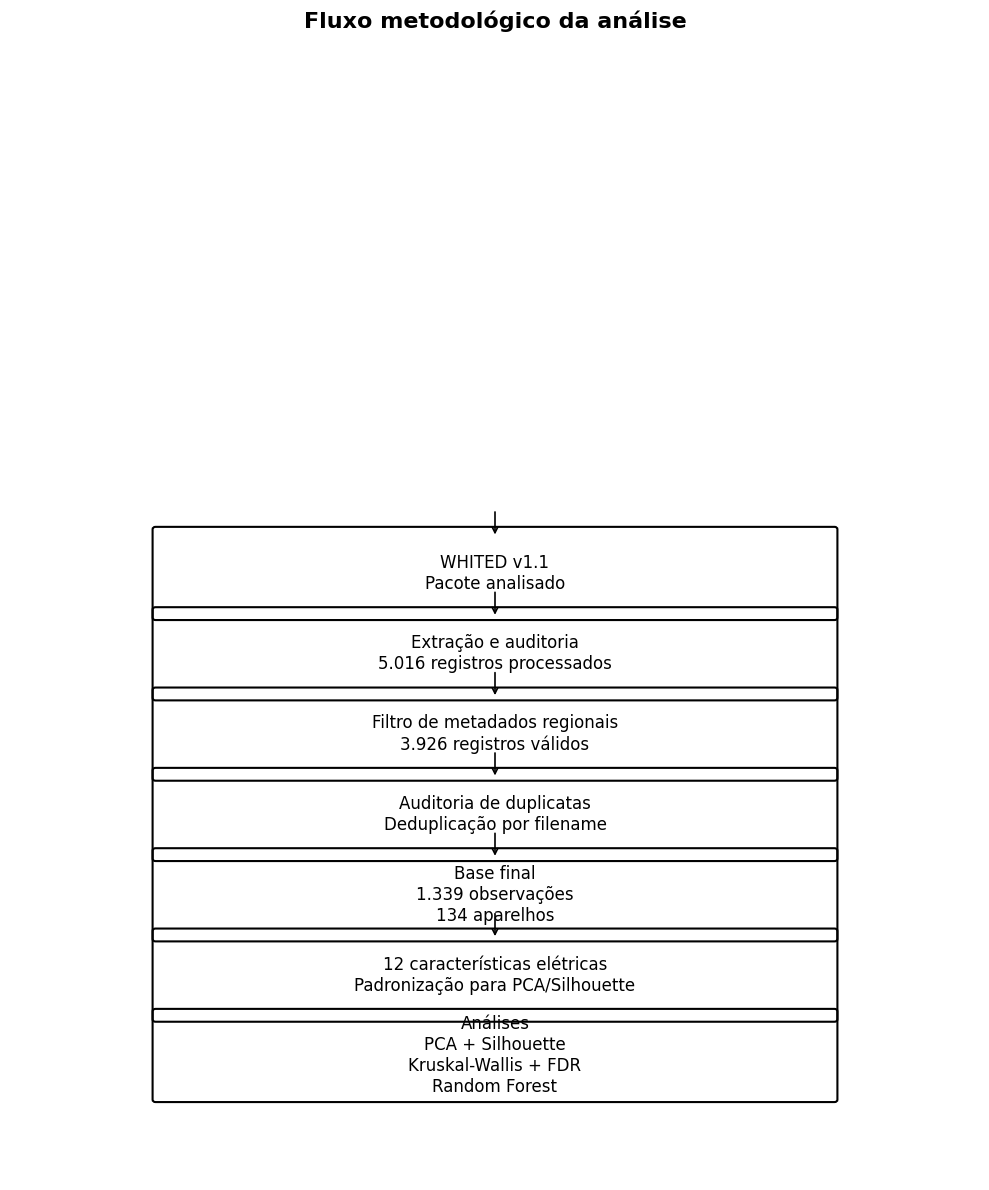

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_1_Fluxo_Metodologico.png


In [241]:
# ============================================================
# FIGURA 1 — FLUXOGRAMA METODOLÓGICO
# ============================================================

from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(10, 12))

ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

boxes = [
    (7, "WHITED v1.1\nPacote analisado"),
    (6, "Extração e auditoria\n5.016 registros processados"),
    (5, "Filtro de metadados regionais\n3.926 registros válidos"),
    (4, "Auditoria de duplicatas\nDeduplicação por filename"),
    (3, "Base final\n1.339 observações\n134 aparelhos"),
    (2, "12 características elétricas\nPadronização para PCA/Silhouette"),
    (1, "Análises\nPCA + Silhouette\nKruskal-Wallis + FDR\nRandom Forest"),
]

for y, text in boxes:
    box = FancyBboxPatch(
        (1.5, y),
        7,
        1.1,
        boxstyle="round,pad=0.03",
        linewidth=1.5,
        fill=False
    )
    ax.add_patch(box)

    ax.text(
        5,
        y + 0.55,
        text,
        ha="center",
        va="center",
        fontsize=12
    )

for y in range(2, 8):
    ax.annotate(
        "",
        xy=(5, y + 1),
        xytext=(5, y + 1.35),
        arrowprops=dict(arrowstyle="->", linewidth=1.2)
    )

ax.set_title(
    "Fluxo metodológico da análise",
    fontsize=16,
    fontweight="bold",
    pad=20
)

fig.tight_layout()

fig1_path = os.path.join(FIG_DIR, "Figura_1_Fluxo_Metodologico.png")
fig.savefig(fig1_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig1_path)

In [242]:
# ============================================================
# PREPARAÇÃO — PCA NO NÍVEL DE APARELHO
# ============================================================

# Agregação por aparelho
agg_dict = {f: "median" for f in feature_cols}

meta_dict = {
    "region": "first",
    "kit": "first"
}

df_appliance_final = (
    df_analysis
    .groupby("appliance", as_index=False)
    .agg({**agg_dict, **meta_dict})
)

print("df_appliance_final:", df_appliance_final.shape)

assert len(df_appliance_final) == 134
assert df_appliance_final["region"].nunique() == 9
assert df_appliance_final["kit"].nunique() == 2

X_app = df_appliance_final[feature_cols].values

scaler_app = StandardScaler()
X_app_scaled = scaler_app.fit_transform(X_app)

pca_app = PCA()
X_pca_app = pca_app.fit_transform(X_app_scaled)

explained = pca_app.explained_variance_ratio_

print("\nVariância explicada:")
for i in range(5):
    print(f"PC{i+1}: {explained[i]*100:.3f}%")

print(
    f"\nPC1+PC2: "
    f"{explained[:2].sum()*100:.3f}%"
)

print(
    f"PC1-PC5: "
    f"{explained[:5].sum()*100:.3f}%"
)

df_appliance_final: (134, 15)

Variância explicada:
PC1: 34.574%
PC2: 27.693%
PC3: 15.105%
PC4: 7.834%
PC5: 5.931%

PC1+PC2: 62.266%
PC1-PC5: 91.136%


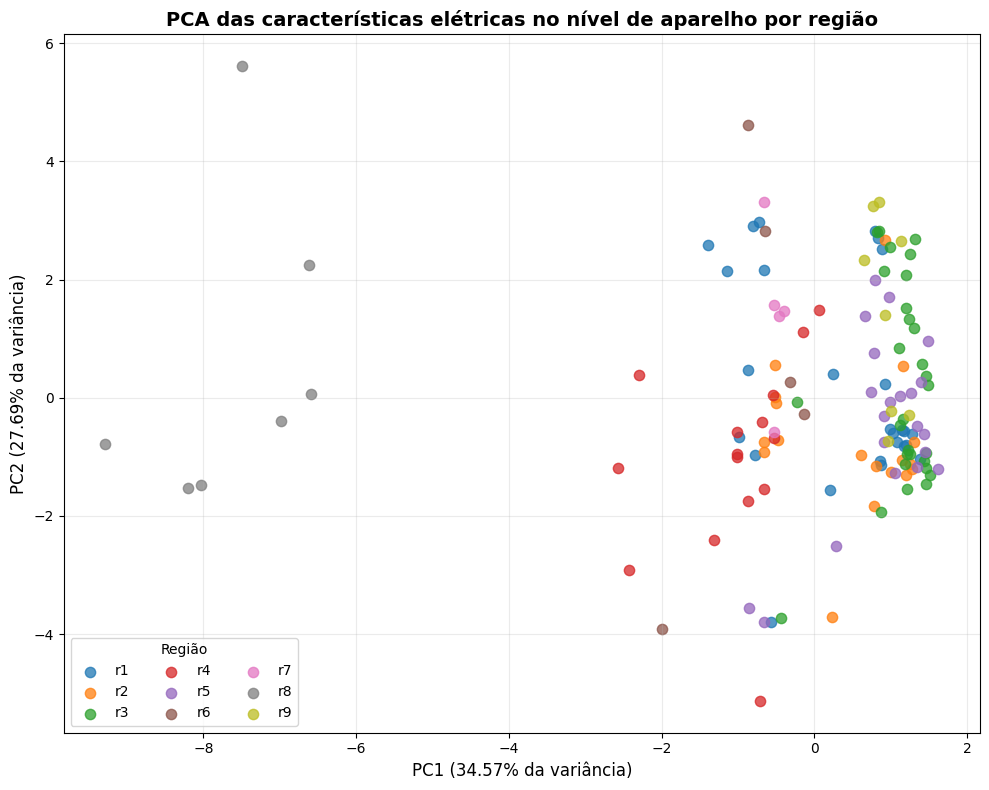

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_2_PCA_Global_Regiao.png


In [243]:
# ============================================================
# FIGURA 2 — PCA GLOBAL POR REGIÃO
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

regions = sorted(df_appliance_final["region"].unique())

for region in regions:
    mask = df_appliance_final["region"].values == region

    ax.scatter(
        X_pca_app[mask, 0],
        X_pca_app[mask, 1],
        label=region,
        alpha=0.75,
        s=55
    )

ax.set_xlabel(
    f"PC1 ({explained[0]*100:.2f}% da variância)",
    fontsize=12
)

ax.set_ylabel(
    f"PC2 ({explained[1]*100:.2f}% da variância)",
    fontsize=12
)

ax.set_title(
    "PCA das características elétricas no nível de aparelho por região",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    title="Região",
    ncol=3,
    frameon=True
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig2_path = os.path.join(FIG_DIR, "Figura_2_PCA_Global_Regiao.png")
fig.savefig(fig2_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig2_path)

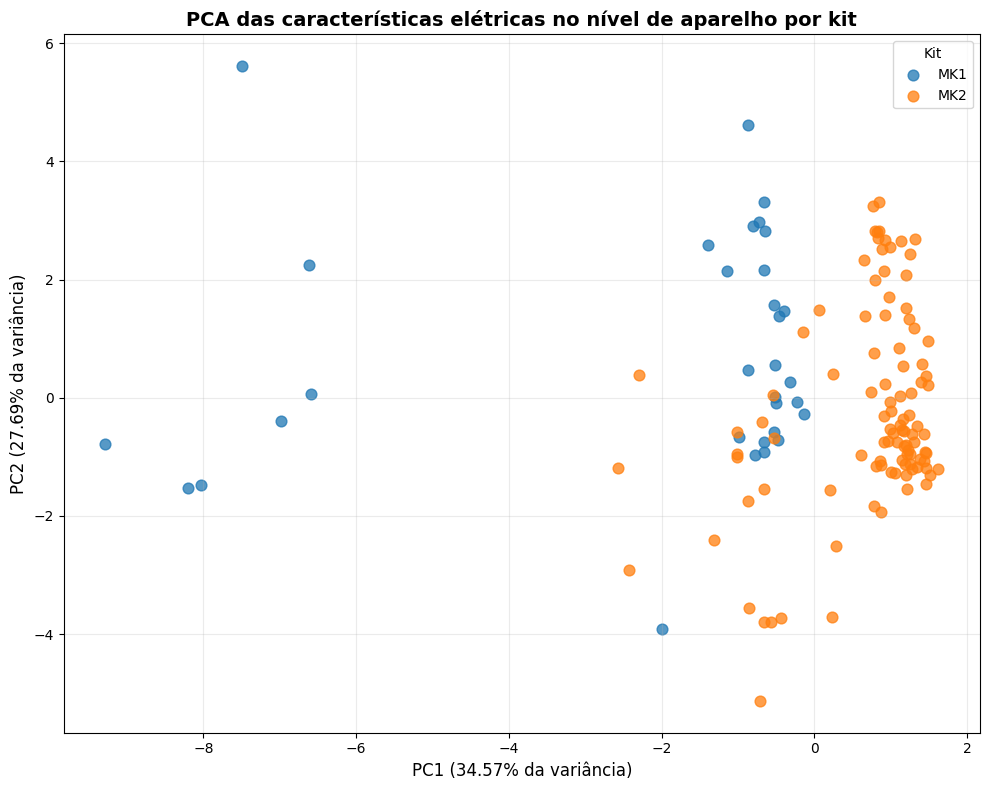

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_3_PCA_Global_Kit.png


In [244]:
# ============================================================
# FIGURA 3 — PCA GLOBAL POR KIT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

kits = sorted(df_appliance_final["kit"].unique())

for kit in kits:
    mask = df_appliance_final["kit"].values == kit

    ax.scatter(
        X_pca_app[mask, 0],
        X_pca_app[mask, 1],
        label=kit,
        alpha=0.75,
        s=60
    )

ax.set_xlabel(
    f"PC1 ({explained[0]*100:.2f}% da variância)",
    fontsize=12
)

ax.set_ylabel(
    f"PC2 ({explained[1]*100:.2f}% da variância)",
    fontsize=12
)

ax.set_title(
    "PCA das características elétricas no nível de aparelho por kit",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    title="Kit",
    frameon=True
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig3_path = os.path.join(FIG_DIR, "Figura_3_PCA_Global_Kit.png")
fig.savefig(fig3_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig3_path)

MK1 aparelhos: 32
PC1: 42.888% | PC2: 26.700% | PC1+PC2: 69.589%


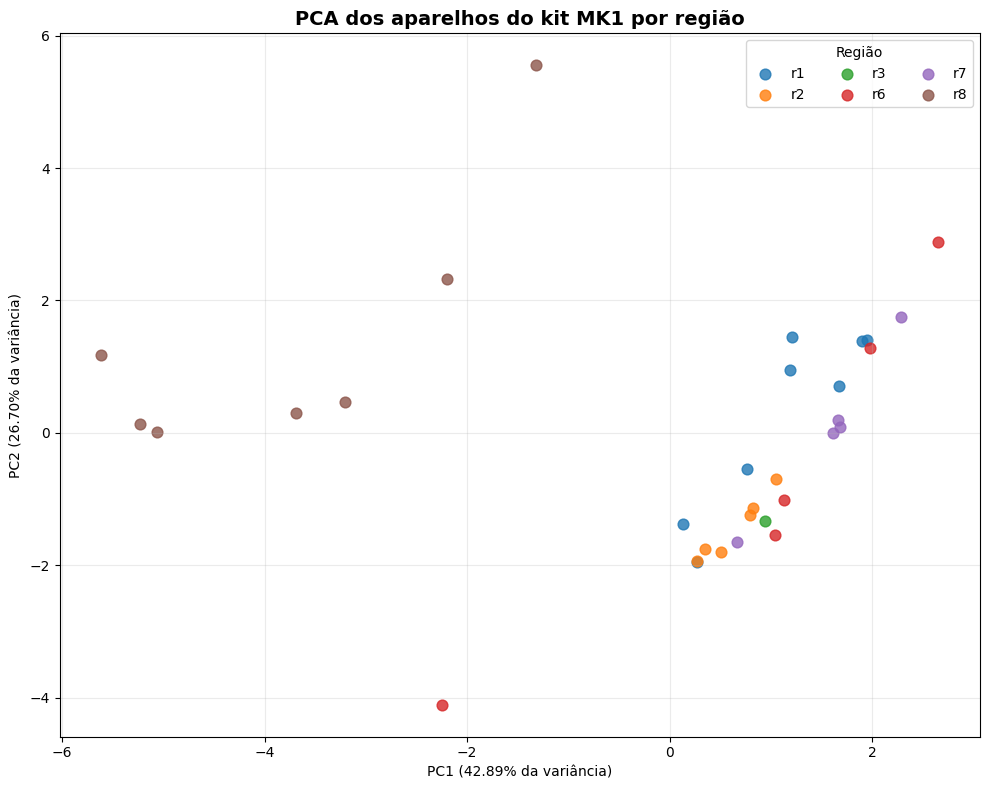

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_4_PCA_MK1.png


In [245]:
# ============================================================
# FIGURA 4 — PCA MK1
# ============================================================

mask_mk1 = df_appliance_final["kit"].values == "MK1"

df_mk1_app = df_appliance_final.loc[mask_mk1].reset_index(drop=True)
X_mk1_app = df_mk1_app[feature_cols].values

scaler_mk1 = StandardScaler()
X_mk1_scaled = scaler_mk1.fit_transform(X_mk1_app)

pca_mk1 = PCA()
X_pca_mk1 = pca_mk1.fit_transform(X_mk1_scaled)

exp_mk1 = pca_mk1.explained_variance_ratio_

print("MK1 aparelhos:", len(df_mk1_app))
print(
    f"PC1: {exp_mk1[0]*100:.3f}% | "
    f"PC2: {exp_mk1[1]*100:.3f}% | "
    f"PC1+PC2: {exp_mk1[:2].sum()*100:.3f}%"
)

fig, ax = plt.subplots(figsize=(10, 8))

for region in sorted(df_mk1_app["region"].unique()):
    mask = df_mk1_app["region"].values == region

    ax.scatter(
        X_pca_mk1[mask, 0],
        X_pca_mk1[mask, 1],
        label=region,
        alpha=0.8,
        s=60
    )

ax.set_xlabel(
    f"PC1 ({exp_mk1[0]*100:.2f}% da variância)"
)

ax.set_ylabel(
    f"PC2 ({exp_mk1[1]*100:.2f}% da variância)"
)

ax.set_title(
    "PCA dos aparelhos do kit MK1 por região",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    title="Região",
    ncol=3
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig4_path = os.path.join(FIG_DIR, "Figura_4_PCA_MK1.png")
fig.savefig(fig4_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig4_path)

MK2 aparelhos: 102
PC1: 31.841% | PC2: 24.591% | PC1+PC2: 56.432%


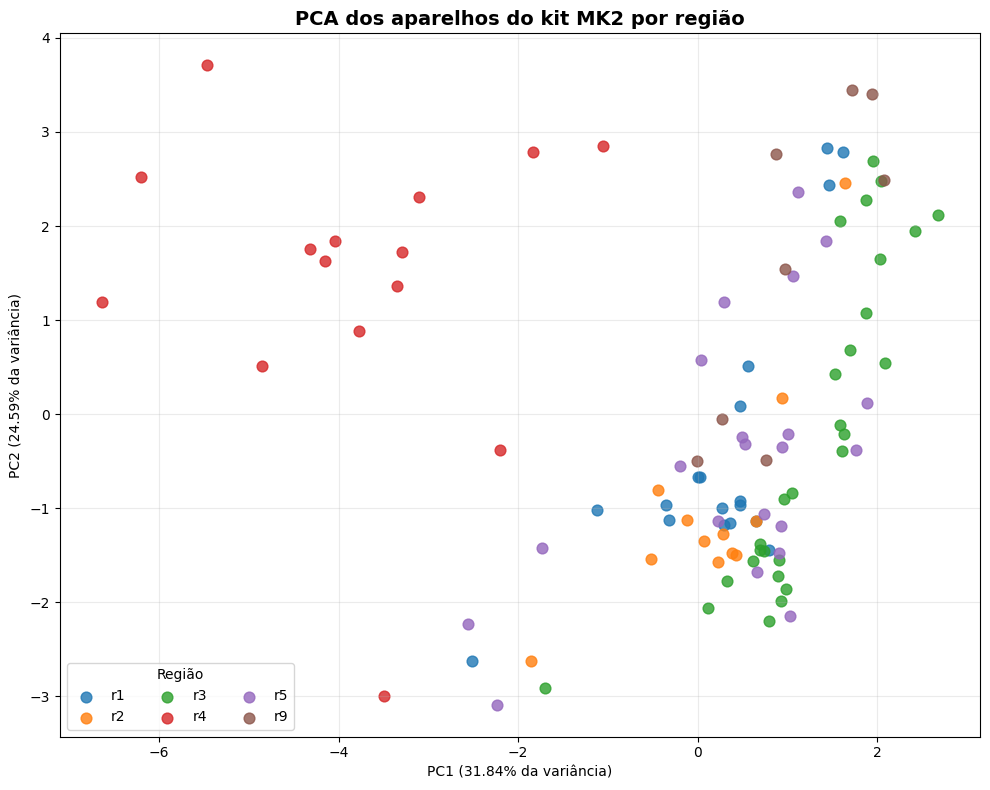

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_5_PCA_MK2.png


In [246]:
# ============================================================
# FIGURA 5 — PCA MK2
# ============================================================

mask_mk2 = df_appliance_final["kit"].values == "MK2"

df_mk2_app = df_appliance_final.loc[mask_mk2].reset_index(drop=True)
X_mk2_app = df_mk2_app[feature_cols].values

scaler_mk2 = StandardScaler()
X_mk2_scaled = scaler_mk2.fit_transform(X_mk2_app)

pca_mk2 = PCA()
X_pca_mk2 = pca_mk2.fit_transform(X_mk2_scaled)

exp_mk2 = pca_mk2.explained_variance_ratio_

print("MK2 aparelhos:", len(df_mk2_app))
print(
    f"PC1: {exp_mk2[0]*100:.3f}% | "
    f"PC2: {exp_mk2[1]*100:.3f}% | "
    f"PC1+PC2: {exp_mk2[:2].sum()*100:.3f}%"
)

fig, ax = plt.subplots(figsize=(10, 8))

for region in sorted(df_mk2_app["region"].unique()):
    mask = df_mk2_app["region"].values == region

    ax.scatter(
        X_pca_mk2[mask, 0],
        X_pca_mk2[mask, 1],
        label=region,
        alpha=0.8,
        s=60
    )

ax.set_xlabel(
    f"PC1 ({exp_mk2[0]*100:.2f}% da variância)"
)

ax.set_ylabel(
    f"PC2 ({exp_mk2[1]*100:.2f}% da variância)"
)

ax.set_title(
    "PCA dos aparelhos do kit MK2 por região",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    title="Região",
    ncol=3
)

ax.grid(alpha=0.25)

fig.tight_layout()

fig5_path = os.path.join(FIG_DIR, "Figura_5_PCA_MK2.png")
fig.savefig(fig5_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig5_path)

In [247]:
# ============================================================
# SILHOUETTE OFICIAL — REGIÃO E KIT
# ============================================================

sil_region = silhouette_samples(
    X_app_scaled,
    df_appliance_final["region"]
)

sil_kit = silhouette_samples(
    X_app_scaled,
    df_appliance_final["kit"]
)

sil_region_global = silhouette_score(
    X_app_scaled,
    df_appliance_final["region"]
)

sil_kit_global = silhouette_score(
    X_app_scaled,
    df_appliance_final["kit"]
)

print(f"Silhouette região = {sil_region_global:.6f}")
print(f"Silhouette kit    = {sil_kit_global:.6f}")

print("\nPor kit:")

for kit in sorted(df_appliance_final["kit"].unique()):
    mask = df_appliance_final["kit"].values == kit

    print(
        kit,
        "n =", mask.sum(),
        "média =", sil_kit[mask].mean(),
        "negativos =", (sil_kit[mask] < 0).sum(),
        "percentual =", (sil_kit[mask] < 0).mean()*100
    )

Silhouette região = -0.068097
Silhouette kit    = 0.245778

Por kit:
MK1 n = 32 média = -0.047095141907857976 negativos = 23 percentual = 71.875
MK2 n = 102 média = 0.3376594938676173 negativos = 0 percentual = 0.0


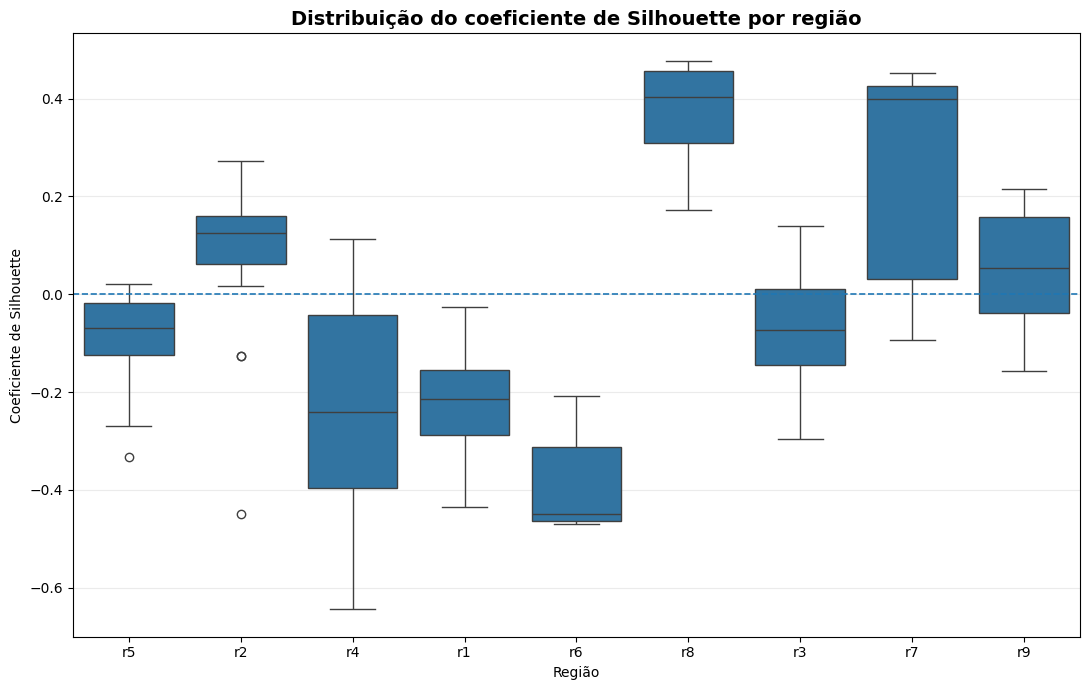

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_6_Silhouette_Regiao.png


In [248]:
# ============================================================
# FIGURA 6 — DISTRIBUIÇÃO DO SILHOUETTE POR REGIÃO
# ============================================================

df_sil = pd.DataFrame({
    "region": df_appliance_final["region"].values,
    "kit": df_appliance_final["kit"].values,
    "silhouette_region": sil_region,
    "silhouette_kit": sil_kit
})

fig, ax = plt.subplots(figsize=(11, 7))

sns.boxplot(
    data=df_sil,
    x="region",
    y="silhouette_region",
    ax=ax
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.2
)

ax.set_xlabel("Região")
ax.set_ylabel("Coeficiente de Silhouette")

ax.set_title(
    "Distribuição do coeficiente de Silhouette por região",
    fontsize=14,
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

fig6_path = os.path.join(FIG_DIR, "Figura_6_Silhouette_Regiao.png")
fig.savefig(fig6_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig6_path)

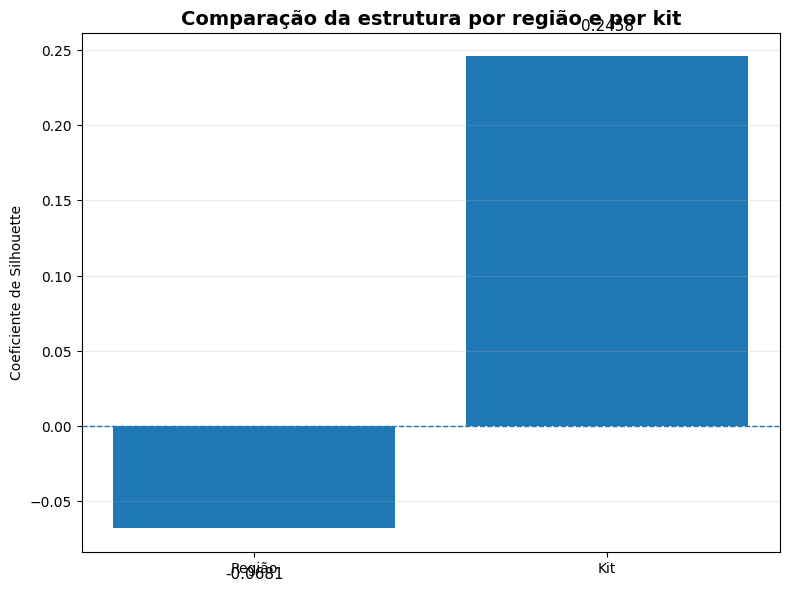

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_7_Silhouette_Regiao_Kit.png


In [249]:
# ============================================================
# FIGURA 7 — SILHOUETTE: REGIÃO VS KIT
# ============================================================

comparison = pd.DataFrame({
    "Agrupamento": ["Região", "Kit"],
    "Silhouette": [
        sil_region_global,
        sil_kit_global
    ]
})

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    comparison["Agrupamento"],
    comparison["Silhouette"]
)

ax.axhline(
    0,
    linestyle="--",
    linewidth=1.0
)

ax.set_ylabel("Coeficiente de Silhouette")

ax.set_title(
    "Comparação da estrutura por região e por kit",
    fontsize=14,
    fontweight="bold"
)

for bar, value in zip(bars, comparison["Silhouette"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + (0.015 if value >= 0 else -0.025),
        f"{value:.4f}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=11
    )

ax.grid(axis="y", alpha=0.25)

fig.tight_layout()

fig7_path = os.path.join(FIG_DIR, "Figura_7_Silhouette_Regiao_Kit.png")
fig.savefig(fig7_path, dpi=600, bbox_inches="tight")
plt.show()

print("Salvo:", fig7_path)

In [250]:
# ============================================================
# RANDOM FOREST — REPRODUÇÃO OFICIAL V2
# ============================================================

from sklearn.base import clone

RF_PARAMS = {
    "n_estimators": 500,
    "random_state": 42,
    "n_jobs": -1,
    "class_weight": "balanced"
}

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


def evaluate_rf_v2(X, y, groups, experiment_name):

    fold_results = []
    y_true_all = []
    y_pred_all = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        rf = RandomForestClassifier(**RF_PARAMS)

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        bal = balanced_accuracy_score(
            y_test,
            y_pred
        )

        macro = f1_score(
            y_test,
            y_pred,
            average="macro"
        )

        weighted = f1_score(
            y_test,
            y_pred,
            average="weighted"
        )

        fold_results.append({
            "experiment": experiment_name,
            "fold": fold,
            "accuracy": acc,
            "balanced_accuracy": bal,
            "macro_f1": macro,
            "weighted_f1": weighted,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_appliances": len(
                np.unique(groups[train_idx])
            ),
            "n_test_appliances": len(
                np.unique(groups[test_idx])
            )
        })

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    fold_df = pd.DataFrame(fold_results)

    summary = {
        "experiment": experiment_name,

        "accuracy_mean": fold_df["accuracy"].mean(),
        "accuracy_sd": fold_df["accuracy"].std(ddof=1),

        "balanced_accuracy_mean":
            fold_df["balanced_accuracy"].mean(),

        "balanced_accuracy_sd":
            fold_df["balanced_accuracy"].std(ddof=1),

        "macro_f1_mean":
            fold_df["macro_f1"].mean(),

        "macro_f1_sd":
            fold_df["macro_f1"].std(ddof=1),

        "weighted_f1_mean":
            fold_df["weighted_f1"].mean(),

        "weighted_f1_sd":
            fold_df["weighted_f1"].std(ddof=1)
    }

    return (
        pd.DataFrame([summary]),
        fold_df,
        np.array(y_true_all),
        np.array(y_pred_all)
    )

In [252]:
# ============================================================
# KIT → ONE-HOT ENCODING
# ============================================================

kit_dummies = pd.get_dummies(
    df_analysis["kit"],
    prefix="kit",
    dtype=int
)

# Ordem determinística
kit_dummies = kit_dummies.reindex(
    columns=sorted(kit_dummies.columns)
)

print("Colunas do kit:", list(kit_dummies.columns))
print("Shape:", kit_dummies.shape)
print(kit_dummies.head())

Colunas do kit: ['kit_MK1', 'kit_MK2']
Shape: (1339, 2)
   kit_MK1  kit_MK2
0        0        1
1        0        1
2        0        1
3        0        1
4        0        1


In [254]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    confusion_matrix
)
import numpy as np
import pandas as pd


def evaluate_rf_v2(X, y, groups, experiment_name):

    # ============================================================
    # GARANTIR MATRIZ NUMÉRICA INDEXÁVEL POR POSIÇÃO
    # ============================================================
    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()

    else:
        X = np.asarray(X)

    y = np.asarray(y)
    groups = np.asarray(groups)

    # Garantir que tudo tenha o mesmo número de observações
    assert len(X) == len(y) == len(groups), (
        f"Incompatibilidade: X={len(X)}, "
        f"y={len(y)}, groups={len(groups)}"
    )

    # ============================================================
    # CROSS-VALIDATION
    # ============================================================
    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_results = []
    y_true_all = []
    y_pred_all = []

    # ============================================================
    # 5 FOLDS
    # ============================================================
    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups),
        start=1
    ):

        # --------------------------------------------------------
        # Seleção por posição
        # --------------------------------------------------------
        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        groups_train = groups[train_idx]
        groups_test = groups[test_idx]

        # --------------------------------------------------------
        # Auditoria de grupos
        # --------------------------------------------------------
        overlap = set(groups_train).intersection(
            set(groups_test)
        )

        if len(overlap) > 0:
            raise RuntimeError(
                f"Group leakage detectado no fold {fold}: "
                f"{overlap}"
            )

        # --------------------------------------------------------
        # Random Forest
        # --------------------------------------------------------
        clf = RandomForestClassifier(
            n_estimators=500,
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )

        clf.fit(X_train, y_train)

        y_pred = clf.predict(X_test)

        # --------------------------------------------------------
        # Métricas
        # --------------------------------------------------------
        acc = accuracy_score(
            y_test,
            y_pred
        )

        bal_acc = balanced_accuracy_score(
            y_test,
            y_pred
        )

        macro_f1 = f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        )

        weighted_f1 = f1_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0
        )

        fold_results.append({
            "experiment": experiment_name,
            "fold": fold,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "macro_f1": macro_f1,
            "weighted_f1": weighted_f1,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            "n_train_groups": len(np.unique(groups_train)),
            "n_test_groups": len(np.unique(groups_test)),
            "n_train_regions": len(np.unique(y_train)),
            "n_test_regions": len(np.unique(y_test)),
            "group_overlap": len(overlap)
        })

        # --------------------------------------------------------
        # Guardar predições
        # --------------------------------------------------------
        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

    # ============================================================
    # DATAFRAME DOS FOLDS
    # ============================================================
    folds_df = pd.DataFrame(fold_results)

    # ============================================================
    # RESUMO
    # ============================================================
    summary = {
        "experiment": experiment_name,

        "accuracy_mean":
            folds_df["accuracy"].mean(),

        "accuracy_std":
            folds_df["accuracy"].std(ddof=1),

        "balanced_accuracy_mean":
            folds_df["balanced_accuracy"].mean(),

        "balanced_accuracy_std":
            folds_df["balanced_accuracy"].std(ddof=1),

        "macro_f1_mean":
            folds_df["macro_f1"].mean(),

        "macro_f1_std":
            folds_df["macro_f1"].std(ddof=1),

        "weighted_f1_mean":
            folds_df["weighted_f1"].mean(),

        "weighted_f1_std":
            folds_df["weighted_f1"].std(ddof=1),

        "n_samples":
            len(X),

        "n_groups":
            len(np.unique(groups)),

        "n_classes":
            len(np.unique(y))
    }

    summary_df = pd.DataFrame([summary])

    return (
        summary_df,
        folds_df,
        np.asarray(y_true_all),
        np.asarray(y_pred_all)
    )

In [255]:
experiments = [
    (
        "Features → Região",
        X_features,
        y_region,
        groups_appliance
    ),

    (
        "Kit → Região",
        X_kit,
        y_region,
        groups_appliance
    ),

    (
        "Features + Kit → Região",
        X_features_kit,
        y_region,
        groups_appliance
    )
]


results = []

fold_results_all = {}

predictions_all = {}


for experiment_name, X_input, y_input, groups_input in experiments:

    summary, folds, y_true, y_pred = evaluate_rf_v2(
        X_input,
        y_input,
        groups_input,
        experiment_name
    )

    results.append(summary)

    fold_results_all[experiment_name] = folds

    predictions_all[experiment_name] = {
        "y_true": y_true,
        "y_pred": y_pred
    }


rf_summary = pd.concat(
    results,
    ignore_index=True
)


rf_summary

,experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,n_samples,n_groups,n_classes
0,Features → Região,0.704750,0.060683,0.738410,0.089968,0.687571,0.081484,0.697205,0.068887,1339,134,9
1,Kit → Região,0.164597,0.062777,0.206481,0.052745,0.069198,0.030983,0.055496,0.034660,1339,134,9
2,Features + Kit → Região,0.756449,0.043555,0.791359,0.070815,0.743564,0.092988,0.757702,0.040355,1339,134,9


In [256]:
print("X_features:")
print(type(X_features), X_features.shape)

print("\nX_kit:")
print(type(X_kit), X_kit.shape)

print("\nX_features_kit:")
print(type(X_features_kit), X_features_kit.shape)

print("\ny_region:")
print(type(y_region), len(y_region))

print("\ngroups_appliance:")
print(type(groups_appliance), len(groups_appliance))

X_features:
<class 'numpy.ndarray'> (1339, 12)

X_kit:
<class 'pandas.core.frame.DataFrame'> (1339, 2)

X_features_kit:
<class 'pandas.core.frame.DataFrame'> (1339, 14)

y_region:
<class 'numpy.ndarray'> 1339

groups_appliance:
<class 'numpy.ndarray'> 1339


In [258]:
# ============================================================
# RF — RESULTADO GLOBAL
# ============================================================

rf_global_summary = rf_summary.copy()

display(
    rf_global_summary[
        [
            "experiment",
            "accuracy_mean",
            "accuracy_std",
            "balanced_accuracy_mean",
            "balanced_accuracy_std",
            "macro_f1_mean",
            "macro_f1_std",
            "weighted_f1_mean",
            "weighted_f1_std"
        ]
    ]
)

,experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Features → Região,0.704750,0.060683,0.738410,0.089968,0.687571,0.081484,0.697205,0.068887
1,Kit → Região,0.164597,0.062777,0.206481,0.052745,0.069198,0.030983,0.055496,0.034660
2,Features + Kit → Região,0.756449,0.043555,0.791359,0.070815,0.743564,0.092988,0.757702,0.040355


In [261]:
# ============================================================
# RF GLOBAL — FEATURES / KIT / FEATURES + KIT
# ============================================================

rf_global_results = []
rf_global_folds = {}
rf_global_predictions = {}

for X_input, name in [
    (X_features, "Features -> Região"),
    (X_kit, "Kit -> Região"),
    (X_features_kit, "Features + Kit -> Região")
]:

    summary, folds, y_true, y_pred = evaluate_rf_v2(
        X_input,
        y_region,
        groups_appliance,
        name
    )

    rf_global_results.append(summary)
    rf_global_folds[name] = folds
    rf_global_predictions[name] = (y_true, y_pred)

rf_global_summary = pd.concat(
    rf_global_results,
    ignore_index=True
)

rf_global_summary

,experiment,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,n_samples,n_groups,n_classes
0,Features -> Região,0.704750,0.060683,0.738410,0.089968,0.687571,0.081484,0.697205,0.068887,1339,134,9
1,Kit -> Região,0.164597,0.062777,0.206481,0.052745,0.069198,0.030983,0.055496,0.034660,1339,134,9
2,Features + Kit -> Região,0.756449,0.043555,0.791359,0.070815,0.743564,0.092988,0.757702,0.040355,1339,134,9


In [262]:
# ============================================================
# CONFERÊNCIA DOS RESULTADOS RF V2
# ============================================================

display(
    rf_global_summary[
        [
            "experiment",
            "accuracy_mean",
            "accuracy_sd",
            "balanced_accuracy_mean",
            "balanced_accuracy_sd",
            "macro_f1_mean",
            "macro_f1_sd",
            "weighted_f1_mean",
            "weighted_f1_sd"
        ]
    ].round(6)
)

KeyError: "['accuracy_sd', 'balanced_accuracy_sd', 'macro_f1_sd', 'weighted_f1_sd'] not in index"

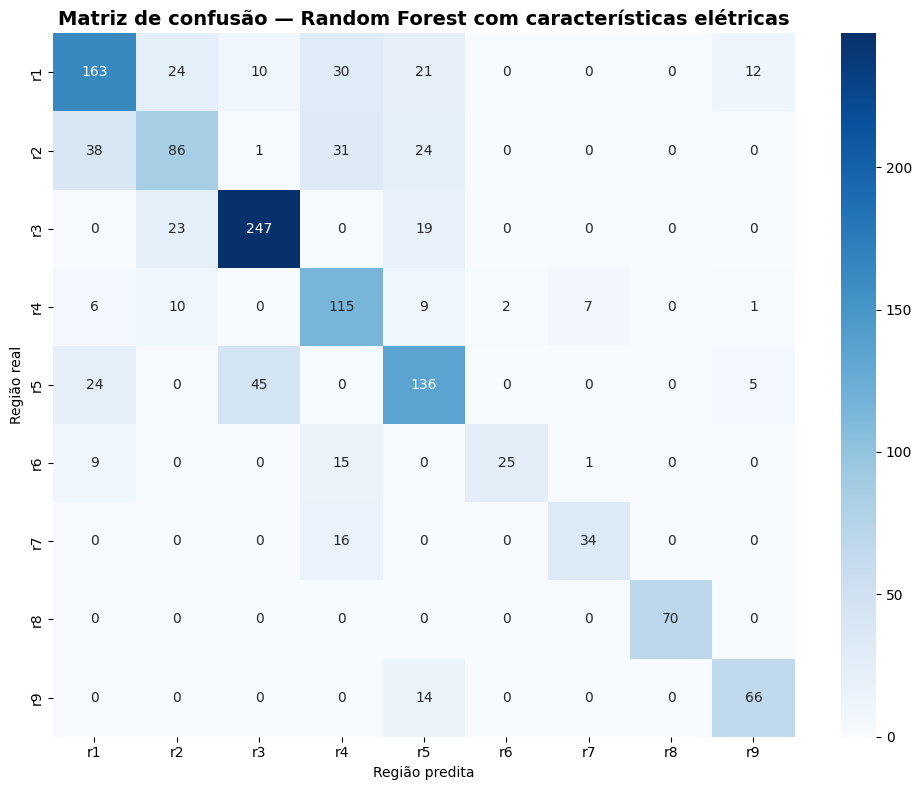

Salvo: /content/WCNPS2026_V2_FINAL/figuras/Figura_8_Matriz_Confusao_RF_Global.png


In [263]:
# ============================================================
# FIGURA 8 — MATRIZ DE CONFUSÃO RF GLOBAL
# ============================================================

# Usaremos o modelo Features -> Região,
# que é o experimento principal.

y_true_rf, y_pred_rf = rf_global_predictions[
    "Features -> Região"
]

labels_region = sorted(
    df_analysis["region"].astype(str).unique()
)

cm = confusion_matrix(
    y_true_rf,
    y_pred_rf,
    labels=labels_region
)

cm_df = pd.DataFrame(
    cm,
    index=labels_region,
    columns=labels_region
)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    ax=ax
)

ax.set_xlabel("Região predita")
ax.set_ylabel("Região real")

ax.set_title(
    "Matriz de confusão — Random Forest com características elétricas",
    fontsize=14,
    fontweight="bold"
)

fig.tight_layout()

fig8_path = os.path.join(
    FIG_DIR,
    "Figura_8_Matriz_Confusao_RF_Global.png"
)

fig.savefig(
    fig8_path,
    dpi=600,
    bbox_inches="tight"
)

plt.show()

print("Salvo:", fig8_path)

In [264]:
# ============================================================
# TABELA 1 — CARACTERIZAÇÃO DO DATASET
# ============================================================

table1 = (
    df_analysis
    .groupby("region")
    .agg(
        aparelhos=("appliance", "nunique"),
        observacoes=("filename", "count")
    )
    .reset_index()
)

total_row = pd.DataFrame({
    "region": ["Total"],
    "aparelhos": [df_analysis["appliance"].nunique()],
    "observacoes": [len(df_analysis)]
})

table1_final = pd.concat(
    [table1, total_row],
    ignore_index=True
)

display(table1_final)

table1_path = os.path.join(
    TAB_DIR,
    "Tabela_1_Caracterizacao_Dataset.xlsx"
)

table1_final.to_excel(
    table1_path,
    index=False
)

print("Salvo:", table1_path)

,region,aparelhos,observacoes
0,r1,26,260
1,r2,18,180
2,r3,29,289
3,r4,15,150
4,r5,21,210
5,r6,5,50
6,r7,5,50
7,r8,7,70
8,r9,8,80
9,Total,134,1339


Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_1_Caracterizacao_Dataset.xlsx


In [265]:
# ============================================================
# TABELA 2 — PCA + SILHOUETTE
# ============================================================

# Função auxiliar para calcular silhouette de r1/r2/r3
def silhouette_subset(df_sub, label_col="region"):

    X_sub = df_sub[feature_cols].values

    scaler = StandardScaler()
    X_sub_scaled = scaler.fit_transform(X_sub)

    labels = df_sub[label_col].astype(str).values

    return silhouette_score(
        X_sub_scaled,
        labels
    )


# r1/r2/r3 — MK1
df_r123_mk1 = df_appliance_final[
    (df_appliance_final["kit"] == "MK1") &
    (df_appliance_final["region"].isin(["r1", "r2", "r3"]))
].reset_index(drop=True)

# r1/r2/r3 — MK2
df_r123_mk2 = df_appliance_final[
    (df_appliance_final["kit"] == "MK2") &
    (df_appliance_final["region"].isin(["r1", "r2", "r3"]))
].reset_index(drop=True)

sil_r123_mk1 = silhouette_subset(df_r123_mk1)
sil_r123_mk2 = silhouette_subset(df_r123_mk2)

table2 = pd.DataFrame({
    "Agrupamento": [
        "Região — global",
        "Kit — global",
        "r1/r2/r3 — MK1",
        "r1/r2/r3 — MK2"
    ],
    "Unidade": [
        "Aparelho",
        "Aparelho",
        "Aparelho",
        "Aparelho"
    ],
    "N": [
        len(df_appliance_final),
        len(df_appliance_final),
        len(df_r123_mk1),
        len(df_r123_mk2)
    ],
    "Silhouette": [
        sil_region_global,
        sil_kit_global,
        sil_r123_mk1,
        sil_r123_mk2
    ]
})

display(
    table2.style.format({
        "Silhouette": "{:.6f}"
    })
)

table2_path = os.path.join(
    TAB_DIR,
    "Tabela_2_PCA_Silhouette.xlsx"
)

table2.to_excel(
    table2_path,
    index=False
)

print("Salvo:", table2_path)

,Agrupamento,Unidade,N,Silhouette
0,Região — global,Aparelho,134,-0.068097
1,Kit — global,Aparelho,134,0.245778
2,r1/r2/r3 — MK1,Aparelho,15,0.135726
3,r1/r2/r3 — MK2,Aparelho,58,0.100139


Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_2_PCA_Silhouette.xlsx


In [267]:
# ============================================================
# R1/R2/R3 — KIT ONE-HOT ENCODING
# ============================================================

kit_r123_dummies = pd.get_dummies(
    df_r123["kit"],
    prefix="kit",
    dtype=int
)

# Ordem determinística
kit_r123_dummies = kit_r123_dummies.reindex(
    columns=sorted(kit_r123_dummies.columns)
)

# Matriz numérica
X_r123_kit = kit_r123_dummies.to_numpy()

print("Kit R1/R2/R3:")
print(kit_r123_dummies.columns.tolist())
print("Shape:", X_r123_kit.shape)

Kit R1/R2/R3:
['kit_MK1', 'kit_MK2']
Shape: (729, 2)


In [270]:
# ============================================================
# TABELA 3 — RESULTADOS DO RANDOM FOREST
# ============================================================

table3_display = table3[
    [
        "experiment",
        "accuracy_mean",
        "accuracy_std",
        "balanced_accuracy_mean",
        "balanced_accuracy_std",
        "macro_f1_mean",
        "macro_f1_std",
        "weighted_f1_mean",
        "weighted_f1_std"
    ]
].copy()

# Renomear para apresentação
table3_display = table3_display.rename(
    columns={
        "experiment": "Experimento",

        "accuracy_mean": "Accuracy",
        "accuracy_std": "SD Accuracy",

        "balanced_accuracy_mean": "Balanced Accuracy",
        "balanced_accuracy_std": "SD Balanced Accuracy",

        "macro_f1_mean": "Macro-F1",
        "macro_f1_std": "SD Macro-F1",

        "weighted_f1_mean": "Weighted-F1",
        "weighted_f1_std": "SD Weighted-F1"
    }
)

# Formatação média ± SD
table3_display["Accuracy"] = (
    table3_display["Accuracy"].map(lambda x: f"{x:.4f}")
    + " ± " +
    table3_display["SD Accuracy"].map(lambda x: f"{x:.4f}")
)

table3_display["Balanced Accuracy"] = (
    table3_display["Balanced Accuracy"].map(lambda x: f"{x:.4f}")
    + " ± " +
    table3_display["SD Balanced Accuracy"].map(lambda x: f"{x:.4f}")
)

table3_display["Macro-F1"] = (
    table3_display["Macro-F1"].map(lambda x: f"{x:.4f}")
    + " ± " +
    table3_display["SD Macro-F1"].map(lambda x: f"{x:.4f}")
)

table3_display["Weighted-F1"] = (
    table3_display["Weighted-F1"].map(lambda x: f"{x:.4f}")
    + " ± " +
    table3_display["SD Weighted-F1"].map(lambda x: f"{x:.4f}")
)

# Manter somente as colunas finais
table3_display = table3_display[
    [
        "Experimento",
        "Accuracy",
        "Balanced Accuracy",
        "Macro-F1",
        "Weighted-F1"
    ]
]

display(table3_display)

,Experimento,Accuracy,Balanced Accuracy,Macro-F1,Weighted-F1
0,Features -> Região,0.7047 ± 0.0607,0.7384 ± 0.0900,0.6876 ± 0.0815,0.6972 ± 0.0689
1,Kit -> Região,0.1646 ± 0.0628,0.2065 ± 0.0527,0.0692 ± 0.0310,0.0555 ± 0.0347
2,Features + Kit -> Região,0.7564 ± 0.0436,0.7914 ± 0.0708,0.7436 ± 0.0930,0.7577 ± 0.0404
3,r1/r2/r3 — Features -> Região,0.8135 ± 0.1302,0.8106 ± 0.1191,0.8028 ± 0.1251,0.8091 ± 0.1355
4,r1/r2/r3 — Kit -> Região,0.4240 ± 0.0734,0.3578 ± 0.0388,0.2566 ± 0.0293,0.3066 ± 0.0570
5,r1/r2/r3 — Features + Kit -> Região,0.8163 ± 0.1327,0.8174 ± 0.1253,0.8104 ± 0.1249,0.8140 ± 0.1348


In [271]:
# ============================================================
# TABELA 4 — KRUSKAL-WALLIS NO NÍVEL DE APARELHO
# ============================================================

kw_rows = []

regions = sorted(
    df_appliance_final["region"].unique()
)

for feature in feature_cols:

    groups = [
        df_appliance_final.loc[
            df_appliance_final["region"] == region,
            feature
        ].values
        for region in regions
    ]

    H, p = kruskal(*groups)

    kw_rows.append({
        "feature": feature,
        "H": H,
        "p": p
    })

table4 = pd.DataFrame(kw_rows)

# FDR Benjamini-Hochberg
reject, p_fdr, _, _ = multipletests(
    table4["p"].values,
    method="fdr_bh"
)

table4["p_fdr"] = p_fdr
table4["significativo_FDR"] = reject

# epsilon squared
k = len(regions)
N = len(df_appliance_final)

table4["epsilon_squared"] = (
    table4["H"] - k + 1
) / (
    N - k
)

table4["epsilon_squared"] = table4[
    "epsilon_squared"
].clip(lower=0)

display(
    table4.style.format({
        "H": "{:.4f}",
        "p": "{:.6e}",
        "p_fdr": "{:.6e}",
        "epsilon_squared": "{:.4f}"
    })
)

table4_path = os.path.join(
    TAB_DIR,
    "Tabela_4_Kruskal_Wallis_Aparelho.xlsx"
)

table4.to_excel(
    table4_path,
    index=False
)

print("Salvo:", table4_path)

,feature,H,p,p_fdr,significativo_FDR,epsilon_squared
0,feature_1,74.5248,6.140717e-13,3.684430e-12,True,0.5322
1,feature_2,74.5248,6.140717e-13,3.684430e-12,True,0.5322
2,feature_3,65.6904,3.523814e-11,1.409526e-10,True,0.4615
3,feature_4,62.4580,1.532078e-10,4.596233e-10,True,0.4357
4,feature_5,59.3503,6.249741e-10,1.499938e-09,True,0.4108
5,feature_6,40.3494,2.757536e-06,5.515072e-06,True,0.2588
6,feature_7,14.1714,7.740560e-02,7.740560e-02,False,0.0494
7,feature_8,14.1913,7.691372e-02,7.740560e-02,False,0.0495
8,feature_9,15.2007,5.535864e-02,7.381152e-02,False,0.0576
9,feature_10,19.2512,1.357261e-02,2.035892e-02,True,0.0900


Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_4_Kruskal_Wallis_Aparelho.xlsx


In [272]:
# ============================================================
# RESUMO ESTATÍSTICO FINAL
# ============================================================

n_significant = table4["significativo_FDR"].sum()
n_features = len(table4)

print(
    f"Características significativas após FDR: "
    f"{n_significant}/{n_features}"
)

print("\nFeatures significativas:")
print(
    table4.loc[
        table4["significativo_FDR"],
        ["feature", "p_fdr", "epsilon_squared"]
    ]
    .sort_values(
        "epsilon_squared",
        ascending=False
    )
    .to_string(index=False)
)

Características significativas após FDR: 8/12

Features significativas:
   feature        p_fdr  epsilon_squared
 feature_1 3.684430e-12         0.532198
 feature_2 3.684430e-12         0.532198
 feature_3 1.409526e-10         0.461523
 feature_4 4.596233e-10         0.435664
 feature_5 1.499938e-09         0.410803
 feature_6 5.515072e-06         0.258795
feature_11 4.471289e-03         0.125315
feature_10 2.035892e-02         0.090009


In [273]:
# ============================================================
# EXPORTAÇÃO CSV
# ============================================================

tables = {
    "Tabela_1_Caracterizacao_Dataset": table1_final,
    "Tabela_2_PCA_Silhouette": table2,
    "Tabela_3_Random_Forest": table3_display,
    "Tabela_4_Kruskal_Wallis_Aparelho": table4
}

for name, df_tab in tables.items():

    path = os.path.join(
        TAB_DIR,
        f"{name}.csv"
    )

    df_tab.to_csv(
        path,
        index=False,
        encoding="utf-8-sig"
    )

    print("Salvo:", path)

Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_1_Caracterizacao_Dataset.csv
Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_2_PCA_Silhouette.csv
Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_3_Random_Forest.csv
Salvo: /content/WCNPS2026_V2_FINAL/tabelas/Tabela_4_Kruskal_Wallis_Aparelho.csv


In [275]:
# ============================================================
# TABELA — RF GLOBAL: formatação para apresentação
# ============================================================

rf_md = rf_global_summary.copy()

# Renomear colunas para apresentação
rf_md = rf_md.rename(columns={
    "experiment": "Experimento",
    "accuracy_mean": "Accuracy",
    "accuracy_std": "SD Accuracy",
    "balanced_accuracy_mean": "Balanced Accuracy",
    "balanced_accuracy_std": "SD Balanced Accuracy",
    "macro_f1_mean": "Macro-F1",
    "macro_f1_std": "SD Macro-F1",
    "weighted_f1_mean": "Weighted-F1",
    "weighted_f1_std": "SD Weighted-F1"
})

# ------------------------------------------------------------
# Formatar SOMENTE colunas numéricas
# ------------------------------------------------------------
numeric_cols = [
    "Accuracy",
    "SD Accuracy",
    "Balanced Accuracy",
    "SD Balanced Accuracy",
    "Macro-F1",
    "SD Macro-F1",
    "Weighted-F1",
    "SD Weighted-F1"
]

for col in numeric_cols:
    if col in rf_md.columns:
        rf_md[col] = pd.to_numeric(
            rf_md[col],
            errors="coerce"
        ).map(
            lambda x: f"{x:.4f}" if pd.notna(x) else ""
        )

# ------------------------------------------------------------
# Exibir
# ------------------------------------------------------------
display(rf_md)

,Experimento,Accuracy,SD Accuracy,Balanced Accuracy,SD Balanced Accuracy,Macro-F1,SD Macro-F1,Weighted-F1,SD Weighted-F1,n_samples,n_groups,n_classes
0,Features -> Região,0.7047,0.0607,0.7384,0.0900,0.6876,0.0815,0.6972,0.0689,1339,134,9
1,Kit -> Região,0.1646,0.0628,0.2065,0.0527,0.0692,0.0310,0.0555,0.0347,1339,134,9
2,Features + Kit -> Região,0.7564,0.0436,0.7914,0.0708,0.7436,0.0930,0.7577,0.0404,1339,134,9


In [276]:
# ============================================================
# CHECKLIST FINAL DE CONSISTÊNCIA — WCNPS 2026
# ============================================================

print("=" * 70)
print("WCNPS 2026 — CHECKLIST FINAL DA V2")
print("=" * 70)

print("\n[DATASET]")
print("Observações:", len(df_analysis))
print("Aparelhos:", df_analysis["appliance"].nunique())
print("Regiões:", df_analysis["region"].nunique())
print("Kits:", df_analysis["kit"].nunique())

print("\n[SILHOUETTE]")
print(f"Região global: {sil_region_global:.6f}")
print(f"Kit global:    {sil_kit_global:.6f}")
print(f"r1/r2/r3 MK1:  {sil_r123_mk1:.6f}")
print(f"r1/r2/r3 MK2:  {sil_r123_mk2:.6f}")

print("\n[PCA]")
print(f"PC1: {explained[0]*100:.3f}%")
print(f"PC2: {explained[1]*100:.3f}%")
print(f"PC1+PC2: {explained[:2].sum()*100:.3f}%")
print(f"PC1-PC5: {explained[:5].sum()*100:.3f}%")

print("\n[RANDOM FOREST GLOBAL]")

for _, row in rf_global_summary.iterrows():

    print(
        f"{row['experiment']}: "
        f"Acc={row['accuracy_mean']:.6f}, "
        f"BalAcc={row['balanced_accuracy_mean']:.6f}, "
        f"MacroF1={row['macro_f1_mean']:.6f}, "
        f"WeightedF1={row['weighted_f1_mean']:.6f}"
    )

print("\n[KRUSKAL-WALLIS]")
print(
    f"Significativas FDR: "
    f"{n_significant}/{n_features}"
)

print("\n[ARQUIVOS]")

for folder in [
    FIG_DIR,
    TAB_DIR
]:

    print(f"\n{folder}")

    for filename in sorted(
        os.listdir(folder)
    ):

        print("  ", filename)

print("\n" + "=" * 70)
print("✓ GERAÇÃO FINAL CONCLUÍDA")
print("=" * 70)

WCNPS 2026 — CHECKLIST FINAL DA V2

[DATASET]
Observações: 1339
Aparelhos: 134
Regiões: 9
Kits: 2

[SILHOUETTE]
Região global: -0.068097
Kit global:    0.245778
r1/r2/r3 MK1:  0.135726
r1/r2/r3 MK2:  0.100139

[PCA]
PC1: 34.574%
PC2: 27.693%
PC1+PC2: 62.266%
PC1-PC5: 91.136%

[RANDOM FOREST GLOBAL]
Features -> Região: Acc=0.704750, BalAcc=0.738410, MacroF1=0.687571, WeightedF1=0.697205
Kit -> Região: Acc=0.164597, BalAcc=0.206481, MacroF1=0.069198, WeightedF1=0.055496
Features + Kit -> Região: Acc=0.756449, BalAcc=0.791359, MacroF1=0.743564, WeightedF1=0.757702

[KRUSKAL-WALLIS]
Significativas FDR: 8/12

[ARQUIVOS]

/content/WCNPS2026_V2_FINAL/figuras
   Figura_1_Fluxo_Metodologico.png
   Figura_2_PCA_Global_Regiao.png
   Figura_3_PCA_Global_Kit.png
   Figura_4_PCA_MK1.png
   Figura_5_PCA_MK2.png
   Figura_6_Silhouette_Regiao.png
   Figura_7_Silhouette_Regiao_Kit.png
   Figura_8_Matriz_Confusao_RF_Global.png

/content/WCNPS2026_V2_FINAL/tabelas
   Tabela_1_Caracterizacao_Dataset.csv
  